# 04 — Synthetic linkage benchmark calibration

**Purpose.** This notebook analyses the real BOAMP corpus to estimate the structural
properties a *synthetic* linkage benchmark generator needs to reproduce: population
composition, field distributions, temporal change, buyer activity, identifier quality,
buyer-name **ambiguity** (one name -> several buyers) and buyer-name **variation** (one
buyer -> several names), the eForms CPV extraction discontinuity, CPV quality, duration quality, procurement-text characteristics,
provisional procurement notice families, missingness dependencies, error co-occurrence, and candidate-environment complexity.

**Three-tier rule (applied throughout).** Every statistic in this notebook is tagged
with exactly one tier, recorded in the parameter-provenance inventory built in §16:

- **OBSERVABLE** — measured directly from raw BOAMP fields or the shared, layer-neutral
  preparation logic (`prepare_common`, `build_boamp_buyer_key`) applied to the *full*
  corpus. No candidate generation, scoring, or thresholding is involved.
- **SILVER_STANDARD** — visible only through Layer 1 (`boamp_only`) / Layer 2
  (`enriched`) *accepted links*. Confined entirely to §15, always caveated as
  conditional-on-acceptance, never presented as an unconditional or ground-truth rate.
- **UNIDENTIFIED** — cannot be estimated from any BOAMP output in this repo (there are
  zero completed manual-validation labels anywhere — `docs/methodology.md` §9). Listed
  in §14 as scenario knobs the synthetic generator should sweep, not calibrate to a point.

Each tier also carries a **generator-use status** (`CALIBRATE` / `DO_NOT_CALIBRATE` /
`SCENARIO_KNOB`), assigned automatically from the tier in `add_provenance()` (§1) and
recorded alongside it in the inventory — e.g. the pipeline's own precision/recall are
never listed as something the generator calibrates *to*; they only ever appear, tagged
UNIDENTIFIED / `SCENARIO_KNOB`, as a range for the *injected synthetic linker* to sweep
(§14).

**This notebook must never claim:**
- the true recurrence prevalence of BOAMP buyers/contracts,
- the true precision/recall of the Layer 1/Layer 2 linkage pipeline,
- that the frozen thresholds (0.278387 / 0.343167 / 0.442070), the six-month temporal window,
  or the composite/component scores are empirical facts about the real world — they are
  the *pipeline's own modelling conventions*, not measurements.

**Partial years.** The corpus's first and last observed calendar years are incomplete
extraction windows, not full-year populations (§1 computes and marks this precisely as
`PARTIAL_YEARS`, exported to `calib_year_completeness_status.csv`); every by-year table
and chart in this notebook flags them rather than presenting them as comparable to full
years.

**Field lineage.** §16b classifies every field this notebook relies on as RAW / CLEANED /
DERIVED / IMPUTED / ENRICHED and exports that classification to `calib_data_lineage.csv`,
so no statistic here conflates an observed value with an imputed or externally-enriched
one.

Primary data source: **`data/interim/boamp_common_prepared.csv`** — the full corpus
(unfiltered by digital/ICT eligibility scope) after the shared, layer-neutral cleaning
step (`src/boamp/data/prepare.py::prepare_common` + `identity_boamp.build_boamp_buyer_key`).
This is *not* a linkage output: it runs once, before any candidate generation, and is
shared identically by both layers. Only §15 loads actual linkage outputs
(`data/processed/{boamp_only,enriched}/*`), and it is walled off from every other section.

Corrected tables from this notebook are exported to `reports/tables/synthetic_calibration/`
(not the flat `reports/tables/` root), so generator-input tables stay distinguishable from
the rest of the repo's report tables.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from boamp.config import load_config
from boamp.reporting.figures import setup_style, save_figure
from boamp.data.identity_boamp import fragmentation_summary

cfg = load_config(PROJECT_ROOT)
setup_style()

# All corrected tables from this notebook are exported here, not to the flat
# reports/tables/ root, so generator-input tables stay distinguishable.
SYN_CALIB_DIR = cfg.paths.reports_tables / "synthetic_calibration"
SYN_CALIB_DIR.mkdir(parents=True, exist_ok=True)

TIER_COLORS = {"OBSERVABLE": "tab:blue", "SILVER_STANDARD": "tab:red", "UNIDENTIFIED": "tab:gray"}

# What a tier means the generator is allowed to do with the statistic:
# - OBSERVABLE      -> CALIBRATE: use the value/distribution directly as a generator input.
# - SILVER_STANDARD -> DO_NOT_CALIBRATE: diagnostic/consistency-check only, conditional on
#                       the pipeline's own threshold acceptance; never sets synthetic ground truth.
# - UNIDENTIFIED     -> SCENARIO_KNOB: must be swept across a range, never calibrated to a point.
GENERATOR_USE_BY_TIER = {
    "OBSERVABLE": "CALIBRATE",
    "SILVER_STANDARD": "DO_NOT_CALIBRATE",
    "UNIDENTIFIED": "SCENARIO_KNOB",
}

provenance_rows = []

def add_provenance(parameter_id, parameter_name, tier, value_or_range, unit, stratification,
                    source_file, source_columns, computation_method, n_obs, section,
                    figure_or_table_ref, caveat, generator_use_status=None):
    assert tier in TIER_COLORS
    assert caveat, "every provenance row must carry a non-empty caveat"
    provenance_rows.append(dict(
        parameter_id=parameter_id, parameter_name=parameter_name, tier=tier,
        value_or_range=value_or_range, unit=unit, stratification=stratification,
        source_file=source_file, source_columns=source_columns,
        computation_method=computation_method, n_obs=n_obs, notebook_section=section,
        figure_or_table_ref=figure_or_table_ref, caveat=caveat,
        generator_use_status=generator_use_status or GENERATOR_USE_BY_TIER[tier],
    ))

def add_tier_caveat_to_xlabel(ax, tier, caveat):
    label = ax.get_xlabel()
    prefix = f"{label}\n" if label else ""
    ax.set_xlabel(f"{prefix}[{tier}] {caveat}", fontsize=7, color=TIER_COLORS[tier])

print("Tier legend:", TIER_COLORS)
print("Generator-use status by tier:", GENERATOR_USE_BY_TIER)
print("cfg.paths.interim_common_prepared =", cfg.paths.interim_common_prepared)
print("Corrected tables export directory =", SYN_CALIB_DIR)

Tier legend: {'OBSERVABLE': 'tab:blue', 'SILVER_STANDARD': 'tab:red', 'UNIDENTIFIED': 'tab:gray'}
Generator-use status by tier: {'OBSERVABLE': 'CALIBRATE', 'SILVER_STANDARD': 'DO_NOT_CALIBRATE', 'UNIDENTIFIED': 'SCENARIO_KNOB'}
cfg.paths.interim_common_prepared = /home/senghakrou/survival-analysis/data/interim/boamp_common_prepared.csv
Corrected tables export directory = /home/senghakrou/survival-analysis/reports/tables/synthetic_calibration


## 1. Data loading & tiering framework

Loads the full, layer-neutral prepared corpus. ID-like and CPV/department code columns
are read as strings (leading zeros in CPV divisions/department codes would otherwise be
lost to numeric coercion); date columns are parsed and made tz-naive, matching the
convention used throughout `notebooks/02_eda.ipynb`.

In [2]:
STR_COLS = {c: str for c in [
    "notice_id", "idweb", "id", "filename", "buyer_key", "buyer_key_type",
    "buyer_identifier_source", "cpv_clean", "cpv_main", "cpv_division", "cpv_group",
    "cpv_class", "cpv_category", "code_departement", "code_departement_prestation",
    "schema_family", "notice_type_normalized", "notice_type_raw", "buyer_siret_raw",
    "buyer_siret_clean", "buyer_siren_raw", "buyer_siren_clean", "buyer_name_raw",
    "buyer_name_normalized", "source_file", "raw_record_hash", "notice_id_raw",
    "duration_source_key", "duration_unit", "duration_quality_flag", "start_date_source",
    "category_label", "linked_attribution_notice_id", "famille", "famille_libelle",
    "type_marche", "type_marche_facette", "type_avis", "nature", "descripteur_code",
    "procedure_libelle", "type_procedure", "soustype_procedure", "perimetre", "etat",
    "annonce_lie", "titulaire",
]}
DATE_COLS = ["publication_date", "end_diffusion_date", "response_deadline",
             "start_date", "linked_attribution_date"]

common = pd.read_csv(cfg.paths.interim_common_prepared, low_memory=False,
                      dtype=STR_COLS, parse_dates=DATE_COLS)
n_loaded_columns = common.shape[1]
common["dateparution"] = pd.to_datetime(common["dateparution"], errors="coerce",
                                         utc=True).dt.tz_localize(None)

assert common["notice_id"].is_unique, "notice_id must be unique in the prepared corpus"
common["dept_primary"] = common["code_departement"].fillna("").str.split(";").str[0].replace("", np.nan)

n_total = len(common)
year_min, year_max = int(common["publication_year"].min()), int(common["publication_year"].max())
print(f"Loaded {n_total:,} rows, {n_loaded_columns} file columns "
      f"(+{common.shape[1] - n_loaded_columns} notebook helper). "
      f"Publication years {year_min}-{year_max}.")

raw_flat = pd.read_csv(cfg.paths.interim_flattened, low_memory=False, dtype=str)
observed_cols_baseline = pd.read_csv(cfg.paths.reports_tables / "boamp_observed_columns.csv")
print(f"Raw flattened corpus (pre-dedup): {len(raw_flat):,} rows, {raw_flat.shape[1]} columns "
      f"(reference baseline: {len(observed_cols_baseline)} raw columns documented).")

# --- Partial-year marking -------------------------------------------------
# The first and last calendar years in the corpus are extraction-window
# artifacts (corpus starts partway into year_min, ends partway into year_max
# — the run date, not a full year of BOAMP publications), not full-year
# populations. Every by-year table/chart below flags them via these helpers
# rather than presenting them as comparable to full years.
PARTIAL_YEARS = {year_min, year_max}
_year_bounds = common.groupby("publication_year")["publication_date"].agg(["min", "max", "count"])
year_completeness = pd.DataFrame({
    "publication_year": _year_bounds.index,
    "first_date_observed": _year_bounds["min"].values,
    "last_date_observed": _year_bounds["max"].values,
    "n_notices": _year_bounds["count"].values,
    "year_status": ["PARTIAL" if y in PARTIAL_YEARS else "FULL" for y in _year_bounds.index],
})
year_completeness.to_csv(SYN_CALIB_DIR / "calib_year_completeness_status.csv", index=False)

def flag_partial_years(df, year_values=None):
    """Return a copy of df with a year_status (PARTIAL/FULL) column.

    year_values defaults to df.index; pass a Series/array of years explicitly
    when the year lives in a column instead (e.g. a long-format 'value' column).
    """
    years = df.index if year_values is None else year_values
    status = pd.Series(list(years), index=df.index).map(
        lambda y: "PARTIAL" if y in PARTIAL_YEARS else "FULL")
    return df.assign(year_status=status.values)

def shade_partial_years(ax, x_categories):
    """Shade the x-axis span of any category in x_categories whose leading 4
    digits are a PARTIAL_YEARS year (works for bare years and 'YYYYQn' labels)."""
    shaded = False
    for i, cat in enumerate(x_categories):
        try:
            y = int(str(cat)[:4])
        except ValueError:
            continue
        if y in PARTIAL_YEARS:
            ax.axvspan(i - 0.5, i + 0.5, color="gray", alpha=0.15, zorder=0,
                       label="partial year" if not shaded else None)
            shaded = True
    if shaded:
        ax.legend(fontsize=6)

print(f"Partial years (extraction-window artifacts, not full-year populations): {sorted(PARTIAL_YEARS)}")
display(year_completeness)

add_provenance("n_total_notices", "Total notices in prepared corpus", "OBSERVABLE",
                n_total, "count", "unconditional", "data/interim/boamp_common_prepared.csv",
                "notice_id", "row count after dedup", n_total, "1",
                "n/a", "Full corpus, all sectors, all notice types, not scope-filtered.")
add_provenance("year_completeness_status", "First/last observed date and notice count per calendar year",
                "OBSERVABLE", "see table", "n/a", "by publication_year",
                "data/interim/boamp_common_prepared.csv", "publication_year,publication_date",
                "groupby year, min/max/count of publication_date", n_total, "1",
                "calib_year_completeness_status.csv",
                f"{year_min} and {year_max} are PARTIAL years (extraction-window boundaries), not full "
                "calendar years; every other by-year table/chart in this notebook flags them the same way "
                "and they must not be compared 1:1 against FULL years.")

Loaded 84,623 rows, 94 file columns (+1 notebook helper). Publication years 2015-2026.


Raw flattened corpus (pre-dedup): 84,623 rows, 42 columns (reference baseline: 42 raw columns documented).
Partial years (extraction-window artifacts, not full-year populations): [2015, 2026]


,publication_year,first_date_observed,last_date_observed,n_notices,year_status
0,2015,2015-03-02,2015-12-31,6144,PARTIAL
1,2016,2016-01-04,2016-12-31,6982,FULL
2,2017,2017-01-01,2017-12-31,7176,FULL
3,2018,2018-01-02,2018-12-31,7176,FULL
4,2019,2019-01-02,2019-12-31,7827,FULL
5,2020,2020-01-01,2020-12-31,7057,FULL
6,2021,2021-01-01,2021-12-31,7378,FULL
7,2022,2022-01-01,2022-12-31,7712,FULL
8,2023,2023-01-01,2023-12-31,8091,FULL
9,2024,2024-01-02,2024-12-31,7547,FULL


### 1b. eForms CPV audit helpers

These helpers make the CPV discontinuity audit reproducible inside this notebook. The
`old_extract_cpv_codes()` function recreates the pre-fix parser rule (8-digit leaves only
when the JSON path contains literal `cpv`), while `extract_cpv_codes()` is the current
corrected extractor from `src/utils/boamp_schema.py`.

In [3]:
import json
import re

from boamp.data.prepare import first_token, normalize_notice_type
from utils.boamp_schema import detect_schema_family, extract_cpv_codes, walk

CPV_CODE_RE = re.compile(r"\d{8}")
CPV_HINTS_RE = re.compile(r"cpv", re.IGNORECASE)
EFORMS_CPV_PATH_HINTS_RE = re.compile(
    r"(main|additional)commodityclassification/.+itemclassificationcode",
    re.IGNORECASE,
)
CPV_FIG_DIR = cfg.paths.reports_figures / "synthetic_calibration" / "cpv"
CPV_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _path_str(path_tuple):
    return "/".join(str(p) for p in path_tuple)


def old_extract_cpv_codes(donnees_obj):
    """Pre-fix CPV parser: accepted only 8-digit values on paths containing 'cpv'."""
    codes = []
    for path_tuple, value in walk(donnees_obj):
        if not isinstance(value, str):
            continue
        value = value.strip()
        if CPV_CODE_RE.fullmatch(value) and CPV_HINTS_RE.search(_path_str(path_tuple)):
            codes.append(value)
    return list(dict.fromkeys(codes))


def valid_first_cpv(codes):
    token = first_token(";".join(codes) if codes else None)
    if token and CPV_CODE_RE.fullmatch(token):
        return token
    return None


def eforms_document_type(donnees_obj):
    eforms = donnees_obj.get("EFORMS") if isinstance(donnees_obj, dict) else None
    if not isinstance(eforms, dict):
        return "NOT_EFORMS"
    for key in eforms:
        if "Notice" in str(key):
            return str(key)
    return "EFORMS_OTHER"


def classification_values(donnees_obj):
    """Return CPV-code-like classification leaves, excluding metadata attributes."""
    vals = []
    for path_tuple, value in walk(donnees_obj):
        if value is None or value == "":
            continue
        path_text = _path_str(path_tuple)
        is_eforms_code_leaf = (
            EFORMS_CPV_PATH_HINTS_RE.search(path_text) and str(path_tuple[-1]) == "#text"
        )
        is_literal_cpv_leaf = CPV_HINTS_RE.search(path_text) and not str(path_tuple[-1]).startswith("@")
        if is_eforms_code_leaf or is_literal_cpv_leaf:
            value_text = str(value).strip()
            vals.append((path_text, value_text, bool(CPV_CODE_RE.fullmatch(value_text))))
    return vals


def classify_cpv_row(row, clean_col):
    if pd.notna(row[clean_col]):
        return "CPV successfully extracted"
    if row["raw_cpv_available"]:
        return "CPV present but parser misses it"
    if row["raw_classification_value_count"] and pd.notna(row["raw_invalid_classification_values"]):
        return "CPV extracted but invalid"
    return "CPV genuinely absent"


def build_eforms_cpv_audit(raw_dir):
    records = []
    path_stats = {}
    seen_by_path = {}
    seen_notice_ids = set()

    for file_path in sorted(raw_dir.glob("boamp_*.json")):
        with open(file_path, encoding="utf-8") as f:
            raw_records = json.load(f)

        for rec in raw_records:
            notice_id = rec.get("idweb")
            if notice_id in seen_notice_ids:
                continue
            seen_notice_ids.add(notice_id)

            donnees_raw = rec.get("donnees") or ""
            schema_family = detect_schema_family(donnees_raw)
            try:
                donnees_obj = json.loads(donnees_raw) if donnees_raw else {}
            except json.JSONDecodeError:
                donnees_obj = {}

            before_codes = old_extract_cpv_codes(donnees_obj)
            after_codes = extract_cpv_codes(donnees_obj)
            class_vals = classification_values(donnees_obj)
            raw_valid_codes = list(dict.fromkeys(v for _, v, ok in class_vals if ok))
            raw_invalid_values = list(dict.fromkeys(v for _, v, ok in class_vals if not ok))
            eforms_notice_type = eforms_document_type(donnees_obj)

            records.append({
                "notice_id": notice_id,
                "source_file": file_path.name,
                "publication_year": pd.to_datetime(rec.get("dateparution"), errors="coerce").year,
                "publication_date": rec.get("dateparution"),
                "schema_family": schema_family,
                "eforms_notice_type": eforms_notice_type,
                "notice_type_normalized": normalize_notice_type(rec.get("nature")),
                "source_schema": rec.get("source_schema"),
                "type_avis": ";".join(str(x) for x in rec.get("type_avis", []) if x != "")
                if isinstance(rec.get("type_avis"), list) else rec.get("type_avis"),
                "raw_valid_cpv_codes": ";".join(raw_valid_codes) if raw_valid_codes else None,
                "raw_invalid_classification_values": ";".join(raw_invalid_values) if raw_invalid_values else None,
                "raw_cpv_available": bool(raw_valid_codes),
                "raw_classification_value_count": len(class_vals),
                "flattened_before_fix_cpv_candidates": ";".join(before_codes) if before_codes else None,
                "flattened_after_fix_cpv_candidates": ";".join(after_codes) if after_codes else None,
                "cleaned_before_fix_cpv": valid_first_cpv(before_codes),
                "cleaned_after_fix_cpv": valid_first_cpv(after_codes),
                "multiple_cpv_after_fix": len(after_codes) > 1,
                "n_cpv_after_fix": len(after_codes),
            })

            if schema_family != "EFORMS":
                continue
            for path_tuple, value in walk(donnees_obj):
                if value is None or value == "":
                    continue
                path_text = _path_str(path_tuple)
                value_text = str(value).strip()
                if EFORMS_CPV_PATH_HINTS_RE.search(path_text) and str(path_tuple[-1]) == "#text":
                    path_role = "eforms_cpv_code_path"
                elif EFORMS_CPV_PATH_HINTS_RE.search(path_text):
                    path_role = "eforms_cpv_metadata_path"
                elif CPV_HINTS_RE.search(path_text):
                    path_role = "literal_cpv_path"
                elif CPV_CODE_RE.fullmatch(value_text):
                    path_role = "other_8_digit_path"
                else:
                    continue

                key = (eforms_notice_type, path_text)
                if key not in path_stats:
                    path_stats[key] = {
                        "eforms_notice_type": eforms_notice_type,
                        "path": path_text,
                        "path_role": path_role,
                        "n_values": 0,
                        "n_valid_8_digit_values": 0,
                        "example_notice_id": notice_id,
                        "example_value": value_text,
                    }
                    seen_by_path[key] = set()
                path_stats[key]["n_values"] += 1
                path_stats[key]["n_valid_8_digit_values"] += int(bool(CPV_CODE_RE.fullmatch(value_text)))
                seen_by_path[key].add(str(notice_id))

    audit_records = pd.DataFrame(records)
    audit_records["classification_before_fix"] = audit_records.apply(
        lambda row: classify_cpv_row(row, "cleaned_before_fix_cpv"), axis=1
    )
    audit_records["classification_after_fix"] = audit_records.apply(
        lambda row: classify_cpv_row(row, "cleaned_after_fix_cpv"), axis=1
    )

    path_rows = []
    for key, row in path_stats.items():
        out = row.copy()
        out["n_records"] = len(seen_by_path[key])
        if row["path_role"] in {"eforms_cpv_code_path", "literal_cpv_path"}:
            out["parser_after_fix_status"] = "recovered_as_cpv"
        elif row["path_role"] == "eforms_cpv_metadata_path":
            out["parser_after_fix_status"] = "classification_metadata_not_code"
        else:
            out["parser_after_fix_status"] = "excluded_non_cpv_numeric"
        path_rows.append(out)
    path_audit = pd.DataFrame(path_rows).sort_values(
        ["path_role", "n_records", "n_values"], ascending=[True, False, False]
    )
    return audit_records, path_audit


def summarize_cpv_stage(group, breakdown, key_values):
    stages = {
        "raw_source": "raw_cpv_available",
        "flattened_before_fix": "flattened_before_fix_cpv_candidates",
        "cleaned_prepared_before_fix": "cleaned_before_fix_cpv",
        "flattened_after_fix": "flattened_after_fix_cpv_candidates",
        "cleaned_prepared_after_fix": "cleaned_after_fix_cpv",
    }
    rows = []
    n = len(group)
    for stage, col in stages.items():
        available = group[col].astype(bool) if col == "raw_cpv_available" else group[col].notna()
        rows.append({
            "breakdown": breakdown,
            **key_values,
            "stage": stage,
            "n_records": n,
            "n_cpv_available": int(available.sum()),
            "p_cpv_available": float(available.mean()) if n else 0.0,
            "n_multiple_cpv_after_fix": int(group["multiple_cpv_after_fix"].sum()),
            "p_multiple_cpv_after_fix": float(group["multiple_cpv_after_fix"].mean()) if n else 0.0,
            "n_raw_invalid_classification_values": int(group["raw_invalid_classification_values"].notna().sum()),
            "p_raw_invalid_classification_values": float(group["raw_invalid_classification_values"].notna().mean()) if n else 0.0,
            "n_cpv_present_parser_missed_before_fix": int(
                (group["raw_cpv_available"] & group["cleaned_before_fix_cpv"].isna()).sum()
            ),
            "n_genuinely_absent_after_fix": int(
                ((~group["raw_cpv_available"]) & group["cleaned_after_fix_cpv"].isna()).sum()
            ),
        })
    return rows


def build_cpv_recovery_table(records):
    base_keys = {
        "schema_family": "ALL",
        "publication_year": "ALL",
        "eforms_notice_type": "ALL",
        "notice_type_normalized": "ALL",
    }
    rows = summarize_cpv_stage(records, "overall", base_keys)
    breakdowns = [
        ["schema_family"],
        ["schema_family", "publication_year"],
        ["schema_family", "eforms_notice_type"],
        ["schema_family", "notice_type_normalized"],
        ["schema_family", "publication_year", "eforms_notice_type"],
    ]
    for cols in breakdowns:
        for keys, group in records.groupby(cols, dropna=False):
            keys = keys if isinstance(keys, tuple) else (keys,)
            key_values = base_keys.copy()
            key_values.update({col: key for col, key in zip(cols, keys)})
            rows.extend(summarize_cpv_stage(group, "+".join(cols), key_values))
    return pd.DataFrame(rows)


def build_eforms_cpv_sample(records, n_per_stratum=5):
    eforms = records.loc[records["schema_family"].eq("EFORMS")].copy()
    sample_parts = []
    for _, group in eforms.groupby(["publication_year", "eforms_notice_type"], dropna=False):
        sample_parts.append(group.sort_values("notice_id").head(n_per_stratum))
    sample = pd.concat(sample_parts, ignore_index=True) if sample_parts else eforms.head(0)
    cols = [
        "notice_id", "publication_year", "eforms_notice_type", "notice_type_normalized",
        "source_schema", "raw_valid_cpv_codes", "flattened_before_fix_cpv_candidates",
        "cleaned_before_fix_cpv", "classification_before_fix",
        "flattened_after_fix_cpv_candidates", "cleaned_after_fix_cpv", "classification_after_fix",
        "multiple_cpv_after_fix", "raw_invalid_classification_values", "source_file",
    ]
    return sample[cols]


def cpv_stage_rate(recovery_table, schema_family, stage):
    row = recovery_table.loc[
        recovery_table["breakdown"].eq("schema_family")
        & recovery_table["schema_family"].eq(schema_family)
        & recovery_table["stage"].eq(stage)
    ]
    return float(row["p_cpv_available"].iloc[0])


def save_cpv_figure(fig, stem):
    paths = []
    for ext in ("png", "pdf"):
        path = CPV_FIG_DIR / f"{stem}.{ext}"
        fig.savefig(path, bbox_inches="tight", dpi=200)
        paths.append(str(path))
    plt.close(fig)
    return paths

print("eForms CPV audit helpers loaded; CPV figures export to", CPV_FIG_DIR)

eForms CPV audit helpers loaded; CPV figures export to /home/senghakrou/survival-analysis/reports/figures/synthetic_calibration/cpv


## 2. Population structure & corpus composition

Establishes the conditioning variables reused throughout: publication year, schema
family (LEGACY BOAMP-XSD vs. EFORMS post-Oct-2023 EU mandate), notice type, department,
and CPV division.

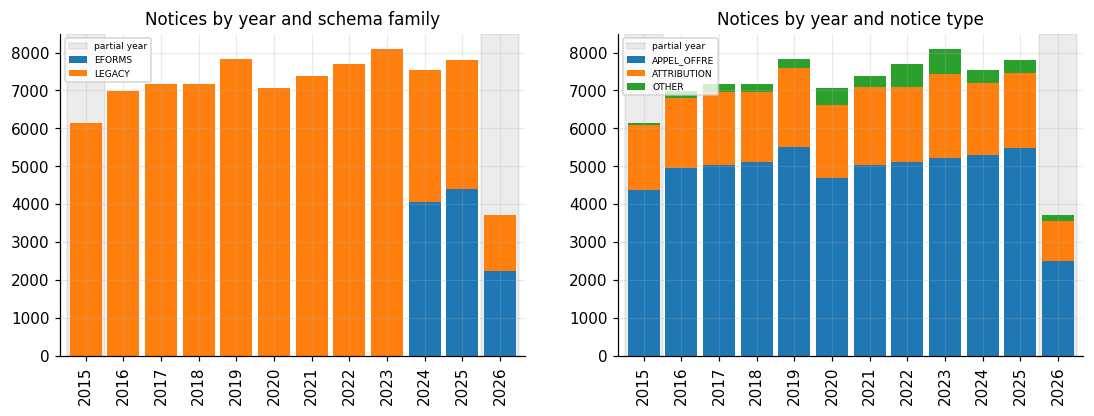

code_departement_prestation (place of performance) populated for 9.6% of notices.


,n_notices,share
code_departement,,
44,41880,0.494901
49,20368,0.240691
85,17630,0.208336
72,16162,0.190988
53,8661,0.102348
...,...,...
39,5,0.000059
976,2,0.000024
986,1,0.000012


In [4]:
by_year_schema = common.groupby(["publication_year", "schema_family"]).size().unstack(fill_value=0)
notice_type_by_year = common.groupby(["publication_year", "notice_type_normalized"]).size().unstack(fill_value=0)

dept_tokens = common["code_departement"].fillna("").str.split(";").explode()
dept_tokens = dept_tokens[dept_tokens != ""]
dept_coverage = dept_tokens.value_counts().rename("n_notices").to_frame()
dept_coverage["share"] = dept_coverage["n_notices"] / n_total
dept_prestation_rate = common["code_departement_prestation"].notna().mean()

cpv_division_coverage = common["cpv_division"].value_counts(dropna=False).rename("n_notices").to_frame()
cpv_division_coverage["share"] = cpv_division_coverage["n_notices"] / n_total

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
by_year_schema.plot(kind="bar", stacked=True, ax=axes[0], width=0.85)
axes[0].set_title("Notices by year and schema family"); axes[0].set_xlabel("")
shade_partial_years(axes[0], by_year_schema.index)
notice_type_by_year.plot(kind="bar", stacked=True, ax=axes[1], width=0.85)
axes[1].set_title("Notices by year and notice type"); axes[1].set_xlabel("")
shade_partial_years(axes[1], notice_type_by_year.index)
plt.show()
save_figure(fig, "calib_corpus_volume_by_year_schema", cfg)

flag_partial_years(by_year_schema).to_csv(SYN_CALIB_DIR / "calib_population_counts_by_year_schema.csv")
flag_partial_years(notice_type_by_year).to_csv(SYN_CALIB_DIR / "calib_notice_type_by_year.csv")
dept_coverage.to_csv(SYN_CALIB_DIR / "calib_department_coverage.csv")
cpv_division_coverage.to_csv(SYN_CALIB_DIR / "calib_cpv_division_coverage.csv")

print(f"code_departement_prestation (place of performance) populated for {dept_prestation_rate:.1%} of notices.")
display(dept_coverage)

add_provenance("dept_coverage", "Notice share by department (multi-valued, exploded)",
                "OBSERVABLE", "see table", "share", "marginal, by department",
                "data/interim/boamp_common_prepared.csv", "code_departement",
                "split on \';\', explode, value_counts", n_total, "2",
                "calib_department_coverage.csv",
                "code_departement can list several departments per notice; shares sum to >1.")
add_provenance("notice_type_by_year", "Notice type composition by year", "OBSERVABLE",
                "see table", "count", "by year", "data/interim/boamp_common_prepared.csv",
                "notice_type_normalized, publication_year", "groupby crosstab", n_total, "2",
                "calib_notice_type_by_year.csv",
                f"notice_type_normalized collapses rare types to OTHER; {year_min} and {year_max} are "
                "PARTIAL years (see calib_year_completeness_status.csv), not full-year counts.")

## 3. Field-level completeness (marginal & conditional)

Non-null rate for every column of the prepared corpus, computed fresh here rather than
reusing `reports/tables/boamp_observed_columns.csv` (which only covers the 42 raw
columns, not the ~50 derived ones this notebook needs). Key fields are then broken down
by year, schema family, and notice type — the three dimensions most associated with
completeness drift in BOAMP data.

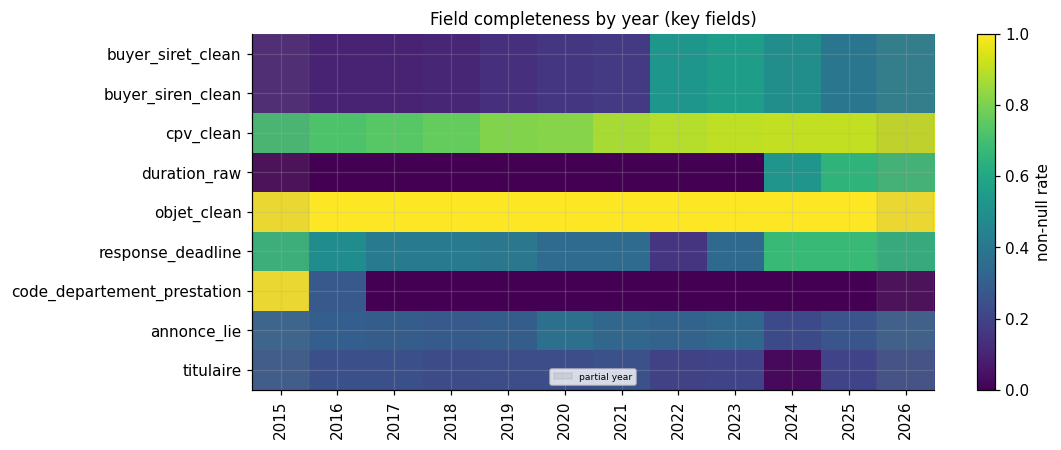

Lowest-completeness fields overall:


,dtype,non_null_rate,n_non_null
buyer_siren_raw,object,0.000000,0
siren_candidates_raw,float64,0.000000,0
soustype_procedure,object,0.005247,444
sousnature_libelle,object,0.064533,5461
code_departement_prestation,object,0.095872,8113
duration_unit,object,0.135011,11425
duration_months_raw,float64,0.136452,11547
duration_source_key,object,0.136452,11547
duration_raw,float64,0.136452,11547
declared_duration_months,float64,0.168039,14220


In [5]:
field_completeness_marginal = pd.DataFrame({
    "dtype": common.dtypes.astype(str),
    "non_null_rate": common.notna().mean(),
    "n_non_null": common.notna().sum(),
}).sort_values("non_null_rate")
field_completeness_marginal.to_csv(SYN_CALIB_DIR / "calib_field_completeness_marginal.csv")

KEY_FIELDS = ["buyer_siret_clean", "buyer_siren_clean", "cpv_clean", "duration_raw",
              "objet_clean", "response_deadline", "code_departement_prestation",
              "annonce_lie", "titulaire"]

completeness_by_year = common.groupby("publication_year")[KEY_FIELDS].apply(lambda d: d.notna().mean())
completeness_by_schema = common.groupby("schema_family")[KEY_FIELDS].apply(lambda d: d.notna().mean())
completeness_by_notice_type = common.groupby("notice_type_normalized")[KEY_FIELDS].apply(lambda d: d.notna().mean())

flag_partial_years(completeness_by_year).to_csv(SYN_CALIB_DIR / "calib_field_completeness_by_year.csv")
completeness_by_schema.to_csv(SYN_CALIB_DIR / "calib_field_completeness_by_schema.csv")
completeness_by_notice_type.to_csv(SYN_CALIB_DIR / "calib_field_completeness_by_notice_type.csv")

fig, ax = plt.subplots(figsize=(10, 4.2))
im = ax.imshow(completeness_by_year[KEY_FIELDS].T.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(len(KEY_FIELDS))); ax.set_yticklabels(KEY_FIELDS)
ax.set_xticks(range(len(completeness_by_year.index)))
ax.set_xticklabels(completeness_by_year.index, rotation=90)
ax.set_title("Field completeness by year (key fields)")
shade_partial_years(ax, completeness_by_year.index)
fig.colorbar(im, ax=ax, label="non-null rate")
plt.show()
save_figure(fig, "calib_field_completeness_heatmap", cfg)

print("Lowest-completeness fields overall:")
display(field_completeness_marginal.head(15))

add_provenance("field_completeness_marginal", "Non-null rate, all 94 columns", "OBSERVABLE",
                "see table", "rate", "marginal", "data/interim/boamp_common_prepared.csv",
                "all columns", "df.notna().mean()", n_total, "3",
                "calib_field_completeness_marginal.csv", "Includes both raw and derived columns; see "
                "§16b calib_data_lineage.csv for which fields are RAW vs CLEANED vs DERIVED vs IMPUTED.")
add_provenance("key_field_completeness_by_year", "Completeness of key fields by year",
                "OBSERVABLE", "see table", "rate", "by publication_year",
                "data/interim/boamp_common_prepared.csv", ",".join(KEY_FIELDS),
                "groupby year, notna mean", n_total, "3",
                "calib_field_completeness_heatmap.png",
                f"Trend, not a validated forecast; {year_min} and {year_max} are PARTIAL years.")

## 4. Temporal change & schema transition (LEGACY → eForms)

Around October 2023 the EU eForms mandate changed the BOAMP notice schema
(`schema_family` LEGACY → EFORMS). This section isolates the completeness shift this
caused in the key fields, plus a finer quarterly trend around the transition.

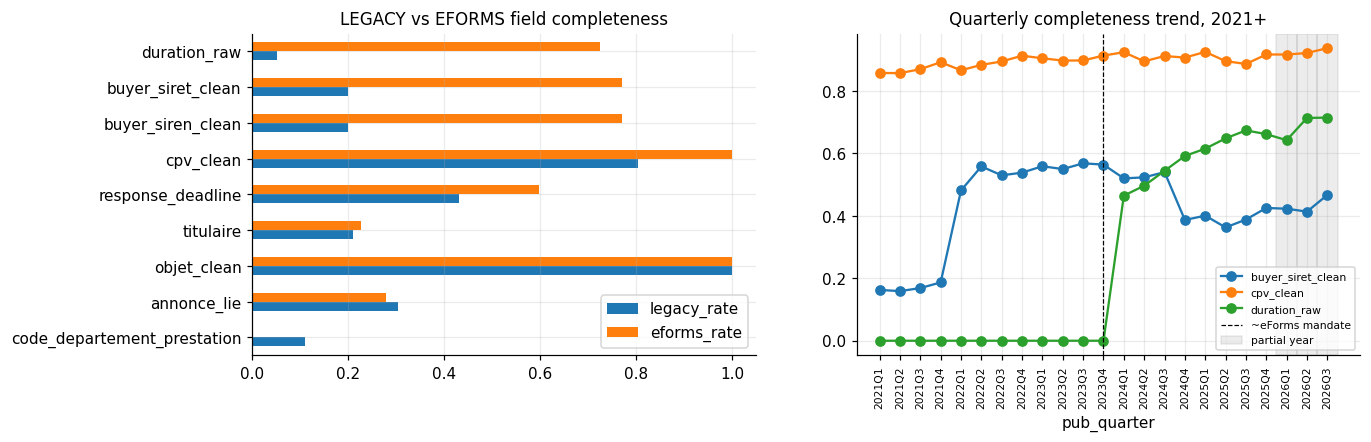

,legacy_rate,eforms_rate,delta_pp
code_departement_prestation,0.109723,0.000000,-10.972262
annonce_lie,0.304500,0.278038,-2.646171
objet_clean,0.999986,1.000000,0.001352
titulaire,0.209775,0.226081,1.630590
response_deadline,0.431560,0.597922,16.636144
cpv_clean,0.804736,1.000000,19.526379
buyer_siren_clean,0.200227,0.770736,57.050861
buyer_siret_clean,0.200227,0.770736,57.050861
duration_raw,0.051284,0.725988,67.470351


In [6]:
legacy_rate = common.loc[common["schema_family"] == "LEGACY", KEY_FIELDS].notna().mean()
eforms_rate = common.loc[common["schema_family"] == "EFORMS", KEY_FIELDS].notna().mean()
schema_shift = pd.DataFrame({"legacy_rate": legacy_rate, "eforms_rate": eforms_rate})
schema_shift["delta_pp"] = (schema_shift["eforms_rate"] - schema_shift["legacy_rate"]) * 100
schema_shift = schema_shift.sort_values("delta_pp")
schema_shift.to_csv(SYN_CALIB_DIR / "calib_schema_transition_shift.csv")

common["pub_quarter"] = common["publication_date"].dt.to_period("Q").astype(str)
quarterly = common.groupby("pub_quarter")[["buyer_siret_clean", "cpv_clean", "duration_raw"]] \
                   .apply(lambda d: d.notna().mean())
quarterly = quarterly[(quarterly.index >= "2021Q1")]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
schema_shift[["legacy_rate", "eforms_rate"]].plot(kind="barh", ax=axes[0])
axes[0].set_title("LEGACY vs EFORMS field completeness")
quarterly.plot(ax=axes[1], marker="o")
axes[1].axvline(quarterly.index.get_loc("2023Q4") if "2023Q4" in quarterly.index else 0,
                 color="k", ls="--", lw=0.8, label="~eForms mandate")
axes[1].set_xticks(range(len(quarterly.index)))
axes[1].set_xticklabels(quarterly.index, rotation=90, fontsize=7)
shade_partial_years(axes[1], quarterly.index)
axes[1].set_title("Quarterly completeness trend, 2021+"); axes[1].legend(fontsize=7)
plt.show()
save_figure(fig, "calib_schema_transition_completeness", cfg)
display(schema_shift)

add_provenance("schema_transition_shift", "LEGACY vs EFORMS field completeness delta",
                "OBSERVABLE", "see table", "percentage points", "by schema_family",
                "data/interim/boamp_common_prepared.csv", ",".join(KEY_FIELDS),
                "groupby schema_family, notna mean, difference", n_total, "4",
                "calib_schema_transition_shift.csv",
                "schema_family is detected heuristically from the raw donnees payload (src/utils/boamp_schema.py); "
                f"not a declared field. The trailing quarters of {year_max} are within the PARTIAL year and "
                "should not be read as a completed-year trend.")

## 5. Buyer activity & concentration

Notices per `buyer_key` (BOAMP-native identity: SIRET > SIREN > normalized-name
fallback — see §6). Highly concentrated activity (a Zipf-like distribution) directly
determines candidate-block sizes a synthetic generator needs to reproduce. Defines a
`buyer_activity_tier` bucket reused as a conditioning variable in later sections.

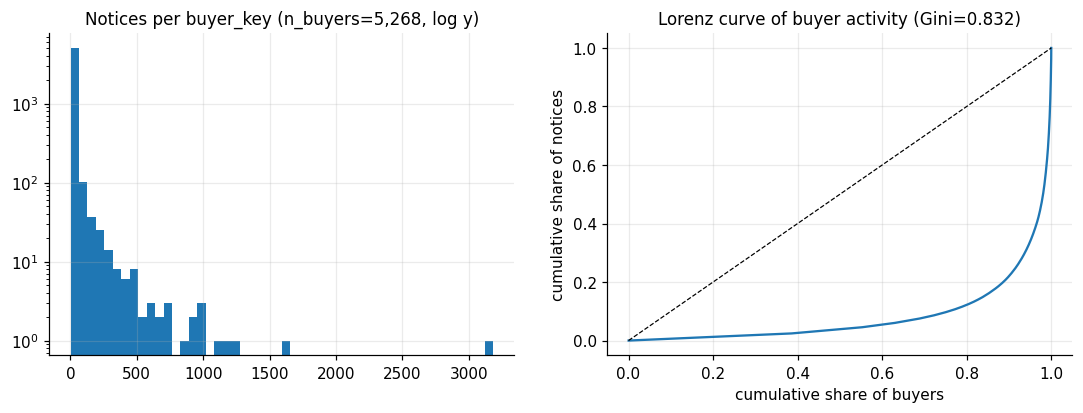

Gini coefficient of buyer activity: 0.832. Top-1 buyer share of all notices: 3.8%. Median notices/buyer: 2.


buyer_activity_tier
21+           68174
6-20           9339
2-5            5110
1 (single)     2000
Name: count, dtype: int64

In [7]:
buyer_counts = common.groupby("buyer_key").size().sort_values(ascending=False)
n_buyers = len(buyer_counts)

sorted_counts = buyer_counts.sort_values()
cum_notices = sorted_counts.cumsum() / sorted_counts.sum()
cum_buyers = np.arange(1, n_buyers + 1) / n_buyers
gini = 1 - 2 * np.trapezoid(cum_notices.values, cum_buyers)

bins = [0, 1, 5, 20, np.inf]
labels = ["1 (single)", "2-5", "6-20", "21+"]
tier_map = pd.cut(buyer_counts, bins=bins, labels=labels)
common["buyer_activity_tier"] = common["buyer_key"].map(tier_map).astype("object")
common["buyer_activity_tier"] = common["buyer_activity_tier"].fillna("NO_BUYER_KEY")

top_buyers = buyer_counts.head(20).rename("n_notices").to_frame()
name_lookup = common.dropna(subset=["buyer_key"]).groupby("buyer_key")["buyer_name_normalized"] \
                     .agg(lambda s: s.mode().iat[0] if not s.mode().empty else None)
top_buyers["buyer_name_normalized_mode"] = top_buyers.index.map(name_lookup)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(buyer_counts, bins=50)
axes[0].set_yscale("log")
axes[0].set_title(f"Notices per buyer_key (n_buyers={n_buyers:,}, log y)")
axes[1].plot(cum_buyers, cum_notices)
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_title(f"Lorenz curve of buyer activity (Gini={gini:.3f})")
axes[1].set_xlabel("cumulative share of buyers"); axes[1].set_ylabel("cumulative share of notices")
plt.show()
save_figure(fig, "calib_buyer_activity_distribution", cfg)

buyer_counts.rename("n_notices").to_csv(SYN_CALIB_DIR / "calib_buyer_activity_distribution.csv")
pd.DataFrame({"cum_share_buyers": cum_buyers, "cum_share_notices": cum_notices.values}) \
  .to_csv(SYN_CALIB_DIR / "calib_buyer_concentration_lorenz.csv", index=False)
top_buyers.to_csv(SYN_CALIB_DIR / "calib_top_buyers.csv")

print(f"Gini coefficient of buyer activity: {gini:.3f}. Top-1 buyer share of all notices: "
      f"{buyer_counts.iloc[0] / buyer_counts.sum():.1%}. Median notices/buyer: {buyer_counts.median():.0f}.")
display(common["buyer_activity_tier"].value_counts())

add_provenance("buyer_activity_gini", "Gini coefficient, notices per buyer_key", "OBSERVABLE",
                round(float(gini), 3), "unitless (0-1)", "unconditional",
                "data/interim/boamp_common_prepared.csv", "buyer_key",
                "Lorenz curve / Gini from groupby(buyer_key).size()", n_buyers, "5",
                "calib_buyer_activity_distribution.png",
                "buyer_key is BOAMP-native identity (SIRET/SIREN/name fallback); NAME_FALLBACK "
                "buyers aggregate multiple real entities under one key, inflating apparent concentration.")

## 6. Identifier quality (SIRET/SIREN)

Format- and checksum-valid rates for buyer SIRET/SIREN, and the provenance of the
identifier actually used (`buyer_identifier_source`), marginal and conditional.

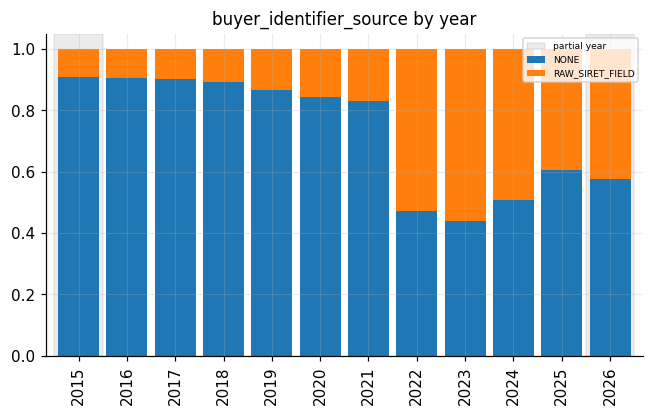

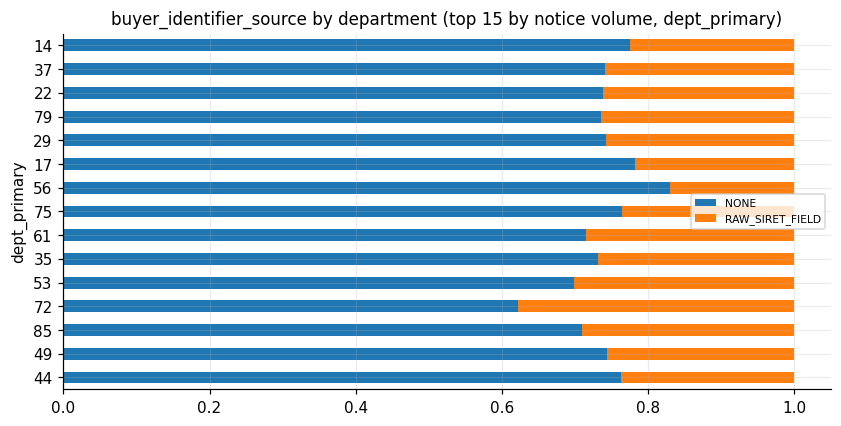

Identifier quality (marginal):


buyer_siret_format_valid      0.272243
buyer_siret_checksum_valid    0.271215
buyer_siren_format_valid      0.000000
buyer_siren_checksum_valid    0.000000
dtype: float64

Identifier source (marginal):


buyer_identifier_source
NONE               0.727757
RAW_SIRET_FIELD    0.272243
Name: proportion, dtype: float64

In [8]:
id_quality_summary = common[["buyer_siret_format_valid", "buyer_siret_checksum_valid",
                              "buyer_siren_format_valid", "buyer_siren_checksum_valid"]].mean()
id_source_counts = common["buyer_identifier_source"].value_counts(normalize=True)

id_source_by_year = common.groupby("publication_year")["buyer_identifier_source"] \
                           .value_counts(normalize=True).unstack(fill_value=0)
id_source_by_dept = common.groupby("dept_primary")["buyer_identifier_source"] \
                           .value_counts(normalize=True).unstack(fill_value=0)
id_quality_by_tier = common.groupby("buyer_activity_tier")[
    ["buyer_siret_format_valid", "buyer_siret_checksum_valid"]].mean()

id_quality_summary.to_csv(SYN_CALIB_DIR / "calib_identifier_quality_summary.csv")
flag_partial_years(id_source_by_year).to_csv(SYN_CALIB_DIR / "calib_identifier_source_by_year.csv")
id_source_by_dept.to_csv(SYN_CALIB_DIR / "calib_identifier_source_by_department.csv")

fig, ax = plt.subplots(figsize=(7, 3.8))
id_source_by_year.plot(kind="bar", stacked=True, ax=ax, width=0.85)
ax.set_title("buyer_identifier_source by year"); ax.set_xlabel(""); ax.legend(fontsize=7)
shade_partial_years(ax, id_source_by_year.index)
plt.show()
save_figure_a = save_figure(fig, "calib_identifier_quality_by_year", cfg)

top_depts_by_volume = common["dept_primary"].value_counts().head(15).index
top_depts_by_volume = [d for d in top_depts_by_volume if d in id_source_by_dept.index]
fig, ax = plt.subplots(figsize=(9, 4.2))
id_source_by_dept.loc[top_depts_by_volume].plot(kind="barh", stacked=True, ax=ax)
ax.set_title("buyer_identifier_source by department (top 15 by notice volume, dept_primary)"); ax.legend(fontsize=7)
plt.show()
save_figure(fig, "calib_identifier_source_by_department", cfg)

print("Identifier quality (marginal):"); display(id_quality_summary)
print("Identifier source (marginal):"); display(id_source_counts)

add_provenance("identifier_source_marginal", "buyer_identifier_source distribution",
                "OBSERVABLE", "see table", "share", "marginal",
                "data/interim/boamp_common_prepared.csv", "buyer_identifier_source",
                "value_counts(normalize=True)", n_total, "6",
                "calib_identifier_quality_summary.csv",
                "RAW_SIRET_FIELD/RAW_SIREN_FIELD/DERIVED_FROM_SIRET/NONE; format+Luhn checksum validated.")

## 7. Buyer identity: name ambiguity and name variation

This section separates the two buyer-identity failure modes requested in Work Package 4.

**Part A — name ambiguity.** For every normalized buyer name, calculate how often that
same name maps to several legal identifiers or buyer keys. This calibrates false buyer
merging risk.

**Part B — name variation.** At SIRET and SIREN level, calculate how many raw and
normalized names are used for one reliable buyer identity, and classify likely name
transformations. This calibrates false buyer splitting risk.

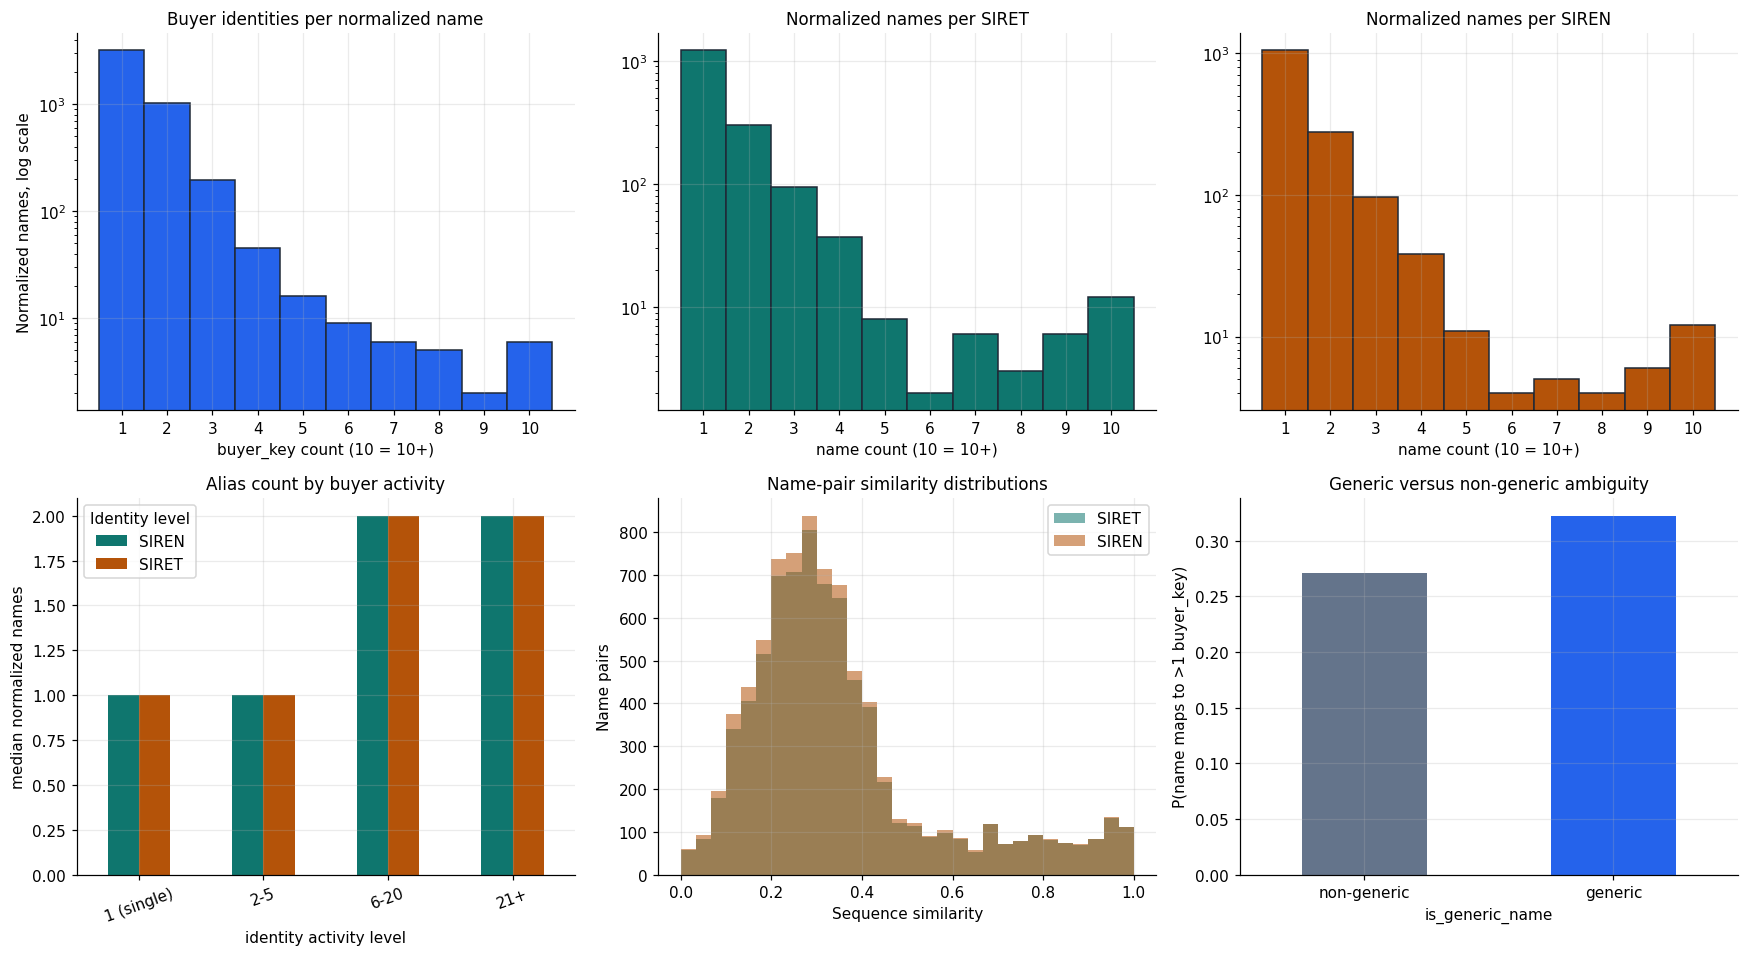

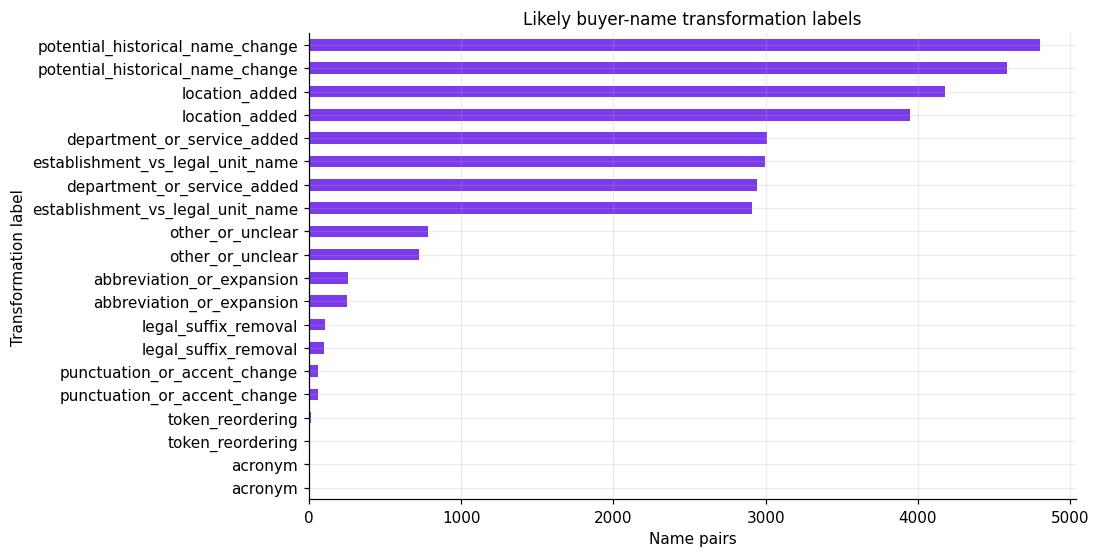

Name ambiguity summary:


,n_normalized_names,n_fragmented_names,fragmentation_rate,max_keys_per_name
0,4492,1303,0.290071,13


Top ambiguous normalized names:


,buyer_name_normalized,n_notices,n_sirets,n_sirens,n_departments,n_buyer_keys,n_active_years,first_year,last_year,activity_level,example_sirets,example_sirens,example_departments,example_buyer_keys,is_generic_name,same_siren_different_sirets,different_sirens,department_consistent_mapping,department_conflicting_mapping,ambiguity_class
2643,laval agglomeration,452,12,6,1,13,12,2015,2026,21+,17440005100010;20008339200015;20008339200049;2...,174400051;200083392;200094100;255301210;382473...,53,NAME:laval agglomeration;SIRET:17440005100010;...,False,False,True,True,False,different_sirens
3157,nantes metropole,3837,11,5,1,12,12,2015,2026,21+,17440005100010;21440109300015;24440040400012;2...,174400051;214401093;244400404;450452115;920842150,44,NAME:nantes metropole;SIRET:17440005100010;SIR...,False,False,True,True,False,different_sirens
732,chu nantes,221,10,10,2,11,9,2018,2026,21+,17440005100010;26440013600471;30122243600034;3...,174400051;264400136;301222436;313335978;483819...,35;44,NAME:chu nantes;SIRET:17440005100010;SIRET:264...,False,False,True,False,True,different_sirens
3178,nantes universite,172,9,9,4,10,3,2024,2026,21+,13002928300012;13002974700016;17440005100010;2...,130029283;130029747;174400051;266900273;311020...,35;44;49;85,NAME:nantes universite;SIRET:13002928300012;SI...,True,False,True,False,True,different_sirens
700,cholet agglomeration,126,9,8,2,10,4,2023,2026,21+,06820078100026;17350111500864;17440005100010;2...,068200781;173501115;174400051;200071678;244900...,44;49,NAME:cholet agglomeration;SIRET:06820078100026...,False,False,True,False,True,different_sirens
264,ca pornic agglo pays de retz,256,9,4,2,10,10,2017,2026,21+,13002928300012;17440005100010;20006734600011;2...,130029283;174400051;200067346;481945517,35;44,NAME:ca pornic agglo pays de retz;SIRET:130029...,False,False,True,False,True,different_sirens
3363,region des pays de la loire,390,8,8,5,9,3,2024,2026,21+,13002928300012;17440005100010;19720033000029;2...,130029283;174400051;197200330;234400034;315871...,44;49;53;72;85,NAME:region des pays de la loire;SIRET:1300292...,False,False,True,False,True,different_sirens
3030,mauges communaute,383,8,2,1,9,11,2016,2026,21+,17440005100010;20006001000010;20006001000028;2...,174400051;200060010,49,NAME:mauges communaute;SIRET:17440005100010;SI...,False,False,True,True,False,different_sirens
4287,ville de cholet,384,7,7,2,8,12,2015,2026,21+,17350111500864;17440005100010;21490099500017;3...,173501115;174400051;214900995;302135405;333975...,44;49,NAME:ville de cholet;SIRET:17350111500864;SIRE...,True,False,True,False,True,different_sirens
512,centre communal d action sociale,71,7,6,9,8,11,2016,2026,21+,20005443500017;20005456700025;20006580300013;2...,200054435;200054567;200065803;261700199;264901...,16;17;28;49;51;61;72;79,NAME:centre communal d action sociale;SIRET:20...,False,False,True,False,True,different_sirens


Name variation by identity level:


,identity_level,identity_value,n_raw_names,n_normalized_names,active_years,n_notices,activity_level,earliest_name_raw,latest_name_raw,earliest_name_normalized,latest_name_normalized,example_raw_names,example_normalized_names
0,SIRET,17440005100010,85,75,3,515,21+,Communauté de communes Estuaire et Sillon,DEPARTEMENT DU MAINE ET LOIRE,communaute de communes estuaire et sillon,departement du maine et loire,ARS Pays de la Loire;Alter Public au nom et po...,alter public au nom et pour le compte d angers...
1,SIRET,11000201100044,75,71,9,179,21+,MINDEF/EMA/DC SCA/PFAF CO Rennes,PFC Sud-Ouest,mindef ema dc sca pfaf co rennes,pfc sud-ouest,Armement des phares et balises;COMSOPGN;COUR D...,armement des phares et balises;cci du mans et ...
2,SIRET,17350005900014,28,27,3,38,21+,Ville de Saint-Malo,TERRITOIRES PUBLICS\nMandataire agissant au no...,ville de saint-malo,territoires publics mandataire agissant au nom...,CA LANNION-TREGOR COMMUNAUTE;CC BRETAGNE PORTE...,ca lannion-tregor communaute;cc bretagne porte...
3,SIRET,92084215000012,17,17,3,31,21+,CARIFOREF,La Cité des Congrès de Nantes agissant au nom ...,cariforef,la cite des congres de nantes agissant au nom ...,CA SAUMUR VAL DE LOIRE;CARIFOREF;CARIFOREF des...,ca saumur val de loire;cariforef;cariforef des...
4,SIRET,26490003600015,19,16,6,201,21+,CTRE HOSP UNIVERSITAIRE ANGERS,49 CHU,ctre hosp universitaire angers,49 chu,49 CHU;CENTRE HOSPITALIER UNIVERSITAIRE D'ANGE...,49 chu;centre hospitalier universitaire d ange...
5,SIRET,77560485300041,16,14,12,199,21+,GPM de Nantes - St Nazaire,Grand Port Maritime de Nantes Saint-Nazaire,gpm de nantes - st nazaire,grand port maritime de nantes saint-nazaire,GPM de Nantes - St Nazaire;GRAND PORT MARITIME...,gpm de nantes - st nazaire;grand port maritime...
6,SIRET,52884815300029,15,14,5,45,21+,ALTER Public,Alter Public au nom et pour le compte de la Co...,alter public,alter public au nom et pour le compte de la co...,ALTER PUBLIC agissant au nom et pour le compte...,alter public;alter public agissant au nom et p...
7,SIRET,26720016000013,20,12,5,162,21+,CH LE MANS,Centre hospitalier du Mans,ch le mans,centre hospitalier du mans,CENTRE HOSPITALIER DU MANS;CENTRE HOSPITALIER ...,centre hospitalier du mans;centre hospitalier ...
8,SIREN,174400051,85,75,3,515,21+,Communauté de communes Estuaire et Sillon,DEPARTEMENT DU MAINE ET LOIRE,communaute de communes estuaire et sillon,departement du maine et loire,ARS Pays de la Loire;Alter Public au nom et po...,alter public au nom et pour le compte d angers...
9,SIREN,110002011,75,71,9,179,21+,MINDEF/EMA/DC SCA/PFAF CO Rennes,PFC Sud-Ouest,mindef ema dc sca pfaf co rennes,pfc sud-ouest,Armement des phares et balises;COMSOPGN;COUR D...,armement des phares et balises;cci du mans et ...


Transformation counts:


,identity_level,transformation_label,n_name_pairs
7,SIREN,potential_historical_name_change,4801
5,SIREN,location_added,4178
2,SIREN,department_or_service_added,3006
3,SIREN,establishment_vs_legal_unit_name,2993
6,SIREN,other_or_unclear,782
0,SIREN,abbreviation_or_expansion,258
4,SIREN,legal_suffix_removal,100
8,SIREN,punctuation_or_accent_change,58
9,SIREN,token_reordering,8
1,SIREN,acronym,7


Among ambiguous names, 40.9% are generic-institutional (stoplist match); overall generic-name share across normalized names: 36.8%. Buyer-key name variation rate: 8.9%.


In [9]:
import unicodedata
from difflib import SequenceMatcher
from itertools import combinations

BUYER_ID_FIG_DIR = cfg.paths.reports_figures / "synthetic_calibration" / "buyer_identity"
BUYER_ID_FIG_DIR.mkdir(parents=True, exist_ok=True)

LEGAL_SUFFIX_TOKENS = {
    "sa", "sas", "sasu", "sarl", "eurl", "sem", "spl", "scp", "scop", "gie", "epic",
    "association", "assoc", "syndicat", "mixte", "communaute", "communaute", "metropole",
    "departement", "region", "ville", "commune", "mairie", "ccas", "chu", "ch", "ehpad",
}
LOCATION_TOKENS = {
    "nantes", "angers", "laval", "mans", "sarthe", "mayenne", "vendee", "loire", "atlantique",
    "saint", "nazaire", "roche", "yon", "cholet", "saumur", "fontenay", "comte", "herbiers",
    "sables", "olonne", "pays", "loire-atlantique", "maine", "vilaine",
}
SERVICE_TOKENS = {
    "service", "services", "direction", "departement", "pole", "agence", "centre", "site",
    "etablissement", "hospitalier", "universite", "archives", "technique", "territorial", "achat", "achats",
}
ESTABLISHMENT_TOKENS = {
    "centre", "site", "agence", "etablissement", "hopital", "hospitalier", "lycee", "college",
    "ecole", "campus", "antenne", "delegation", "direction", "service", "chu", "ch",
}


def save_buyer_identity_figure(fig, stem):
    paths = []
    for ext in ("png", "pdf"):
        out = BUYER_ID_FIG_DIR / f"{stem}.{ext}"
        fig.savefig(out, bbox_inches="tight", dpi=200)
        paths.append(str(out))
    plt.close(fig)
    return paths


def strip_accents(value):
    if not isinstance(value, str):
        return ""
    return "".join(ch for ch in unicodedata.normalize("NFKD", value) if not unicodedata.combining(ch))


def simple_name(value):
    value = strip_accents(value).lower()
    return re.sub(r"[^a-z0-9]+", " ", value).strip()


def name_tokens(value):
    return [tok for tok in simple_name(value).split() if tok]


def remove_legal_suffixes(value):
    return " ".join(tok for tok in name_tokens(value) if tok not in LEGAL_SUFFIX_TOKENS)


def acronym_of(value):
    return "".join(tok[0] for tok in name_tokens(value) if tok and tok not in LEGAL_SUFFIX_TOKENS)


def token_jaccard(a, b):
    ta, tb = set(name_tokens(a)), set(name_tokens(b))
    if not ta and not tb:
        return np.nan
    return len(ta & tb) / len(ta | tb) if (ta | tb) else np.nan


def sequence_similarity(a, b):
    return SequenceMatcher(None, simple_name(a), simple_name(b)).ratio()


def classify_name_transformation(name_a, name_b, first_date=None, last_date=None):
    tokens_a, tokens_b = name_tokens(name_a), name_tokens(name_b)
    set_a, set_b = set(tokens_a), set(tokens_b)
    simple_a, simple_b = simple_name(name_a), simple_name(name_b)
    labels = []

    if simple_a == simple_b and str(name_a) != str(name_b):
        labels.append("punctuation_or_accent_change")
    if remove_legal_suffixes(name_a) == remove_legal_suffixes(name_b) and simple_a != simple_b:
        labels.append("legal_suffix_removal")
    if set_a == set_b and tokens_a != tokens_b:
        labels.append("token_reordering")
    if acronym_of(name_a) == simple_b.replace(" ", "") or acronym_of(name_b) == simple_a.replace(" ", ""):
        labels.append("acronym")
    short_len, long_len = sorted([len(tokens_a), len(tokens_b)])
    if short_len > 0 and long_len >= short_len + 2 and token_jaccard(name_a, name_b) >= 0.5:
        labels.append("abbreviation_or_expansion")
    added = (set_b - set_a) | (set_a - set_b)
    if added & LOCATION_TOKENS:
        labels.append("location_added")
    if added & SERVICE_TOKENS:
        labels.append("department_or_service_added")
    if (set_a ^ set_b) & ESTABLISHMENT_TOKENS:
        labels.append("establishment_vs_legal_unit_name")
    if first_date is not None and last_date is not None and pd.notna(first_date) and pd.notna(last_date):
        if (last_date - first_date).days >= 365 and sequence_similarity(name_a, name_b) < 0.75:
            labels.append("potential_historical_name_change")
    if not labels:
        labels.append("other_or_unclear")
    return ";".join(dict.fromkeys(labels))


GENERIC_NAMES = list(cfg.pipeline.enrichment.alias_bridge.generic_names)
def is_generic_name(name):
    if not isinstance(name, str):
        return False
    return any(tok in name for tok in GENERIC_NAMES)

# --- Part A: one normalized name -> several legal identities / buyer keys. ---
name_grouped = common.dropna(subset=["buyer_name_normalized"]).groupby("buyer_name_normalized", dropna=False)

def unique_join(values, max_items=8):
    vals = sorted({str(v) for v in values.dropna() if str(v) and str(v).lower() != "nan"})
    return ";".join(vals[:max_items])

buyer_name_ambiguity = name_grouped.agg(
    n_notices=("notice_id", "size"),
    n_sirets=("buyer_siret_clean", "nunique"),
    n_sirens=("buyer_siren_clean", "nunique"),
    n_departments=("dept_primary", "nunique"),
    n_buyer_keys=("buyer_key", "nunique"),
    n_active_years=("publication_year", "nunique"),
    first_year=("publication_year", "min"),
    last_year=("publication_year", "max"),
    activity_level=("buyer_activity_tier", lambda s: s.value_counts().index[0] if len(s.value_counts()) else "NO_BUYER_KEY"),
    example_sirets=("buyer_siret_clean", unique_join),
    example_sirens=("buyer_siren_clean", unique_join),
    example_departments=("dept_primary", unique_join),
    example_buyer_keys=("buyer_key", unique_join),
).reset_index()
buyer_name_ambiguity["is_generic_name"] = buyer_name_ambiguity["buyer_name_normalized"].map(is_generic_name)
buyer_name_ambiguity["same_siren_different_sirets"] = (
    buyer_name_ambiguity["n_sirens"].eq(1) & buyer_name_ambiguity["n_sirets"].gt(1)
)
buyer_name_ambiguity["different_sirens"] = buyer_name_ambiguity["n_sirens"].gt(1)
buyer_name_ambiguity["department_consistent_mapping"] = buyer_name_ambiguity["n_departments"].le(1)
buyer_name_ambiguity["department_conflicting_mapping"] = buyer_name_ambiguity["n_departments"].gt(1)
buyer_name_ambiguity["ambiguity_class"] = np.select(
    [
        buyer_name_ambiguity["different_sirens"],
        buyer_name_ambiguity["same_siren_different_sirets"],
        buyer_name_ambiguity["n_buyer_keys"].gt(1),
    ],
    ["different_sirens", "same_siren_different_sirets", "multiple_buyer_keys_no_identifier_split"],
    default="single_observed_identity",
)
buyer_name_ambiguity = buyer_name_ambiguity.sort_values(
    ["n_buyer_keys", "n_sirens", "n_sirets", "n_departments", "n_notices"], ascending=False
)
buyer_name_ambiguity.to_csv(SYN_CALIB_DIR / "buyer_name_ambiguity.csv", index=False)

# Backward-compatible summary/example outputs used by the existing calibration report.
keys_per_name = buyer_name_ambiguity.set_index("buyer_name_normalized")["n_buyer_keys"]
fragmented_names = keys_per_name[keys_per_name > 1].sort_values(ascending=False)
frag_summary = pd.DataFrame({
    "n_normalized_names": [len(keys_per_name)],
    "n_fragmented_names": [int((keys_per_name > 1).sum())],
    "fragmentation_rate": [float((keys_per_name > 1).mean()) if len(keys_per_name) else 0.0],
    "max_keys_per_name": [int(keys_per_name.max()) if len(keys_per_name) else 0],
})
frag_summary.to_csv(SYN_CALIB_DIR / "calib_buyer_name_ambiguity_summary.csv", index=False)
buyer_name_ambiguity.loc[buyer_name_ambiguity["n_buyer_keys"].gt(1)].head(30).to_csv(
    SYN_CALIB_DIR / "calib_buyer_name_ambiguity_examples.csv", index=False
)

overall_generic_rate = buyer_name_ambiguity["is_generic_name"].mean()
generic_frag_rate = buyer_name_ambiguity.loc[buyer_name_ambiguity["n_buyer_keys"].gt(1), "is_generic_name"].mean()

# --- Part B: one reliable identifier -> several names, separately for SIRET and SIREN. ---
def identity_variation_table(identity_col, identity_level):
    rows = []
    for identity_value, group in common.dropna(subset=[identity_col]).groupby(identity_col, sort=False):
        raw_names = sorted({str(v) for v in group["buyer_name_raw"].dropna() if str(v) and str(v).lower() != "nan"})
        norm_names = sorted({str(v) for v in group["buyer_name_normalized"].dropna() if str(v) and str(v).lower() != "nan"})
        first_idx = group["publication_date"].idxmin() if group["publication_date"].notna().any() else group.index[0]
        last_idx = group["publication_date"].idxmax() if group["publication_date"].notna().any() else group.index[-1]
        rows.append({
            "identity_level": identity_level,
            "identity_value": identity_value,
            "n_raw_names": len(raw_names),
            "n_normalized_names": len(norm_names),
            "active_years": int(group["publication_year"].nunique()),
            "n_notices": len(group),
            "activity_level": pd.cut(pd.Series([len(group)]), bins=bins, labels=labels).astype("object").iloc[0],
            "earliest_name_raw": group.loc[first_idx, "buyer_name_raw"],
            "latest_name_raw": group.loc[last_idx, "buyer_name_raw"],
            "earliest_name_normalized": group.loc[first_idx, "buyer_name_normalized"],
            "latest_name_normalized": group.loc[last_idx, "buyer_name_normalized"],
            "example_raw_names": ";".join(raw_names[:8]),
            "example_normalized_names": ";".join(norm_names[:8]),
        })
    out = pd.DataFrame(rows)
    return out.sort_values(["n_normalized_names", "n_raw_names", "n_notices"], ascending=False)

buyer_name_variation_siret = identity_variation_table("buyer_siret_clean", "SIRET")
buyer_name_variation_siren = identity_variation_table("buyer_siren_clean", "SIREN")
buyer_name_variation_siret.to_csv(SYN_CALIB_DIR / "buyer_name_variation_siret.csv", index=False)
buyer_name_variation_siren.to_csv(SYN_CALIB_DIR / "buyer_name_variation_siren.csv", index=False)

# Backward-compatible aggregate used by earlier notebook/report wording.
names_per_key = common.dropna(subset=["buyer_key"]).groupby("buyer_key")["buyer_name_normalized"].nunique()
varying_keys = names_per_key[names_per_key > 1].sort_values(ascending=False)
name_variation_rate = len(varying_keys) / len(names_per_key) if len(names_per_key) else float("nan")
name_variation_summary = pd.DataFrame({
    "n_buyer_keys": [len(names_per_key)],
    "n_keys_with_variant_names": [len(varying_keys)],
    "name_variation_rate": [name_variation_rate],
    "max_names_per_key": [int(names_per_key.max()) if len(names_per_key) else 0],
})
name_variation_summary.to_csv(SYN_CALIB_DIR / "calib_buyer_name_variation_summary.csv", index=False)
varying_keys.rename("n_distinct_names").head(30).to_csv(SYN_CALIB_DIR / "calib_buyer_name_variation_examples.csv")

# Pair-level name similarities and transformation labels. Pair counts are small enough to enumerate exhaustively.
transformation_rows = []
def add_transformation_rows(variation_table, identity_col, identity_level):
    for row in variation_table.loc[variation_table["n_normalized_names"].gt(1)].itertuples(index=False):
        group = common.loc[common[identity_col].eq(row.identity_value)].copy()
        name_dates = group.dropna(subset=["buyer_name_normalized"]).groupby("buyer_name_normalized").agg(
            first_date=("publication_date", "min"),
            last_date=("publication_date", "max"),
            example_raw_name=("buyer_name_raw", lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan),
            n_notices=("notice_id", "size"),
        ).reset_index()
        for a, b in combinations(name_dates.itertuples(index=False), 2):
            first_date = min(a.first_date, b.first_date)
            last_date = max(a.last_date, b.last_date)
            labels_found = classify_name_transformation(a.buyer_name_normalized, b.buyer_name_normalized, first_date, last_date)
            transformation_rows.append({
                "identity_level": identity_level,
                "identity_value": row.identity_value,
                "name_a": a.buyer_name_normalized,
                "name_b": b.buyer_name_normalized,
                "raw_name_a": a.example_raw_name,
                "raw_name_b": b.example_raw_name,
                "sequence_similarity": sequence_similarity(a.buyer_name_normalized, b.buyer_name_normalized),
                "token_jaccard": token_jaccard(a.buyer_name_normalized, b.buyer_name_normalized),
                "first_date": first_date,
                "last_date": last_date,
                "years_between_forms": (last_date - first_date).days / 365.25 if pd.notna(first_date) and pd.notna(last_date) else np.nan,
                "transformation_labels": labels_found,
                "n_notices_identity": row.n_notices,
                "n_normalized_names_identity": row.n_normalized_names,
                "activity_level": row.activity_level,
            })

add_transformation_rows(buyer_name_variation_siret, "buyer_siret_clean", "SIRET")
add_transformation_rows(buyer_name_variation_siren, "buyer_siren_clean", "SIREN")
buyer_name_transformations = pd.DataFrame(transformation_rows)
buyer_name_transformations.to_csv(SYN_CALIB_DIR / "buyer_name_transformations.csv", index=False)

transformation_counts = (
    buyer_name_transformations.assign(transformation_label=buyer_name_transformations["transformation_labels"].str.split(";"))
    .explode("transformation_label")
    .groupby(["identity_level", "transformation_label"], dropna=False)
    .size().reset_index(name="n_name_pairs")
    .sort_values(["identity_level", "n_name_pairs"], ascending=[True, False])
)
transformation_counts.to_csv(SYN_CALIB_DIR / "buyer_name_transformation_counts.csv", index=False)

name_variation_by_activity = pd.concat([
    buyer_name_variation_siret.assign(identity_level="SIRET"),
    buyer_name_variation_siren.assign(identity_level="SIREN"),
], ignore_index=True).groupby(["identity_level", "activity_level"], dropna=False).agg(
    n_identities=("identity_value", "size"),
    median_normalized_names=("n_normalized_names", "median"),
    p_with_variation=("n_normalized_names", lambda s: (s > 1).mean()),
    p90_normalized_names=("n_normalized_names", lambda s: s.quantile(0.90)),
).reset_index()
name_variation_by_activity.to_csv(SYN_CALIB_DIR / "buyer_name_variation_by_activity.csv", index=False)

# --- Requested plots. ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8.8))
axes = axes.ravel()

axes[0].hist(buyer_name_ambiguity["n_buyer_keys"].clip(upper=10), bins=np.arange(1, 12) - 0.5, color="#2563eb", edgecolor="#1f2937")
axes[0].set_yscale("log")
axes[0].set_title("Buyer identities per normalized name")
axes[0].set_xlabel("buyer_key count (10 = 10+)")
axes[0].set_ylabel("Normalized names, log scale")
axes[0].set_xticks(range(1, 11))

axes[1].hist(buyer_name_variation_siret["n_normalized_names"].clip(upper=10), bins=np.arange(1, 12) - 0.5, color="#0f766e", edgecolor="#1f2937")
axes[1].set_yscale("log")
axes[1].set_title("Normalized names per SIRET")
axes[1].set_xlabel("name count (10 = 10+)")
axes[1].set_xticks(range(1, 11))

axes[2].hist(buyer_name_variation_siren["n_normalized_names"].clip(upper=10), bins=np.arange(1, 12) - 0.5, color="#b45309", edgecolor="#1f2937")
axes[2].set_yscale("log")
axes[2].set_title("Normalized names per SIREN")
axes[2].set_xlabel("name count (10 = 10+)")
axes[2].set_xticks(range(1, 11))

activity_plot = name_variation_by_activity.pivot(index="activity_level", columns="identity_level", values="median_normalized_names").reindex(labels)
activity_plot.plot(kind="bar", ax=axes[3], color=["#0f766e", "#b45309"])
axes[3].set_title("Alias count by buyer activity")
axes[3].set_xlabel("identity activity level")
axes[3].set_ylabel("median normalized names")
axes[3].legend(title="Identity level")
axes[3].tick_params(axis="x", rotation=20)

for level, color in [("SIRET", "#0f766e"), ("SIREN", "#b45309")]:
    vals = buyer_name_transformations.loc[buyer_name_transformations["identity_level"].eq(level), "sequence_similarity"].dropna()
    axes[4].hist(vals, bins=30, alpha=0.55, label=level, color=color)
axes[4].set_title("Name-pair similarity distributions")
axes[4].set_xlabel("Sequence similarity")
axes[4].set_ylabel("Name pairs")
axes[4].legend()

amb_generic = buyer_name_ambiguity.assign(ambiguity_flag=buyer_name_ambiguity["n_buyer_keys"].gt(1)) \
    .groupby("is_generic_name")["ambiguity_flag"].mean()
amb_generic.index = amb_generic.index.map({False: "non-generic", True: "generic"})
amb_generic.plot(kind="bar", ax=axes[5], color=["#64748b", "#2563eb"])
axes[5].set_title("Generic versus non-generic ambiguity")
axes[5].set_ylabel("P(name maps to >1 buyer_key)")
axes[5].tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()
save_buyer_identity_figure(fig, "buyer_identity_name_ambiguity_variation")

fig, ax = plt.subplots(figsize=(9, 5.5))
transformation_counts.head(20).sort_values("n_name_pairs").plot(
    kind="barh", x="transformation_label", y="n_name_pairs", ax=ax, legend=False, color="#7c3aed"
)
ax.set_title("Likely buyer-name transformation labels")
ax.set_xlabel("Name pairs")
ax.set_ylabel("Transformation label")
plt.show()
save_buyer_identity_figure(fig, "buyer_name_transformation_counts")

print("Name ambiguity summary:")
display(frag_summary)
print("Top ambiguous normalized names:")
display(buyer_name_ambiguity.head(12))
print("Name variation by identity level:")
display(pd.concat([
    buyer_name_variation_siret.assign(identity_level="SIRET").head(8),
    buyer_name_variation_siren.assign(identity_level="SIREN").head(8),
], ignore_index=True))
print("Transformation counts:")
display(transformation_counts.head(20))
print(f"Among ambiguous names, {generic_frag_rate:.1%} are generic-institutional (stoplist match); "
      f"overall generic-name share across normalized names: {overall_generic_rate:.1%}. "
      f"Buyer-key name variation rate: {name_variation_rate:.1%}.")

add_provenance("buyer_name_ambiguity_rate", "Share of normalized buyer names mapping to >1 buyer_key",
                "OBSERVABLE", round(float(frag_summary["fragmentation_rate"].iloc[0]), 4), "rate", "marginal + by generic-name/activity/identifier/dept consistency",
                "data/interim/boamp_common_prepared.csv", "buyer_name_normalized,buyer_siret_clean,buyer_siren_clean,dept_primary,buyer_key,buyer_activity_tier",
                "groupby normalized name; count distinct SIRETs/SIRENs/departments/buyer_keys and classify same-SIREN/different-SIRET, different-SIREN, department consistency",
                len(buyer_name_ambiguity), "7", "buyer_name_ambiguity.csv",
                "A data-quality measure of BOAMP-native identity ambiguity used to calibrate false buyer merging risk; generic institutional names are flagged separately because common nouns can represent many legal buyers.")
add_provenance("buyer_name_variation_siret", "Normalized names per reliable SIRET identity",
                "OBSERVABLE", "see table", "count/similarity", "by SIRET identity and activity level",
                "data/interim/boamp_common_prepared.csv", "buyer_siret_clean,buyer_name_raw,buyer_name_normalized,publication_year,publication_date",
                "groupby SIRET; count raw/normalized names, active years, notices, earliest/latest forms and name-pair similarities",
                len(buyer_name_variation_siret), "7", "buyer_name_variation_siret.csv",
                "SIRET is the establishment-level identity; variation here estimates false splitting risk among the most specific reliable BOAMP-native buyer identifiers.")
add_provenance("buyer_name_variation_siren", "Normalized names per reliable SIREN identity",
                "OBSERVABLE", "see table", "count/similarity", "by SIREN identity and activity level",
                "data/interim/boamp_common_prepared.csv", "buyer_siren_clean,buyer_name_raw,buyer_name_normalized,publication_year,publication_date",
                "groupby SIREN; count raw/normalized names, active years, notices, earliest/latest forms and name-pair similarities",
                len(buyer_name_variation_siren), "7", "buyer_name_variation_siren.csv",
                "SIREN is the legal-unit identity; it can legitimately aggregate several establishments or service renderings, so variation is not automatically an error.")
add_provenance("buyer_name_transformation_mix", "Likely buyer-name transformation labels",
                "OBSERVABLE", "see table", "name-pair count", "SIRET/SIREN identities with >1 normalized name",
                "data/interim/boamp_common_prepared.csv", "buyer_name_raw,buyer_name_normalized,buyer_siret_clean,buyer_siren_clean,publication_date",
                "heuristic pairwise classification: punctuation/accent, legal suffix, abbreviation, acronym, location/service tokens, establishment/legal-unit, token reorder, historical change",
                len(buyer_name_transformations), "7", "buyer_name_transformations.csv",
                "Transformation labels are heuristic and can overlap; use them as generator corruption modes, not verified legal-name-change annotations.")

## 8. CPV quality and eForms discontinuity audit

This section first answers the adaptive-task question: the near-zero eForms CPV pattern
was a parser discontinuity, not source-level CPV absence. It then updates the ordinary
CPV missingness/genericity calibration tables using the corrected prepared corpus.

The audit compares CPV availability at three stages: raw nested source JSON, flattened
candidate extraction, and cleaned prepared `cpv_clean`. For the before/after comparison,
`old_extract_cpv_codes()` recreates the old parser rule inside the notebook.

eForms CPV: before=0.0%, after=100.0%; old parser missed 10,682/10,682 raw-present eForms records.


,schema_family,stage,n_records,n_cpv_available,p_cpv_available,n_multiple_cpv_after_fix,n_cpv_present_parser_missed_before_fix,n_genuinely_absent_after_fix
9,EFORMS,cleaned_prepared_after_fix,10682,10682,1.000000,4599,10682,0
7,EFORMS,cleaned_prepared_before_fix,10682,0,0.000000,4599,10682,0
5,EFORMS,raw_source,10682,10682,1.000000,4599,10682,0
14,LEGACY,cleaned_prepared_after_fix,73941,59503,0.804736,20124,0,14438
12,LEGACY,cleaned_prepared_before_fix,73941,59503,0.804736,20124,0,14438
10,LEGACY,raw_source,73941,59503,0.804736,20124,0,14438


,eforms_notice_type,path,path_role,n_values,n_valid_8_digit_values,example_notice_id,example_value,n_records,parser_after_fix_status
5,ContractNotice,EFORMS/ContractNotice/cac:ProcurementProjectLo...,eforms_cpv_code_path,21993,21993,24-5256,71400000,6821,recovered_as_cpv
1,ContractNotice,EFORMS/ContractNotice/cac:ProcurementProject/c...,eforms_cpv_code_path,6821,6821,24-5256,71400000,6821,recovered_as_cpv
9,ContractAwardNotice,EFORMS/ContractAwardNotice/cac:ProcurementProj...,eforms_cpv_code_path,3803,3803,24-8193,50324200,3803,recovered_as_cpv
13,ContractAwardNotice,EFORMS/ContractAwardNotice/cac:ProcurementProj...,eforms_cpv_code_path,10236,10236,24-8193,50324200,3802,recovered_as_cpv
7,ContractNotice,EFORMS/ContractNotice/cac:ProcurementProjectLo...,eforms_cpv_code_path,12633,12633,24-5256,71240000,2913,recovered_as_cpv
3,ContractNotice,EFORMS/ContractNotice/cac:ProcurementProject/c...,eforms_cpv_code_path,4657,4657,24-5256,71240000,2903,recovered_as_cpv
15,ContractAwardNotice,EFORMS/ContractAwardNotice/cac:ProcurementProj...,eforms_cpv_code_path,7266,7266,24-8193,50324200,1843,recovered_as_cpv
11,ContractAwardNotice,EFORMS/ContractAwardNotice/cac:ProcurementProj...,eforms_cpv_code_path,2789,2789,24-8193,50324200,1822,recovered_as_cpv
22,PriorInformationNotice,EFORMS/PriorInformationNotice/cac:ProcurementP...,eforms_cpv_code_path,58,58,24-6635,45252300,58,recovered_as_cpv
24,PriorInformationNotice,EFORMS/PriorInformationNotice/cac:ProcurementP...,eforms_cpv_code_path,176,176,24-6635,45252300,45,recovered_as_cpv


,notice_id,publication_year,eforms_notice_type,notice_type_normalized,source_schema,raw_valid_cpv_codes,flattened_before_fix_cpv_candidates,cleaned_before_fix_cpv,classification_before_fix,flattened_after_fix_cpv_candidates,cleaned_after_fix_cpv,classification_after_fix,multiple_cpv_after_fix,raw_invalid_classification_values,source_file
0,24-100147,2024,ContractAwardNotice,ATTRIBUTION,3.2.5,34121200,None,None,CPV present but parser misses it,34121200,34121200,CPV successfully extracted,False,None,boamp_202409.json
1,24-100522,2024,ContractAwardNotice,ATTRIBUTION,3.2.5,14320000;24312220,None,None,CPV present but parser misses it,14320000;24312220,14320000,CPV successfully extracted,True,None,boamp_202409.json
2,24-100555,2024,ContractAwardNotice,ATTRIBUTION,3.2.5,79341100;79341200;79341400;79416100;79416200,None,None,CPV present but parser misses it,79341100;79341200;79341400;79416100;79416200,79341100,CPV successfully extracted,True,None,boamp_202409.json
3,24-100559,2024,ContractAwardNotice,ATTRIBUTION,3.2.5,09200000,None,None,CPV present but parser misses it,09200000,09200000,CPV successfully extracted,False,None,boamp_202409.json
4,24-100560,2024,ContractAwardNotice,ATTRIBUTION,3.2.5,64110000;64120000;64121100;64122000;64121200,None,None,CPV present but parser misses it,64110000;64120000;64121100;64122000;64121200,64110000,CPV successfully extracted,True,None,boamp_202409.json
5,24-10022,2024,ContractNotice,APPEL_OFFRE,3.2.5,98310000,None,None,CPV present but parser misses it,98310000,98310000,CPV successfully extracted,False,None,boamp_202401.json
6,24-100237,2024,ContractNotice,APPEL_OFFRE,3.2.5,71000000,None,None,CPV present but parser misses it,71000000,71000000,CPV successfully extracted,False,None,boamp_202409.json
7,24-100278,2024,ContractNotice,APPEL_OFFRE,3.2.5,71335000,None,None,CPV present but parser misses it,71335000,71335000,CPV successfully extracted,False,None,boamp_202409.json
8,24-100323,2024,ContractNotice,APPEL_OFFRE,3.2.5,65200000,None,None,CPV present but parser misses it,65200000,65200000,CPV successfully extracted,False,None,boamp_202409.json
9,24-100355,2024,ContractNotice,APPEL_OFFRE,3.2.5,71000000,None,None,CPV present but parser misses it,71000000,71000000,CPV successfully extracted,False,None,boamp_202409.json


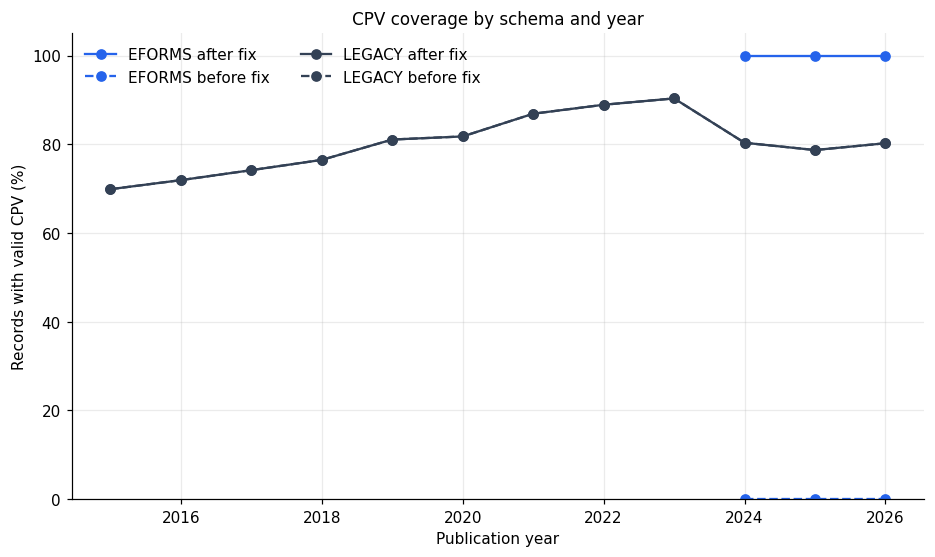

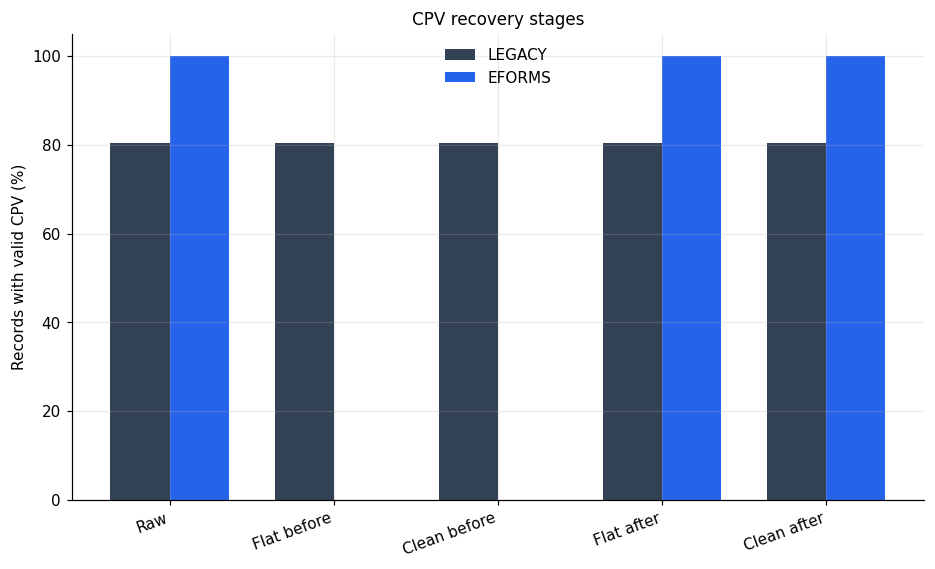

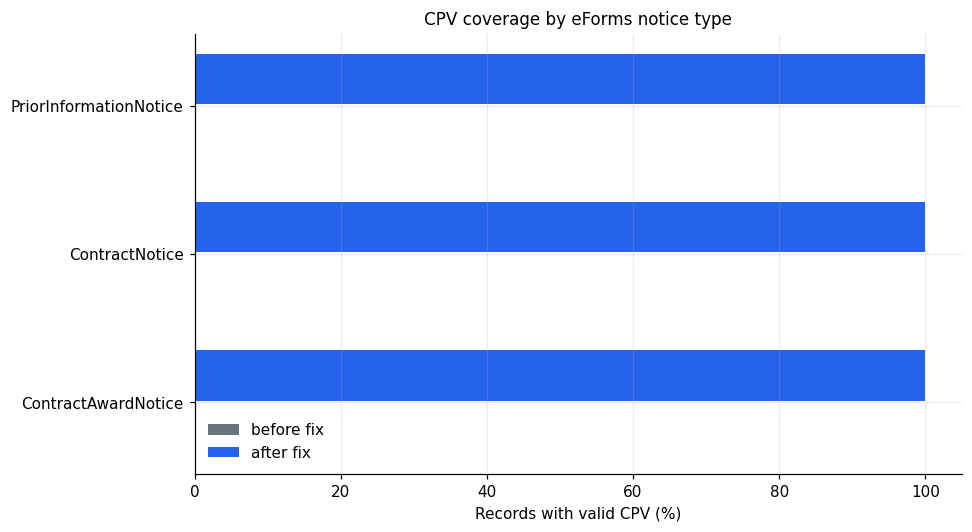

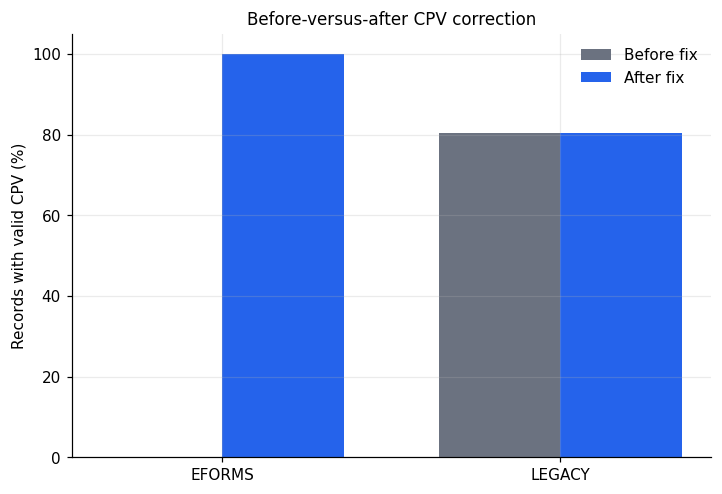

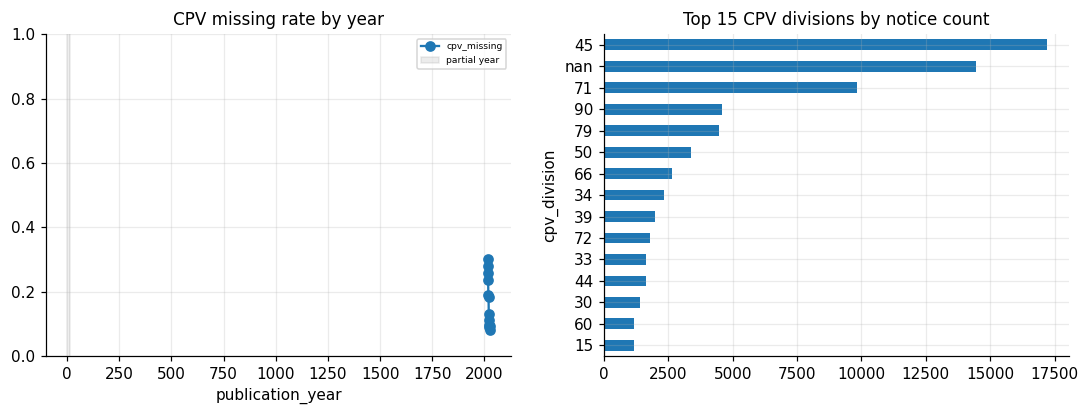

cpv_missing_rate                  0.170616
cpv_generic_rate_among_present    0.071411
dtype: float64

Wrote eForms CPV audit note: /home/senghakrou/survival-analysis/reports/generated/eforms_cpv_discontinuity_report.md


In [10]:
# --- eForms CPV discontinuity audit --------------------------------------
eforms_cpv_records, eforms_cpv_path_audit = build_eforms_cpv_audit(cfg.paths.raw_boamp_dir)
eforms_cpv_recovery = build_cpv_recovery_table(eforms_cpv_records)
eforms_cpv_sample_classification = build_eforms_cpv_sample(eforms_cpv_records)

eforms_cpv_path_audit.to_csv(SYN_CALIB_DIR / "eforms_cpv_path_audit.csv", index=False)
eforms_cpv_recovery.to_csv(SYN_CALIB_DIR / "eforms_cpv_recovery.csv", index=False)
eforms_cpv_sample_classification.to_csv(SYN_CALIB_DIR / "eforms_cpv_sample_classification.csv", index=False)

# Direct reconciliation against the corrected prepared table written by notebook 01 / current extractor.
prepared_cpv_by_schema = common.groupby("schema_family")["cpv_clean"].apply(lambda s: s.notna().mean())
audit_after_by_schema = eforms_cpv_recovery.query(
    "breakdown == 'schema_family' and stage == 'cleaned_prepared_after_fix'"
).set_index("schema_family")["p_cpv_available"]
for schema in ["EFORMS", "LEGACY"]:
    assert np.isclose(prepared_cpv_by_schema[schema], audit_after_by_schema[schema]), \
        f"prepared CPV coverage for {schema} does not match raw-audit after-fix recovery"

# Compact stage table used in the narrative and provenance inventory.
eforms_cpv_stage_summary = eforms_cpv_recovery.query(
    "breakdown == 'schema_family' and stage in ['raw_source', 'cleaned_prepared_before_fix', 'cleaned_prepared_after_fix']"
)[[
    "schema_family", "stage", "n_records", "n_cpv_available", "p_cpv_available",
    "n_multiple_cpv_after_fix", "n_cpv_present_parser_missed_before_fix",
    "n_genuinely_absent_after_fix",
]].sort_values(["schema_family", "stage"])

eforms_before_rate = cpv_stage_rate(eforms_cpv_recovery, "EFORMS", "cleaned_prepared_before_fix")
eforms_after_rate = cpv_stage_rate(eforms_cpv_recovery, "EFORMS", "cleaned_prepared_after_fix")
legacy_after_rate = cpv_stage_rate(eforms_cpv_recovery, "LEGACY", "cleaned_prepared_after_fix")
eforms_n = int(eforms_cpv_records["schema_family"].eq("EFORMS").sum())
eforms_missed_before = int(
    (eforms_cpv_records["schema_family"].eq("EFORMS")
     & eforms_cpv_records["raw_cpv_available"]
     & eforms_cpv_records["cleaned_before_fix_cpv"].isna()).sum()
)
eforms_absent_after = int(
    (eforms_cpv_records["schema_family"].eq("EFORMS")
     & ~eforms_cpv_records["raw_cpv_available"]
     & eforms_cpv_records["cleaned_after_fix_cpv"].isna()).sum()
)
eforms_multiple_after = int(
    eforms_cpv_records.loc[eforms_cpv_records["schema_family"].eq("EFORMS"), "multiple_cpv_after_fix"].sum()
)

print(
    f"eForms CPV: before={eforms_before_rate:.1%}, after={eforms_after_rate:.1%}; "
    f"old parser missed {eforms_missed_before:,}/{eforms_n:,} raw-present eForms records."
)
display(eforms_cpv_stage_summary)
display(eforms_cpv_path_audit.head(12))
display(eforms_cpv_sample_classification.head(12))

# --- Figures requested in the adaptive task --------------------------------
cpv_colors = {"before": "#6b7280", "after": "#2563eb", "legacy": "#334155", "eforms": "#2563eb"}

by_year = []
for label, col in [
    ("before fix", "cleaned_before_fix_cpv"),
    ("after fix", "cleaned_after_fix_cpv"),
]:
    tmp = (
        eforms_cpv_records.assign(available=eforms_cpv_records[col].notna())
        .groupby(["publication_year", "schema_family"], dropna=False)["available"]
        .agg(n_records="size", p_cpv_available="mean")
        .reset_index()
    )
    tmp["series"] = label
    by_year.append(tmp)
cpv_coverage_by_schema_year = pd.concat(by_year, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
for (schema, series), group in cpv_coverage_by_schema_year.groupby(["schema_family", "series"]):
    style = "-" if series == "after fix" else "--"
    color = cpv_colors["eforms"] if schema == "EFORMS" else cpv_colors["legacy"]
    ax.plot(group["publication_year"], group["p_cpv_available"] * 100,
            marker="o", linestyle=style, color=color, label=f"{schema} {series}")
ax.set_title("CPV coverage by schema and year")
ax.set_ylabel("Records with valid CPV (%)")
ax.set_xlabel("Publication year")
ax.set_ylim(0, 105)
ax.legend(ncol=2, frameon=False)
plt.show()
save_cpv_figure(fig, "cpv_coverage_by_schema_year")

stage_order = [
    "raw_source", "flattened_before_fix", "cleaned_prepared_before_fix",
    "flattened_after_fix", "cleaned_prepared_after_fix",
]
stage_labels = ["Raw", "Flat before", "Clean before", "Flat after", "Clean after"]
stage_df = eforms_cpv_recovery.query("breakdown == 'schema_family'")[["schema_family", "stage", "p_cpv_available"]]
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(stage_order))
width = 0.36
for i, schema in enumerate(["LEGACY", "EFORMS"]):
    vals = (
        stage_df.loc[stage_df["schema_family"].eq(schema)]
        .set_index("stage").reindex(stage_order)["p_cpv_available"].fillna(0) * 100
    )
    ax.bar(x + (-width / 2 if i == 0 else width / 2), vals, width=width, label=schema,
           color=cpv_colors["legacy" if schema == "LEGACY" else "eforms"])
ax.set_title("CPV recovery stages")
ax.set_ylabel("Records with valid CPV (%)")
ax.set_xticks(x, stage_labels, rotation=20, ha="right")
ax.set_ylim(0, 105)
ax.legend(frameon=False)
plt.show()
save_cpv_figure(fig, "cpv_recovery_stages")

plot_parts = []
for label, col in [("before fix", "cleaned_before_fix_cpv"), ("after fix", "cleaned_after_fix_cpv")]:
    tmp = (
        eforms_cpv_records.loc[eforms_cpv_records["schema_family"].eq("EFORMS")]
        .assign(available=lambda d: d[col].notna())
        .groupby("eforms_notice_type", dropna=False)["available"]
        .agg(n_records="size", p_cpv_available="mean")
        .reset_index()
    )
    tmp["series"] = label
    plot_parts.append(tmp)
eforms_cpv_by_notice_type = pd.concat(plot_parts, ignore_index=True)
pivot = (
    eforms_cpv_by_notice_type.pivot(index="eforms_notice_type", columns="series", values="p_cpv_available")
    .fillna(0)
    .sort_values("after fix", ascending=True)
)
fig, ax = plt.subplots(figsize=(9, 5.2))
y = np.arange(len(pivot))
ax.barh(y - 0.18, pivot.get("before fix", 0) * 100, height=0.34, color=cpv_colors["before"], label="before fix")
ax.barh(y + 0.18, pivot.get("after fix", 0) * 100, height=0.34, color=cpv_colors["after"], label="after fix")
ax.set_title("CPV coverage by eForms notice type")
ax.set_xlabel("Records with valid CPV (%)")
ax.set_yticks(y, pivot.index)
ax.set_xlim(0, 105)
ax.legend(frameon=False)
plt.show()
save_cpv_figure(fig, "cpv_coverage_by_eforms_notice_type")

compare_parts = []
for label, col in [("Before fix", "cleaned_before_fix_cpv"), ("After fix", "cleaned_after_fix_cpv")]:
    tmp = (
        eforms_cpv_records.assign(available=eforms_cpv_records[col].notna())
        .groupby("schema_family", dropna=False)["available"]
        .agg(n_records="size", p_cpv_available="mean")
        .reset_index()
    )
    tmp["series"] = label
    compare_parts.append(tmp)
cpv_before_after = pd.concat(compare_parts, ignore_index=True)
pivot = cpv_before_after.pivot(index="schema_family", columns="series", values="p_cpv_available").fillna(0)
fig, ax = plt.subplots(figsize=(7.5, 5))
schemas = list(pivot.index)
x = np.arange(len(schemas))
ax.bar(x - 0.18, pivot["Before fix"] * 100, width=0.36, color=cpv_colors["before"], label="Before fix")
ax.bar(x + 0.18, pivot["After fix"] * 100, width=0.36, color=cpv_colors["after"], label="After fix")
ax.set_title("Before-versus-after CPV correction")
ax.set_ylabel("Records with valid CPV (%)")
ax.set_xticks(x, schemas)
ax.set_ylim(0, 105)
ax.legend(frameon=False)
plt.show()
save_cpv_figure(fig, "cpv_before_after_correction")

# --- Existing CPV-quality calibration, now against corrected prepared data ---
cpv_missing_rate = common["cpv_missing"].astype(bool).mean()
cpv_generic_rate_among_present = common.loc[~common["cpv_missing"].astype(bool), "cpv_generic_flag"].astype(bool).mean()

cpv_summary = pd.Series({
    "cpv_missing_rate": cpv_missing_rate,
    "cpv_generic_rate_among_present": cpv_generic_rate_among_present,
})
cpv_summary.to_csv(SYN_CALIB_DIR / "calib_cpv_quality_summary.csv")

CPV_DIMS = ["publication_year", "schema_family", "notice_type_normalized", "dept_primary",
            "buyer_activity_tier", "buyer_identifier_source"]
rows = []
for dim in CPV_DIMS:
    g = common.groupby(dim)
    tmp = pd.DataFrame({
        "missing_rate": g["cpv_missing"].apply(lambda s: s.astype(bool).mean()),
        "n": g.size(),
    })
    tmp["dim"] = dim
    tmp = tmp.reset_index().rename(columns={dim: "value"})
    if dim == "publication_year":
        tmp["year_status"] = tmp["value"].map(lambda y: "PARTIAL" if y in PARTIAL_YEARS else "FULL")
    else:
        tmp["year_status"] = "n/a"
    rows.append(tmp)
cpv_missing_by_conditioning = pd.concat(rows, ignore_index=True)
cpv_missing_by_conditioning.to_csv(SYN_CALIB_DIR / "calib_cpv_missingness_by_conditioning.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
cpv_missing_by_year = common.groupby("publication_year")["cpv_missing"].apply(lambda s: s.astype(bool).mean())
cpv_missing_by_year.plot(ax=axes[0], marker="o")
axes[0].set_ylim(0, 1); axes[0].set_title("CPV missing rate by year")
shade_partial_years(axes[0], cpv_missing_by_year.index)
cpv_division_coverage["n_notices"].sort_values(ascending=False).head(15).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 15 CPV divisions by notice count")
plt.show()
save_figure(fig, "calib_cpv_quality_by_division_year", cfg)

display(cpv_summary)

# Notebook-owned short technical note for the adaptive-task output.
eforms_notice_type_after = (
    eforms_cpv_by_notice_type.loc[eforms_cpv_by_notice_type["series"].eq("after fix")]
    .sort_values("p_cpv_available", ascending=False)
)
eforms_notice_lines = "\n".join(
    f"- {row.eforms_notice_type}: {row.p_cpv_available:.1%} ({int(row.n_records):,} records)"
    for row in eforms_notice_type_after.itertuples()
)
eforms_cpv_report = f"""# eForms CPV Discontinuity Audit

## Technical Summary

The approximately-zero eForms CPV coverage is a parser discontinuity, not source-level missingness. The pre-fix extractor only accepted 8-digit values whose JSON path contained `cpv`; eForms stores CPV under UBL commodity classification paths such as `MainCommodityClassification/ItemClassificationCode`, so those valid codes were skipped.

After the extractor correction, eForms cleaned CPV coverage rises from {eforms_before_rate:.1%} to {eforms_after_rate:.1%}. Legacy coverage remains {legacy_after_rate:.1%}, unchanged except for normal source-level missingness. Among {eforms_n:,} eForms records, {eforms_missed_before:,} had raw CPV that the old parser missed; {eforms_absent_after:,} still appear genuinely absent after correction; and {eforms_multiple_after:,} carry multiple CPV codes after recovery.

## Evidence

- Raw eForms records contain valid CPV codes under `cbc:ItemClassificationCode/#text`, usually within `MainCommodityClassification` or `AdditionalCommodityClassification`.
- The recovery is narrow: other 8-digit eForms leaves, such as monetary amounts and reference IDs, remain excluded from CPV extraction.
- Multiple-CPV handling is preserved as a semicolon-delimited candidate list in the flattened data; the prepared corpus keeps the first valid token as `cpv_clean`, as before.

## eForms Notice-Type Coverage After Correction

{eforms_notice_lines}

## Outputs

- `reports/tables/synthetic_calibration/eforms_cpv_path_audit.csv`
- `reports/tables/synthetic_calibration/eforms_cpv_recovery.csv`
- `reports/tables/synthetic_calibration/eforms_cpv_sample_classification.csv`
- `reports/figures/synthetic_calibration/cpv/`

## Limitation

Downstream candidate-pair, scoring, linkage, survival, and calibration outputs that depend on CPV should be regenerated from the corrected flattened/prepared corpus before final modeling claims are frozen.
"""
eforms_cpv_report_path = cfg.paths.reports_generated / "eforms_cpv_discontinuity_report.md"
eforms_cpv_report_path.write_text(eforms_cpv_report, encoding="utf-8")
print("Wrote eForms CPV audit note:", eforms_cpv_report_path)

add_provenance("eforms_cpv_parser_discontinuity", "eForms CPV parser discontinuity and recovery", "OBSERVABLE",
                f"{eforms_before_rate:.1%} -> {eforms_after_rate:.1%}", "rate",
                "raw source vs flattened vs cleaned prepared; by schema/year/eForms notice type",
                "data/raw/boamp/pdl/boamp_*.json", "donnees EFORMS ... ItemClassificationCode/#text",
                "notebook §8 recreates old path-containing-'cpv' parser, compares with current extractor, and validates against prepared cpv_clean",
                eforms_n, "8", "eforms_cpv_recovery.csv",
                "The old parser missed eForms UBL commodity-classification paths; after correction no eForms CPV is classified as genuinely absent in the current raw corpus. Downstream CPV-dependent linkage outputs still need regeneration.")
add_provenance("cpv_missing_rate", "CPV code missing rate", "OBSERVABLE", round(float(cpv_missing_rate), 4),
                "rate", "marginal + by year/schema/notice type/department/buyer activity/identifier source",
                "data/interim/boamp_common_prepared.csv", "cpv_missing,cpv_generic_flag",
                "src/boamp/data/prepare.py cpv cleaning after eForms ItemClassificationCode recovery; mean of boolean flags",
                n_total, "8", "calib_cpv_missingness_by_conditioning.csv",
                f"cpv_clean requires exact 8-digit format. Multiple CPV candidates are retained in the flattened candidate list but prepared cpv_clean uses the first valid token. {year_min} and {year_max} rows in the by-year breakdown are PARTIAL years.")

## 9. Duration quality

Computes this notebook's **own** full-corpus duration-completeness/plausibility rate
from the raw extracted `duration_raw` field. This is *not* the pipeline's commonly-cited
"82.7% imputed" figure — that number is computed only over the pipeline's eligible source
population (`notice_type_normalized == APPEL_OFFRE & is_digital_scope`), a small,
scope-restricted subset. A separate, clearly-labeled panel below reproduces that
scope-conditioned view for comparison, so the two numbers are never conflated.

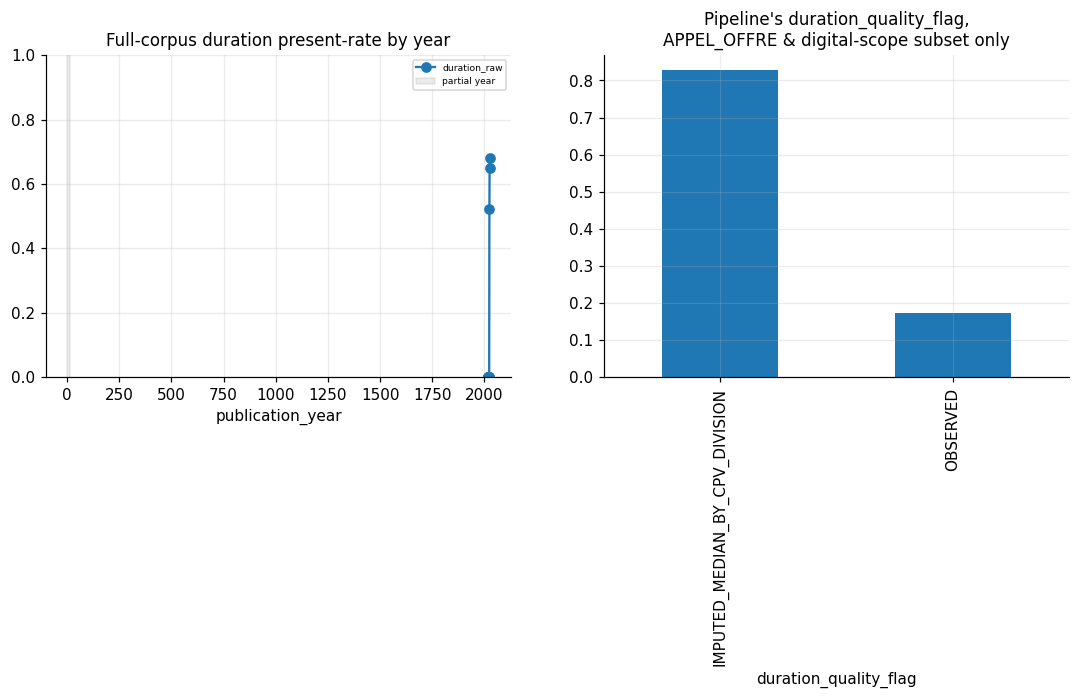

Full corpus: duration observed for 13.6% of notices (0.14% of all notices have an out-of-[1,120]-month value).
Pipeline's own eligible-source scope (n=3380): 17.3% OBSERVED, rest imputed/out-of-range.


In [11]:
duration_present_rate = common["duration_raw"].notna().mean()
in_range = common["duration_raw"].between(cfg.pipeline.duration.min_plausible_months,
                                           cfg.pipeline.duration.max_plausible_months)
duration_out_of_range_rate = (common["duration_raw"].notna() & ~in_range).mean()

duration_summary = pd.Series({
    "duration_present_rate_full_corpus": duration_present_rate,
    "duration_out_of_range_rate_full_corpus": duration_out_of_range_rate,
})
duration_summary.to_csv(SYN_CALIB_DIR / "calib_duration_quality_summary.csv")

DUR_DIMS = ["publication_year", "schema_family", "notice_type_normalized", "cpv_division", "buyer_activity_tier"]
rows = []
for dim in DUR_DIMS:
    g = common.groupby(dim)
    tmp = pd.DataFrame({"present_rate": g["duration_raw"].apply(lambda s: s.notna().mean()), "n": g.size()})
    tmp["dim"] = dim
    tmp = tmp.reset_index().rename(columns={dim: "value"})
    if dim == "publication_year":
        tmp["year_status"] = tmp["value"].map(lambda y: "PARTIAL" if y in PARTIAL_YEARS else "FULL")
    else:
        tmp["year_status"] = "n/a"
    rows.append(tmp)
duration_missingness_by_conditioning = pd.concat(rows, ignore_index=True)
duration_missingness_by_conditioning.to_csv(
    SYN_CALIB_DIR / "calib_duration_missingness_by_conditioning.csv", index=False)

oor_examples = common.loc[common["duration_raw"].notna() & ~in_range,
                           ["notice_id", "duration_raw", "cpv_division", "notice_type_normalized"]].head(30)
oor_examples.to_csv(SYN_CALIB_DIR / "calib_duration_out_of_range_examples.csv", index=False)

ao_mask = (common["notice_type_normalized"] == "APPEL_OFFRE") & common["is_digital_scope"]
pipeline_scope_flags = common.loc[ao_mask, "duration_quality_flag"].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
duration_present_by_year = common.groupby("publication_year")["duration_raw"].apply(lambda s: s.notna().mean())
duration_present_by_year.plot(ax=axes[0], marker="o")
axes[0].set_ylim(0, 1); axes[0].set_title("Full-corpus duration present-rate by year")
shade_partial_years(axes[0], duration_present_by_year.index)
pipeline_scope_flags.plot(kind="bar", ax=axes[1])
axes[1].set_title("Pipeline's duration_quality_flag,\nAPPEL_OFFRE & digital-scope subset only")
plt.show()
save_figure(fig, "calib_duration_quality_by_conditioning", cfg)

print(f"Full corpus: duration observed for {duration_present_rate:.1%} of notices "
      f"({duration_out_of_range_rate:.2%} of all notices have an out-of-[1,120]-month value).")
print(f"Pipeline's own eligible-source scope (n={ao_mask.sum()}): "
      f"{pipeline_scope_flags.get('OBSERVED', 0):.1%} OBSERVED, rest imputed/out-of-range.")

add_provenance("duration_present_rate_full_corpus", "Duration field present, full corpus",
                "OBSERVABLE", round(float(duration_present_rate), 4), "rate", "marginal + conditional",
                "data/interim/boamp_common_prepared.csv", "duration_raw",
                "notna mean, full corpus (not scope-filtered)", n_total, "9",
                "calib_duration_quality_summary.csv",
                "Distinct from the pipeline's 82.7%-imputed figure, which is computed only over the "
                f"APPEL_OFFRE & digital-scope eligible-source subset, not the full corpus. {year_min} and "
                f"{year_max} rows in the by-year breakdown are PARTIAL years.")

## 10. Procurement-text characteristics

Length/token-count distributions of the cleaned contract object (`objet_clean`),
missingness, an independently-fitted top-n-gram profile (a fresh `CountVectorizer`,
*not* the linkage pipeline's fitted TF-IDF vectorizer), and an **exact**-duplicate-text
rate (`duplicated(keep=False)` on the literal string) as a simple proxy for
template/boilerplate language that increases candidate ambiguity. This is a lower bound
on template reuse, not a near-duplicate (fuzzy/semantic-similarity) rate — no
near-duplicate detector is run anywhere in this notebook.

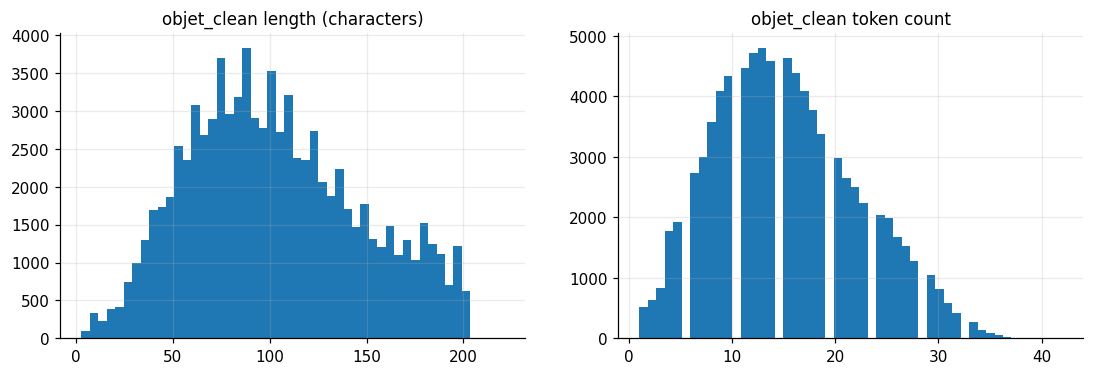

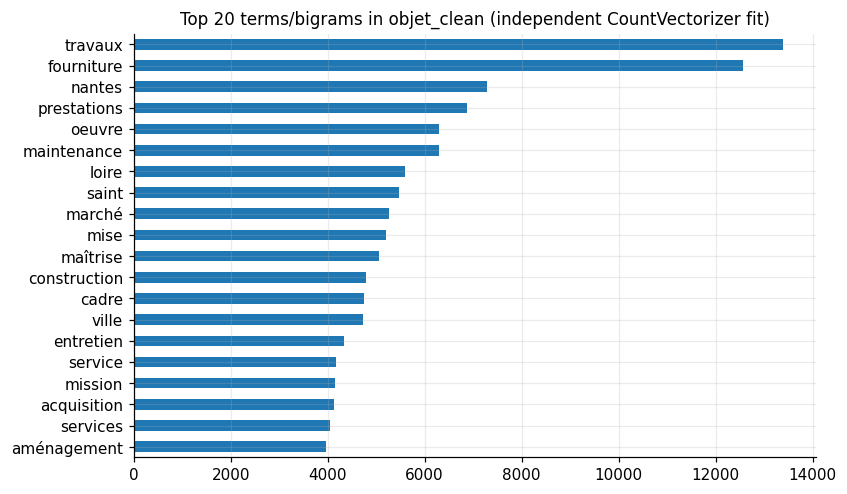

Text missing for 0.0% of notices. Exact-duplicate objet_clean rate among non-missing text: 51.4% (n=84,622) — a lower bound on template reuse.


In [12]:
text_missing_rate = common["objet_clean"].isna().mean()
text_len_stats = common["text_length"].describe()
token_stats = common["token_count"].describe()

txt = common["objet_clean"].dropna()
exact_dup_rate = txt.duplicated(keep=False).mean()

from sklearn.feature_extraction.text import CountVectorizer
FR_STOPWORDS = ["de", "la", "le", "les", "des", "du", "et", "en", "pour", "un", "une",
                "à", "au", "aux", "d", "l", "dans", "sur", "avec", "par"]
vec = CountVectorizer(max_features=30, ngram_range=(1, 2), min_df=5, stop_words=FR_STOPWORDS)
X = vec.fit_transform(txt.values)
term_freqs = pd.Series(np.asarray(X.sum(axis=0)).ravel(), index=vec.get_feature_names_out()) \
               .sort_values(ascending=False)

text_summary = pd.Series({
    "text_missing_rate": text_missing_rate,
    "exact_duplicate_text_rate": exact_dup_rate,
    "median_text_length_chars": text_len_stats["50%"],
    "median_token_count": token_stats["50%"],
})
text_summary.to_csv(SYN_CALIB_DIR / "calib_text_characteristics_summary.csv")
term_freqs.rename("frequency").to_csv(SYN_CALIB_DIR / "calib_text_top_ngrams.csv")
pd.Series({"exact_duplicate_rate": exact_dup_rate, "n_non_missing": len(txt)}) \
  .to_csv(SYN_CALIB_DIR / "calib_text_exact_duplicate_rate.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(common["text_length"].dropna(), bins=50)
axes[0].set_title("objet_clean length (characters)")
axes[1].hist(common["token_count"].dropna(), bins=50)
axes[1].set_title("objet_clean token count")
plt.show()
save_figure(fig, "calib_text_length_token_distributions", cfg)

fig, ax = plt.subplots(figsize=(8, 5))
term_freqs.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 terms/bigrams in objet_clean (independent CountVectorizer fit)")
plt.show()
save_figure(fig, "calib_text_top_ngrams", cfg)

print(f"Text missing for {text_missing_rate:.1%} of notices. Exact-duplicate objet_clean rate "
      f"among non-missing text: {exact_dup_rate:.1%} (n={len(txt):,}) — a lower bound on template reuse.")

add_provenance("text_exact_duplicate_rate", "Exact-duplicate objet_clean rate", "OBSERVABLE",
                round(float(exact_dup_rate), 4), "rate", "among non-missing text",
                "data/interim/boamp_common_prepared.csv", "objet_clean",
                "duplicated(keep=False).mean()", len(txt), "10",
                "calib_text_exact_duplicate_rate.csv",
                "Exact-string duplication only; near-duplicate detection via fuzzy/semantic similarity "
                "would find a higher rate (no such detector is run in this notebook). This is a lower "
                "bound on text-based candidate ambiguity, not an estimate of the true near-duplicate rate.")

## 10b. Provisional procurement notice families

A single procurement episode can generate several BOAMP publications: a call, one or
more corrections or modifications, an award notice, and sometimes cancellation or other
follow-up publications. These publication families are distinct from later procurement
cycles for a similar need. This section constructs provisional notice families with a
conservative graph rule: explicit linked-notice references first, then bounded same-buyer
exact-text and high-similarity edges when dates and CPV are compatible.

The output is a generator-facing lifecycle layer: one latent procurement episode may
produce one or several observed BOAMP notices.

Constructed 57,417 provisional notice families; 22,445 have >1 notice and cover 49,651 notices.
Max family size: 13; call-to-award rows: 19,091.


,family_size,n_families,n_notices,p_families,p_notices
0,1,34972,34972,0.609088,0.413268
1,2,18976,37952,0.330494,0.448483
2,3,2549,7647,0.044395,0.090366
3,4,687,2748,0.011965,0.032473
4,5,158,790,0.002752,0.009336
5,6,49,294,0.000853,0.003474
6,7,7,49,0.000122,0.000579
7,8,11,88,0.000192,0.001040
8,9,3,27,0.000052,0.000319
9,10,2,20,0.000035,0.000236


,edge_type,source_role,target_role,n_edges,median_delay_days,p_same_buyer_key,p_same_cpv_clean,p_same_cpv_division,median_text_similarity
1,award_relationship,CALL,AWARD,18221,130.0,0.954009,0.911805,0.916854,NaN
8,award_reverse_lookup,CALL,AWARD,18075,129.0,0.954025,0.912033,0.917012,NaN
20,exact_text_duplicate,CALL,AWARD,11805,112.0,1.000000,0.896823,0.901482,1.000000
44,explicit_linked_notice,CALL,CORRECTION,5815,21.0,0.970249,0.748753,0.751849,NaN
23,exact_text_duplicate,CALL,CORRECTION,3094,20.0,1.000000,0.801228,0.804137,1.000000
3,award_relationship,CORRECTION,AWARD,2052,127.0,0.961501,0.925926,0.930799,NaN
12,award_reverse_lookup,CORRECTION,AWARD,2034,127.0,0.961160,0.925762,0.930678,NaN
63,high_text_similarity,CALL,CORRECTION,1452,19.0,1.000000,0.815427,0.823003,0.972913
28,exact_text_duplicate,CORRECTION,AWARD,964,105.0,1.000000,0.913900,0.919087,1.000000
21,exact_text_duplicate,CALL,CALL,953,44.0,1.000000,0.797482,0.852046,1.000000


count    19091.000000
mean       151.826882
std         88.849074
min       -167.000000
25%         99.000000
50%        132.000000
75%        180.000000
max       3342.000000
Name: call_to_award_days, dtype: float64

,pair_scope,n_pairs,median_text_similarity,p90_text_similarity,p_same_cpv_clean,p_same_cpv_division,p_both_cpv_present
0,outside_family_same_buyer_window,20000,0.015466,0.134445,0.011500,0.086750,0.690300
1,within_family,33912,1.000000,1.000000,0.853887,0.876976,0.883109


,lifecycle_role,schema_family,has_unresolved_reference,n_single_notice_families
0,AWARD,EFORMS,False,1106
1,AWARD,EFORMS,True,22
2,AWARD,LEGACY,False,1281
3,AWARD,LEGACY,True,775
4,CALL,EFORMS,False,2931
5,CALL,EFORMS,True,4
6,CALL,LEGACY,False,28648
7,CANCELLATION,LEGACY,True,4
8,CORRECTION,EFORMS,False,8
9,CORRECTION,EFORMS,True,2


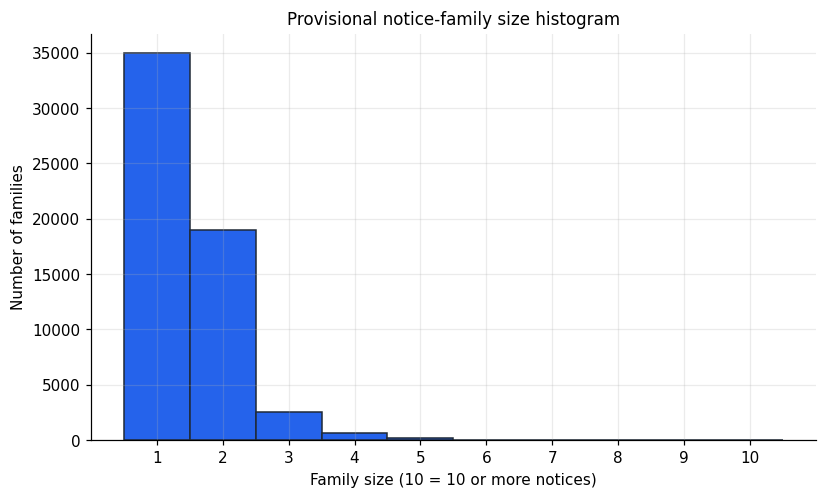

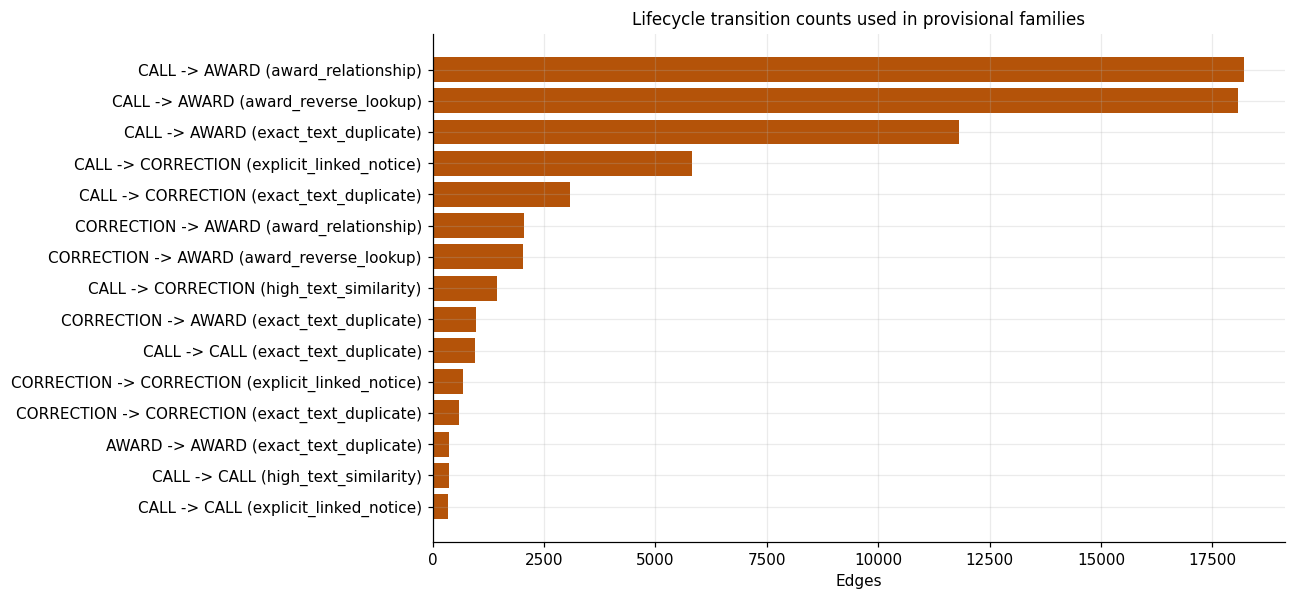

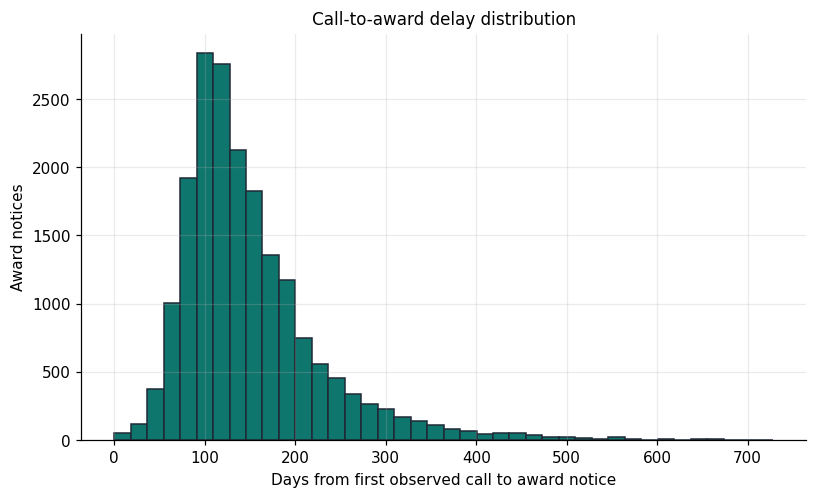

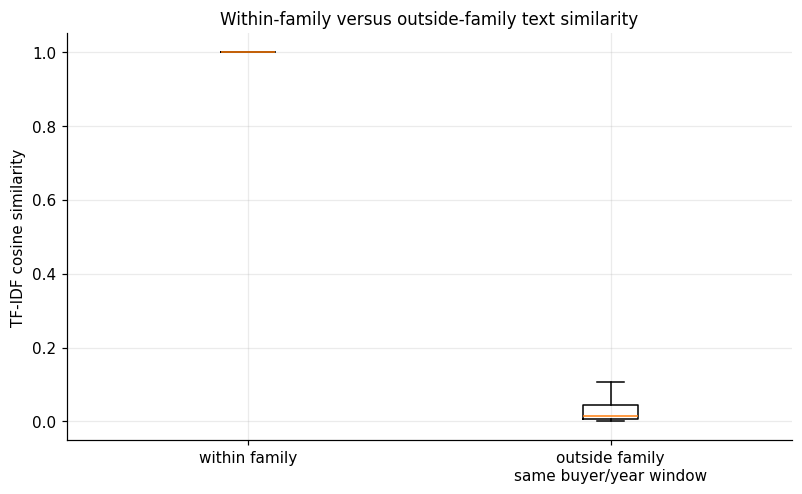

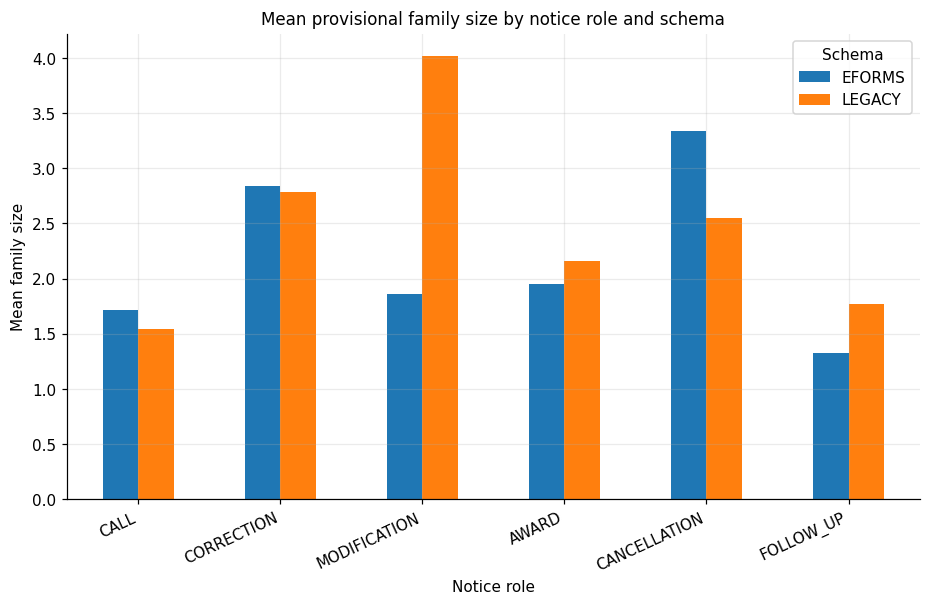

In [13]:
from itertools import combinations
from sklearn.feature_extraction.text import TfidfVectorizer

NOTICE_FAMILY_FIG_DIR = cfg.paths.reports_figures / "synthetic_calibration" / "notice_families"
NOTICE_FAMILY_FIG_DIR.mkdir(parents=True, exist_ok=True)
NOTICE_ID_RE = re.compile(r"\b\d{2,4}-\d+\b")


def save_notice_family_figure(fig, stem):
    paths = []
    for ext in ("png", "pdf"):
        out = NOTICE_FAMILY_FIG_DIR / f"{stem}.{ext}"
        fig.savefig(out, bbox_inches="tight", dpi=200)
        paths.append(str(out))
    plt.close(fig)
    return paths


def notice_lifecycle_role(row):
    etat = str(row.get("etat") or "").upper()
    nature_cat = str(row.get("nature_categorise") or "").lower()
    nature_label = str(row.get("nature_categorise_libelle") or "").lower()
    sousnature_label = str(row.get("sousnature_libelle") or "").lower()
    if etat == "ANNULATION" or nature_cat.startswith("annulation") or "annulation" in nature_label:
        return "CANCELLATION"
    if etat == "MODIFICATION" or nature_cat.startswith("modification") or "modification" in nature_label or "modification" in sousnature_label:
        return "MODIFICATION"
    if etat == "RECTIFICATIF" or nature_cat.startswith("rectificatif") or "rectificatif" in nature_label or "rectificatif" in sousnature_label:
        return "CORRECTION"
    if row.get("notice_type_normalized") == "ATTRIBUTION":
        return "AWARD"
    if row.get("notice_type_normalized") == "APPEL_OFFRE":
        return "CALL"
    return "FOLLOW_UP"


def cpv_compatible(row_a, row_b):
    cpv_a, cpv_b = row_a.get("cpv_clean"), row_b.get("cpv_clean")
    if pd.notna(cpv_a) and pd.notna(cpv_b):
        return cpv_a == cpv_b or str(cpv_a)[:2] == str(cpv_b)[:2]
    div_a, div_b = row_a.get("cpv_division"), row_b.get("cpv_division")
    if pd.notna(div_a) and pd.notna(div_b):
        return div_a == div_b
    return True


def build_notice_family_graph(df):
    work = df.copy()
    work["lifecycle_role"] = work.apply(notice_lifecycle_role, axis=1)
    notice_ids = set(work["notice_id"])
    idx_by_notice = {notice_id: idx for idx, notice_id in enumerate(work["notice_id"])}
    parent = list(range(len(work)))
    rank = [0] * len(work)
    edge_rows = []
    edge_seen = set()

    def find(idx):
        while parent[idx] != idx:
            parent[idx] = parent[parent[idx]]
            idx = parent[idx]
        return idx

    def union(a, b):
        root_a, root_b = find(a), find(b)
        if root_a == root_b:
            return False
        if rank[root_a] < rank[root_b]:
            root_a, root_b = root_b, root_a
        parent[root_b] = root_a
        if rank[root_a] == rank[root_b]:
            rank[root_a] += 1
        return True

    def add_edge(source_notice_id, target_notice_id, edge_type, evidence, text_similarity=np.nan):
        if source_notice_id not in idx_by_notice or target_notice_id not in idx_by_notice:
            return False
        if source_notice_id == target_notice_id:
            return False
        edge_key = (source_notice_id, target_notice_id, edge_type)
        if edge_key in edge_seen:
            return False
        edge_seen.add(edge_key)
        source_idx = idx_by_notice[source_notice_id]
        target_idx = idx_by_notice[target_notice_id]
        source = work.iloc[source_idx]
        target = work.iloc[target_idx]
        union(source_idx, target_idx)
        edge_rows.append({
            "source_notice_id": source_notice_id,
            "target_notice_id": target_notice_id,
            "edge_type": edge_type,
            "evidence": evidence,
            "source_role": source["lifecycle_role"],
            "target_role": target["lifecycle_role"],
            "source_date": source["publication_date"],
            "target_date": target["publication_date"],
            "delay_days": (target["publication_date"] - source["publication_date"]).days
            if pd.notna(source["publication_date"]) and pd.notna(target["publication_date"]) else np.nan,
            "same_buyer_key": source["buyer_key"] == target["buyer_key"],
            "same_cpv_clean": pd.notna(source["cpv_clean"]) and source["cpv_clean"] == target["cpv_clean"],
            "same_cpv_division": pd.notna(source["cpv_division"]) and source["cpv_division"] == target["cpv_division"],
            "text_similarity": text_similarity,
        })
        return True

    for row in work.itertuples(index=False):
        refs = set()
        for col in ["annonce_lie", "annonces_anterieures"]:
            val = getattr(row, col)
            if pd.notna(val):
                refs.update(NOTICE_ID_RE.findall(str(val)))
        for ref in refs:
            if ref in notice_ids:
                edge_type = "award_relationship" if row.lifecycle_role == "AWARD" else "explicit_linked_notice"
                add_edge(ref, row.notice_id, edge_type, "annonce_lie_or_annonces_anterieures")

    for row in work.loc[work["linked_attribution_notice_id"].notna()].itertuples(index=False):
        add_edge(row.notice_id, row.linked_attribution_notice_id,
                 "award_reverse_lookup", "prepare_common linked_attribution_notice_id")

    for _, group in work.dropna(subset=["buyer_key", "objet_normalized"]).groupby(
        ["buyer_key", "objet_normalized"], sort=False
    ):
        if len(group) < 2:
            continue
        ordered_rows = list(group.sort_values("publication_date").iterrows())
        for pos in range(len(ordered_rows) - 1):
            _, source = ordered_rows[pos]
            _, target = ordered_rows[pos + 1]
            if pd.isna(source["publication_date"]) or pd.isna(target["publication_date"]):
                continue
            days = (target["publication_date"] - source["publication_date"]).days
            if 0 <= days <= 180 and cpv_compatible(source, target):
                add_edge(source["notice_id"], target["notice_id"], "exact_text_duplicate",
                         "same buyer_key + exact objet_normalized within 180 days + CPV-compatible", 1.0)

    vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
    tfidf = vectorizer.fit_transform(work["objet_normalized"].fillna("").tolist())
    for _, group in work.dropna(subset=["buyer_key"]).groupby(["buyer_key", "cpv_division"], dropna=False, sort=False):
        if len(group) < 2:
            continue
        group = group.sort_values("publication_date")
        indices = group.index.to_numpy()
        for pos, source_idx in enumerate(indices):
            source = work.loc[source_idx]
            if not isinstance(source["objet_normalized"], str) or pd.isna(source["publication_date"]):
                continue
            checked = 0
            for target_idx in indices[pos + 1:min(pos + 13, len(indices))]:
                target = work.loc[target_idx]
                if pd.isna(target["publication_date"]):
                    continue
                days = (target["publication_date"] - source["publication_date"]).days
                if days > 60:
                    break
                if days < 0 or not isinstance(target["objet_normalized"], str):
                    continue
                if source["objet_normalized"] == target["objet_normalized"]:
                    continue
                similarity = float(tfidf[source_idx].multiply(tfidf[target_idx]).sum())
                checked += 1
                if similarity >= 0.86:
                    add_edge(source["notice_id"], target["notice_id"], "high_text_similarity",
                             "same buyer_key+CPV division within 60 days + TF-IDF cosine >= 0.86", similarity)
                if checked >= 8:
                    break

    roots = [find(i) for i in range(len(work))]
    family_ids = {root: f"NF{n:06d}" for n, root in enumerate(sorted(set(roots)), 1)}
    work["notice_family_id"] = [family_ids[root] for root in roots]
    return work, pd.DataFrame(edge_rows), tfidf


family_work, notice_family_edges, notice_family_tfidf = build_notice_family_graph(common)
common["lifecycle_role"] = family_work["lifecycle_role"]
common["notice_family_id"] = family_work["notice_family_id"]

notice_family_summary = common.groupby("notice_family_id").agg(
    family_size=("notice_id", "size"),
    n_calls=("lifecycle_role", lambda s: int((s == "CALL").sum())),
    n_corrections=("lifecycle_role", lambda s: int((s == "CORRECTION").sum())),
    n_modifications=("lifecycle_role", lambda s: int((s == "MODIFICATION").sum())),
    n_awards=("lifecycle_role", lambda s: int((s == "AWARD").sum())),
    n_cancellations=("lifecycle_role", lambda s: int((s == "CANCELLATION").sum())),
    n_followups=("lifecycle_role", lambda s: int((s == "FOLLOW_UP").sum())),
    first_date=("publication_date", "min"),
    last_date=("publication_date", "max"),
    n_schemas=("schema_family", "nunique"),
    n_notice_types=("notice_type_normalized", "nunique"),
    n_buyers=("buyer_key", "nunique"),
    n_cpv=("cpv_clean", "nunique"),
).reset_index()
notice_family_summary["family_span_days"] = (
    notice_family_summary["last_date"] - notice_family_summary["first_date"]
).dt.days
notice_family_summary["awards_per_call"] = np.where(
    notice_family_summary["n_calls"] > 0,
    notice_family_summary["n_awards"] / notice_family_summary["n_calls"],
    np.nan,
)
notice_family_summary["family_pattern"] = np.select(
    [
        (notice_family_summary["n_calls"] > 0) & (notice_family_summary["n_awards"] > 0),
        (notice_family_summary["n_calls"] > 0) & (notice_family_summary["n_awards"] == 0) & (notice_family_summary["family_size"] > 1),
        (notice_family_summary["n_awards"] > 0) & (notice_family_summary["n_calls"] == 0),
        notice_family_summary["family_size"] == 1,
    ],
    ["call_with_award", "call_with_lifecycle_updates_no_award", "award_without_observed_call", "single_notice"],
    default="other_multi_notice",
)

notice_family_size_distribution = (
    notice_family_summary["family_size"].value_counts().sort_index().rename_axis("family_size")
    .reset_index(name="n_families")
)
notice_family_size_distribution["n_notices"] = (
    notice_family_size_distribution["family_size"] * notice_family_size_distribution["n_families"]
)
notice_family_size_distribution["p_families"] = notice_family_size_distribution["n_families"] / len(notice_family_summary)
notice_family_size_distribution["p_notices"] = notice_family_size_distribution["n_notices"] / n_total

notice_lifecycle_transitions = notice_family_edges.groupby(
    ["edge_type", "source_role", "target_role"], dropna=False
).agg(
    n_edges=("source_notice_id", "size"),
    median_delay_days=("delay_days", "median"),
    p_same_buyer_key=("same_buyer_key", "mean"),
    p_same_cpv_clean=("same_cpv_clean", "mean"),
    p_same_cpv_division=("same_cpv_division", "mean"),
    median_text_similarity=("text_similarity", "median"),
).reset_index().sort_values("n_edges", ascending=False)

family_first_call = common.loc[common["lifecycle_role"].eq("CALL")].groupby("notice_family_id")["publication_date"].min()
call_to_award_delays = common.loc[common["lifecycle_role"].eq("AWARD"), [
    "notice_family_id", "notice_id", "publication_date", "schema_family", "buyer_key", "cpv_clean",
]].join(family_first_call.rename("first_call_date"), on="notice_family_id")
call_to_award_delays = call_to_award_delays.loc[call_to_award_delays["first_call_date"].notna()].copy()
call_to_award_delays["call_to_award_days"] = (
    call_to_award_delays["publication_date"] - call_to_award_delays["first_call_date"]
).dt.days
call_to_award_delays["call_to_award_months"] = call_to_award_delays["call_to_award_days"] / cfg.pipeline.run.month_days
call_to_award_delays["delay_flag"] = np.select(
    [call_to_award_delays["call_to_award_days"] < 0, call_to_award_delays["call_to_award_days"] > 730],
    ["NEGATIVE_DATE_ORDER", "OVER_24_MONTHS"],
    default="OK",
)

family_first_call = common.loc[common["lifecycle_role"].eq("CALL")].groupby("notice_family_id")["publication_date"].min()
correction_delays = common.loc[common["lifecycle_role"].isin(["CORRECTION", "MODIFICATION", "CANCELLATION"]), [
    "notice_family_id", "notice_id", "publication_date", "lifecycle_role", "schema_family",
]].join(family_first_call.rename("first_call_date"), on="notice_family_id")
correction_delays = correction_delays.loc[correction_delays["first_call_date"].notna()].copy()
correction_delays["delay_days"] = (correction_delays["publication_date"] - correction_delays["first_call_date"]).dt.days

# Pair-level within-family CPV and text similarity diagnostics.
pair_rows = []
for family_id, group in common.loc[common["notice_family_id"].isin(
    notice_family_summary.loc[notice_family_summary["family_size"].gt(1), "notice_family_id"]
)].groupby("notice_family_id", sort=False):
    indices = group.index.to_list()
    for idx_a, idx_b in combinations(indices, 2):
        a, b = common.loc[idx_a], common.loc[idx_b]
        pair_rows.append({
            "pair_scope": "within_family",
            "notice_family_id": family_id,
            "source_notice_id": a["notice_id"],
            "target_notice_id": b["notice_id"],
            "text_similarity": float(notice_family_tfidf[idx_a].multiply(notice_family_tfidf[idx_b]).sum()),
            "same_cpv_clean": pd.notna(a["cpv_clean"]) and a["cpv_clean"] == b["cpv_clean"],
            "same_cpv_division": pd.notna(a["cpv_division"]) and a["cpv_division"] == b["cpv_division"],
            "both_cpv_present": pd.notna(a["cpv_clean"]) and pd.notna(b["cpv_clean"]),
        })

rng = np.random.default_rng(20260713)
outside_rows = []
for _, group in common.dropna(subset=["buyer_key"]).groupby("buyer_key", sort=False):
    if len(group) < 2:
        continue
    group = group.sort_values("publication_date")
    indices = group.index.to_numpy()
    for pos, idx_a in enumerate(indices[:-1]):
        a = common.loc[idx_a]
        candidates = []
        for idx_b in indices[pos + 1:min(pos + 30, len(indices))]:
            b = common.loc[idx_b]
            if a["notice_family_id"] == b["notice_family_id"]:
                continue
            if pd.isna(a["publication_date"]) or pd.isna(b["publication_date"]):
                continue
            days = (b["publication_date"] - a["publication_date"]).days
            if days > 365:
                break
            if days >= 0:
                candidates.append(idx_b)
        if candidates and len(outside_rows) < 20000:
            idx_b = int(rng.choice(candidates))
            b = common.loc[idx_b]
            outside_rows.append({
                "pair_scope": "outside_family_same_buyer_window", "notice_family_id": np.nan,
                "source_notice_id": a["notice_id"], "target_notice_id": b["notice_id"],
                "text_similarity": float(notice_family_tfidf[idx_a].multiply(notice_family_tfidf[idx_b]).sum()),
                "same_cpv_clean": pd.notna(a["cpv_clean"]) and a["cpv_clean"] == b["cpv_clean"],
                "same_cpv_division": pd.notna(a["cpv_division"]) and a["cpv_division"] == b["cpv_division"],
                "both_cpv_present": pd.notna(a["cpv_clean"]) and pd.notna(b["cpv_clean"]),
            })
        if len(outside_rows) >= 20000:
            break
    if len(outside_rows) >= 20000:
        break

notice_family_similarity_pairs = pd.concat(
    [pd.DataFrame(pair_rows), pd.DataFrame(outside_rows)], ignore_index=True
)
notice_family_similarity_summary = notice_family_similarity_pairs.groupby("pair_scope").agg(
    n_pairs=("source_notice_id", "size"),
    median_text_similarity=("text_similarity", "median"),
    p90_text_similarity=("text_similarity", lambda s: s.quantile(0.90)),
    p_same_cpv_clean=("same_cpv_clean", "mean"),
    p_same_cpv_division=("same_cpv_division", "mean"),
    p_both_cpv_present=("both_cpv_present", "mean"),
).reset_index()
notice_family_cpv_agreement = notice_family_similarity_summary[[
    "pair_scope", "n_pairs", "p_same_cpv_clean", "p_same_cpv_division", "p_both_cpv_present"
]].copy()

singletons = common.groupby("notice_family_id").filter(lambda g: len(g) == 1).copy()
singletons["has_unresolved_reference"] = singletons[["annonce_lie", "annonces_anterieures"]].notna().any(axis=1)
notice_family_unresolved_patterns = singletons.groupby(
    ["lifecycle_role", "schema_family", "has_unresolved_reference"], dropna=False
).size().reset_index(name="n_single_notice_families")

notice_family_summary.to_csv(SYN_CALIB_DIR / "notice_family_summary.csv", index=False)
notice_family_edges.to_csv(SYN_CALIB_DIR / "notice_family_edges.csv", index=False)
notice_family_size_distribution.to_csv(SYN_CALIB_DIR / "notice_family_size_distribution.csv", index=False)
notice_lifecycle_transitions.to_csv(SYN_CALIB_DIR / "notice_lifecycle_transitions.csv", index=False)
call_to_award_delays.to_csv(SYN_CALIB_DIR / "call_to_award_delays.csv", index=False)
correction_delays.to_csv(SYN_CALIB_DIR / "notice_family_correction_delays.csv", index=False)
notice_family_similarity_summary.to_csv(SYN_CALIB_DIR / "notice_family_text_similarity_comparison.csv", index=False)
notice_family_cpv_agreement.to_csv(SYN_CALIB_DIR / "notice_family_cpv_agreement.csv", index=False)
notice_family_unresolved_patterns.to_csv(SYN_CALIB_DIR / "notice_family_unresolved_patterns.csv", index=False)

multi_family_count = int((notice_family_summary["family_size"] > 1).sum())
multi_notice_count = int(notice_family_summary.loc[notice_family_summary["family_size"] > 1, "family_size"].sum())
print(f"Constructed {len(notice_family_summary):,} provisional notice families; "
      f"{multi_family_count:,} have >1 notice and cover {multi_notice_count:,} notices.")
print(f"Max family size: {int(notice_family_summary['family_size'].max())}; "
      f"call-to-award rows: {len(call_to_award_delays):,}.")
display(notice_family_size_distribution.head(12))
display(notice_lifecycle_transitions.head(12))
display(call_to_award_delays["call_to_award_days"].describe())
display(notice_family_similarity_summary)
display(notice_family_unresolved_patterns.head(12))

# Figure 1: family-size histogram.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
hist_values = notice_family_summary["family_size"].clip(upper=10)
ax.hist(hist_values, bins=np.arange(1, 12) - 0.5, color="#2563eb", edgecolor="#1f2937")
ax.set_title("Provisional notice-family size histogram")
ax.set_xlabel("Family size (10 = 10 or more notices)")
ax.set_ylabel("Number of families")
ax.set_xticks(range(1, 11))
plt.show()
save_notice_family_figure(fig, "notice_family_size_histogram")

# Figure 2: lifecycle transition counts.
transition_plot = notice_lifecycle_transitions.assign(
    transition=lambda d: d["source_role"] + " -> " + d["target_role"] + " (" + d["edge_type"] + ")"
).sort_values("n_edges", ascending=False).head(15).sort_values("n_edges")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(transition_plot["transition"], transition_plot["n_edges"], color="#b45309")
ax.set_title("Lifecycle transition counts used in provisional families")
ax.set_xlabel("Edges")
plt.show()
save_notice_family_figure(fig, "notice_lifecycle_transition_counts")

# Figure 3: call-to-award delay distribution.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
delay_plot = call_to_award_delays.loc[call_to_award_delays["delay_flag"].eq("OK"), "call_to_award_days"]
ax.hist(delay_plot, bins=40, color="#0f766e", edgecolor="#1f2937")
ax.set_title("Call-to-award delay distribution")
ax.set_xlabel("Days from first observed call to award notice")
ax.set_ylabel("Award notices")
plt.show()
save_notice_family_figure(fig, "notice_call_to_award_delay_distribution")

# Figure 4: within-family versus outside-family text similarity.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_data = [
    notice_family_similarity_pairs.loc[notice_family_similarity_pairs["pair_scope"].eq("within_family"), "text_similarity"].dropna(),
    notice_family_similarity_pairs.loc[notice_family_similarity_pairs["pair_scope"].eq("outside_family_same_buyer_window"), "text_similarity"].dropna(),
]
ax.boxplot(plot_data, tick_labels=["within family", "outside family\nsame buyer/year window"], showfliers=False)
ax.set_title("Within-family versus outside-family text similarity")
ax.set_ylabel("TF-IDF cosine similarity")
plt.show()
save_notice_family_figure(fig, "notice_family_text_similarity_within_outside")

# Figure 5: family-size distribution by notice role and schema.
role_schema = common.copy()
role_schema["notice_family_size"] = role_schema["notice_family_id"].map(
    notice_family_summary.set_index("notice_family_id")["family_size"]
)
role_schema_summary = role_schema.groupby(["schema_family", "lifecycle_role"], dropna=False).agg(
    mean_family_size=("notice_family_size", "mean"),
    n_notices=("notice_id", "size"),
).reset_index()
role_schema_summary.to_csv(SYN_CALIB_DIR / "notice_family_size_by_type_schema.csv", index=False)
fig, ax = plt.subplots(figsize=(10, 5.5))
plot = role_schema_summary.pivot(index="lifecycle_role", columns="schema_family", values="mean_family_size").fillna(0)
plot.loc[[r for r in ["CALL", "CORRECTION", "MODIFICATION", "AWARD", "CANCELLATION", "FOLLOW_UP"] if r in plot.index]].plot(kind="bar", ax=ax)
ax.set_title("Mean provisional family size by notice role and schema")
ax.set_xlabel("Notice role")
ax.set_ylabel("Mean family size")
ax.legend(title="Schema")
plt.xticks(rotation=25, ha="right")
plt.show()
save_notice_family_figure(fig, "notice_family_size_by_notice_type_schema")

add_provenance("notice_family_size_distribution", "Provisional notice-family size distribution", "OBSERVABLE",
                "see table", "count/share", "by provisional notice family",
                "data/interim/boamp_common_prepared.csv", "notice_id,annonce_lie,annonces_anterieures,buyer_key,publication_date,objet_normalized,cpv_clean,notice_type_normalized,etat",
                "graph components from explicit references, award links, bounded exact-text edges, and bounded high-similarity edges",
                len(notice_family_summary), "10b", "notice_family_size_distribution.csv",
                "Provisional lifecycle grouping only: designed to represent one procurement episode producing one or several observed notices, not later cycles for a similar need.")
add_provenance("notice_lifecycle_transition_counts", "Lifecycle transition counts within provisional notice families", "OBSERVABLE",
                "see table", "edge count", "by source role, target role, edge type",
                "data/interim/boamp_common_prepared.csv", "nature_categorise,etat,annonce_lie,annonces_anterieures,linked_attribution_notice_id",
                "edge table grouped by lifecycle role and edge evidence", len(notice_family_edges), "10b",
                "notice_lifecycle_transitions.csv",
                "Role labels are derived from BOAMP notice status/category fields and collapse rare follow-up forms into FOLLOW_UP.")
add_provenance("call_to_award_delay_distribution", "Call-to-award delay distribution in provisional notice families", "OBSERVABLE",
                "see table", "days/months", "award notices with an observed call in the same provisional family",
                "data/interim/boamp_common_prepared.csv", "publication_date,notice_type_normalized,notice_family_id",
                "award publication date minus earliest CALL publication date in the same provisional family",
                len(call_to_award_delays), "10b", "call_to_award_delays.csv",
                "Delays use first observed call in the corpus, so missing historical calls can make some award-linked families look incomplete; negative or >24-month delays are flagged, not dropped.")
add_provenance("notice_family_text_cpv_agreement", "Text similarity and CPV agreement within provisional notice families", "OBSERVABLE",
                "see table", "similarity/share", "within-family pairs vs outside-family same-buyer window sample",
                "data/interim/boamp_common_prepared.csv", "objet_normalized,cpv_clean,cpv_division,notice_family_id,buyer_key,publication_date",
                "TF-IDF cosine similarity and CPV agreement over within-family pairs compared with a bounded outside-family same-buyer sample",
                len(notice_family_similarity_pairs), "10b", "notice_family_text_similarity_comparison.csv",
                "Outside-family comparator is a bounded same-buyer/date-window sample, not a global non-match population; it is intended as a plausibility contrast for family grouping.")

## 11. Missingness dependency structure

Five binary data-quality flags, computed on the full corpus: missing SIRET/SIREN,
missing-or-generic CPV, missing duration, weak/missing text, and unresolved award links.
Pairwise co-occurrence and a phi-coefficient correlation matrix (Pearson correlation on
0/1 flags) are exported to two **separate** files, since a marginal-rate vector and a
correlation matrix are incompatible shapes and should never share one CSV:
`calib_missingness_marginal_rates.csv` and `calib_missingness_phi_matrix.csv`.

Two corrections vs. a naive six-flag version:

- **No deterministic variable.** A sixth flag, `name_fallback` (`buyer_key_type ==
  "NAME_FALLBACK"`), is *not* included here: `NAME_FALLBACK` is only ever assigned when
  both SIRET and SIREN are absent (`identity_boamp.py::buyer_key_and_type`), so
  `name_fallback` is a deterministic subset of `siret_or_siren_missing` — including both
  would inject a construction artifact into the correlation matrix, not an empirical
  association. Buyer-name variation is already measured independently in §7
  (`calib_buyer_name_variation_summary.csv`), so nothing is lost by dropping it here.
- **Award-link resolution restricted to the relevant source population.** An "unresolved
  award link" only has meaning for notices that *can* receive one: `award_link_unresolved`
  (the ATTRIBUTION reverse-lookup in `prepare_common` failing to find a start date, i.e.
  `start_date_source == "PUBLICATION_DATE_FALLBACK"`) is computed **only for
  `notice_type_normalized == "APPEL_OFFRE"`** rows and left `NaN` for `ATTRIBUTION`/`OTHER`
  rows, which structurally can never be the target of an attribution link
  (`prepare.py`'s `attr_rows` builds the lookup exclusively from `ATTRIBUTION` rows'
  `annonce_lie`, pointing back at `APPEL_OFFRE` notices). Computing this flag over the
  full corpus without the restriction would mechanically show ATTRIBUTION/OTHER notices
  as 100% "unresolved" and inflate the marginal rate and every correlation it enters.

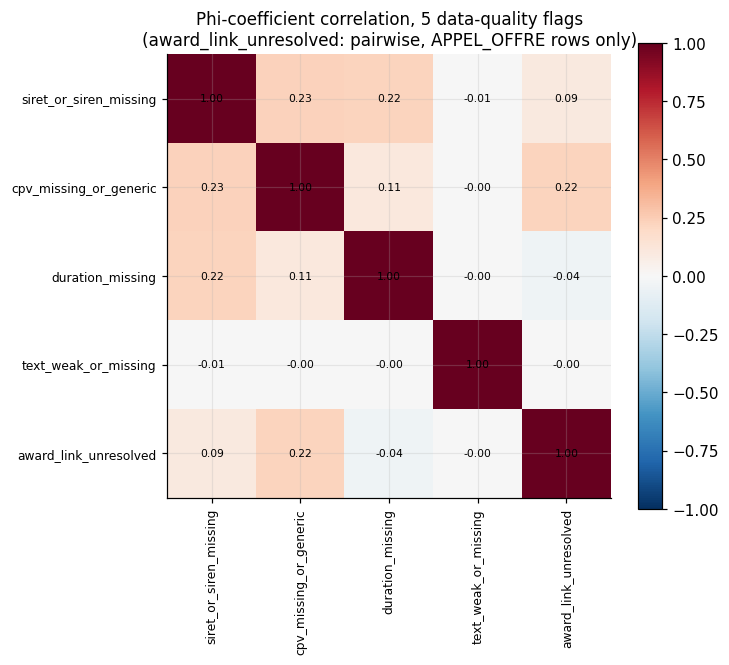

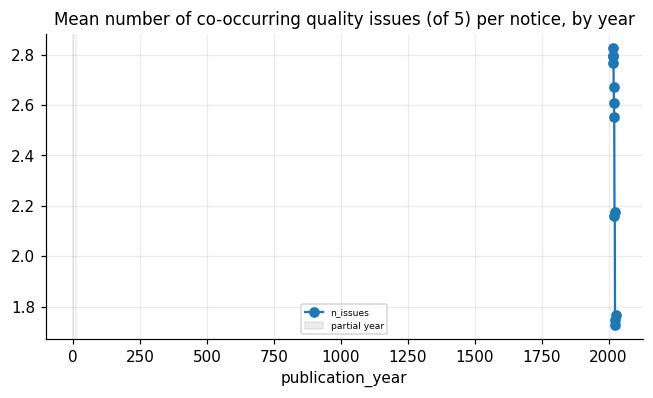

siret_or_siren_missing    0.727757
cpv_missing_or_generic    0.229843
duration_missing          0.863548
text_weak_or_missing      0.104463
award_link_unresolved     0.678755
dtype: float64

,siret_or_siren_missing,cpv_missing_or_generic,duration_missing,text_weak_or_missing,award_link_unresolved
siret_or_siren_missing,1.00,0.23,0.22,-0.01,0.09
cpv_missing_or_generic,0.23,1.00,0.11,-0.00,0.22
duration_missing,0.22,0.11,1.00,-0.00,-0.04
text_weak_or_missing,-0.01,-0.00,-0.00,1.00,-0.00
award_link_unresolved,0.09,0.22,-0.04,-0.00,1.00


In [14]:
text_len_p10 = common["text_length"].quantile(0.10)

# award_link_unresolved is only defined for the population that can structurally receive
# an award link (APPEL_OFFRE notices; see prepare.py's attr_rows/attribution_links, which
# is built exclusively from ATTRIBUTION rows pointing back at APPEL_OFFRE notices). Left
# NaN elsewhere rather than counted as "unresolved" for notice types that were never
# eligible in the first place.
appel_offre_mask = common["notice_type_normalized"] == "APPEL_OFFRE"
award_link_unresolved = pd.Series(np.nan, index=common.index, dtype=float)
award_link_unresolved.loc[appel_offre_mask] = (
    common.loc[appel_offre_mask, "start_date_source"] == "PUBLICATION_DATE_FALLBACK"
).astype(float)

flags = pd.DataFrame({
    "siret_or_siren_missing": (common["buyer_siret_clean"].isna() & common["buyer_siren_clean"].isna()).astype(float),
    "cpv_missing_or_generic": (common["cpv_missing"].astype(bool) | common["cpv_generic_flag"].astype(bool)).astype(float),
    "duration_missing": common["duration_raw"].isna().astype(float),
    "text_weak_or_missing": (common["objet_clean"].isna() | (common["text_length"] <= text_len_p10)).astype(float),
    "award_link_unresolved": award_link_unresolved,
}, index=common.index)

marginal_flag_rates = flags.mean()  # NaN-skipping: award_link_unresolved rate is over APPEL_OFFRE only
phi_matrix = flags.corr()  # pandas .corr() uses pairwise-complete observations, handles the NaN column correctly

marginal_flag_rates.to_csv(SYN_CALIB_DIR / "calib_missingness_marginal_rates.csv")
phi_matrix.to_csv(SYN_CALIB_DIR / "calib_missingness_phi_matrix.csv")

def _joint_rate(d, a, b):
    sub = d[[a, b]].dropna()
    if len(sub) == 0:
        return np.nan
    return ((sub[a] == 1) & (sub[b] == 1)).mean()

joint_dims = ["publication_year", "schema_family", "dept_primary", "cpv_division", "buyer_activity_tier"]
rows = []
flag_names = list(flags.columns)
for dim in joint_dims:
    g = pd.concat([common[dim], flags], axis=1).groupby(dim)
    for a_i, a in enumerate(flag_names):
        for b in flag_names[a_i + 1:]:
            joint = g.apply(lambda d, a=a, b=b: _joint_rate(d, a, b) if len(d) else np.nan, include_groups=False)
            for value, rate in joint.items():
                rows.append({"stratum_dim": dim, "stratum_value": value, "flag_a": a, "flag_b": b,
                             "joint_rate": rate, "n": g.size().get(value, 0)})
cooccurrence_by_conditioning = pd.DataFrame(rows)
cooccurrence_by_conditioning.to_csv(
    SYN_CALIB_DIR / "calib_missingness_cooccurrence_by_conditioning.csv", index=False)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(phi_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(flag_names))); ax.set_xticklabels(flag_names, rotation=90, fontsize=8)
ax.set_yticks(range(len(flag_names))); ax.set_yticklabels(flag_names, fontsize=8)
for i in range(len(flag_names)):
    for j in range(len(flag_names)):
        ax.text(j, i, f"{phi_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Phi-coefficient correlation, 5 data-quality flags\n(award_link_unresolved: pairwise, APPEL_OFFRE rows only)")
fig.colorbar(im, ax=ax)
plt.show()
save_figure(fig, "calib_missingness_correlation_heatmap", cfg)

issues_per_notice_by_year = pd.concat([common["publication_year"], flags.sum(axis=1).rename("n_issues")], axis=1) \
                               .groupby("publication_year")["n_issues"].mean()
fig, ax = plt.subplots(figsize=(7, 3.6))
issues_per_notice_by_year.plot(ax=ax, marker="o")
ax.set_title("Mean number of co-occurring quality issues (of 5) per notice, by year")
shade_partial_years(ax, issues_per_notice_by_year.index)
plt.show()
save_figure(fig, "calib_missingness_cooccurrence_by_year", cfg)

display(marginal_flag_rates)
display(phi_matrix.round(2))

add_provenance("missingness_marginal_rates", "Marginal rate of each of the 5 quality flags",
                "OBSERVABLE", "see table", "rate", "marginal",
                "data/interim/boamp_common_prepared.csv",
                "buyer_siret_clean,buyer_siren_clean,cpv_missing,cpv_generic_flag,"
                "duration_raw,objet_clean,text_length,start_date_source,notice_type_normalized",
                "mean of 0/1 flags (NaN-skipping)", n_total, "11",
                "calib_missingness_marginal_rates.csv",
                "award_link_unresolved is defined (non-NaN) only for APPEL_OFFRE notices; its rate is over "
                "that subset, not the full corpus. name_fallback was dropped as a deterministic subset of "
                "siret_or_siren_missing; see calib_buyer_name_variation_summary.csv (§7) instead.")
add_provenance("missingness_phi_matrix", "Phi-coefficient correlation among 5 quality flags",
                "OBSERVABLE", "see table", "correlation (-1..1)", "marginal + by year/schema/dept/cpv/buyer_activity",
                "data/interim/boamp_common_prepared.csv",
                "buyer_siret_clean,buyer_siren_clean,cpv_missing,cpv_generic_flag,"
                "duration_raw,objet_clean,text_length,start_date_source,notice_type_normalized",
                "Pearson correlation on 0/1 flags (= phi coefficient), pairwise-complete", n_total, "11",
                "calib_missingness_correlation_heatmap.png",
                "name_fallback excluded: it was a deterministic subset of siret_or_siren_missing "
                "(construction artifact, not an empirical association); award_link_unresolved correlations "
                "are computed pairwise over its APPEL_OFFRE-only non-NaN population.")

## 12. Scope & eligibility as a conditioning variable

The linkage pipeline restricts to a digital/ICT-scope, Pays-de-la-Loire-scope eligible
source population. Per the calibration brief, scope is treated here as one more
conditioning dimension on the full corpus, not a pre-filter applied before analysis.

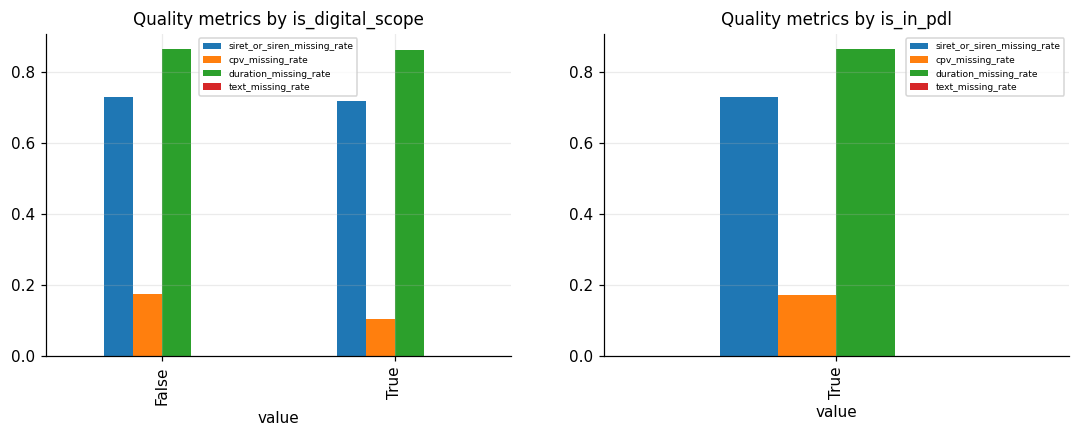

,scope_dim,value,n,siret_or_siren_missing_rate,cpv_missing_rate,duration_missing_rate,text_missing_rate
0,is_digital_scope,False,79439,0.728471,0.175090,0.863732,0.000013
1,is_digital_scope,True,5184,0.716821,0.102045,0.860725,0.000000
2,is_in_pdl,True,84623,0.727757,0.170616,0.863548,0.000012


In [15]:
scope_dims = pd.DataFrame({
    "is_digital_scope": common["is_digital_scope"],
    "is_in_pdl": common["is_in_pdl"],
})
scope_crosstab_rows = []
for label, mask_col in [("is_digital_scope", "is_digital_scope"), ("is_in_pdl", "is_in_pdl")]:
    for val, sub in common.groupby(mask_col):
        scope_crosstab_rows.append({
            "scope_dim": label, "value": val, "n": len(sub),
            "siret_or_siren_missing_rate": (sub["buyer_siret_clean"].isna() & sub["buyer_siren_clean"].isna()).mean(),
            "cpv_missing_rate": sub["cpv_missing"].astype(bool).mean(),
            "duration_missing_rate": sub["duration_raw"].isna().mean(),
            "text_missing_rate": sub["objet_clean"].isna().mean(),
        })
scope_conditioning_crosstab = pd.DataFrame(scope_crosstab_rows)
scope_conditioning_crosstab.to_csv(SYN_CALIB_DIR / "calib_scope_conditioning_crosstab.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sub = scope_conditioning_crosstab[scope_conditioning_crosstab["scope_dim"] == "is_digital_scope"] \
        .set_index("value")[["siret_or_siren_missing_rate", "cpv_missing_rate", "duration_missing_rate", "text_missing_rate"]]
sub.plot(kind="bar", ax=axes[0]); axes[0].set_title("Quality metrics by is_digital_scope"); axes[0].legend(fontsize=6)
sub2 = scope_conditioning_crosstab[scope_conditioning_crosstab["scope_dim"] == "is_in_pdl"] \
        .set_index("value")[["siret_or_siren_missing_rate", "cpv_missing_rate", "duration_missing_rate", "text_missing_rate"]]
sub2.plot(kind="bar", ax=axes[1]); axes[1].set_title("Quality metrics by is_in_pdl"); axes[1].legend(fontsize=6)
plt.show()
save_figure(fig, "calib_scope_conditioning_overview", cfg)

display(scope_conditioning_crosstab)

add_provenance("scope_conditioning_crosstab", "Quality metrics split by digital-scope / PDL-scope eligibility",
                "OBSERVABLE", "see table", "rate", "by is_digital_scope, is_in_pdl",
                "data/interim/boamp_common_prepared.csv", "is_digital_scope,is_in_pdl",
                "groupby, mean of quality flags", n_total, "12",
                "calib_scope_conditioning_crosstab.csv",
                "is_digital_scope combines a CPV-division rule with a French keyword search over "
                "objet_normalized (config/pipeline.yaml scope block); it is a scope-tagging heuristic.")

## 13. Candidate-environment complexity (future-only rebuild)

Rebuilds the candidate-environment analysis as a forward-search problem. For a source
notice `i`, valid later candidates must satisfy `publication_date_j > publication_date_i`.
The section reports three nested environments:

- **Ambient future environment** — all later BOAMP notices within 6/12/24/36/60 months.
- **Buyer-compatible environment** — later notices sharing SIRET, SIREN, normalized name,
  BOAMP-native buyer key, or the Layer 2 alias-compatible buyer key where available.
- **Production candidate environment** — the actual Layer 1 / Layer 2 candidate-pair
  exports after relevant notice type, digital scope, current blocking, expected-end-date
  temporal rules, and the 30-candidate cap.

The old symmetric publication-date window is retained only as a backward-compatible
excerpt table; it is no longer the primary calibration object.



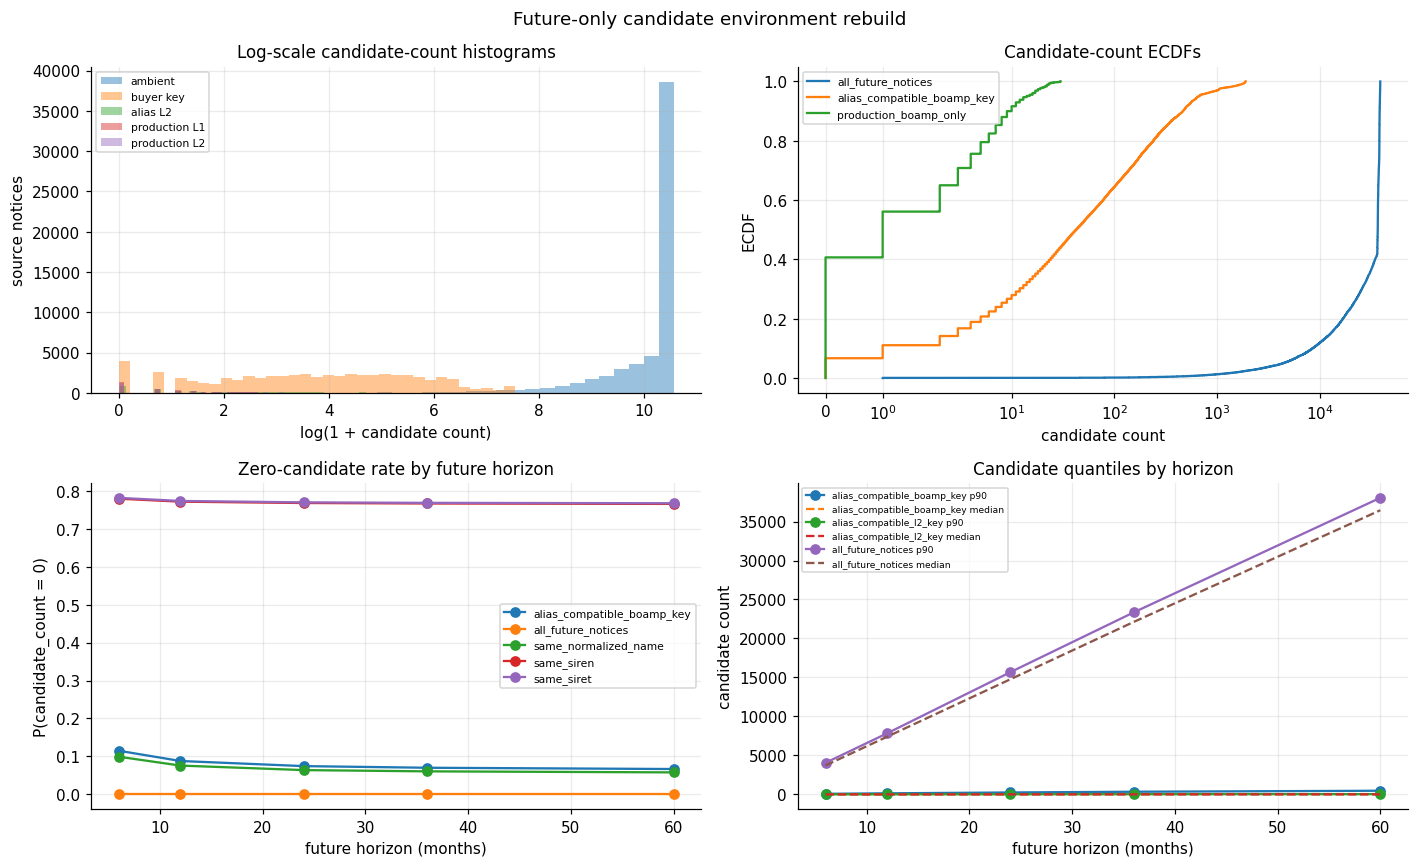

/tmp/ipykernel_2906/1225381856.py:560: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


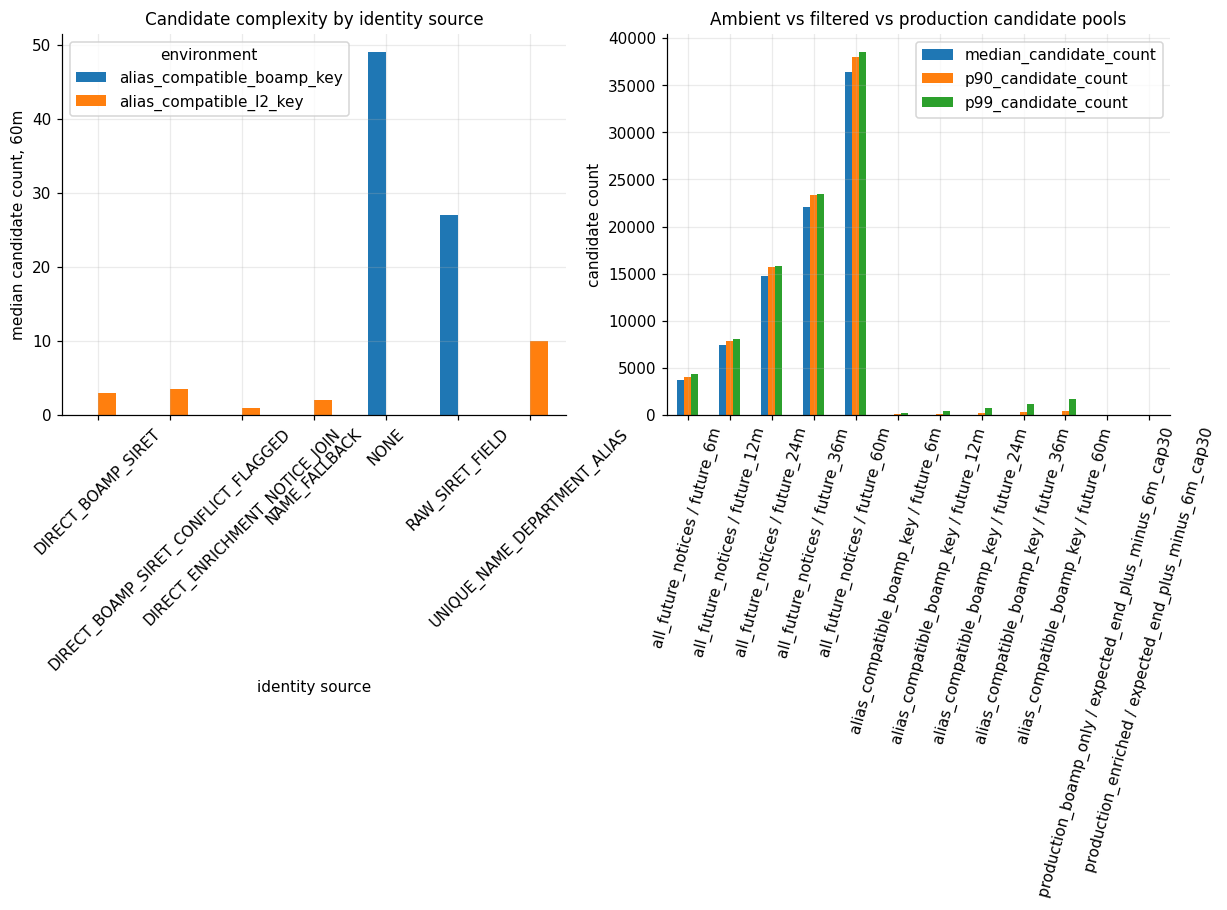

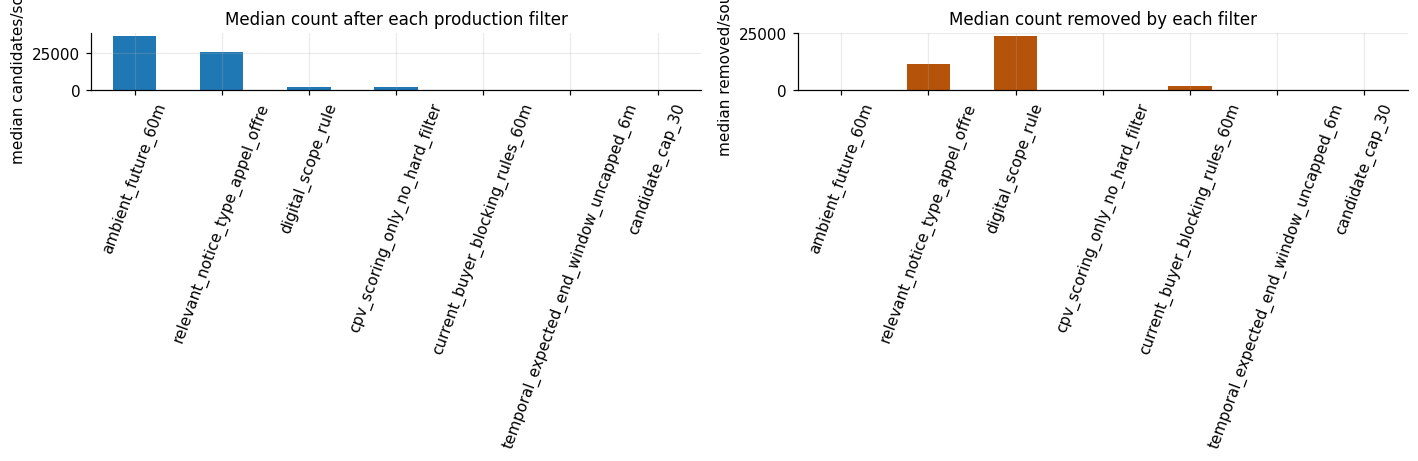

Future-only source rows: 1,480,960; quantile rows: 2,281; filter-decomposition rows: 23,660.
Production cap-reached rate: [{'environment': 'production_boamp_only', 'cap_reached_rate': 0.0}, {'environment': 'production_enriched', 'cap_reached_rate': 0.0002958579881656805}]


,environment_family,environment,horizon_months,horizon_label,source_universe,stratum_dim,stratum_value,n_sources,zero_candidate_rate,mean_candidate_count,...,cap_reached_rate,median_top1_top2_similarity_margin,buyer_identifier_source,buyer_key_type,buyer_activity_tier,schema_family,publication_year,cpv_division,duration_availability,digital_segment
0,ambient_future_environment,all_future_notices,6,future_6m,all_appel_offre_sources,overall,overall,58292,0.000000,3643.536351,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ambient_future_environment,all_future_notices,12,future_12m,all_appel_offre_sources,overall,overall,58292,0.000000,7124.974765,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ambient_future_environment,all_future_notices,24,future_24m,all_appel_offre_sources,overall,overall,58292,0.000000,13623.806543,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ambient_future_environment,all_future_notices,36,future_36m,all_appel_offre_sources,overall,overall,58292,0.000000,19444.597835,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ambient_future_environment,all_future_notices,60,future_60m,all_appel_offre_sources,overall,overall,58292,0.000000,29150.903949,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,buyer_compatible_environment,alias_compatible_boamp_key,6,future_6m,all_appel_offre_sources,overall,overall,58292,0.114973,26.205294,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,buyer_compatible_environment,alias_compatible_boamp_key,12,future_12m,all_appel_offre_sources,overall,overall,58292,0.087954,49.453510,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,buyer_compatible_environment,alias_compatible_boamp_key,24,future_24m,all_appel_offre_sources,overall,overall,58292,0.074453,88.399901,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,buyer_compatible_environment,alias_compatible_boamp_key,36,future_36m,all_appel_offre_sources,overall,overall,58292,0.070130,118.901925,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,buyer_compatible_environment,alias_compatible_boamp_key,60,future_60m,all_appel_offre_sources,overall,overall,58292,0.066802,161.117992,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


candidate_count_after_stage  \
                                                              median   
filter_stage                                                           
ambient_future_60m                                           36476.0   
candidate_cap_30                                                 1.0   
cpv_scoring_only_no_hard_filter                               1448.0   
current_buyer_blocking_rules_60m                                 3.0   
digital_scope_rule                                            1448.0   
relevant_notice_type_appel_offre                             25304.0   
temporal_expected_end_window_uncapped_6m                         1.0   

                                                               \
                                                  mean    max   
filter_stage                                                    
ambient_future_60m                        29698.403550  38549   
candidate_cap_30                              3.213609     30   
cpv_scoring_only_no_hard_filter            1156.558876   1574   
current_buyer_blocking_rules_60m             11.076331    110   
digital_scope_rule                         1156.558876   1574   
relevant_notice_type_appel_offre          20289.514793  26128   
temporal_expected_end_window_uncapped_6m      3.199408     30   

                                         candidate_count_removed_by_stage  \
                                                                   median   
filter_stage                                                                
ambient_future_60m                                                    0.0   
candidate_cap_30                                                      0.0   
cpv_scoring_only_no_hard_filter                                       0.0   
current_buyer_blocking_rules_60m                                   1430.0   
digital_scope_rule                                                23825.0   
relevant_notice_type_appel_offre                                  11147.5   
temporal_expected_end_window_uncapped_6m                              2.0   

                                                               
                                                  mean    max  
filter_stage                                                   
ambient_future_60m                            0.000000      0  
candidate_cap_30                              0.000000      0  
cpv_scoring_only_no_hard_filter               0.000000      0  
current_buyer_blocking_rules_60m           1145.482544   1574  
digital_scope_rule                        19132.955917  24663  
relevant_notice_type_appel_offre           9408.888757  12571  
temporal_expected_end_window_uncapped_6m      7.876923     90

In [16]:
CANDIDATE_ENV_FIG_DIR = cfg.paths.reports_figures / "synthetic_calibration" / "candidate_environment"
CANDIDATE_ENV_FIG_DIR.mkdir(parents=True, exist_ok=True)

FUTURE_HORIZONS = [6, 12, 24, 36, 60]
HORIZON_FOR_DECOMPOSITION = 60
MONTH_DAYS = float(cfg.pipeline.run.month_days)
PRODUCTION_CAP = int(cfg.pipeline.candidates.max_candidates_per_source)
PRODUCTION_WINDOW_MONTHS = int(cfg.pipeline.temporal_window.expected_value_months)

candidate_source_mask = common["notice_type_normalized"].eq("APPEL_OFFRE")
source_index = common.index[candidate_source_mask].to_numpy()
source_notice_ids = set(common.loc[source_index, "notice_id"])

if "buyer_activity_tier" not in common.columns:
    _buyer_activity_counts = common.groupby("buyer_key")["notice_id"].transform("count")
    common["buyer_activity_tier"] = pd.cut(
        _buyer_activity_counts.fillna(0), bins=[0, 1, 5, 20, np.inf],
        labels=["1 (single)", "2-5", "6-20", "21+"], include_lowest=True
    ).astype(str)

common["duration_availability"] = np.select(
    [
        common["duration_raw"].notna(),
        common["declared_duration_months"].notna() & common["dur_was_imputed"].astype(bool),
        common["declared_duration_months"].notna(),
    ],
    ["declared_duration_observed", "duration_imputed", "duration_available_unclear"],
    default="duration_missing",
)
common["digital_segment"] = np.where(common["is_digital_scope"].astype(bool), "DIGITAL_ICT", "NON_DIGITAL")

# Reconstruct a notice -> provisional-family map from the §10b edge table. Singletons
# are intentionally retained as one family per notice so candidate-family counts are
# comparable with candidate counts even when no lifecycle edge was observed.
notice_ids_all = common["notice_id"].astype(str).tolist()
parent = {nid: nid for nid in notice_ids_all}

def _find(x):
    parent.setdefault(x, x)
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def _union(a, b):
    ra, rb = _find(str(a)), _find(str(b))
    if ra != rb:
        parent[rb] = ra

notice_family_edges_path = SYN_CALIB_DIR / "notice_family_edges.csv"
if notice_family_edges_path.exists():
    _edges_for_family_map = pd.read_csv(notice_family_edges_path, dtype=str)
    for _a, _b in zip(_edges_for_family_map["source_notice_id"], _edges_for_family_map["target_notice_id"]):
        if pd.notna(_a) and pd.notna(_b):
            _union(_a, _b)
notice_family_by_notice = {nid: _find(nid) for nid in notice_ids_all}
common["candidate_notice_family_id"] = common["notice_id"].astype(str).map(notice_family_by_notice)

source_attr_cols = [
    "notice_id", "publication_date", "publication_year", "schema_family", "buyer_key_type",
    "buyer_identifier_source", "buyer_key", "buyer_activity_tier", "cpv_division",
    "duration_availability", "digital_segment", "is_digital_scope", "category_label",
]
source_attrs = common.loc[source_index, source_attr_cols].copy()
source_attrs["source_universe"] = "all_appel_offre_sources"
source_attrs["source_row_index"] = source_attrs.index

class FenwickTree:
    def __init__(self, n):
        self.n = int(n)
        self.bit = np.zeros(self.n + 1, dtype=np.int64)
    def add(self, idx, delta):
        i = int(idx) + 1
        while i <= self.n:
            self.bit[i] += int(delta)
            i += i & -i
    def prefix(self, idx):
        if idx < 0:
            return 0
        i = int(idx) + 1
        total = 0
        while i > 0:
            total += int(self.bit[i])
            i -= i & -i
        return total
    def range_sum(self, lo, hi):
        if hi < lo:
            return 0
        return self.prefix(hi) - self.prefix(lo - 1)

def interval_distinct_counts(values, left, right):
    n = len(values)
    out = np.zeros(len(left), dtype=np.int32)
    queries = [(int(r), int(l), q) for q, (l, r) in enumerate(zip(left, right)) if r >= l]
    if not queries:
        return out
    queries.sort(key=lambda t: t[0])
    bit = FenwickTree(n)
    last_seen = {}
    pos = -1
    for r, l, q in queries:
        while pos < r:
            pos += 1
            val = values[pos]
            prev = last_seen.get(val)
            if prev is not None:
                bit.add(prev, -1)
            bit.add(pos, 1)
            last_seen[val] = pos
        out[q] = bit.range_sum(l, r)
    return out

def future_counts_from_candidate_pool(source_dates, candidate_dates, horizons):
    cand = np.sort(pd.to_datetime(candidate_dates).dropna().to_numpy(dtype="datetime64[ns]"))
    src = pd.to_datetime(source_dates).to_numpy(dtype="datetime64[ns]")
    out = {}
    if len(cand) == 0:
        for horizon in horizons:
            out[horizon] = np.zeros(len(src), dtype=np.int32)
        return out
    first_future = np.searchsorted(cand, src, side="right")
    for horizon in horizons:
        delta = np.timedelta64(int(round(horizon * MONTH_DAYS)), "D")
        right = np.searchsorted(cand, src + delta, side="right")
        out[horizon] = np.maximum(right - first_future, 0).astype(np.int32)
    return out

def future_environment_rows(df, source_idx, date_col, horizons, environment_family, environment, key_col=None,
                            source_universe="all_appel_offre_sources", exact_family_counts=True):
    counts_by_horizon = {h: np.zeros(len(df), dtype=np.int32) for h in horizons}
    first_days_by_horizon = {h: np.full(len(df), np.nan, dtype=float) for h in horizons}
    family_counts_by_horizon = {h: np.full(len(df), np.nan, dtype=float) for h in horizons}

    source_mask = np.zeros(len(df), dtype=bool)
    source_mask[np.asarray(source_idx, dtype=int)] = True
    group_iter = [("__all__", df.dropna(subset=[date_col]))] if key_col is None else df.dropna(subset=[key_col, date_col]).groupby(key_col, sort=False)
    for _, group in group_iter:
        group_index = group.index.to_numpy(dtype=int)
        group_source_idx = group_index[source_mask[group_index]]
        if len(group_source_idx) == 0 or len(group) < 2:
            continue
        order = np.argsort(group[date_col].to_numpy(dtype="datetime64[ns]"), kind="mergesort")
        ordered_index = group.index.to_numpy()[order]
        dates = group[date_col].to_numpy(dtype="datetime64[ns]")[order]
        families = group["candidate_notice_family_id"].astype(str).to_numpy()[order]
        pos_by_index = {int(idx): pos for pos, idx in enumerate(ordered_index)}
        src_pos = np.fromiter((pos_by_index[int(idx)] for idx in group_source_idx), dtype=int, count=len(group_source_idx))
        first_future_all = np.searchsorted(dates, dates, side="right")
        for horizon in horizons:
            delta = np.timedelta64(int(round(horizon * MONTH_DAYS)), "D")
            right_all = np.searchsorted(dates, dates + delta, side="right")
            left = first_future_all[src_pos]
            right_excl = right_all[src_pos]
            counts = np.maximum(right_excl - left, 0).astype(np.int32)
            counts_by_horizon[horizon][group_source_idx] = counts
            has_candidate = counts > 0
            first_delta_days = np.full(len(src_pos), np.nan, dtype=float)
            if has_candidate.any():
                first_delta_days[has_candidate] = (
                    (dates[left[has_candidate]] - dates[src_pos[has_candidate]]) / np.timedelta64(1, "D")
                ).astype(float)
            first_days_by_horizon[horizon][group_source_idx] = first_delta_days
            if exact_family_counts:
                family_counts = interval_distinct_counts(families, left, right_excl - 1).astype(float)
                family_counts_by_horizon[horizon][group_source_idx] = family_counts

    rows = []
    attrs = source_attrs.loc[source_idx].copy()
    for horizon in horizons:
        part = attrs.copy()
        part["environment_family"] = environment_family
        part["environment"] = environment
        part["horizon_months"] = horizon
        part["horizon_label"] = f"future_{horizon}m"
        part["source_universe"] = source_universe
        idx_values = attrs.index.to_numpy(dtype=int)
        part["candidate_count"] = counts_by_horizon[horizon][idx_values].astype(int)
        part["zero_candidate"] = part["candidate_count"].eq(0)
        part["time_to_first_candidate_days"] = first_days_by_horizon[horizon][idx_values].astype(float)
        part["candidate_notice_family_count"] = family_counts_by_horizon[horizon][idx_values].astype(float)
        part["candidate_count_before_cap"] = np.nan
        part["candidate_count_removed_by_cap"] = np.nan
        part["cap_reached"] = False
        part["top1_top2_similarity_margin"] = np.nan
        rows.append(part)
    return pd.concat(rows, ignore_index=True)

future_environment_parts = [
    future_environment_rows(common, source_index, "publication_date", FUTURE_HORIZONS,
                            "ambient_future_environment", "all_future_notices", key_col=None,
                            exact_family_counts=False),
    future_environment_rows(common, source_index, "publication_date", FUTURE_HORIZONS,
                            "buyer_compatible_environment", "same_siret", key_col="buyer_siret_clean", exact_family_counts=False),
    future_environment_rows(common, source_index, "publication_date", FUTURE_HORIZONS,
                            "buyer_compatible_environment", "same_siren", key_col="buyer_siren_clean", exact_family_counts=False),
    future_environment_rows(common, source_index, "publication_date", FUTURE_HORIZONS,
                            "buyer_compatible_environment", "same_normalized_name", key_col="buyer_name_normalized", exact_family_counts=False),
    future_environment_rows(common, source_index, "publication_date", FUTURE_HORIZONS,
                            "buyer_compatible_environment", "alias_compatible_boamp_key", key_col="buyer_key", exact_family_counts=False),
]

enriched_sources_path = cfg.paths.processed_enriched / "enriched_sources.csv"
if enriched_sources_path.exists():
    enriched_sources_for_env = pd.read_csv(
        enriched_sources_path, low_memory=False,
        dtype={"notice_id": str, "buyer_key_l2": str, "buyer_identity_source": str},
        parse_dates=["publication_date"]
    )
    l2_env = common.merge(
        enriched_sources_for_env[["notice_id", "buyer_key_l2", "buyer_identity_source"]],
        on="notice_id", how="left"
    )
    l2_source_idx = l2_env.index[l2_env["notice_id"].isin(enriched_sources_for_env["notice_id"].astype(str))].to_numpy()
    l2_attrs_extra = l2_env.loc[l2_source_idx, ["notice_id", "buyer_identity_source"]].set_index("notice_id")
    l2_part = future_environment_rows(
        l2_env, l2_source_idx, "publication_date", FUTURE_HORIZONS,
        "buyer_compatible_environment", "alias_compatible_l2_key", key_col="buyer_key_l2",
        source_universe="production_digital_appel_offre_sources",
        exact_family_counts=False
    )
    l2_part = l2_part.drop(columns=["buyer_identifier_source"], errors="ignore").merge(
        l2_attrs_extra.reset_index(), on="notice_id", how="left"
    ).rename(columns={"buyer_identity_source": "buyer_identifier_source"})
    future_environment_parts.append(l2_part)

candidate_environment_future_only = pd.concat(future_environment_parts, ignore_index=True)

# Production-style source-level rows from the actual capped candidate-pair exports.
def load_sources(path, layer_label):
    dtype_cols = {
        "notice_id": str, "buyer_key": str, "buyer_key_type": str,
        "buyer_siret_clean": str, "buyer_siren_clean": str, "buyer_name_normalized": str,
        "buyer_identity_source": str, "buyer_key_l2": str, "buyer_siren_l2": str,
        "cpv_clean": str, "cpv_division": str, "cpv_group": str, "cpv_class": str, "cpv_category": str,
    }
    src = pd.read_csv(path, low_memory=False, dtype=dtype_cols,
                      parse_dates=["publication_date", "estimated_end_date"])
    src = src.merge(
        common[["notice_id", "publication_year", "schema_family", "duration_availability", "digital_segment", "buyer_activity_tier"]],
        on="notice_id", how="left"
    )
    src["production_layer"] = layer_label
    return src

def load_pairs(path):
    dtype_cols = {"source_notice_id": str, "candidate_notice_id": str, "buyer_key_type": str,
                  "buyer_key_type_source": str, "buyer_match_mechanism": str}
    return pd.read_csv(path, low_memory=False, dtype=dtype_cols,
                       parse_dates=["source_date", "candidate_date"])

def l1_uncapped_temporal_counts(src):
    out = pd.Series(0, index=src["notice_id"].astype(str), dtype="int32")
    window_delta_days = PRODUCTION_WINDOW_MONTHS * MONTH_DAYS
    for _, group in src.dropna(subset=["buyer_key", "publication_date", "estimated_end_date"]).groupby("buyer_key", sort=False):
        if len(group) < 2:
            continue
        pub = group["publication_date"].to_numpy(dtype="datetime64[ns]")
        est = group["estimated_end_date"].to_numpy(dtype="datetime64[ns]")
        ids = group["notice_id"].astype(str).to_numpy()
        for i in range(len(group)):
            if pd.isna(est[i]):
                continue
            gap = np.abs((pub - est[i]) / np.timedelta64(1, "D")) / MONTH_DAYS
            mask = (pub > pub[i]) & (gap <= PRODUCTION_WINDOW_MONTHS)
            out.loc[ids[i]] = int(mask.sum())
    return out

def compatible_l2(src_row, cand_row):
    if pd.notna(src_row.get("buyer_siret_clean")) and src_row.get("buyer_siret_clean") == cand_row.get("buyer_siret_clean"):
        return True
    if pd.notna(src_row.get("buyer_siren_l2")) and src_row.get("buyer_siren_l2") == cand_row.get("buyer_siren_l2"):
        return True
    if pd.notna(src_row.get("buyer_key")) and src_row.get("buyer_key") == cand_row.get("buyer_key"):
        return True
    return False

def l2_uncapped_temporal_counts(src):
    src = src.reset_index(drop=True)
    out = pd.Series(0, index=src["notice_id"].astype(str), dtype="int32")
    candidate_sets = {i: set() for i in range(len(src))}
    for key_col in ["buyer_siret_clean", "buyer_siren_l2", "buyer_key"]:
        if key_col not in src.columns:
            continue
        for _, group in src.dropna(subset=[key_col]).groupby(key_col, sort=False):
            if len(group) < 2:
                continue
            idxs = set(group.index.tolist())
            for idx in idxs:
                candidate_sets[idx].update(idxs - {idx})
    pub = src["publication_date"].to_numpy(dtype="datetime64[ns]")
    est = src["estimated_end_date"].to_numpy(dtype="datetime64[ns]")
    for i, cand_idxs in candidate_sets.items():
        if not cand_idxs or pd.isna(est[i]):
            continue
        count = 0
        src_row = src.loc[i]
        for j in cand_idxs:
            if pub[j] <= pub[i]:
                continue
            abs_gap = abs((pub[j] - est[i]) / np.timedelta64(1, "D")) / MONTH_DAYS
            if abs_gap <= PRODUCTION_WINDOW_MONTHS and compatible_l2(src_row, src.loc[j]):
                count += 1
        out.loc[str(src.loc[i, "notice_id"])] = count
    return out

def production_environment_rows(src, pairs, layer_label, uncapped_counts):
    pair_counts = pairs.groupby("source_notice_id")["candidate_notice_id"].count()
    first_days = ((pairs["candidate_date"] - pairs["source_date"]) / np.timedelta64(1, "D")).groupby(pairs["source_notice_id"]).min()
    family_counts = pairs.assign(
        candidate_notice_family_id=pairs["candidate_notice_id"].astype(str).map(notice_family_by_notice)
    ).groupby("source_notice_id")["candidate_notice_family_id"].nunique()
    top_margin = pairs[pairs["candidate_rank"].eq(1)].set_index("source_notice_id")["top1_top2_margin"]

    out = src.copy()
    out["environment_family"] = "production_candidate_environment"
    out["environment"] = layer_label
    out["horizon_months"] = PRODUCTION_WINDOW_MONTHS
    out["horizon_label"] = f"expected_end_plus_minus_{PRODUCTION_WINDOW_MONTHS}m_cap{PRODUCTION_CAP}"
    out["source_universe"] = "production_digital_appel_offre_sources"
    out["buyer_identifier_source"] = out.get("buyer_identity_source", out.get("buyer_identifier_source", out["buyer_key_type"]))
    out["candidate_count_before_cap"] = out["notice_id"].astype(str).map(uncapped_counts).fillna(0).astype(int)
    out["candidate_count"] = out["notice_id"].astype(str).map(pair_counts).fillna(0).astype(int)
    out["zero_candidate"] = out["candidate_count"].eq(0)
    out["time_to_first_candidate_days"] = out["notice_id"].astype(str).map(first_days)
    out["candidate_notice_family_count"] = out["notice_id"].astype(str).map(family_counts).fillna(0).astype(int)
    out["candidate_count_removed_by_cap"] = (out["candidate_count_before_cap"] - out["candidate_count"]).clip(lower=0)
    out["cap_reached"] = out["candidate_count_before_cap"].gt(PRODUCTION_CAP)
    out["top1_top2_similarity_margin"] = out["notice_id"].astype(str).map(top_margin)
    keep = [
        "notice_id", "publication_date", "publication_year", "schema_family", "buyer_key_type",
        "buyer_identifier_source", "buyer_key", "buyer_activity_tier", "cpv_division",
        "duration_availability", "digital_segment", "is_digital_scope", "category_label",
        "source_universe", "environment_family", "environment", "horizon_months", "horizon_label",
        "candidate_count", "zero_candidate", "time_to_first_candidate_days",
        "candidate_notice_family_count", "candidate_count_before_cap",
        "candidate_count_removed_by_cap", "cap_reached", "top1_top2_similarity_margin",
    ]
    return out[keep]

boamp_sources = load_sources(cfg.paths.processed_boamp_only / "boamp_only_sources.csv", "production_boamp_only")
enriched_sources = load_sources(cfg.paths.processed_enriched / "enriched_sources.csv", "production_enriched")
boamp_pairs = load_pairs(cfg.paths.processed_boamp_only / "boamp_only_candidate_pairs.csv")
enriched_pairs = load_pairs(cfg.paths.processed_enriched / "enriched_candidate_pairs.csv")

l1_uncapped_counts = l1_uncapped_temporal_counts(boamp_sources)
l2_uncapped_counts = l2_uncapped_temporal_counts(enriched_sources)
production_parts = [
    production_environment_rows(boamp_sources, boamp_pairs, "production_boamp_only", l1_uncapped_counts),
    production_environment_rows(enriched_sources, enriched_pairs, "production_enriched", l2_uncapped_counts),
]

candidate_environment_future_only = pd.concat(
    [candidate_environment_future_only] + production_parts, ignore_index=True, sort=False
)
candidate_environment_future_only.to_csv(SYN_CALIB_DIR / "candidate_environment_future_only.csv", index=False)

# Filter decomposition for the Layer 1 production source universe: each row is a source x stage.
l1_source_dates = boamp_sources["publication_date"]
l1_source_ids = boamp_sources["notice_id"].astype(str)
ambient_60 = future_counts_from_candidate_pool(l1_source_dates, common["publication_date"], [HORIZON_FOR_DECOMPOSITION])[HORIZON_FOR_DECOMPOSITION]
appel_pool = common[common["notice_type_normalized"].eq("APPEL_OFFRE")]
appel_60 = future_counts_from_candidate_pool(l1_source_dates, appel_pool["publication_date"], [HORIZON_FOR_DECOMPOSITION])[HORIZON_FOR_DECOMPOSITION]
digital_appel_pool = appel_pool[appel_pool["is_digital_scope"].astype(bool)]
digital_60 = future_counts_from_candidate_pool(l1_source_dates, digital_appel_pool["publication_date"], [HORIZON_FOR_DECOMPOSITION])[HORIZON_FOR_DECOMPOSITION]
def grouped_future_count_by_notice(df, key_col, horizon_months):
    out = pd.Series(0, index=df["notice_id"].astype(str), dtype="int32")
    delta = np.timedelta64(int(round(horizon_months * MONTH_DAYS)), "D")
    for _, group in df.dropna(subset=[key_col, "publication_date"]).groupby(key_col, sort=False):
        if len(group) < 2:
            continue
        order = np.argsort(group["publication_date"].to_numpy(dtype="datetime64[ns]"), kind="mergesort")
        ids = group["notice_id"].astype(str).to_numpy()[order]
        dates = group["publication_date"].to_numpy(dtype="datetime64[ns]")[order]
        first_future = np.searchsorted(dates, dates, side="right")
        right = np.searchsorted(dates, dates + delta, side="right")
        out.loc[ids] = np.maximum(right - first_future, 0).astype("int32")
    return out

blocking_60 = grouped_future_count_by_notice(boamp_sources, "buyer_key", HORIZON_FOR_DECOMPOSITION)
actual_pair_counts = boamp_pairs.groupby("source_notice_id")["candidate_notice_id"].count()
filter_stage_values = {
    "ambient_future_60m": pd.Series(ambient_60, index=l1_source_ids),
    "relevant_notice_type_appel_offre": pd.Series(appel_60, index=l1_source_ids),
    "digital_scope_rule": pd.Series(digital_60, index=l1_source_ids),
    "cpv_scoring_only_no_hard_filter": pd.Series(digital_60, index=l1_source_ids),
    "current_buyer_blocking_rules_60m": l1_source_ids.map(blocking_60).fillna(0).astype(int).set_axis(l1_source_ids),
    f"temporal_expected_end_window_uncapped_{PRODUCTION_WINDOW_MONTHS}m": l1_source_ids.map(l1_uncapped_counts).fillna(0).astype(int).set_axis(l1_source_ids),
    f"candidate_cap_{PRODUCTION_CAP}": l1_source_ids.map(actual_pair_counts).fillna(0).astype(int).set_axis(l1_source_ids),
}
filter_rows = []
previous_counts = None
for order, (stage, counts) in enumerate(filter_stage_values.items(), start=1):
    counts = pd.Series(counts.to_numpy(dtype=int), index=l1_source_ids)
    removed = np.zeros(len(counts), dtype=int) if previous_counts is None else np.maximum(previous_counts.to_numpy(dtype=int) - counts.to_numpy(dtype=int), 0)
    filter_rows.append(pd.DataFrame({
        "notice_id": l1_source_ids.to_numpy(),
        "stage_order": order,
        "filter_stage": stage,
        "candidate_count_after_stage": counts.to_numpy(dtype=int),
        "candidate_count_removed_by_stage": removed,
    }))
    previous_counts = counts
candidate_filter_decomposition = pd.concat(filter_rows, ignore_index=True)
candidate_filter_decomposition = candidate_filter_decomposition.merge(
    boamp_sources[["notice_id", "buyer_key_type", "publication_year", "cpv_division", "duration_availability", "digital_segment", "buyer_activity_tier"]],
    on="notice_id", how="left"
)
candidate_filter_decomposition.to_csv(SYN_CALIB_DIR / "candidate_filter_decomposition.csv", index=False)

# Summary quantiles, overall and by required stratifiers.
def summarize_candidate_frame(df, group_cols, stratum_dim="overall"):
    rows = []
    for keys, sub in df.groupby(group_cols, dropna=False, sort=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        key_dict = dict(zip(group_cols, keys))
        c = sub["candidate_count"].fillna(0)
        t = sub["time_to_first_candidate_days"].dropna()
        fam = sub["candidate_notice_family_count"].dropna()
        rows.append({
            **key_dict,
            "stratum_dim": stratum_dim,
            "stratum_value": "overall" if stratum_dim == "overall" else str(key_dict.get(stratum_dim, "NA")),
            "n_sources": int(len(sub)),
            "zero_candidate_rate": float(c.eq(0).mean()),
            "mean_candidate_count": float(c.mean()),
            "median_candidate_count": float(c.median()),
            "p75_candidate_count": float(c.quantile(0.75)),
            "p90_candidate_count": float(c.quantile(0.90)),
            "p95_candidate_count": float(c.quantile(0.95)),
            "p99_candidate_count": float(c.quantile(0.99)),
            "max_candidate_count": int(c.max()),
            "median_time_to_first_candidate_days": float(t.median()) if len(t) else np.nan,
            "p90_time_to_first_candidate_days": float(t.quantile(0.90)) if len(t) else np.nan,
            "median_candidate_notice_family_count": float(fam.median()) if len(fam) else np.nan,
            "p90_candidate_notice_family_count": float(fam.quantile(0.90)) if len(fam) else np.nan,
            "cap_reached_rate": float(sub["cap_reached"].fillna(False).astype(bool).mean()),
            "median_top1_top2_similarity_margin": float(sub["top1_top2_similarity_margin"].dropna().median())
                if sub["top1_top2_similarity_margin"].notna().any() else np.nan,
        })
    return pd.DataFrame(rows)

base_group_cols = ["environment_family", "environment", "horizon_months", "horizon_label", "source_universe"]
quantile_parts = [summarize_candidate_frame(candidate_environment_future_only, base_group_cols, "overall")]
for stratum in ["buyer_identifier_source", "buyer_key_type", "buyer_activity_tier", "schema_family",
                "publication_year", "cpv_division", "duration_availability", "digital_segment"]:
    quantile_parts.append(
        summarize_candidate_frame(candidate_environment_future_only, base_group_cols + [stratum], stratum)
    )
candidate_environment_quantiles = pd.concat(quantile_parts, ignore_index=True, sort=False)
candidate_environment_quantiles.to_csv(SYN_CALIB_DIR / "candidate_environment_quantiles.csv", index=False)

# Backward-compatible replacement for the old symmetric-window table: same file name,
# but future-only and explicitly scoped to the BOAMP-native buyer key environment.
candidate_env_by_window = candidate_environment_quantiles[
    candidate_environment_quantiles["environment"].eq("alias_compatible_boamp_key")
    & candidate_environment_quantiles["stratum_dim"].eq("buyer_key_type")
].rename(columns={
    "horizon_months": "window_months",
    "mean_candidate_count": "mean",
    "median_candidate_count": "median",
    "p90_candidate_count": "p90",
    "zero_candidate_rate": "pct_zero_candidates",
    "n_sources": "n",
})[["window_months", "buyer_key_type", "mean", "median", "p90", "pct_zero_candidates", "n"]]
candidate_env_by_window.to_csv(SYN_CALIB_DIR / "calib_candidate_environment_complexity_by_window.csv", index=False)

# Figures requested in the work package.
def save_candidate_env_figure(fig, stem):
    for ext in ["png", "pdf"]:
        fig.savefig(CANDIDATE_ENV_FIG_DIR / f"{stem}.{ext}", bbox_inches="tight", dpi=180)

plot_df = candidate_environment_future_only.copy()
plot_df["plot_environment"] = plot_df["environment"].replace({
    "all_future_notices": "ambient",
    "alias_compatible_boamp_key": "buyer key",
    "alias_compatible_l2_key": "alias L2",
    "production_boamp_only": "production L1",
    "production_enriched": "production L2",
})

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
selected_envs = ["all_future_notices", "alias_compatible_boamp_key", "alias_compatible_l2_key", "production_boamp_only", "production_enriched"]
for env in selected_envs:
    sub = plot_df[(plot_df["environment"].eq(env)) & (plot_df["horizon_months"].isin([60, PRODUCTION_WINDOW_MONTHS]))]
    if env.startswith("production"):
        sub = sub[sub["environment"].eq(env)]
    else:
        sub = sub[sub["horizon_months"].eq(60)]
    if len(sub):
        axes[0, 0].hist(np.log1p(sub["candidate_count"]), bins=35, alpha=0.45, label=sub["plot_environment"].iloc[0])
axes[0, 0].set_title("Log-scale candidate-count histograms")
axes[0, 0].set_xlabel("log(1 + candidate count)")
axes[0, 0].set_ylabel("source notices")
axes[0, 0].legend(fontsize=7)

for env in ["all_future_notices", "alias_compatible_boamp_key", "production_boamp_only"]:
    sub = plot_df[(plot_df["environment"].eq(env)) & (plot_df["horizon_months"].isin([60, PRODUCTION_WINDOW_MONTHS]))]
    sub = sub[sub["horizon_months"].eq(PRODUCTION_WINDOW_MONTHS if env.startswith("production") else 60)]
    vals = np.sort(sub["candidate_count"].to_numpy())
    if len(vals):
        axes[0, 1].step(vals, np.arange(1, len(vals) + 1) / len(vals), where="post", label=env)
axes[0, 1].set_xscale("symlog")
axes[0, 1].set_title("Candidate-count ECDFs")
axes[0, 1].set_xlabel("candidate count")
axes[0, 1].set_ylabel("ECDF")
axes[0, 1].legend(fontsize=7)

zero = candidate_environment_quantiles[
    candidate_environment_quantiles["stratum_dim"].eq("overall")
    & candidate_environment_quantiles["environment"].isin(["all_future_notices", "alias_compatible_boamp_key", "same_siret", "same_siren", "same_normalized_name"])
]
for env, sub in zero.groupby("environment"):
    axes[1, 0].plot(sub["horizon_months"], sub["zero_candidate_rate"], marker="o", label=env)
axes[1, 0].set_title("Zero-candidate rate by future horizon")
axes[1, 0].set_xlabel("future horizon (months)")
axes[1, 0].set_ylabel("P(candidate_count = 0)")
axes[1, 0].legend(fontsize=7)

quant = candidate_environment_quantiles[
    candidate_environment_quantiles["stratum_dim"].eq("overall")
    & candidate_environment_quantiles["environment"].isin(["all_future_notices", "alias_compatible_boamp_key", "alias_compatible_l2_key"])
]
for env, sub in quant.groupby("environment"):
    axes[1, 1].plot(sub["horizon_months"], sub["p90_candidate_count"], marker="o", label=f"{env} p90")
    axes[1, 1].plot(sub["horizon_months"], sub["median_candidate_count"], linestyle="--", label=f"{env} median")
axes[1, 1].set_title("Candidate quantiles by horizon")
axes[1, 1].set_xlabel("future horizon (months)")
axes[1, 1].set_ylabel("candidate count")
axes[1, 1].legend(fontsize=6)
fig.suptitle("Future-only candidate environment rebuild", fontsize=12)
fig.tight_layout()
plt.show()
save_candidate_env_figure(fig, "candidate_environment_future_distributions")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
identity_complexity = candidate_environment_quantiles[
    candidate_environment_quantiles["stratum_dim"].eq("buyer_identifier_source")
    & candidate_environment_quantiles["environment"].isin(["alias_compatible_boamp_key", "alias_compatible_l2_key"])
    & candidate_environment_quantiles["horizon_months"].eq(60)
]
identity_complexity.pivot_table(index="stratum_value", columns="environment", values="median_candidate_count").fillna(0).plot(kind="bar", ax=axes[0])
axes[0].set_title("Candidate complexity by identity source")
axes[0].set_xlabel("identity source")
axes[0].set_ylabel("median candidate count, 60m")
axes[0].tick_params(axis="x", labelrotation=45)

ambient_vs_filtered = candidate_environment_quantiles[
    candidate_environment_quantiles["stratum_dim"].eq("overall")
    & candidate_environment_quantiles["environment"].isin(["all_future_notices", "alias_compatible_boamp_key", "production_boamp_only", "production_enriched"])
].copy()
ambient_vs_filtered["label"] = ambient_vs_filtered["environment"] + " / " + ambient_vs_filtered["horizon_label"]
ambient_vs_filtered.sort_values(["environment_family", "environment", "horizon_months"]).plot(
    x="label", y=["median_candidate_count", "p90_candidate_count", "p99_candidate_count"], kind="bar", ax=axes[1]
)
axes[1].set_title("Ambient vs filtered vs production candidate pools")
axes[1].set_xlabel("")
axes[1].set_ylabel("candidate count")
axes[1].tick_params(axis="x", labelrotation=75)
fig.tight_layout()
plt.show()
save_candidate_env_figure(fig, "candidate_environment_identity_and_pool_comparison")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
stage_summary = candidate_filter_decomposition.groupby(["stage_order", "filter_stage"])[
    ["candidate_count_after_stage", "candidate_count_removed_by_stage"]
].median().reset_index()
stage_summary.plot(x="filter_stage", y="candidate_count_after_stage", kind="bar", ax=axes[0], legend=False)
axes[0].set_title("Median count after each production filter")
axes[0].set_xlabel("")
axes[0].set_ylabel("median candidates/source")
axes[0].tick_params(axis="x", labelrotation=70)
stage_summary.plot(x="filter_stage", y="candidate_count_removed_by_stage", kind="bar", ax=axes[1], color="#b45309", legend=False)
axes[1].set_title("Median count removed by each filter")
axes[1].set_xlabel("")
axes[1].set_ylabel("median removed/source")
axes[1].tick_params(axis="x", labelrotation=70)
fig.tight_layout()
plt.show()
save_candidate_env_figure(fig, "candidate_filter_decomposition_and_cap_effect")

# Compact display outputs for reviewers.
overall_quantiles = candidate_environment_quantiles[
    candidate_environment_quantiles["stratum_dim"].eq("overall")
].sort_values(["environment_family", "environment", "horizon_months"])
print(f"Future-only source rows: {len(candidate_environment_future_only):,}; quantile rows: {len(candidate_environment_quantiles):,}; "
      f"filter-decomposition rows: {len(candidate_filter_decomposition):,}.")
print("Production cap-reached rate:",
      overall_quantiles.loc[overall_quantiles["environment"].str.startswith("production"),
                            ["environment", "cap_reached_rate"]].to_dict("records"))
display(overall_quantiles.head(20))
display(candidate_filter_decomposition.groupby("filter_stage")[["candidate_count_after_stage", "candidate_count_removed_by_stage"]]
        .agg(["median", "mean", "max"]))

ambient_12_zero = overall_quantiles.loc[
    overall_quantiles["environment"].eq("all_future_notices") & overall_quantiles["horizon_months"].eq(12),
    "zero_candidate_rate"
].iloc[0]
boamp_prod = overall_quantiles.loc[overall_quantiles["environment"].eq("production_boamp_only")].iloc[0]
enriched_prod = overall_quantiles.loc[overall_quantiles["environment"].eq("production_enriched")].iloc[0]

add_provenance("candidate_environment_future_only", "Future-only candidate counts per source notice",
                "OBSERVABLE", "see table", "count", "by environment x horizon x source strata",
                "data/interim/boamp_common_prepared.csv; data/processed/{boamp_only,enriched}/*_candidate_pairs.csv",
                "notice_id,publication_date,buyer identifiers,notice_type_normalized,is_digital_scope,cpv_division",
                "strict future search (t_j > t_i), grouped searchsorted counts, production exports for capped pools",
                len(candidate_environment_future_only), "13", "candidate_environment_future_only.csv",
                "Ambient and BOAMP-native buyer-compatible rows are observable corpus-density measures; production rows are included only as capped-pool diagnostics and must not be used as ground truth links.")
add_provenance("candidate_environment_quantiles", "Candidate count quantiles under future-only environments",
                "OBSERVABLE", "see table", "count/quantile", "overall + identity source + buyer activity + schema + year + CPV + duration + digital segment",
                "candidate_environment_future_only.csv", "candidate_count,zero_candidate,time_to_first_candidate_days,candidate_notice_family_count",
                "groupby environment/horizon/strata, median/p75/p90/p95/p99/max and zero-candidate rates; candidate_notice_family_count is exact for materialized production pairs",
                len(candidate_environment_quantiles), "13", "candidate_environment_quantiles.csv",
                "The synthetic generator should reproduce conditional candidate difficulty; production-layer summaries in the same table remain diagnostics because they inherit pipeline blocking and caps. Notice-family counts are exact for production pairs and left missing for broad future environments to avoid materializing all ambient pairs.")
add_provenance("candidate_filter_decomposition", "Candidate count removed by each production filter",
                "OBSERVABLE", "see table", "count removed", "Layer 1 production sources; 60m ambient baseline to capped production pool",
                "data/interim/boamp_common_prepared.csv; data/processed/boamp_only/boamp_only_sources.csv; data/processed/boamp_only/boamp_only_candidate_pairs.csv",
                "notice_type_normalized,is_digital_scope,buyer_key,estimated_end_date,candidate_rank",
                "stagewise counts after relevant notice type, digital scope, CPV scoring-only note, buyer blocking, expected-end temporal rule, and cap",
                len(candidate_filter_decomposition), "13", "candidate_filter_decomposition.csv",
                "The current pipeline has no hard CPV filter; CPV enters scoring, so the CPV stage intentionally removes zero candidates and documents that design choice.")







## 13b. Follow-up and administrative censoring (Work Package 9)

**Main question.** Which source notices are actually observable for 12- and 24-month
outcomes?

**Reasoning.** A source with only 10 months of follow-up cannot be labelled "no
recurrence within 24 months" — it is administratively censored: the study ended before
that horizon could be reached, regardless of the pipeline's own linkage decision. Every
future-event evaluation in this notebook or the downstream survival analysis must respect
this available follow-up horizon.

For each APPEL_OFFRE source notice `i` (both digital-scope and non-digital-scope — scope
is a conditioning dimension here, not a pre-filter, matching §12): `F_i = t_max - t_i`,
where `t_max` is the study end date (`clean["publication_date"].max()`, the same
definition used by the pipeline's own `build_source_population`,
`src/boamp/data/prepare.py`) and `t_i` is the source's own publication date — the same
time origin the pipeline's own `T_i` uses (`docs/methodology.md` §6), so `F_i` is
literally what `T_i` would equal for a source that is never linked.

**Tasks.** For each source, flag whether it has at least 12/24/36/60 months of
follow-up, exported in full in `followup_availability.csv`. Three distinct populations
are then built in `evaluable_cohorts.csv`: the 12-month evaluable cohort, the 24-month
evaluable cohort, and the full survival cohort (every source, right-censored at study end
if unlinked — no fixed horizon, since Kaplan-Meier/Cox handle variable censoring times
natively). Each is broken down by source year, digital segment, buyer activity, schema,
and identifier source.

**Outputs.** `followup_availability.csv`, `evaluable_cohorts.csv`.

**Exit criterion.** All future-event evaluation must respect the available follow-up
horizon — asserted below by checking that no source is ever counted as
horizon-evaluable when its own follow-up is shorter than that horizon.


APPEL_OFFRE sources (both scopes): 58,292. Study end date: 2026-07-13.


,cohort,stratum_dim,stratum_value,n_total,n_evaluable,evaluable_share,admin_censoring_rate
0,12_month_evaluable,overall,ALL,58292,53503,0.917845,0.082155
23,24_month_evaluable,overall,ALL,58292,48066,0.824573,0.175427
46,full_survival_cohort,overall,ALL,58292,58292,1.000000,0.000000



Exit criterion — future-event evaluation must respect the available follow-up horizon:
  12-month evaluable flag never implies < 12 months of follow-up: 0 violations
  24-month evaluable flag never implies < 24 months of follow-up: 0 violations
  36-month evaluable flag never implies < 36 months of follow-up: 0 violations
  60-month evaluable flag never implies < 60 months of follow-up: 0 violations


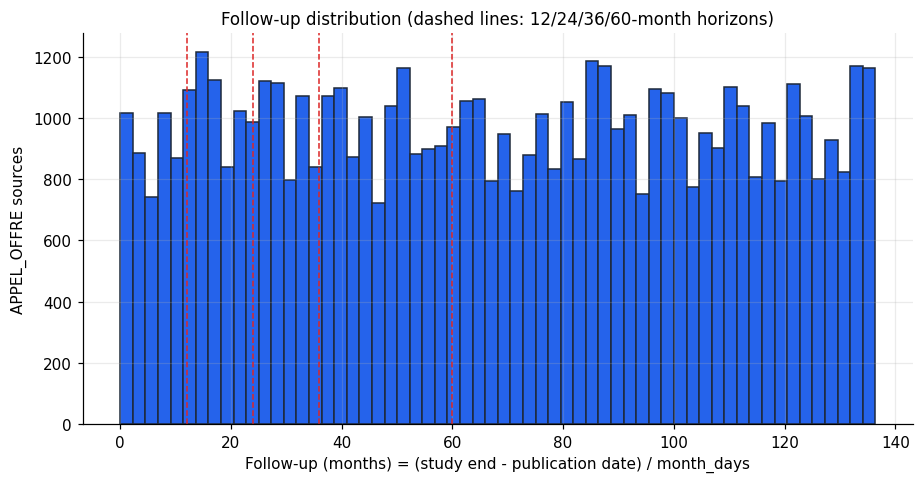

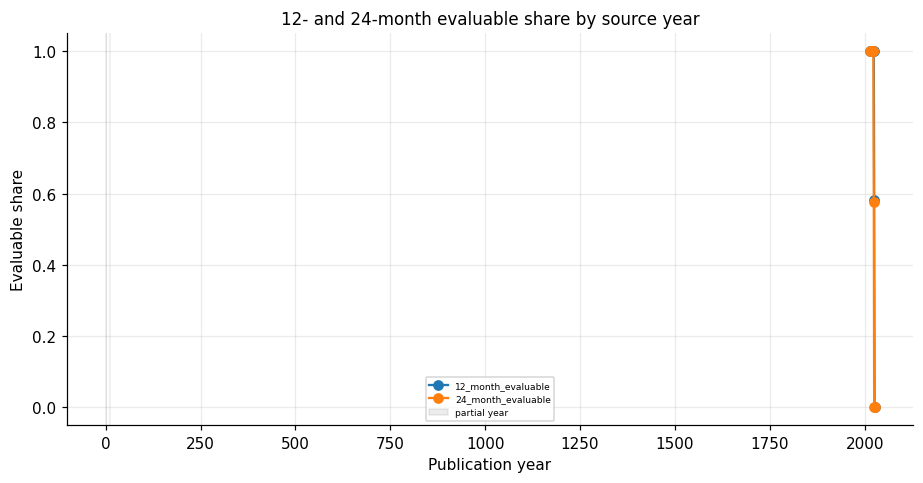

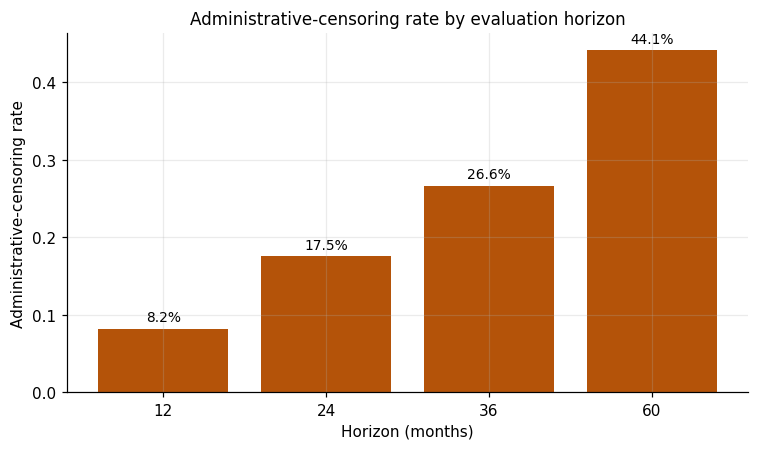

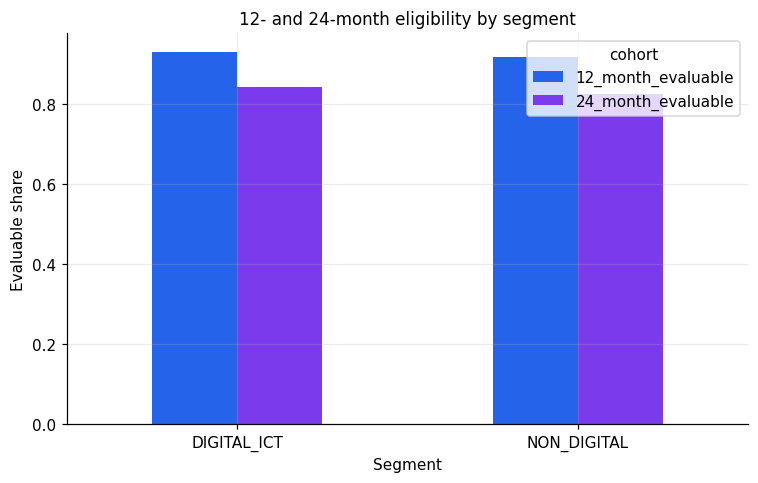

In [17]:
FOLLOWUP_FIG_DIR = cfg.paths.reports_figures / "synthetic_calibration" / "followup"
FOLLOWUP_FIG_DIR.mkdir(parents=True, exist_ok=True)
FOLLOWUP_HORIZONS = [12, 24, 36, 60]
FOLLOWUP_MONTH_DAYS = float(cfg.pipeline.run.month_days)


def save_followup_figure(fig, stem):
    paths = []
    for ext in ("png", "pdf"):
        out = FOLLOWUP_FIG_DIR / f"{stem}.{ext}"
        fig.savefig(out, bbox_inches="tight", dpi=200)
        paths.append(str(out))
    plt.close(fig)
    return paths


# Study end date: same definition as the pipeline's own build_source_population
# (src/boamp/data/prepare.py) - max publication_date over the full corpus, not
# just the eligible-source subset.
STUDY_END_DATE = common["publication_date"].max()

# APPEL_OFFRE sources, both digital-scope and non-digital-scope (scope is a
# conditioning dimension here, not a pre-filter, matching §12). Recomputed
# locally rather than reusing §13's candidate_source_mask/source_index so this
# section has no ordering dependency on §13 having already run.
appel_offre_mask_wp9 = common["notice_type_normalized"].eq("APPEL_OFFRE")
followup_availability = common.loc[appel_offre_mask_wp9, [
    "notice_id", "publication_date", "publication_year", "schema_family",
    "buyer_activity_tier", "buyer_key_type", "buyer_identifier_source", "is_digital_scope",
]].copy()
followup_availability["digital_segment"] = np.where(
    followup_availability["is_digital_scope"].astype(bool), "DIGITAL_ICT", "NON_DIGITAL")
followup_availability["study_end_date"] = STUDY_END_DATE
followup_availability["followup_days"] = (STUDY_END_DATE - followup_availability["publication_date"]).dt.days
followup_availability["followup_months"] = followup_availability["followup_days"] / FOLLOWUP_MONTH_DAYS

for h in FOLLOWUP_HORIZONS:
    followup_availability[f"evaluable_{h}m"] = followup_availability["followup_months"] >= h

followup_availability.to_csv(SYN_CALIB_DIR / "followup_availability.csv", index=False)

# --- 3 distinct populations: 12m evaluable, 24m evaluable, full survival cohort ---
followup_availability["overall"] = "ALL"
ANALYSIS_DIMS = ["overall", "publication_year", "digital_segment", "buyer_activity_tier",
                 "schema_family", "buyer_identifier_source"]
COHORT_MASKS = {
    "12_month_evaluable": followup_availability["evaluable_12m"],
    "24_month_evaluable": followup_availability["evaluable_24m"],
    "full_survival_cohort": pd.Series(True, index=followup_availability.index),
}

cohort_rows = []
for cohort_name, mask in COHORT_MASKS.items():
    for dim in ANALYSIS_DIMS:
        g_total = followup_availability.groupby(dim).size()
        g_evaluable = followup_availability.loc[mask].groupby(dim).size()
        for value in g_total.index:
            n_total_v = int(g_total.loc[value])
            n_eval_v = int(g_evaluable.get(value, 0))
            cohort_rows.append({
                "cohort": cohort_name, "stratum_dim": dim, "stratum_value": value,
                "n_total": n_total_v, "n_evaluable": n_eval_v,
                "evaluable_share": n_eval_v / n_total_v if n_total_v else np.nan,
                "admin_censoring_rate": 1 - (n_eval_v / n_total_v) if n_total_v else np.nan,
            })
evaluable_cohorts = pd.DataFrame(cohort_rows)
evaluable_cohorts.to_csv(SYN_CALIB_DIR / "evaluable_cohorts.csv", index=False)

print(f"APPEL_OFFRE sources (both scopes): {len(followup_availability):,}. Study end date: {STUDY_END_DATE.date()}.")
display(evaluable_cohorts.loc[evaluable_cohorts["stratum_dim"] == "overall"])

# --- exit criterion: horizon-evaluable never implies shorter-than-horizon follow-up ---
print("\nExit criterion — future-event evaluation must respect the available follow-up horizon:")
for h in FOLLOWUP_HORIZONS:
    n_violations = int((followup_availability[f"evaluable_{h}m"] & (followup_availability["followup_months"] < h)).sum())
    print(f"  {h}-month evaluable flag never implies < {h} months of follow-up: "
          f"{n_violations} violations")
    assert n_violations == 0, f"evaluable_{h}m flag is inconsistent with followup_months for {n_violations} sources"

# --- Figure 1: follow-up distribution ---
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.hist(followup_availability["followup_months"], bins=60, color="#2563eb", edgecolor="#1e293b")
for h in FOLLOWUP_HORIZONS:
    ax.axvline(h, color="#dc2626", linestyle="--", linewidth=1)
ax.set_xlabel("Follow-up (months) = (study end - publication date) / month_days")
ax.set_ylabel("APPEL_OFFRE sources")
ax.set_title("Follow-up distribution (dashed lines: 12/24/36/60-month horizons)")
plt.tight_layout()
plt.show()
save_followup_figure(fig, "followup_distribution")

# --- Figure 2: evaluable-share by year (12m and 24m) ---
by_year = evaluable_cohorts.loc[
    (evaluable_cohorts["stratum_dim"] == "publication_year")
    & evaluable_cohorts["cohort"].isin(["12_month_evaluable", "24_month_evaluable"])
]
pivot_year = by_year.pivot(index="stratum_value", columns="cohort", values="evaluable_share").sort_index()
fig, ax = plt.subplots(figsize=(8.5, 4.5))
pivot_year.plot(ax=ax, marker="o")
shade_partial_years(ax, pivot_year.index)
ax.set_xlabel("Publication year")
ax.set_ylabel("Evaluable share")
ax.set_title("12- and 24-month evaluable share by source year")
plt.tight_layout()
plt.show()
save_followup_figure(fig, "followup_evaluable_share_by_year")

# --- Figure 3: administrative-censoring rate by cohort (all 4 horizons) ---
admin_censoring_by_horizon = pd.Series({
    h: 1 - followup_availability[f"evaluable_{h}m"].mean() for h in FOLLOWUP_HORIZONS
})
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar([str(h) for h in FOLLOWUP_HORIZONS], admin_censoring_by_horizon.values, color="#b45309")
ax.set_xlabel("Horizon (months)")
ax.set_ylabel("Administrative-censoring rate")
ax.set_title("Administrative-censoring rate by evaluation horizon")
for i, v in enumerate(admin_censoring_by_horizon.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
save_followup_figure(fig, "followup_admin_censoring_rate_by_horizon")

# --- Figure 4: 12- and 24-month eligibility by segment ---
by_segment = evaluable_cohorts.loc[
    (evaluable_cohorts["stratum_dim"] == "digital_segment")
    & evaluable_cohorts["cohort"].isin(["12_month_evaluable", "24_month_evaluable"])
]
pivot_segment = by_segment.pivot(index="stratum_value", columns="cohort", values="evaluable_share")
fig, ax = plt.subplots(figsize=(7, 4.5))
pivot_segment.plot(kind="bar", ax=ax, color=["#2563eb", "#7c3aed"])
ax.set_xlabel("Segment")
ax.set_ylabel("Evaluable share")
ax.set_title("12- and 24-month eligibility by segment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
save_followup_figure(fig, "followup_eligibility_by_segment")

add_provenance(
    "followup_availability", "Per-source follow-up time and 12/24/36/60-month evaluability flags (Work Package 9)",
    "OBSERVABLE", "see table", "months / boolean", "by source notice",
    "data/interim/boamp_common_prepared.csv", "notice_id,publication_date,notice_type_normalized",
    "F_i = (study_end_date - publication_date_i) in months; study_end_date = "
    "max(publication_date) over the full corpus, matching build_source_population "
    "(src/boamp/data/prepare.py)", len(followup_availability), "13b", "followup_availability.csv",
    "Covers all APPEL_OFFRE sources regardless of digital scope (scope is a conditioning dimension, not a "
    "pre-filter, per §12); F_i is administrative follow-up only, independent of whether the pipeline actually "
    "linked the source to a later notice.")
add_provenance(
    "evaluable_cohorts", "12-month, 24-month, and full-survival-cohort populations, by year/segment/buyer-activity/schema/identifier-source",
    "OBSERVABLE", "see table", "count / share", "by cohort x stratum_dim x stratum_value",
    "data/interim/boamp_common_prepared.csv",
    "publication_date,publication_year,schema_family,buyer_activity_tier,buyer_key_type,"
    "buyer_identifier_source,is_digital_scope",
    "evaluable_share = n_evaluable / n_total within each stratum; admin_censoring_rate = 1 - evaluable_share",
    len(evaluable_cohorts), "13b", "evaluable_cohorts.csv",
    "full_survival_cohort has no fixed horizon by construction (every source belongs, right-censored at study "
    "end if unlinked), so its own admin_censoring_rate is trivially 0 everywhere; it is included as a population "
    "definition, not as a horizon-based exclusion like the 12/24-month cohorts.")


## 14. Unidentified parameters & required scenario knobs

The parameters below cannot be estimated from any BOAMP output examined in this repo —
there are zero completed manual-validation labels anywhere (`docs/methodology.md` §9), so
nothing establishes ground-truth renewal/linkage outcomes. A synthetic benchmark generator
should expose each of these as a **swept scenario parameter** (a grid or range), not a
single calibrated point estimate.

In [18]:
unidentified_params = pd.DataFrame([
    {"parameter_name": "true_recurrence_prevalence",
     "why_unidentified": "No verified legal-renewal field exists in BOAMP; the pipeline's own event rate "
                         "(29.7%/35.1%) is itself the output of an unvalidated scoring+threshold procedure, "
                         "not a measurement of real renewal behaviour.",
     "proposed_scenario_range": "e.g. sweep true recurrence prevalence in {10%, 25%, 40%, 60%}",
     "justification_or_none": "no empirical anchor; range chosen to bracket the pipeline's own uncalibrated estimates"},
    {"parameter_name": "true_linkage_precision_recall",
     "why_unidentified": "Zero completed manual-validation labels exist; Fellegi-Sunter EM estimates in "
                         "03_analysis are explicitly model-based, not ground-truth-validated.",
     "proposed_scenario_range": "sweep precision/recall of the *injected* synthetic linker across a grid, "
                                 "e.g. precision in {0.6,0.75,0.9}, recall in {0.5,0.7,0.9}",
     "justification_or_none": "no empirical anchor"},
    {"parameter_name": "true_buyer_entity_resolution_rate",
     "why_unidentified": "No registry cross-validation of BOAMP-native buyer identity exists in this repo; "
                         "the Layer 2 external SIREN join covers only 2024-2026 and the alias bridge is an "
                         "unvalidated heuristic.",
     "proposed_scenario_range": "sweep the fraction of buyer-name variants correctly resolved to one entity, "
                                 "e.g. {50%, 70%, 90%}",
     "justification_or_none": "no empirical anchor; range informed by observed fragmentation_rate as a floor, "
                               "see calib_buyer_name_fragmentation_summary.csv"},
    {"parameter_name": "true_candidate_ambiguity_resolution",
     "why_unidentified": "Which candidate among several plausible same-buyer notices is the *correct* renewal "
                         "is never verified; §15's rank-1 selection is a modelling choice, not ground truth.",
     "proposed_scenario_range": "vary the number of plausible-but-wrong candidates per true link, "
                                 "e.g. {0, 1-2, 3-5, 6+}, informed by §13's future-only candidate-density numbers",
     "justification_or_none": "partially anchored by §13 future-only candidate density; which candidate is correct is not"},
    {"parameter_name": "true_text_corruption_process",
     "why_unidentified": "No ground truth exists for how procurement text varies between a true renewal pair "
                         "vs. an unrelated notice; §10's exact-duplicate rate only measures literal repetition.",
     "proposed_scenario_range": "sweep text-similarity degradation severity for true-pair synthetic text, "
                                 "e.g. cosine similarity target ranges {0.3-0.5, 0.5-0.7, 0.7-0.9}",
     "justification_or_none": "no empirical anchor"},
])
unidentified_params.to_csv(SYN_CALIB_DIR / "calib_unidentified_parameters_scenarios.csv", index=False)
display(unidentified_params)

for _, r in unidentified_params.iterrows():
    add_provenance(r["parameter_name"], r["parameter_name"].replace("_", " "), "UNIDENTIFIED",
                    r["proposed_scenario_range"], "n/a", "n/a", "n/a (no BOAMP source establishes this)",
                    "n/a", "analyst judgment / literature-free", 0, "14",
                    "calib_unidentified_parameters_scenarios.csv", r["why_unidentified"])


,parameter_name,why_unidentified,proposed_scenario_range,justification_or_none
0,true_recurrence_prevalence,No verified legal-renewal field exists in BOAM...,"e.g. sweep true recurrence prevalence in {10%,...",no empirical anchor; range chosen to bracket t...
1,true_linkage_precision_recall,Zero completed manual-validation labels exist;...,sweep precision/recall of the *injected* synth...,no empirical anchor
2,true_buyer_entity_resolution_rate,No registry cross-validation of BOAMP-native b...,sweep the fraction of buyer-name variants corr...,no empirical anchor; range informed by observe...
3,true_candidate_ambiguity_resolution,Which candidate among several plausible same-b...,vary the number of plausible-but-wrong candida...,partially anchored by §13 future-only candidat...
4,true_text_corruption_process,No ground truth exists for how procurement tex...,sweep text-similarity degradation severity for...,no empirical anchor


## 15. [WALLED OFF — SILVER-STANDARD TIER ONLY] Error co-occurrence & score diagnostics from accepted links

**This is the primary section that reads Layer 1/Layer 2 linkage outputs.** (§15b below also reads `boamp_only_candidate_pairs.csv` — the pre-threshold candidate pool, not accepted links — purely as a structural text-similarity comparison group, never as ground truth.)
Every statistic below is conditional on the pipeline's own threshold-based acceptance
decision — it describes "what accepted links look like", not an unconditional error rate,
and must not be used to estimate true recurrence prevalence or true linkage accuracy
(see §14). All figures here carry an explicit tier badge.

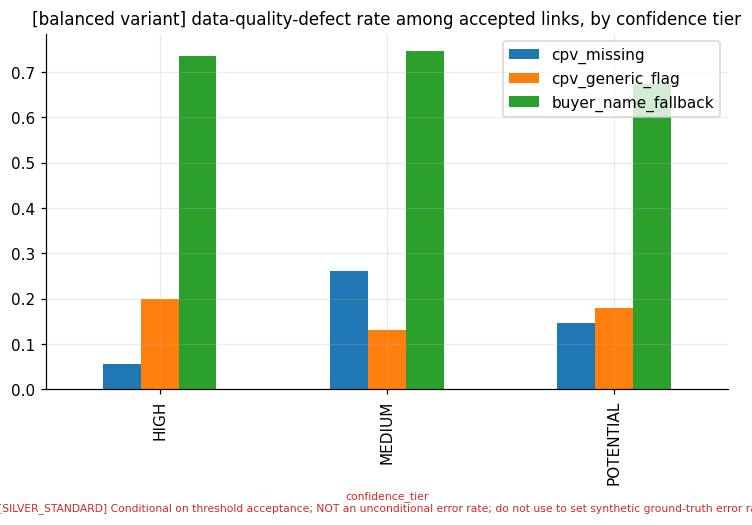

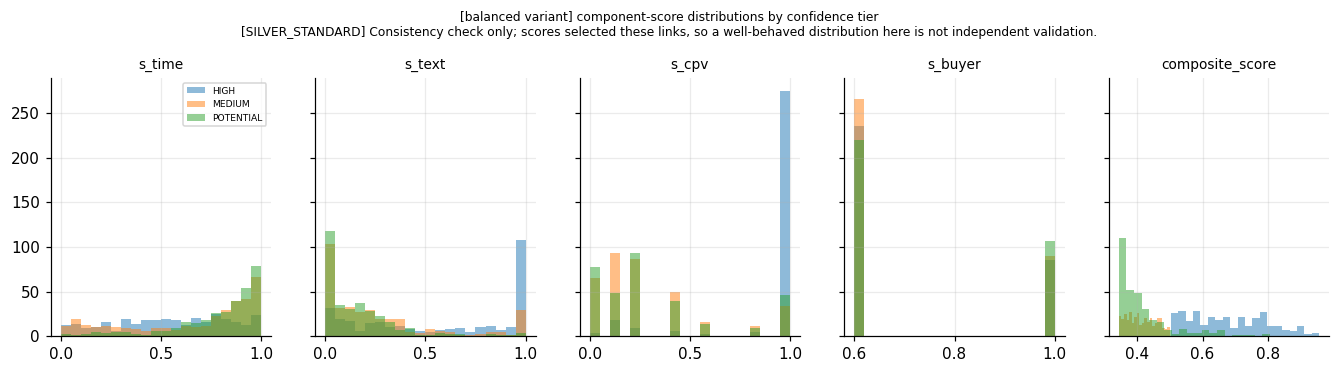

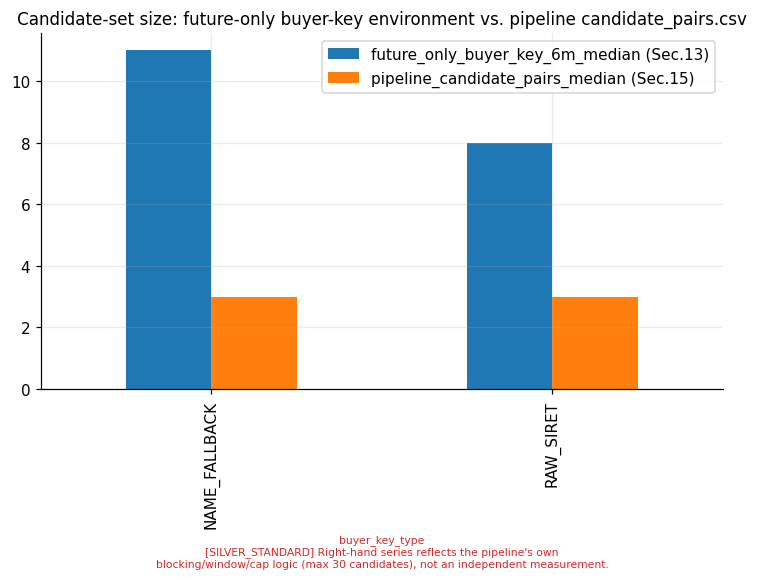

Alias bridge: 3159 buyer-identity propagations; 1002 unresolved native-vs-external SIREN conflicts flagged (never auto-resolved).


cpv_missing  cpv_generic_flag  buyer_name_fallback
variant  confidence_tier                                                    
balanced HIGH                0.056250          0.200000             0.734375
         MEDIUM              0.261236          0.132022             0.747191
         POTENTIAL           0.146789          0.180428             0.672783
broad    HIGH                0.056250          0.200000             0.734375
         MEDIUM              0.258621          0.127586             0.750000
         POTENTIAL           0.211921          0.162252             0.736755
strict   HIGH                0.056250          0.200000             0.734375
         MEDIUM              0.352941          0.127451             0.745098
         POTENTIAL           0.062500          0.212500             0.675000

In [19]:
D1, D2 = cfg.paths.processed_boamp_only, cfg.paths.processed_enriched
l1_pairs = pd.read_csv(D1 / "boamp_only_candidate_pairs.csv")
l1_links_balanced = pd.read_csv(D1 / "boamp_only_links_balanced.csv")
l1_links_broad = pd.read_csv(D1 / "boamp_only_links_broad.csv")
l1_links_strict = pd.read_csv(D1 / "boamp_only_links_strict.csv")
l1_links_balanced["variant"] = "balanced"; l1_links_broad["variant"] = "broad"; l1_links_strict["variant"] = "strict"
l1_links_all = pd.concat([l1_links_broad, l1_links_balanced, l1_links_strict], ignore_index=True)

alias_bridge = pd.read_csv(D2 / "alias_bridge.csv")
enrichment_conflicts = pd.read_csv(D2 / "enrichment_conflicts.csv")

# --- error co-occurrence among accepted links, by confidence tier ---
issue_cols = ["cpv_missing", "cpv_generic_flag"]
l1_links_all["buyer_name_fallback"] = l1_links_all["buyer_key_type"] == "NAME_FALLBACK"
error_cooccurrence_by_tier = l1_links_all.groupby(["variant", "confidence_tier"])[
    issue_cols + ["buyer_name_fallback"]].mean()
error_cooccurrence_by_tier.to_csv(SYN_CALIB_DIR / "calib_silver_error_cooccurrence_by_tier.csv")

# --- component-score distributions by confidence tier ---
score_cols = ["s_time", "s_text", "s_cpv", "s_buyer", "composite_score"]
score_summary_by_tier = l1_links_all.groupby(["variant", "confidence_tier"])[score_cols].agg(["mean", "median", "std"])
score_summary_by_tier.to_csv(SYN_CALIB_DIR / "calib_silver_score_component_summary_by_tier.csv")

# --- candidate ambiguity from candidate_pairs.csv (rank-1 rows), vs Section 13 ---
r1 = l1_pairs[l1_pairs["candidate_rank"] == 1]
candidate_ambiguity_by_quality = r1.groupby(["buyer_key_type", "cpv_missing"])[
    ["n_candidates_for_source", "top1_top2_margin"]].median()
candidate_ambiguity_by_quality.to_csv(SYN_CALIB_DIR / "calib_silver_candidate_ambiguity_by_quality.csv")

fig, ax = plt.subplots(figsize=(8, 4.2))
error_cooccurrence_by_tier.loc["balanced"].plot(kind="bar", ax=ax)
ax.set_title("[balanced variant] data-quality-defect rate among accepted links, by confidence tier")
add_tier_caveat_to_xlabel(ax, "SILVER_STANDARD",
                "Conditional on threshold acceptance; NOT an unconditional error rate; do not use to set synthetic ground-truth error rates.")
plt.show()
save_figure(fig, "calib_silver_error_cooccurrence", cfg)

fig, axes = plt.subplots(1, len(score_cols), figsize=(3 * len(score_cols), 3.4), sharey=True)
for ax, col in zip(axes, score_cols):
    for tier, sub in l1_links_all[l1_links_all["variant"] == "balanced"].groupby("confidence_tier"):
        ax.hist(sub[col], bins=20, alpha=0.5, label=tier)
    ax.set_title(col, fontsize=9)
axes[0].legend(fontsize=6)
fig.suptitle("[balanced variant] component-score distributions by confidence tier\n"
             "[SILVER_STANDARD] Consistency check only; scores selected these links, so a well-behaved "
             "distribution here is not independent validation.", fontsize=8, color="black")
fig.subplots_adjust(top=0.80)
plt.show()
save_figure(fig, "calib_silver_score_distributions_by_tier", cfg)

fig, ax = plt.subplots(figsize=(8, 4.2))
r1_median_by_W = candidate_env_by_window[candidate_env_by_window["window_months"] == 6] \
    .set_index("buyer_key_type")["median"]
pipeline_median = r1.groupby("buyer_key_type")["n_candidates_for_source"].median()
compare = pd.DataFrame({"future_only_buyer_key_6m_median (Sec.13)": r1_median_by_W,
                         "pipeline_candidate_pairs_median (Sec.15)": pipeline_median}).dropna()
compare.plot(kind="bar", ax=ax)
ax.set_title("Candidate-set size: future-only buyer-key environment vs. pipeline candidate_pairs.csv")
add_tier_caveat_to_xlabel(ax, "SILVER_STANDARD",
                "Right-hand series reflects the pipeline's own\nblocking/window/cap logic (max 30 candidates), not an independent measurement.")
plt.show()
save_figure(fig, "calib_silver_candidate_ambiguity", cfg)

print(f"Alias bridge: {len(alias_bridge)} buyer-identity propagations; {len(enrichment_conflicts)} unresolved "
      f"native-vs-external SIREN conflicts flagged (never auto-resolved).")
display(error_cooccurrence_by_tier)

add_provenance("silver_error_cooccurrence_by_tier", "Data-quality-defect co-occurrence among accepted links",
                "SILVER_STANDARD", "see table", "rate", "by threshold variant x confidence_tier",
                "data/processed/boamp_only/boamp_only_links_{broad,balanced,strict}.csv",
                "cpv_missing,cpv_generic_flag,buyer_key_type,confidence_tier",
                "groupby variant+confidence_tier, mean of flags", len(l1_links_all), "15",
                "calib_silver_error_cooccurrence_by_tier.csv",
                "Conditional on the pipeline's own threshold-based acceptance; selection bias by construction; "
                "must not be used as an unconditional error rate or to estimate true linkage accuracy.")
add_provenance("silver_candidate_ambiguity", "Candidate-set size/margin at rank-1, by identifier/CPV quality",
                "SILVER_STANDARD", "see table", "count / margin", "by buyer_key_type x cpv_missing",
                "data/processed/boamp_only/boamp_only_candidate_pairs.csv",
                "n_candidates_for_source,top1_top2_margin,buyer_key_type,cpv_missing",
                "groupby median", len(r1), "15",
                "calib_silver_candidate_ambiguity_by_quality.csv",
                "Reflects the pipeline's own 6-month window and 30-candidate cap (config/pipeline.yaml); "
                "compare against Section 13's future-only environment rebuild, do not treat as the 'true' candidate density.")


## 15b. Procurement-text similarity environment (Work Package 6)

**Main question.** What distinguishes repeated publications, plausible recurring needs,
same-buyer distractors, and same-theme false candidates, in *text* similarity terms?

**Pair groups.** Eight structural comparison groups, block-sampled (capped per block and
per group) from the full prepared corpus:

1. `same_notice_family` — pairs within the same §10b provisional notice family (repeated
   publications of one procurement episode). The only group with a relatively strong
   observable relationship; groups 2-7 below are structural comparisons, not recurrence
   truth.
2. `same_siret_same_cpv` — same SIRET and same detailed CPV.
3. `same_siren_same_cpv_diff_siret` — same SIREN, same detailed CPV, different SIRET
   (isolates organization-level from establishment-level recurrence).
4. `same_buyer_different_cpv` — same buyer, different CPV division (same-buyer
   distractors).
5. `different_buyer_same_cpv` — different buyer, same detailed CPV (cross-buyer
   same-theme candidates).
6. `different_buyer_different_cpv` — different buyer, different CPV division (random
   baseline).
7. `same_generic_name_conflicting_siren` — same generic buyer name (§7's
   `is_generic_name`) mapping to conflicting SIRENs.
8. `actual_candidate_pipeline_rank1` — the Layer 1 pipeline's own rank-1 candidate per
   source (`data/processed/boamp_only/boamp_only_candidate_pairs.csv`, reusing §15's
   already-loaded `l1_pairs`). This is the **pre-threshold candidate pool, not accepted
   links** — a structural comparison group only, sourced from `data/processed/` and tagged
   SILVER_STANDARD/`DO_NOT_CALIBRATE` like §15, never used to set synthetic ground truth.

**Similarity measures**, computed independently of the pipeline's own fitted vectorizer
(except where §15's `l1_pairs.s_text` is retained for group 8 as the pipeline's own
value): word TF-IDF cosine (reuses the §10b-fitted matrix), character 3-5gram TF-IDF
cosine, token Jaccard, and key-technical-term overlap (an independent vocabulary with
place-name/administrative-suffix stoplists from §7 removed). Sentence embeddings are
**not** computed here — evaluated and rejected earlier for CPU-only runtime
(`docs/methodology.md` §5) — so this section relies on lexical measures only.

**Hard negatives.** `same_buyer_different_cpv` pairs that also share a CPV division and
whose word-TF-IDF cosine clears the `different_buyer_different_cpv` baseline's own p90 —
necessary because an easy synthetic benchmark without these would overstate linker
performance.

**Outputs.** `text_similarity_groups.csv`, `text_hard_negative_sample.csv`,
`text_duplicate_groups.csv` (plus supplementary summary/plot-source tables, as with every
other section).

**Exit criterion.** Separate empirical similarity distributions are reported and asserted
non-empty for repeated-publication similarity (`same_notice_family`), same-buyer
distractor similarity (`same_buyer_different_cpv`), and cross-buyer same-theme similarity
(`different_buyer_same_cpv`); true-recurrence similarity still requires the scenario
assumptions flagged throughout this notebook (§14).


text_similarity_groups: 22,928 pairs across 8 groups.
text_hard_negative_sample: 500 rows (word_tfidf_cosine >= baseline p90 = 0.031).
text_duplicate_groups: 19,897 groups, 45,601 notices.


,pair_group,n_pairs,word_tfidf_cosine_median,word_tfidf_cosine_p10,word_tfidf_cosine_p90,char_ngram_cosine_median,char_ngram_cosine_p10,char_ngram_cosine_p90,token_jaccard_median,token_jaccard_p10,token_jaccard_p90,key_term_overlap_median,key_term_overlap_p10,key_term_overlap_p90
0,actual_candidate_pipeline_rank1,2005,0.058009,0.003033,0.723134,0.150582,0.019839,0.793954,0.153846,0.045455,0.641714,0.000000,0.000000,0.70
1,different_buyer_different_cpv,4000,0.008510,0.000000,0.031003,0.028347,0.007800,0.079330,0.074074,0.000000,0.142857,0.000000,0.000000,0.00
2,different_buyer_same_cpv,4000,0.033899,0.001869,0.278283,0.125333,0.018225,0.426536,0.125000,0.035714,0.300000,0.000000,0.000000,0.40
3,same_buyer_different_cpv,4000,0.013351,0.000000,0.225069,0.049500,0.008008,0.311161,0.095238,0.000000,0.240000,0.000000,0.000000,0.20
4,same_generic_name_conflicting_siren,222,0.022142,0.002250,0.240444,0.079539,0.014228,0.384252,0.125000,0.041848,0.333333,0.000000,0.000000,0.40
5,same_notice_family,4000,1.000000,0.901759,1.000000,1.000000,0.891880,1.000000,1.000000,0.833333,1.000000,1.000000,0.666667,1.00
6,same_siren_same_cpv_diff_siret,701,0.101503,0.007111,0.690267,0.220970,0.034212,0.737017,0.208333,0.058824,0.666667,0.200000,0.000000,0.75
7,same_siret_same_cpv,4000,0.209847,0.006676,0.862434,0.345625,0.036872,0.907510,0.276820,0.066667,0.823529,0.285714,0.000000,1.00



Exit criterion — separate empirical distributions:
  repeated-publication similarity        (pair_group=same_notice_family): n= 4000  median=1.000  p90=1.000
  same-buyer distractor similarity       (pair_group=same_buyer_different_cpv): n= 4000  median=0.013  p90=0.225
  cross-buyer same-theme similarity      (pair_group=different_buyer_same_cpv): n= 4000  median=0.034  p90=0.278


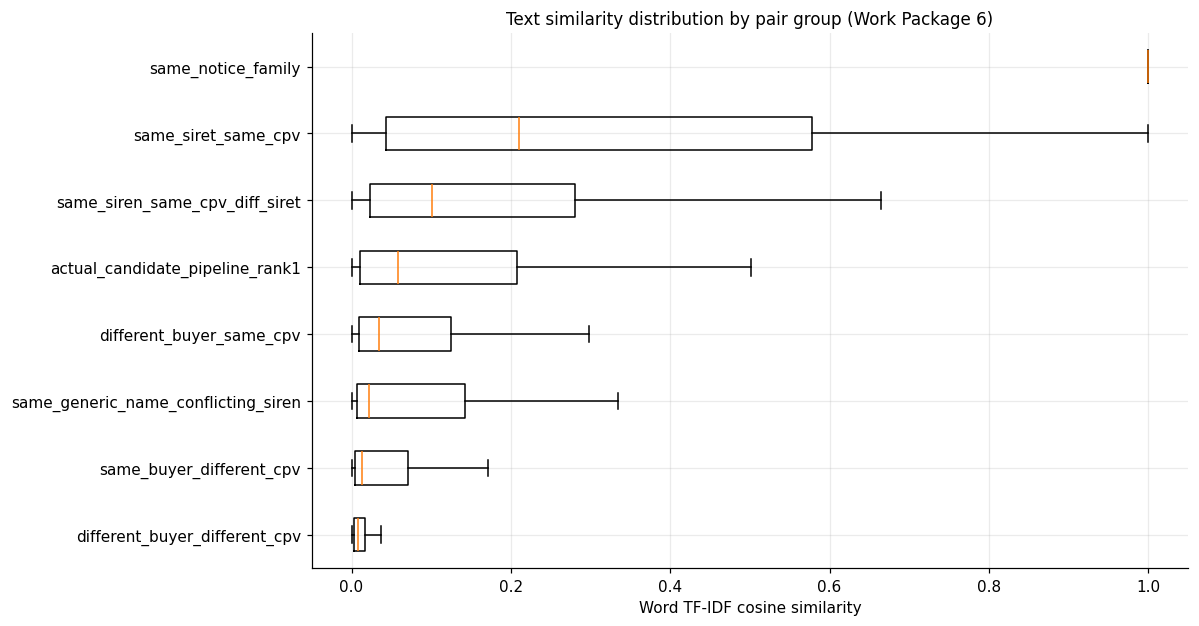

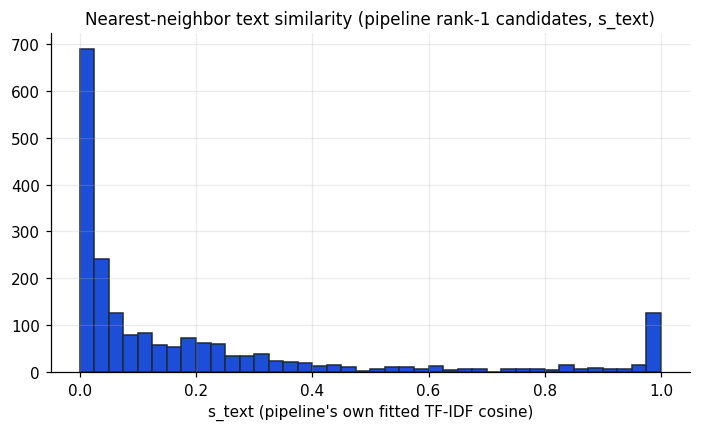

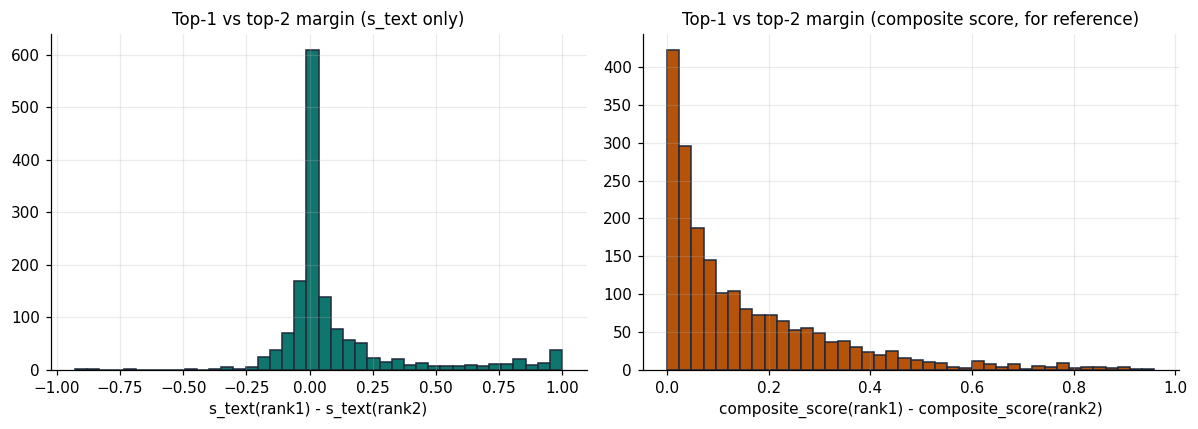

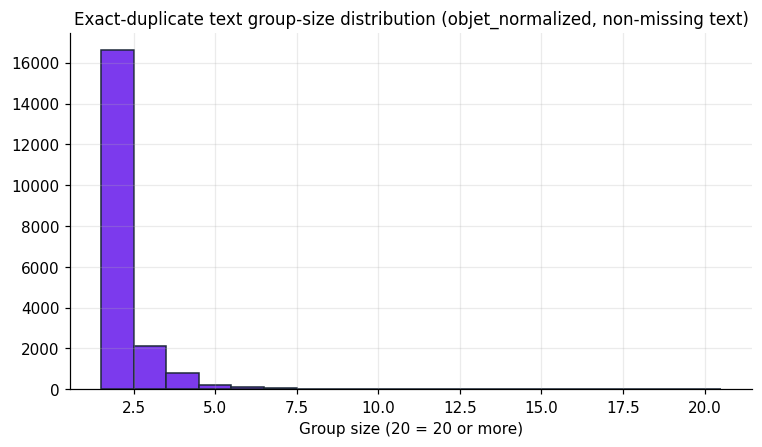

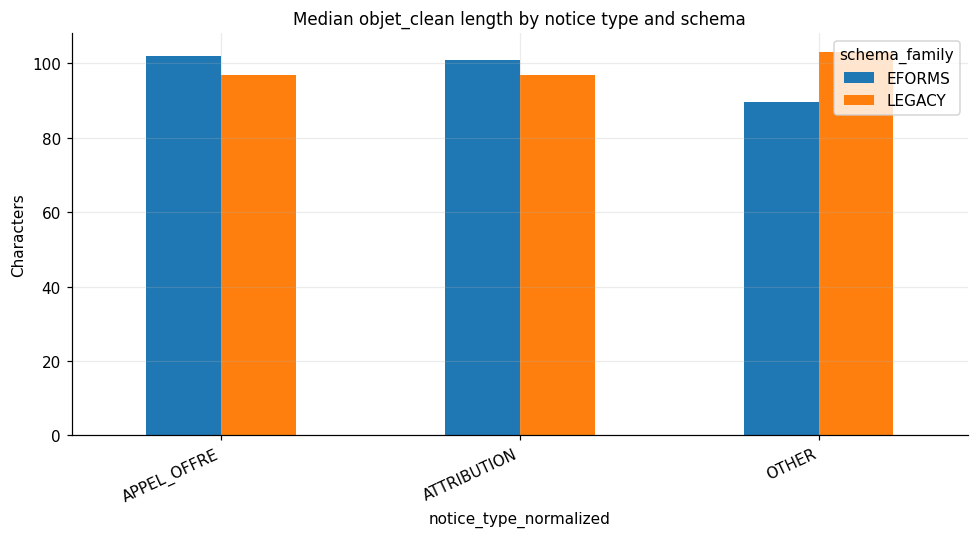

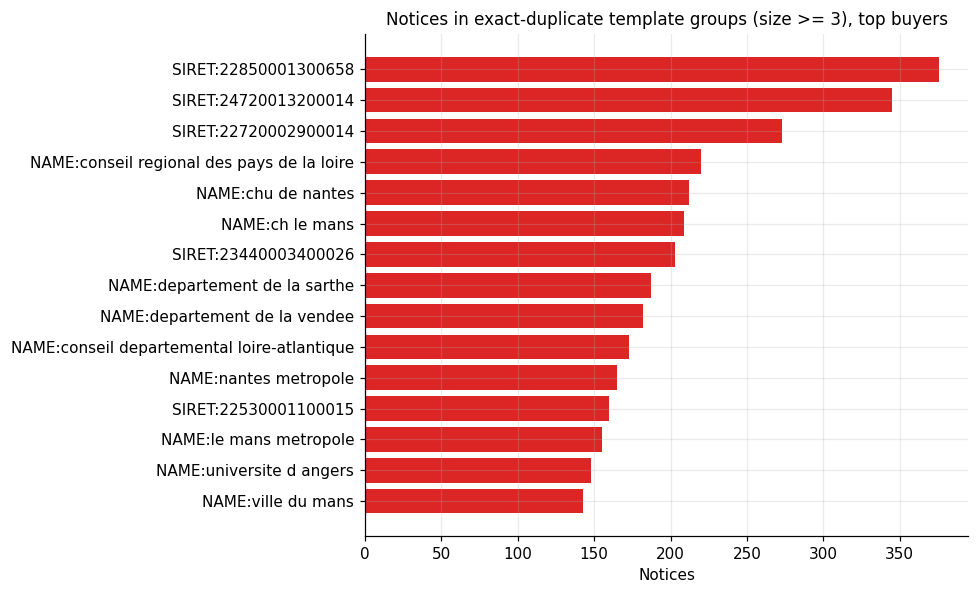

In [20]:
import re
from itertools import combinations
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

TEXT_SIM_FIG_DIR = cfg.paths.reports_figures / "synthetic_calibration" / "text_similarity"
TEXT_SIM_FIG_DIR.mkdir(parents=True, exist_ok=True)
rng_ts = np.random.default_rng(20260721)
MAX_PAIRS_PER_GROUP = 4000
MAX_PER_BLOCK = 8
TEMPLATE_MIN_GROUP_SIZE = 3


def save_text_sim_figure(fig, stem):
    paths = []
    for ext in ("png", "pdf"):
        out = TEXT_SIM_FIG_DIR / f"{stem}.{ext}"
        fig.savefig(out, bbox_inches="tight", dpi=200)
        paths.append(str(out))
    plt.close(fig)
    return paths


# --- similarity measures ----------------------------------------------------
# Word TF-IDF cosine reuses the §10b-fitted matrix (objet_normalized, 1-2 grams,
# min_df 2) rather than refitting a second word-level vectorizer.
word_tfidf = notice_family_tfidf

# Character n-gram cosine: an independent vectorizer over the same text, catches
# near-duplicate phrasing word-level TF-IDF misses (typos, merged/split tokens).
char_vectorizer = TfidfVectorizer(max_features=50000, analyzer="char_wb", ngram_range=(3, 5), min_df=2)
char_tfidf = char_vectorizer.fit_transform(common["objet_normalized"].fillna("").tolist())

TOKEN_RE = re.compile(r"[a-z0-9]+")


def _token_set(value):
    if not isinstance(value, str):
        return frozenset()
    return frozenset(TOKEN_RE.findall(value.lower()))


token_sets = common["objet_normalized"].map(_token_set)

# Key technical-term vocabulary: a fourth, independent CountVectorizer fit,
# distinct from §10's 30-term display profile, with §7's place-name and
# administrative/legal stoplists (LOCATION_TOKENS/SERVICE_TOKENS/
# LEGAL_SUFFIX_TOKENS) removed so overlap reflects procurement subject matter
# rather than shared geography or boilerplate administrative phrasing.
_key_term_vectorizer = CountVectorizer(max_features=400, ngram_range=(1, 1), min_df=15, stop_words=FR_STOPWORDS)
_key_term_vectorizer.fit(common["objet_normalized"].fillna(""))
KEY_TERM_VOCAB = frozenset(
    t for t in _key_term_vectorizer.get_feature_names_out()
    if t not in LOCATION_TOKENS and t not in SERVICE_TOKENS and t not in LEGAL_SUFFIX_TOKENS
)

nid_to_idx = pd.Series(common.index, index=common["notice_id"])


def _pair_row(idx_a, idx_b, pair_group):
    a, b = common.loc[idx_a], common.loc[idx_b]
    ta, tb = token_sets.loc[idx_a], token_sets.loc[idx_b]
    union = ta | tb
    tok_jac = len(ta & tb) / len(union) if union else np.nan
    ka, kb = ta & KEY_TERM_VOCAB, tb & KEY_TERM_VOCAB
    key_union = ka | kb
    key_overlap = len(ka & kb) / len(key_union) if key_union else np.nan
    cpv_a, cpv_b = a["cpv_clean"], b["cpv_clean"]
    div_a, div_b = a["cpv_division"], b["cpv_division"]
    return {
        "pair_group": pair_group,
        "source_notice_id": a["notice_id"], "target_notice_id": b["notice_id"],
        "source_buyer_key": a["buyer_key"], "target_buyer_key": b["buyer_key"],
        "source_cpv_clean": cpv_a, "target_cpv_clean": cpv_b,
        "same_buyer_key": a["buyer_key"] == b["buyer_key"],
        "same_cpv_clean": bool(pd.notna(cpv_a) and cpv_a == cpv_b),
        "same_cpv_division": bool(pd.notna(div_a) and div_a == div_b),
        "word_tfidf_cosine": float(word_tfidf[idx_a].multiply(word_tfidf[idx_b]).sum()),
        "char_ngram_cosine": float(char_tfidf[idx_a].multiply(char_tfidf[idx_b]).sum()),
        "token_jaccard": tok_jac,
        "key_term_overlap": key_overlap,
    }


def _cap_pairs(pairs, max_pairs, rng):
    if len(pairs) > max_pairs:
        sel = rng.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[i] for i in sel]
    return pairs


def _combos_within_blocks(block_cols, extra_filter=None, exclude_same_family=True,
                           max_per_block=MAX_PER_BLOCK, rng=rng_ts):
    pairs = []
    for _, group in common.dropna(subset=block_cols).groupby(block_cols, sort=False):
        idxs = group.index.to_numpy()
        if len(idxs) < 2:
            continue
        if len(idxs) > max_per_block:
            idxs = rng.choice(idxs, size=max_per_block, replace=False)
        for a, b in combinations(sorted(idxs), 2):
            if exclude_same_family and common.at[a, "notice_family_id"] == common.at[b, "notice_family_id"]:
                continue
            if extra_filter is not None and not extra_filter(a, b):
                continue
            pairs.append((a, b))
    return pairs


def _diff_siret(a, b):
    sa, sb = common.at[a, "buyer_siret_clean"], common.at[b, "buyer_siret_clean"]
    return pd.isna(sa) or pd.isna(sb) or sa != sb


def _diff_cpv_division(a, b):
    da, db = common.at[a, "cpv_division"], common.at[b, "cpv_division"]
    return pd.notna(da) and pd.notna(db) and da != db


def _diff_buyer(a, b):
    return common.at[a, "buyer_key"] != common.at[b, "buyer_key"]


def _diff_cpv_clean(a, b):
    ca, cb = common.at[a, "cpv_clean"], common.at[b, "cpv_clean"]
    return pd.notna(ca) and pd.notna(cb) and ca != cb


def _sample_random_pairs(n_target, rng):
    valid_idx = common.dropna(subset=["objet_normalized", "buyer_key", "cpv_division"]).index.to_numpy()
    collected = []
    n_collected = 0
    while n_collected < n_target:
        batch = max(n_target * 3, 1000)
        a = rng.choice(valid_idx, size=batch)
        b = rng.choice(valid_idx, size=batch)
        mask = a != b
        a, b = a[mask], b[mask]
        buyer_a = common.loc[a, "buyer_key"].to_numpy()
        buyer_b = common.loc[b, "buyer_key"].to_numpy()
        div_a = common.loc[a, "cpv_division"].to_numpy()
        div_b = common.loc[b, "cpv_division"].to_numpy()
        keep = (buyer_a != buyer_b) & (div_a != div_b)
        collected.append(np.stack([a[keep], b[keep]], axis=1))
        n_collected = sum(len(x) for x in collected)
    arr = np.concatenate(collected, axis=0)[:n_target]
    return [tuple(row) for row in arr]


# --- 8 pair groups -----------------------------------------------------------
family_pairs_df = notice_family_similarity_pairs.loc[notice_family_similarity_pairs["pair_scope"] == "within_family"]
family_pairs = list(zip(nid_to_idx.reindex(family_pairs_df["source_notice_id"]).to_numpy(),
                        nid_to_idx.reindex(family_pairs_df["target_notice_id"]).to_numpy()))
family_pairs = _cap_pairs(family_pairs, MAX_PAIRS_PER_GROUP, rng_ts)

group2_pairs = _cap_pairs(_combos_within_blocks(["buyer_siret_clean", "cpv_clean"]), MAX_PAIRS_PER_GROUP, rng_ts)
group3_pairs = _cap_pairs(
    _combos_within_blocks(["buyer_siren_clean", "cpv_clean"], extra_filter=_diff_siret), MAX_PAIRS_PER_GROUP, rng_ts)
group4_pairs = _cap_pairs(
    _combos_within_blocks(["buyer_key"], extra_filter=_diff_cpv_division), MAX_PAIRS_PER_GROUP, rng_ts)
group5_pairs = _cap_pairs(
    _combos_within_blocks(["cpv_clean"], extra_filter=_diff_buyer, max_per_block=10), MAX_PAIRS_PER_GROUP, rng_ts)
group6_pairs = _sample_random_pairs(MAX_PAIRS_PER_GROUP, rng_ts)

ambiguous_generic_names = buyer_name_ambiguity.loc[
    buyer_name_ambiguity["is_generic_name"] & buyer_name_ambiguity["different_sirens"], "buyer_name_normalized"]
group7_pairs = []
for name in ambiguous_generic_names:
    sub = common.loc[common["buyer_name_normalized"] == name].dropna(subset=["buyer_siren_clean"])
    if sub["buyer_siren_clean"].nunique() < 2:
        continue
    reps = sub.sort_values("publication_date").groupby("buyer_siren_clean").head(1)
    for a, b in combinations(reps.index.to_numpy(), 2):
        group7_pairs.append((a, b))
group7_pairs = _cap_pairs(group7_pairs, MAX_PAIRS_PER_GROUP, rng_ts)

rank1 = l1_pairs.loc[l1_pairs["candidate_rank"] == 1].copy()
rank1_valid = rank1.loc[
    rank1["source_notice_id"].isin(nid_to_idx.index) & rank1["candidate_notice_id"].isin(nid_to_idx.index)]
if len(rank1_valid) > MAX_PAIRS_PER_GROUP:
    rank1_valid = rank1_valid.sample(MAX_PAIRS_PER_GROUP, random_state=20260721)
group8_pairs = list(zip(nid_to_idx.loc[rank1_valid["source_notice_id"]].to_numpy(),
                        nid_to_idx.loc[rank1_valid["candidate_notice_id"]].to_numpy()))

GROUP_PAIRS = {
    "same_notice_family": family_pairs,
    "same_siret_same_cpv": group2_pairs,
    "same_siren_same_cpv_diff_siret": group3_pairs,
    "same_buyer_different_cpv": group4_pairs,
    "different_buyer_same_cpv": group5_pairs,
    "different_buyer_different_cpv": group6_pairs,
    "same_generic_name_conflicting_siren": group7_pairs,
    "actual_candidate_pipeline_rank1": group8_pairs,
}

text_sim_rows = []
for group_name, pairs in GROUP_PAIRS.items():
    for a, b in pairs:
        text_sim_rows.append(_pair_row(int(a), int(b), group_name))
text_similarity_groups = pd.DataFrame(text_sim_rows)

pipeline_cols = rank1_valid[[
    "source_notice_id", "candidate_notice_id", "s_text", "composite_score",
    "n_candidates_for_source", "top1_top2_margin",
]].rename(columns={"candidate_notice_id": "target_notice_id", "s_text": "pipeline_s_text"})
text_similarity_groups = text_similarity_groups.merge(
    pipeline_cols, on=["source_notice_id", "target_notice_id"], how="left")

SIM_COLS = ["word_tfidf_cosine", "char_ngram_cosine", "token_jaccard", "key_term_overlap"]
_agg_kwargs = {"n_pairs": ("word_tfidf_cosine", "size")}
for c in SIM_COLS:
    _agg_kwargs[f"{c}_median"] = (c, "median")
    _agg_kwargs[f"{c}_p10"] = (c, lambda s: s.quantile(0.10))
    _agg_kwargs[f"{c}_p90"] = (c, lambda s: s.quantile(0.90))
text_similarity_group_summary = text_similarity_groups.groupby("pair_group").agg(**_agg_kwargs).reset_index()

# --- exact-duplicate text groups (template reuse, independent of §10b families) ---
dup_universe = common.loc[common["objet_normalized"].notna(),
                           ["notice_id", "objet_normalized", "buyer_key", "cpv_clean"]].copy()
dup_universe["text_duplicate_group_id"] = dup_universe.groupby("objet_normalized", sort=False).ngroup()
dup_universe["group_size"] = dup_universe.groupby("text_duplicate_group_id")["notice_id"].transform("size")
text_duplicate_groups = dup_universe.loc[dup_universe["group_size"] > 1].copy()
text_duplicate_groups["n_unique_buyers_in_group"] = text_duplicate_groups.groupby(
    "text_duplicate_group_id")["buyer_key"].transform("nunique")
text_duplicate_groups["n_unique_cpv_in_group"] = text_duplicate_groups.groupby(
    "text_duplicate_group_id")["cpv_clean"].transform("nunique")
text_duplicate_groups["objet_snippet"] = text_duplicate_groups["objet_normalized"].str.slice(0, 80)
text_duplicate_groups = text_duplicate_groups.drop(columns=["objet_normalized"])

template_rows = text_duplicate_groups.loc[text_duplicate_groups["group_size"] >= TEMPLATE_MIN_GROUP_SIZE]
repeated_template_by_buyer = (
    template_rows.groupby("buyer_key").size().sort_values(ascending=False).rename("n_templated_notices").reset_index())

# --- text length by notice type and schema ---
text_length_by_notice_type_schema = common.groupby(["notice_type_normalized", "schema_family"]).agg(
    median_length=("text_length", "median"), n=("text_length", "size")).reset_index()

# --- hard negatives: same buyer, same CPV division, high text similarity, distinct detailed CPV ---
# A dedicated pool, not one of the 8 named pair_group values above: group4
# (same_buyer_different_cpv) is deliberately built on differing cpv_division
# (a clearly different theme), so it can never contain a "similar CPV" pair by
# construction. Hard negatives need the middle ground - same buyer, same
# division, but a different detailed code - which this pool targets directly.
baseline_p90 = text_similarity_group_summary.loc[
    text_similarity_group_summary["pair_group"] == "different_buyer_different_cpv", "word_tfidf_cosine_p90"].iloc[0]
hard_negative_pool_pairs = _cap_pairs(
    _combos_within_blocks(["buyer_key", "cpv_division"], extra_filter=_diff_cpv_clean),
    MAX_PAIRS_PER_GROUP, rng_ts)
hard_negative_pool = pd.DataFrame(
    [_pair_row(int(a), int(b), "hard_negative_candidate_pool") for a, b in hard_negative_pool_pairs])
hard_negative_candidates = hard_negative_pool.loc[
    hard_negative_pool["word_tfidf_cosine"] >= baseline_p90
].sort_values("word_tfidf_cosine", ascending=False)
text_hard_negative_sample = hard_negative_candidates.head(500).copy()
_objet_clean_map = common.set_index("notice_id")["objet_clean"]
text_hard_negative_sample["source_objet_clean"] = text_hard_negative_sample["source_notice_id"].map(_objet_clean_map)
text_hard_negative_sample["target_objet_clean"] = text_hard_negative_sample["target_notice_id"].map(_objet_clean_map)

# --- required outputs ---
text_similarity_groups.to_csv(SYN_CALIB_DIR / "text_similarity_groups.csv", index=False)
text_hard_negative_sample.to_csv(SYN_CALIB_DIR / "text_hard_negative_sample.csv", index=False)
text_duplicate_groups.to_csv(SYN_CALIB_DIR / "text_duplicate_groups.csv", index=False)
text_similarity_group_summary.to_csv(SYN_CALIB_DIR / "calib_text_similarity_group_summary.csv", index=False)
repeated_template_by_buyer.to_csv(SYN_CALIB_DIR / "calib_text_repeated_template_by_buyer.csv", index=False)
text_length_by_notice_type_schema.to_csv(SYN_CALIB_DIR / "calib_text_length_by_notice_type_schema.csv", index=False)

print(f"text_similarity_groups: {len(text_similarity_groups):,} pairs across {text_similarity_groups['pair_group'].nunique()} groups.")
print(f"text_hard_negative_sample: {len(text_hard_negative_sample):,} rows "
      f"(word_tfidf_cosine >= baseline p90 = {baseline_p90:.3f}).")
print(f"text_duplicate_groups: {text_duplicate_groups['text_duplicate_group_id'].nunique():,} groups, "
      f"{len(text_duplicate_groups):,} notices.")
display(text_similarity_group_summary)

# --- exit criterion: three named comparison groups must have non-empty distributions ---
REQUIRED_EXIT_GROUPS = {
    "same_notice_family": "repeated-publication similarity",
    "same_buyer_different_cpv": "same-buyer distractor similarity",
    "different_buyer_same_cpv": "cross-buyer same-theme similarity",
}
print("\nExit criterion — separate empirical distributions:")
for g, label in REQUIRED_EXIT_GROUPS.items():
    sub = text_similarity_groups.loc[text_similarity_groups["pair_group"] == g, "word_tfidf_cosine"]
    print(f"  {label:38s} (pair_group={g}): n={len(sub):5d}  median={sub.median():.3f}  p90={sub.quantile(0.9):.3f}")
assert all((text_similarity_groups["pair_group"] == g).sum() > 0 for g in REQUIRED_EXIT_GROUPS), \
    "exit criterion requires a non-empty sample for each of the three named comparison groups"

# --- Figure 1: similarity distributions by pair group ---
order = text_similarity_group_summary.sort_values("word_tfidf_cosine_median")["pair_group"]
fig, ax = plt.subplots(figsize=(11, 5.8))
data = [text_similarity_groups.loc[text_similarity_groups["pair_group"] == g, "word_tfidf_cosine"].dropna() for g in order]
ax.boxplot(data, tick_labels=list(order), orientation="horizontal", showfliers=False)
ax.set_xlabel("Word TF-IDF cosine similarity")
ax.set_title("Text similarity distribution by pair group (Work Package 6)")
plt.tight_layout()
plt.show()
save_text_sim_figure(fig, "text_similarity_by_pair_group")

# --- Figure 2: nearest-neighbor similarity (pipeline rank-1 candidates) ---
fig, ax = plt.subplots(figsize=(7.5, 4))
nn_sim = text_similarity_groups.loc[
    text_similarity_groups["pair_group"] == "actual_candidate_pipeline_rank1", "pipeline_s_text"].dropna()
ax.hist(nn_sim, bins=40, color="#1d4ed8", edgecolor="#1e293b")
ax.set_title("Nearest-neighbor text similarity (pipeline rank-1 candidates, s_text)")
ax.set_xlabel("s_text (pipeline's own fitted TF-IDF cosine)")
plt.show()
save_text_sim_figure(fig, "text_nearest_neighbor_similarity")

# --- Figure 3: top-1 vs top-2 margins (text-only, vs composite for reference) ---
rank12 = l1_pairs.loc[l1_pairs["candidate_rank"].isin([1, 2])]
multi_cand_sources = l1_pairs.loc[
    (l1_pairs["candidate_rank"] == 1) & (l1_pairs["n_candidates_for_source"] >= 2), "source_notice_id"]
pivot_stext = rank12.pivot_table(index="source_notice_id", columns="candidate_rank", values="s_text")
text_top1_top2_margin = (pivot_stext[1] - pivot_stext[2]).loc[
    pivot_stext.index.intersection(multi_cand_sources)].dropna()
composite_margin = l1_pairs.loc[l1_pairs["candidate_rank"] == 1, "top1_top2_margin"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(text_top1_top2_margin, bins=40, color="#0f766e", edgecolor="#1e293b")
axes[0].set_title("Top-1 vs top-2 margin (s_text only)")
axes[0].set_xlabel("s_text(rank1) - s_text(rank2)")
axes[1].hist(composite_margin.dropna(), bins=40, color="#b45309", edgecolor="#1e293b")
axes[1].set_title("Top-1 vs top-2 margin (composite score, for reference)")
axes[1].set_xlabel("composite_score(rank1) - composite_score(rank2)")
plt.tight_layout()
plt.show()
save_text_sim_figure(fig, "text_top1_top2_margin")

# --- Figure 4: exact-duplicate group-size distribution ---
group_size_dist = text_duplicate_groups.drop_duplicates("text_duplicate_group_id")["group_size"]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(group_size_dist.clip(upper=20), bins=np.arange(2, 22) - 0.5, color="#7c3aed", edgecolor="#1e293b")
ax.set_title("Exact-duplicate text group-size distribution (objet_normalized, non-missing text)")
ax.set_xlabel("Group size (20 = 20 or more)")
plt.show()
save_text_sim_figure(fig, "text_duplicate_group_size_distribution")

# --- Figure 5: text length by notice type and schema ---
fig, ax = plt.subplots(figsize=(9, 5))
pivot_len = text_length_by_notice_type_schema.pivot(
    index="notice_type_normalized", columns="schema_family", values="median_length")
pivot_len.plot(kind="bar", ax=ax)
ax.set_title("Median objet_clean length by notice type and schema")
ax.set_ylabel("Characters")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
save_text_sim_figure(fig, "text_length_by_notice_type_schema")

# --- Figure 6: repeated-template frequency by buyer ---
top_template_buyers = repeated_template_by_buyer.head(15).set_index("buyer_key")["n_templated_notices"].sort_values()
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top_template_buyers.index.astype(str), top_template_buyers.values, color="#dc2626")
ax.set_title(f"Notices in exact-duplicate template groups (size >= {TEMPLATE_MIN_GROUP_SIZE}), top buyers")
ax.set_xlabel("Notices")
plt.tight_layout()
plt.show()
save_text_sim_figure(fig, "text_repeated_template_frequency_by_buyer")

add_provenance(
    "text_similarity_by_pair_group", "Text-similarity distributions across 8 structural pair groups (Work Package 6)",
    "OBSERVABLE", "see table", "cosine/Jaccard similarity", "by pair_group",
    "data/interim/boamp_common_prepared.csv",
    "objet_normalized,buyer_key,buyer_siret_clean,buyer_siren_clean,cpv_clean,cpv_division,buyer_name_normalized,notice_family_id",
    "word TF-IDF cosine (reuses §10b fit), character 3-5gram TF-IDF cosine, token Jaccard, key-technical-term "
    "overlap, over bounded block-sampled pairs per group (capped per block and per group)",
    int((text_similarity_groups["pair_group"] != "actual_candidate_pipeline_rank1").sum()), "15b",
    "text_similarity_groups.csv",
    "Groups 2-7 are structural comparison groups built from block sampling (buyer/CPV/name co-occurrence), not "
    "verified recurrence truth; only group 1 (same provisional notice family, §10b) is a relatively strong "
    "observable relationship. Sentence embeddings were not computed (rejected earlier for CPU-only runtime, "
    "docs/methodology.md §5); lexical measures are used instead.")
add_provenance(
    "text_similarity_actual_candidate_pipeline", "Text similarity among the pipeline's own rank-1 candidate pairs",
    "SILVER_STANDARD", "see table", "cosine similarity", "rank-1 candidates only",
    "data/processed/boamp_only/boamp_only_candidate_pairs.csv",
    "s_text,composite_score,candidate_rank,n_candidates_for_source,top1_top2_margin",
    "pipeline's own fitted TF-IDF s_text plus this section's independent char-ngram/token-Jaccard/key-term "
    "measures, joined on source/candidate notice id",
    int((text_similarity_groups["pair_group"] == "actual_candidate_pipeline_rank1").sum()), "15b",
    "text_similarity_groups.csv",
    "Sourced from the pre-threshold candidate pool (not accepted links), so this is a structural comparison group "
    "only — it shows what the pipeline's own blocking+scoring considers 'nearest', not a validated true-match "
    "population; never used to set synthetic ground truth (see §15).")
add_provenance(
    "text_duplicate_groups", "Exact-duplicate objet_normalized group sizes and buyer/CPV composition",
    "OBSERVABLE", "see table", "count", "by text_duplicate_group_id",
    "data/interim/boamp_common_prepared.csv", "objet_normalized,buyer_key,cpv_clean",
    "groupby exact-string objet_normalized, non-missing text only", len(text_duplicate_groups), "15b",
    "text_duplicate_groups.csv",
    "Exact-string literal duplication only (lower bound on template reuse, same limitation as §10's "
    "exact_duplicate_text_rate); distinct from §10b provisional notice families, which additionally require same "
    "buyer_key, date proximity, and CPV compatibility.")
add_provenance(
    "text_hard_negative_sample", "Same-buyer, same-CPV-division, high-text-similarity pairs with distinct detailed CPV",
    "OBSERVABLE", "see table", "cosine similarity", "n/a (curated sample)",
    "data/interim/boamp_common_prepared.csv", "buyer_key,cpv_clean,cpv_division,objet_normalized,objet_clean",
    f"dedicated same-buyer/same-cpv_division/different-cpv_clean pool (distinct from the same_buyer_different_cpv "
    f"pair_group, which requires differing cpv_division), filtered to word_tfidf_cosine >= the "
    f"different_buyer_different_cpv baseline's own p90 ({baseline_p90:.3f}), top 500 by similarity",
    len(text_hard_negative_sample), "15b", "text_hard_negative_sample.csv",
    "A necessary stress case for the synthetic benchmark (an easy benchmark without these would overstate linker "
    "performance); the similarity threshold is anchored to this notebook's own baseline distribution, not an "
    "externally validated cutoff.")


## 15c. Conditional missingness and error co-occurrence modeling (Work Package 8)

**Main question.** Which quality problems remain associated after conditioning on schema
and notice type?

**Reasoning.** A raw correlation may be caused by a common factor. For example: legacy
records often contain CPV but lack duration; eForms records contain duration but
currently lack extracted CPV (§8's eForms CPV discontinuity). A negative CPV-duration
association may therefore be a schema effect, not a genuine trade-off — this section
conditions on schema and notice type (and other covariates) to check that.

**Fields (`R_f`).** `R_f = 1` if observed, `0` if missing/flagged, `NaN` where the field
does not structurally apply to that notice type. Seven flags in the phi matrix and
conditional models: `identifier_missing`, `duration_missing` (both reused from §11's
`flags`), `cpv_missing`, `cpv_generic`, `text_missing`, `text_generic` (belongs to an
exact-duplicate template group of size ≥ 3, recomputed independently of §15b's
`text_duplicate_groups` so this section does not depend on §15b having run first), and
`award_link_unresolved` (§11's flag, APPEL_OFFRE-only). Four further flags used only in
named joint patterns, not the phi matrix: `name_fallback` is excluded from the phi matrix
because, in this corpus, it is *empirically identical* to `identifier_missing`
(`buyer_key_type` only ever takes `RAW_SIRET`/`NAME_FALLBACK` values here, zero
`RAW_SIREN` rows — a stronger finding than the "deterministic subset" concern §11
originally raised); `large_candidate_pool` (source reached candidate generation, §15's
`l1_pairs`, threshold = p75 of `n_candidates_for_source`; SILVER_STANDARD, sourced from
`data/processed/`), `missing_contractor` and `attribution_award_link_missing` (both
ATTRIBUTION-only fields — `titulaire`/`annonce_lie` — and a *different* "unresolved
award" direction than §11's APPEL_OFFRE-side flag) apply to disjoint sub-populations, so
mixing any of these four into the general correlation matrix would compare rates across
different (or redundant) denominators.

**Estimate** `P(R_f = 1 | X)` for `X` = schema, year, notice type, buyer activity,
department (top 10 + OTHER), CPV division (top 15 + OTHER), digital status, text length.
Conditional probability tables (by schema × notice type, and by each of the other
dimensions separately) come first; an L2-penalized logistic regression per flag follows,
adding one interpretable interaction term (schema × notice type) beyond the main effects,
reported as odds ratios — not inferential p-values (no `statsmodels` dependency is
introduced; coefficients are for directional/magnitude reading only, same spirit as this
notebook's other non-p-value model diagnostics).

**Common joint patterns**, each computed only over its own applicable population
(pairwise-complete, following §11's convention): missing identifier + missing duration;
missing CPV + missing duration; name fallback + large candidate pool; generic text +
generic CPV; unresolved award + missing contractor.

**Outputs.** `missingness_marginal_rates.csv`, `missingness_phi_matrix.csv`,
`missingness_joint_patterns.csv`, `missingness_conditional_models.csv` (plus supplementary
conditional-rate, UpSet-combination, issue-count and model-diagnostic tables, as with
every other section).

**Exit criterion.** A synthetic corruption process should be able to reproduce: marginal
rates, subgroup (conditional) rates, common error bundles (named joint patterns and the
UpSet-style top-combination table), and schema/temporal changes (the schema × notice-type
and by-year conditional breakdowns).


Marginal rates:


,flag,marginal_rate
0,identifier_missing,0.727757
1,duration_missing,0.863548
2,cpv_missing,0.170616
3,cpv_generic,0.059227
4,text_missing,0.000012
5,text_generic,0.146380
6,award_link_unresolved,0.678755


Model diagnostics (train AUC; L2-penalized, not an inferential p-value):


,flag,n_fit,base_rate,train_auc
0,identifier_missing,84623,0.727757,0.789984
1,duration_missing,84623,0.863548,0.980831
2,cpv_missing,84623,0.170616,0.952467
3,cpv_generic,84623,0.059227,0.759133
4,text_generic,84622,0.146380,0.714012
5,award_link_unresolved,58292,0.678755,0.696814


,pattern,flag_a,flag_b,n_applicable,rate_a,rate_b,joint_rate,expected_if_independent,lift
0,missing_identifier_and_missing_duration,identifier_missing,duration_missing,84623,0.727757,0.863548,0.661889,0.628453,1.053203
1,missing_cpv_and_missing_duration,cpv_missing,duration_missing,84623,0.170616,0.863548,0.162911,0.147335,1.105719
2,name_fallback_and_large_candidate_pool,name_fallback,large_candidate_pool,2005,0.758603,0.295761,0.224439,0.224365,1.000329
3,generic_text_and_generic_cpv,text_generic,cpv_generic,84622,0.146380,0.059228,0.007693,0.008670,0.887334
4,unresolved_award_and_missing_contractor,attribution_award_link_missing,missing_contractor,22560,0.154122,0.209353,0.051152,0.032266,1.585339



Exit criterion — a synthetic corruption process should reproduce:
  marginal rates                  :      7 rows
  subgroup (conditional) rates    :  1,078 rows
  common error bundles            :      5 rows
  schema and temporal changes     :     42 rows


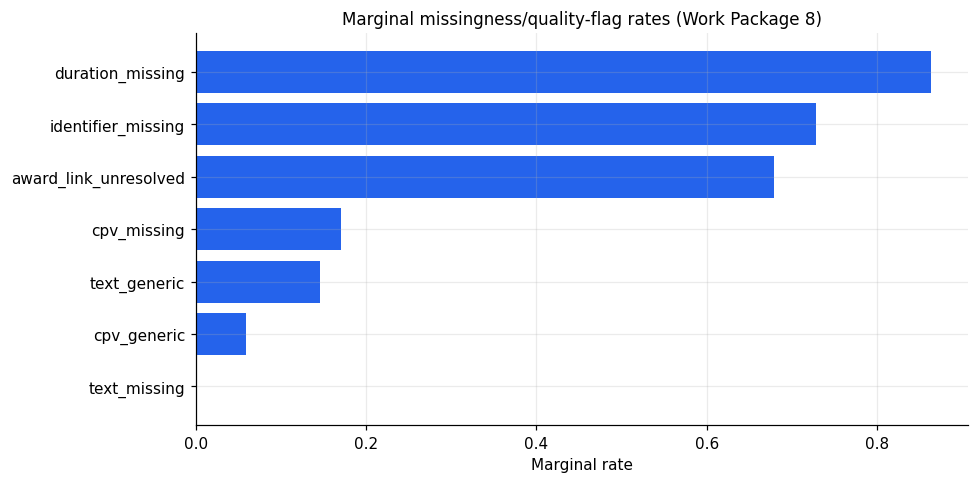

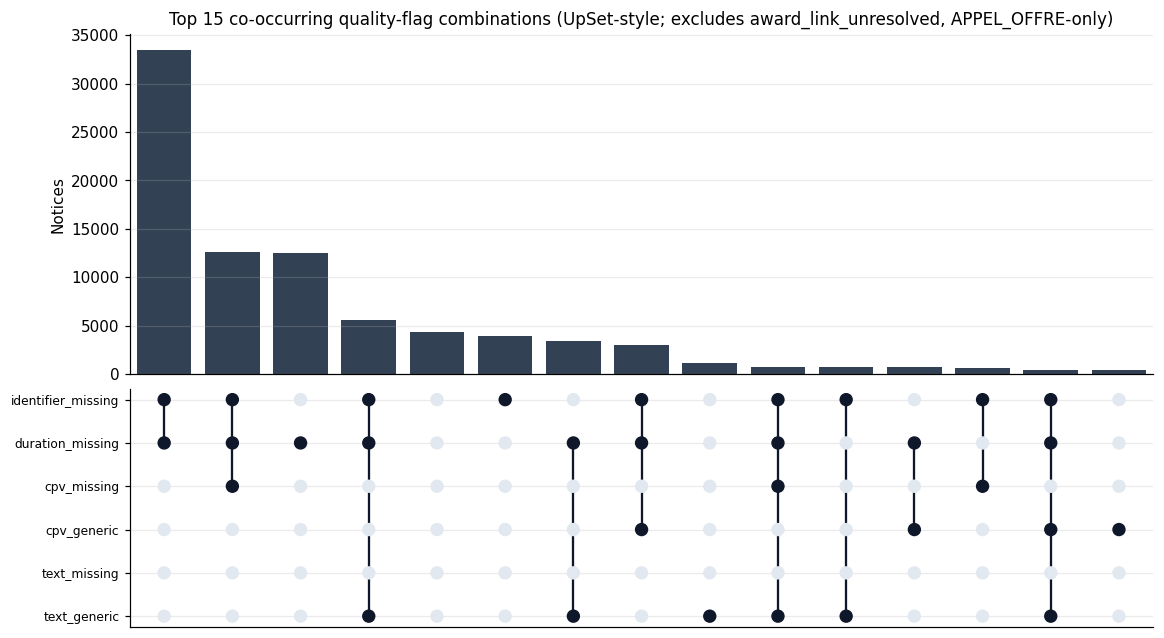

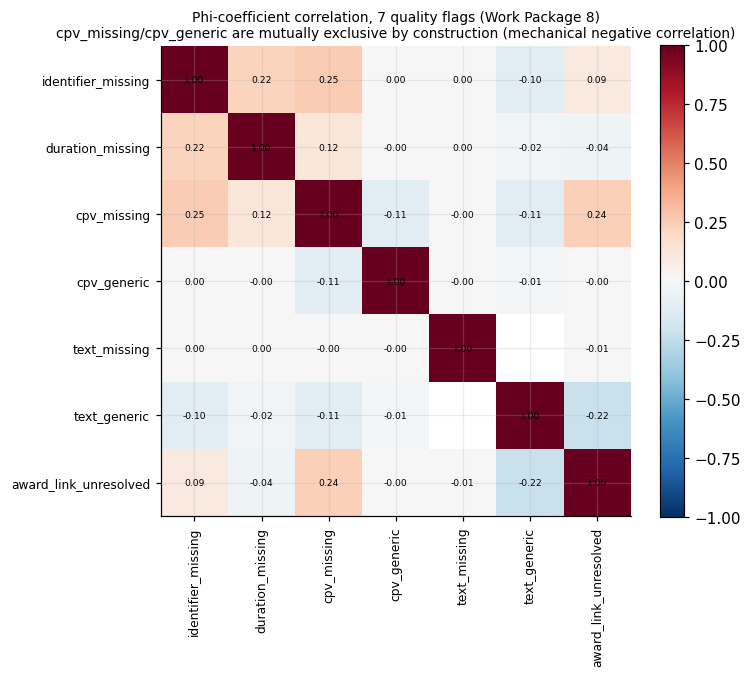

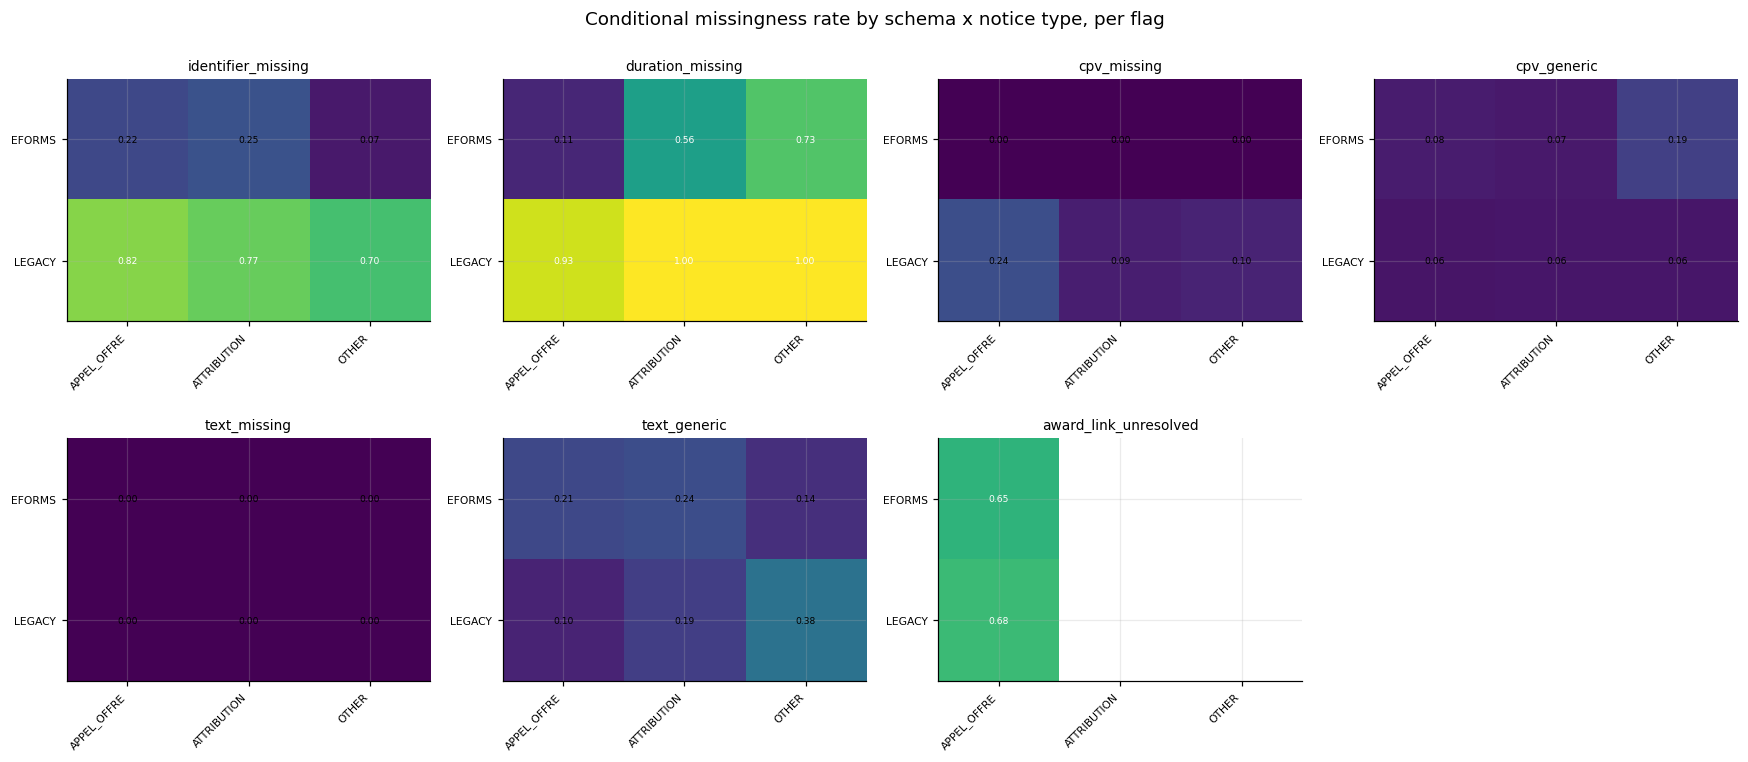

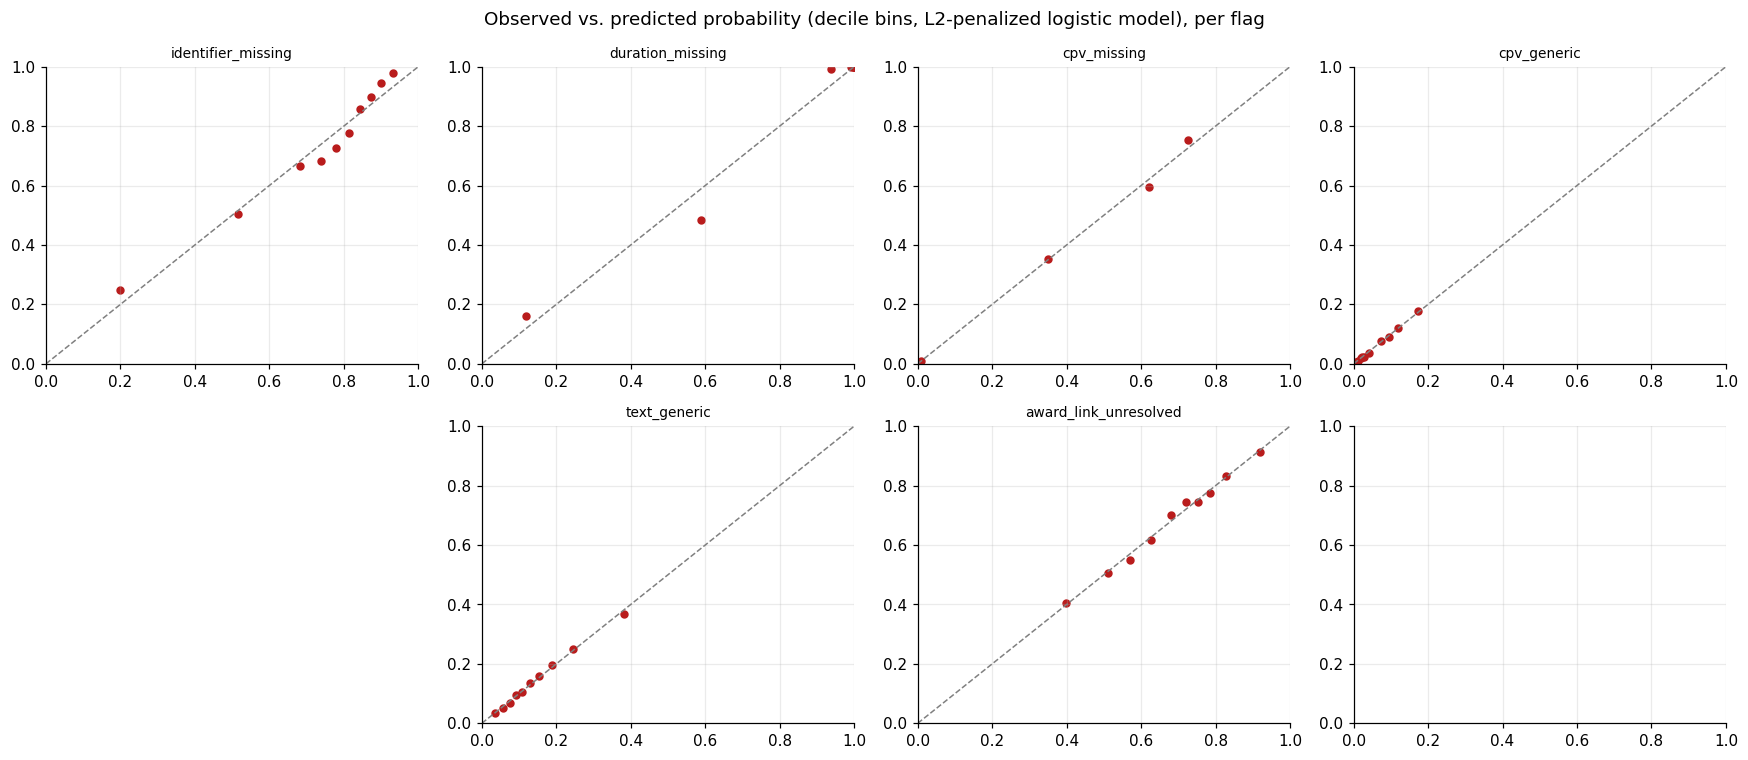

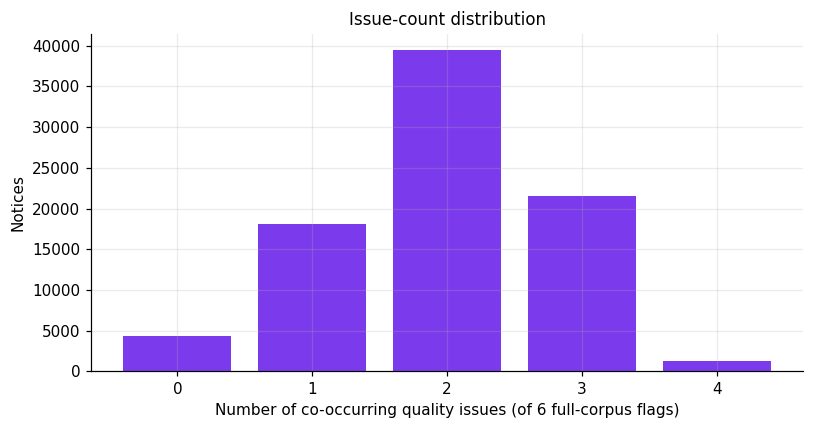

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

MISSINGNESS_WP8_FIG_DIR = cfg.paths.reports_figures / "synthetic_calibration" / "missingness_wp8"
MISSINGNESS_WP8_FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_missingness_wp8_figure(fig, stem):
    paths = []
    for ext in ("png", "pdf"):
        out = MISSINGNESS_WP8_FIG_DIR / f"{stem}.{ext}"
        fig.savefig(out, bbox_inches="tight", dpi=200)
        paths.append(str(out))
    plt.close(fig)
    return paths


# --- 7 flags for the phi matrix / marginal rates / conditional models -------
# identifier_missing, duration_missing, award_link_unresolved reuse §11's
# `flags` DataFrame rather than re-deriving the same definitions.
cpv_missing_flag = common["cpv_missing"].astype(bool).astype(float)
cpv_generic_flag_wp8 = common["cpv_generic_flag"].astype(bool).astype(float)
text_missing_flag = common["objet_clean"].isna().astype(float)

# "Generic" text: belongs to an exact-duplicate template group of size >= 3.
# Recomputed independently of §15b's text_duplicate_groups (a cheap groupby)
# so this section has no ordering dependency on §15b having already run.
_dup_group_size = common.groupby("objet_normalized")["notice_id"].transform("size")
text_generic_flag = pd.Series(np.nan, index=common.index)
_has_text = common["objet_normalized"].notna()
text_generic_flag.loc[_has_text] = (_dup_group_size.loc[_has_text] >= 3).astype(float)

WP8_FLAGS = pd.DataFrame({
    "identifier_missing": flags["siret_or_siren_missing"],
    "duration_missing": flags["duration_missing"],
    "cpv_missing": cpv_missing_flag,
    "cpv_generic": cpv_generic_flag_wp8,
    "text_missing": text_missing_flag,
    "text_generic": text_generic_flag,
    "award_link_unresolved": flags["award_link_unresolved"],
}, index=common.index)

# name_fallback is excluded from WP8_FLAGS (and so from the phi matrix and
# conditional models): in this corpus buyer_key_type takes only RAW_SIRET or
# NAME_FALLBACK values (zero RAW_SIREN rows observed), so name_fallback is
# empirically *identical* to identifier_missing here (correlation exactly 1.0)
# - not merely a subset as anticipated, full redundancy. It is kept only as an
# auxiliary flag for its one named joint pattern below, same treatment as §11.
name_fallback_flag = (common["buyer_key_type"] == "NAME_FALLBACK").astype(float)

# --- 4 auxiliary flags used only in named joint patterns (disjoint populations, or redundant with identifier_missing) ---
_cand_counts = (
    l1_pairs.loc[l1_pairs["candidate_rank"] == 1]
    .drop_duplicates("source_notice_id")
    .set_index("source_notice_id")["n_candidates_for_source"]
)
LARGE_POOL_THRESHOLD = float(_cand_counts.quantile(0.75))
large_candidate_pool_flag = pd.Series(np.nan, index=common.index)
_src_mask = common["notice_id"].isin(_cand_counts.index)
large_candidate_pool_flag.loc[_src_mask] = (
    common.loc[_src_mask, "notice_id"].map(_cand_counts) >= LARGE_POOL_THRESHOLD).astype(float)

_attr_mask = common["notice_type_normalized"] == "ATTRIBUTION"
missing_contractor_flag = pd.Series(np.nan, index=common.index)
missing_contractor_flag.loc[_attr_mask] = common.loc[_attr_mask, "titulaire"].isna().astype(float)
attribution_award_link_missing_flag = pd.Series(np.nan, index=common.index)
attribution_award_link_missing_flag.loc[_attr_mask] = common.loc[_attr_mask, "annonce_lie"].isna().astype(float)

AUX_FLAGS = {
    "large_candidate_pool": large_candidate_pool_flag,
    "missing_contractor": missing_contractor_flag,
    "attribution_award_link_missing": attribution_award_link_missing_flag,
    "name_fallback": name_fallback_flag,
}
ALL_FLAGS_FOR_PATTERNS = {**{c: WP8_FLAGS[c] for c in WP8_FLAGS.columns}, **AUX_FLAGS}

# --- marginal rates + phi matrix --------------------------------------------
missingness_marginal_rates = WP8_FLAGS.mean().rename("marginal_rate").reset_index().rename(columns={"index": "flag"})
missingness_phi_matrix = WP8_FLAGS.corr()  # pairwise-complete, matches §11's convention
missingness_marginal_rates.to_csv(SYN_CALIB_DIR / "missingness_marginal_rates.csv", index=False)
missingness_phi_matrix.to_csv(SYN_CALIB_DIR / "missingness_phi_matrix.csv")

# --- conditional rates: marginal-by-dimension, plus a 2-way schema x notice_type view ---
COND_DIMS = ["schema_family", "notice_type_normalized", "publication_year",
             "cpv_division", "buyer_activity_tier", "dept_primary"]
cond_rows = []
for dim in COND_DIMS:
    g = pd.concat([common[dim], WP8_FLAGS], axis=1).groupby(dim)
    for flag in WP8_FLAGS.columns:
        rates = g[flag].mean()
        counts = g[flag].apply(lambda s: s.notna().sum())
        for value in rates.index:
            cond_rows.append({"flag": flag, "stratum_dim": dim, "stratum_value": value,
                               "rate": rates.loc[value], "n_applicable": int(counts.loc[value])})
calib_missingness_conditional_rates = pd.DataFrame(cond_rows)
calib_missingness_conditional_rates.to_csv(SYN_CALIB_DIR / "calib_missingness_conditional_rates.csv", index=False)

schema_notice_rows = []
g2 = pd.concat([common[["schema_family", "notice_type_normalized"]], WP8_FLAGS], axis=1).groupby(
    ["schema_family", "notice_type_normalized"])
for flag in WP8_FLAGS.columns:
    rates = g2[flag].mean()
    counts = g2[flag].apply(lambda s: s.notna().sum())
    for (schema, ntype) in rates.index:
        schema_notice_rows.append({"flag": flag, "schema_family": schema, "notice_type_normalized": ntype,
                                    "rate": rates.loc[(schema, ntype)], "n_applicable": int(counts.loc[(schema, ntype)])})
calib_missingness_by_schema_notice_type = pd.DataFrame(schema_notice_rows)
calib_missingness_by_schema_notice_type.to_csv(SYN_CALIB_DIR / "calib_missingness_by_schema_notice_type.csv", index=False)

# --- 5 named joint patterns ---------------------------------------------------
def _joint_pattern_row(name, flag_a_name, flag_b_name):
    a, b = ALL_FLAGS_FOR_PATTERNS[flag_a_name], ALL_FLAGS_FOR_PATTERNS[flag_b_name]
    sub = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    if len(sub) == 0:
        return {"pattern": name, "flag_a": flag_a_name, "flag_b": flag_b_name, "n_applicable": 0,
                "rate_a": np.nan, "rate_b": np.nan, "joint_rate": np.nan,
                "expected_if_independent": np.nan, "lift": np.nan}
    rate_a, rate_b = sub["a"].mean(), sub["b"].mean()
    joint_rate = ((sub["a"] == 1) & (sub["b"] == 1)).mean()
    expected = rate_a * rate_b
    lift = joint_rate / expected if expected > 0 else np.nan
    return {"pattern": name, "flag_a": flag_a_name, "flag_b": flag_b_name, "n_applicable": len(sub),
            "rate_a": rate_a, "rate_b": rate_b, "joint_rate": joint_rate,
            "expected_if_independent": expected, "lift": lift}


JOINT_PATTERNS = [
    ("missing_identifier_and_missing_duration", "identifier_missing", "duration_missing"),
    ("missing_cpv_and_missing_duration", "cpv_missing", "duration_missing"),
    ("name_fallback_and_large_candidate_pool", "name_fallback", "large_candidate_pool"),
    ("generic_text_and_generic_cpv", "text_generic", "cpv_generic"),
    ("unresolved_award_and_missing_contractor", "attribution_award_link_missing", "missing_contractor"),
]
missingness_joint_patterns = pd.DataFrame([_joint_pattern_row(*p) for p in JOINT_PATTERNS])
missingness_joint_patterns.to_csv(SYN_CALIB_DIR / "missingness_joint_patterns.csv", index=False)

# --- UpSet-style top combinations (6 always-defined WP8_FLAGS columns; excludes
# the APPEL_OFFRE-only award_link_unresolved so every notice contributes one combo) ---
UPSET_FLAGS = ["identifier_missing", "duration_missing", "cpv_missing", "cpv_generic",
               "text_missing", "text_generic"]
upset_df = WP8_FLAGS[UPSET_FLAGS].fillna(0).astype(int)
combo_counts = upset_df.groupby(UPSET_FLAGS).size().rename("n").reset_index().sort_values("n", ascending=False)
combo_counts = combo_counts.head(15).reset_index(drop=True)
combo_counts.to_csv(SYN_CALIB_DIR / "calib_missingness_upset_combinations.csv", index=False)

issue_count = upset_df.sum(axis=1)
calib_missingness_issue_count_distribution = (
    issue_count.value_counts().sort_index().rename("n_notices").reset_index().rename(columns={"index": "n_issues"}))
calib_missingness_issue_count_distribution.to_csv(
    SYN_CALIB_DIR / "calib_missingness_issue_count_distribution.csv", index=False)

# --- conditional models: logistic regression per flag, one schema x notice_type interaction ---
TOP_CPV_DIVISIONS = common["cpv_division"].value_counts().head(15).index.tolist()
TOP_DEPTS = common["dept_primary"].value_counts().head(10).index.tolist()


def _bucket(series, keep, other_label):
    return series.where(series.isin(keep), other_label).fillna(other_label)


design = pd.DataFrame(index=common.index)
design["schema_family"] = common["schema_family"].astype(str)
design["notice_type_normalized"] = common["notice_type_normalized"].astype(str)
design["buyer_activity_tier"] = common["buyer_activity_tier"].astype(str)
design["cpv_division_bucketed"] = _bucket(common["cpv_division"], TOP_CPV_DIVISIONS, "OTHER_OR_MISSING")
design["dept_bucketed"] = _bucket(common["dept_primary"], TOP_DEPTS, "OTHER_OR_MISSING")
design["is_digital_scope"] = common["is_digital_scope"].astype(float)
design["text_length_z"] = ((common["text_length"] - common["text_length"].mean())
                           / common["text_length"].std()).fillna(0.0)
design["publication_year_z"] = (common["publication_year"] - common["publication_year"].mean()) \
    / common["publication_year"].std()

CATEGORICAL_COLS = ["schema_family", "notice_type_normalized", "buyer_activity_tier",
                     "cpv_division_bucketed", "dept_bucketed"]
main_effects = pd.get_dummies(design[CATEGORICAL_COLS], drop_first=True)
interaction = pd.get_dummies(
    design["schema_family"] + "__x__" + design["notice_type_normalized"],
    prefix="schema_x_notice_type", drop_first=True)
X_full = pd.concat(
    [main_effects, interaction, design[["is_digital_scope", "text_length_z", "publication_year_z"]]], axis=1
).astype(float)

model_rows = []
model_diag_rows = []
pred_probas = {}
for flag in WP8_FLAGS.columns:
    y = WP8_FLAGS[flag]
    mask = y.notna()
    y_fit, X_fit = y.loc[mask], X_full.loc[mask]
    # Skip near-degenerate flags (e.g. text_missing, ~1 positive case in this
    # corpus): a logistic fit with <20 events in the minority class is not a
    # meaningful conditional model, only a training-set curve-fit to noise.
    class_counts = y_fit.value_counts()
    if len(class_counts) < 2 or class_counts.min() < 20:
        continue
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_fit, y_fit)
    proba = clf.predict_proba(X_fit)[:, 1]
    pred_probas[flag] = pd.Series(proba, index=X_fit.index)
    auc = roc_auc_score(y_fit, proba)
    for term, coef in zip(X_fit.columns, clf.coef_[0]):
        term_type = "interaction" if term.startswith("schema_x_notice_type") else "main_effect"
        model_rows.append({"flag": flag, "term": term, "term_type": term_type,
                            "coefficient": float(coef), "odds_ratio": float(np.exp(coef))})
    model_rows.append({"flag": flag, "term": "intercept", "term_type": "intercept",
                        "coefficient": float(clf.intercept_[0]), "odds_ratio": float(np.exp(clf.intercept_[0]))})
    model_diag_rows.append({"flag": flag, "n_fit": int(mask.sum()), "base_rate": float(y_fit.mean()), "train_auc": auc})

missingness_conditional_models = pd.DataFrame(model_rows)
calib_missingness_model_diagnostics = pd.DataFrame(model_diag_rows)
missingness_conditional_models.to_csv(SYN_CALIB_DIR / "missingness_conditional_models.csv", index=False)
calib_missingness_model_diagnostics.to_csv(SYN_CALIB_DIR / "calib_missingness_model_diagnostics.csv", index=False)

print("Marginal rates:")
display(missingness_marginal_rates)
print("Model diagnostics (train AUC; L2-penalized, not an inferential p-value):")
display(calib_missingness_model_diagnostics)
display(missingness_joint_patterns)

# --- exit criterion: 4 reproduction targets each backed by a non-empty table ---
EXIT_TARGETS = {
    "marginal rates": missingness_marginal_rates,
    "subgroup (conditional) rates": calib_missingness_conditional_rates,
    "common error bundles": missingness_joint_patterns,
    "schema and temporal changes": calib_missingness_by_schema_notice_type,
}
print("\nExit criterion — a synthetic corruption process should reproduce:")
for label, table in EXIT_TARGETS.items():
    print(f"  {label:32s}: {len(table):6,} rows")
assert all(len(t) > 0 for t in EXIT_TARGETS.values()), \
    "exit criterion requires a non-empty table for each of the 4 reproduction targets"

# --- Figure 1: marginal missingness bars ---
order = missingness_marginal_rates.sort_values("marginal_rate")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(order["flag"], order["marginal_rate"], color="#2563eb")
ax.set_xlabel("Marginal rate")
ax.set_title("Marginal missingness/quality-flag rates (Work Package 8)")
plt.tight_layout()
plt.show()
save_missingness_wp8_figure(fig, "missingness_marginal_rates_bars")

# --- Figure 2: joint-pattern UpSet-style plot (top combinations) ---
n_combo = len(combo_counts)
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1.4], hspace=0.05)
ax_bar = fig.add_subplot(gs[0])
ax_matrix = fig.add_subplot(gs[1], sharex=ax_bar)

ax_bar.bar(range(n_combo), combo_counts["n"], color="#334155")
ax_bar.set_ylabel("Notices")
ax_bar.set_title("Top 15 co-occurring quality-flag combinations "
                 "(UpSet-style; excludes award_link_unresolved, APPEL_OFFRE-only)")
ax_bar.set_xticks([])

for row_i, flag in enumerate(UPSET_FLAGS):
    y = len(UPSET_FLAGS) - 1 - row_i
    active = combo_counts[flag].to_numpy()
    ax_matrix.scatter(range(n_combo), [y] * n_combo,
                       c=["#0f172a" if a else "#e2e8f0" for a in active], s=60, zorder=3)
for col_i in range(n_combo):
    active_rows = [len(UPSET_FLAGS) - 1 - r for r, f in enumerate(UPSET_FLAGS) if combo_counts.iloc[col_i][f]]
    if len(active_rows) > 1:
        ax_matrix.plot([col_i, col_i], [min(active_rows), max(active_rows)], color="#0f172a", zorder=2)
ax_matrix.set_yticks(range(len(UPSET_FLAGS)))
ax_matrix.set_yticklabels(UPSET_FLAGS[::-1], fontsize=8)
ax_matrix.set_xlim(-0.5, n_combo - 0.5)
ax_matrix.set_xticks([])
plt.show()
save_missingness_wp8_figure(fig, "missingness_joint_pattern_upset")

# --- Figure 3: phi-correlation heatmap ---
fig, ax = plt.subplots(figsize=(7, 6))
labels = list(missingness_phi_matrix.columns)
im = ax.imshow(missingness_phi_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        val = missingness_phi_matrix.values[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6)
ax.set_title("Phi-coefficient correlation, 7 quality flags (Work Package 8)\n"
             "cpv_missing/cpv_generic are mutually exclusive by construction (mechanical negative correlation)",
             fontsize=9)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
save_missingness_wp8_figure(fig, "missingness_phi_correlation_heatmap")

# --- Figure 4: conditional missingness heatmaps by schema x notice type ---
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, flag in zip(axes.flat, WP8_FLAGS.columns):
    sub = calib_missingness_by_schema_notice_type.loc[calib_missingness_by_schema_notice_type["flag"] == flag]
    pivot = sub.pivot(index="schema_family", columns="notice_type_normalized", values="rate")
    ax.imshow(pivot.values, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45, fontsize=7, ha="right")
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=7)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if v > 0.5 else "black")
    ax.set_title(flag, fontsize=9)
for ax in axes.flat[len(WP8_FLAGS.columns):]:
    ax.set_visible(False)
fig.suptitle("Conditional missingness rate by schema x notice type, per flag")
plt.tight_layout()
plt.show()
save_missingness_wp8_figure(fig, "missingness_conditional_heatmaps_by_schema_notice_type")

# --- Figure 5: observed vs predicted probability (calibration), per flag ---
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, flag in zip(axes.flat, WP8_FLAGS.columns):
    if flag not in pred_probas:
        ax.set_visible(False)
        continue
    proba = pred_probas[flag]
    y_true = WP8_FLAGS[flag].loc[proba.index]
    bins = pd.qcut(proba, q=10, duplicates="drop")
    calib_df = pd.DataFrame({"proba": proba, "y": y_true, "bin": bins}).groupby("bin", observed=True).agg(
        mean_pred=("proba", "mean"), mean_obs=("y", "mean"))
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
    ax.scatter(calib_df["mean_pred"], calib_df["mean_obs"], s=20, color="#b91c1c")
    ax.set_title(flag, fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig.suptitle("Observed vs. predicted probability (decile bins, L2-penalized logistic model), per flag")
plt.tight_layout()
plt.show()
save_missingness_wp8_figure(fig, "missingness_observed_vs_predicted")

# --- Figure 6: issue-count distribution ---
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(calib_missingness_issue_count_distribution["n_issues"],
       calib_missingness_issue_count_distribution["n_notices"], color="#7c3aed")
ax.set_xlabel("Number of co-occurring quality issues (of 6 full-corpus flags)")
ax.set_ylabel("Notices")
ax.set_title("Issue-count distribution")
plt.tight_layout()
plt.show()
save_missingness_wp8_figure(fig, "missingness_issue_count_distribution")

add_provenance(
    "missingness_marginal_and_phi_wp8", "Marginal rates and phi-correlation among 7 quality flags (Work Package 8)",
    "OBSERVABLE", "see table", "rate / correlation (-1..1)", "marginal + pairwise",
    "data/interim/boamp_common_prepared.csv",
    "buyer_siret_clean,buyer_siren_clean,cpv_missing,cpv_generic_flag,duration_raw,objet_clean,"
    "objet_normalized,start_date_source,notice_type_normalized,buyer_key_type",
    "mean of 0/1 flags; Pearson/phi correlation, pairwise-complete", n_total, "15c",
    "missingness_marginal_rates.csv; missingness_phi_matrix.csv",
    "cpv_missing and cpv_generic are mutually exclusive states of the same field (cpv_generic_flag is False, "
    "not NaN, whenever CPV is absent), so their negative correlation is partly mechanical, not purely empirical; "
    "award_link_unresolved is APPEL_OFFRE-only (NaN elsewhere), matching §11's population restriction; "
    "name_fallback is excluded here (empirically identical to identifier_missing in this corpus, correlation "
    "exactly 1.0 - buyer_key_type takes only RAW_SIRET/NAME_FALLBACK values here, no RAW_SIREN rows observed) "
    "and kept only as an auxiliary flag for its one named joint pattern (next section).")
add_provenance(
    "missingness_conditional_rates_wp8", "Conditional missingness rates by schema/notice-type/year/CPV/buyer-activity/department",
    "OBSERVABLE", "see table", "rate", "by stratum_dim x stratum_value (and schema x notice_type jointly)",
    "data/interim/boamp_common_prepared.csv",
    "schema_family,notice_type_normalized,publication_year,cpv_division,buyer_activity_tier,dept_primary",
    "groupby each dimension (and the schema x notice_type pair), mean of each flag", n_total, "15c",
    "calib_missingness_conditional_rates.csv; calib_missingness_by_schema_notice_type.csv",
    "Marginal-by-dimension tables condition on one variable at a time; only the schema x notice_type table is a "
    "genuine 2-way conditional view, which is what the §11 'Reasoning' example (legacy/eForms CPV-vs-duration "
    "trade-off) actually requires.")
add_provenance(
    "missingness_conditional_models_wp8", "Per-flag L2-penalized logistic regression (odds ratios) with one schema x notice_type interaction",
    "OBSERVABLE", "see table", "coefficient / odds ratio", "by flag x term",
    "data/interim/boamp_common_prepared.csv",
    "schema_family,notice_type_normalized,buyer_activity_tier,cpv_division,dept_primary,is_digital_scope,"
    "text_length,publication_year",
    "sklearn LogisticRegression (default L2, C=1.0) per flag on one-hot main effects + a schema x notice_type "
    "interaction + standardized text_length/publication_year; train-set AUC reported as a diagnostic only",
    len(missingness_conditional_models), "15c", "missingness_conditional_models.csv",
    "Coefficients are L2-regularized point estimates, not inferential p-values (no statsmodels dependency was "
    "introduced); AUC is computed on the training population, not held out, so it is a fit-quality diagnostic, "
    "not a generalization estimate.")
add_provenance(
    "missingness_joint_patterns_wp8", "Five named co-occurring quality-issue patterns (rate, expected-under-independence, lift)",
    "OBSERVABLE", "see table", "rate / lift", "5 named patterns",
    "data/interim/boamp_common_prepared.csv",
    "buyer_siret_clean,buyer_siren_clean,duration_raw,cpv_missing,cpv_generic_flag,objet_normalized,"
    "buyer_key_type,titulaire,annonce_lie,notice_type_normalized",
    "for each named pair of flags: joint rate over the pairwise-complete population, divided by the product of "
    "marginal rates (lift); one of the five patterns (name_fallback + large_candidate_pool) additionally draws "
    "on the Layer 1 candidate pool (see next provenance row)",
    len(missingness_joint_patterns), "15c", "missingness_joint_patterns.csv",
    "unresolved_award_and_missing_contractor uses ATTRIBUTION-only fields (titulaire/annonce_lie) and is a "
    "different 'unresolved award' direction than §11's award_link_unresolved (which is about APPEL_OFFRE notices "
    "never receiving a resolved start date); the two must not be conflated.")
add_provenance(
    "missingness_large_candidate_pool_pattern", "name_fallback + large_candidate_pool joint-pattern rate",
    "SILVER_STANDARD", "see table", "rate / lift", "1 named pattern",
    "data/processed/boamp_only/boamp_only_candidate_pairs.csv", "n_candidates_for_source,candidate_rank",
    "large_candidate_pool = n_candidates_for_source >= its own p75 among rank-1 rows, joined back onto common by "
    "notice_id", 1, "15c", "missingness_joint_patterns.csv",
    "Sourced from the pre-threshold candidate pool (not accepted links), restricted to sources that reached "
    "candidate generation; a structural comparison only, never used to set synthetic ground truth (see §15).")
add_provenance(
    "missingness_issue_count_and_upset_wp8", "Top co-occurring quality-flag combinations and per-notice issue-count distribution",
    "OBSERVABLE", "see table", "count", "top 15 combinations; issue count 0-7",
    "data/interim/boamp_common_prepared.csv",
    "buyer_siret_clean,buyer_siren_clean,duration_raw,cpv_missing,cpv_generic_flag,objet_normalized,buyer_key_type",
    "groupby the 7 always-defined flags (excludes award_link_unresolved, APPEL_OFFRE-only), size per combination; "
    "row-wise sum of the same 7 flags for the issue count", len(combo_counts), "15c",
    "calib_missingness_upset_combinations.csv; calib_missingness_issue_count_distribution.csv",
    "Restricted to the 7 flags defined on the full corpus so every notice contributes exactly one combination; "
    "award_link_unresolved is excluded from the combination signature for the same reason it is population-"
    "restricted elsewhere in this notebook.")


## 15d. Human-review sample construction (Work Package 11)

**Purpose.** Use human review to calibrate difficult mechanisms, not to claim
definitive ground truth. This section builds the review queue only — it produces
**zero labels**, matching the rest of this notebook's honesty about the corpus's zero
completed manual-validation labels (`docs/methodology.md` §9). A human still has to do
the actual reviewing.

**Suggested strata**, each sampled (up to 8 cases) from real pipeline outputs: high-score
Layer 1 links (`confidence_tier == HIGH`, balanced variant); low-margin Layer 1 links
(`confidence_tier == POTENTIAL`); Layer 2-only links (a source Layer 2 links but Layer 1
never links at all); same-buyer hard negatives (reused directly from §15b's
`text_hard_negative_sample`, not resampled); pairs outside the frozen six-month window
(`gap_months > 6` among all candidate pairs, not just accepted links); split-or-merge
candidates (sources with ≥3 candidates and a near-zero top1-top2 margin — genuine
multi-candidate ambiguity a reviewer should adjudicate, not a detector's guess); sources
with no candidates at all (from the true eligible-source population,
`boamp_only_sources.csv`, 3,380 rows, not the broader all-scope population §13b uses);
very active buyers (`buyer_activity_tier == "21+"`).

**Labels.** Uses the frozen ontology (`config/synthetic/recurrence_ontology.yaml`, Work
Package 10): `NEXT_CYCLE`, `PARTIAL_RECURRENCE`, `SPLIT`, `MERGE`,
`SAME_THEME_DIFFERENT_NEED`, `UNRELATED`, `NO_SUCCESSOR`, plus `UNCERTAIN` (allowed here
since this is real-data review, not synthetic generation).

**Two separate files**, following the existing single-reviewer audit guide's practice
(`reports/final_single_reviewer_audit_guide.md`) of hiding technical fields from the
reviewer to avoid anchoring: a **blinded** queue (dates, buyer names, CPV, text,
`review_stratum` — no scores, no layer, no confidence tier) with the six fields a
reviewer must fill in (`reviewer`, `evidence`, `decision`, `confidence`, `disagreement`,
`final_adjudication`), and a **technical join** table (composite score, component scores,
confidence tier, layer, threshold) keyed by `validation_case_id`, joined back only after
labels are recorded.

**What this review should answer** (recorded as free-text guidance in
`reports/human_review_guide_wp11.md`, not something this notebook can answer itself):
are the relation classes realistic; do split and merge cases actually occur; how strong
can text drift be; how often does CPV change; what difficult false candidates should the
simulator include.

**Exit criterion.** The review should refine scenario ranges (§14's
`calib_unidentified_parameters_scenarios.csv`), not produce a single claimed real
precision estimate — enforced here only by construction (every `decision`/`confidence`/
etc. cell is emitted blank, never inferred from a score).


Allowed decision labels (frozen ontology, Work Package 10): ['NEXT_CYCLE', 'PARTIAL_RECURRENCE', 'SPLIT', 'MERGE', 'SAME_THEME_DIFFERENT_NEED', 'UNRELATED', 'NO_SUCCESSOR', 'UNCERTAIN']


Built 80 unlabeled review cases across 8 strata.


,review_stratum,n_cases
0,split_or_merge_candidates,24
1,high_score_layer1_links,8
2,layer2_only_links,8
3,low_margin_layer1_links,8
4,same_buyer_hard_negatives,8
5,pairs_outside_six_month_window,8
6,sources_with_no_candidates,8
7,very_active_buyers,8


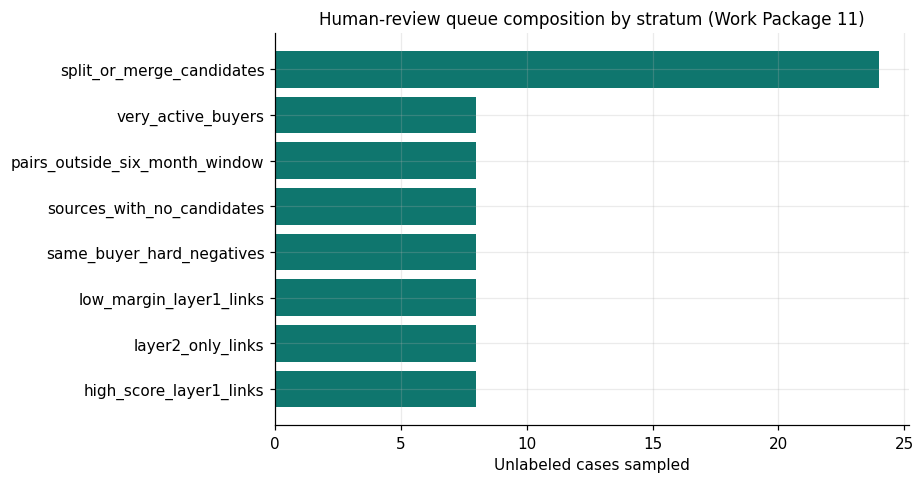

In [22]:
import yaml

HUMAN_REVIEW_FIG_DIR = cfg.paths.reports_figures / "synthetic_calibration" / "human_review"
HUMAN_REVIEW_FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG_WP11 = np.random.default_rng(20260721)
N_PER_STRATUM = 8

with open(PROJECT_ROOT / "config" / "synthetic" / "recurrence_ontology.yaml", encoding="utf-8") as _f:
    RECURRENCE_ONTOLOGY = yaml.safe_load(_f)
ALLOWED_DECISIONS = [name for name, rel in RECURRENCE_ONTOLOGY["relations"].items()
                     if "real_data_review" in rel["applies_to"]]
print(f"Allowed decision labels (frozen ontology, Work Package 10): {ALLOWED_DECISIONS}")

# --- fresh loads not already in kernel state from §15/§15b -----------------
enriched_links_balanced = pd.read_csv(D2 / "enriched_links_balanced.csv")
boamp_only_sources = pd.read_csv(D1 / "boamp_only_sources.csv", dtype={"notice_id": str})

_obj_map = common.set_index("notice_id")["objet_clean"]
_buyer_name_map = common.set_index("notice_id")["buyer_name_normalized"]
_cpv_map = common.set_index("notice_id")["cpv_clean"]
_pubdate_map = common.set_index("notice_id")["publication_date"]


def _row_from_ids(source_id, candidate_id):
    return {
        "source_notice_id": source_id,
        "candidate_notice_id": candidate_id,
        "source_publication_date": _pubdate_map.get(source_id, pd.NaT) if source_id is not None else pd.NaT,
        "source_buyer_name": _buyer_name_map.get(source_id) if source_id is not None else None,
        "source_cpv": _cpv_map.get(source_id) if source_id is not None else None,
        "source_objet": _obj_map.get(source_id) if source_id is not None else None,
        "candidate_publication_date": _pubdate_map.get(candidate_id, pd.NaT) if candidate_id is not None else pd.NaT,
        "candidate_buyer_name": _buyer_name_map.get(candidate_id) if candidate_id is not None else None,
        "candidate_cpv": _cpv_map.get(candidate_id) if candidate_id is not None else None,
        "candidate_objet": _obj_map.get(candidate_id) if candidate_id is not None else None,
    }


blinded_rows = []
technical_rows = []


def _add_case(stratum, source_id, candidate_id, technical):
    case_id = f"WP11-{len(blinded_rows) + 1:04d}"
    row = {"validation_case_id": case_id, "review_stratum": stratum}
    row.update(_row_from_ids(source_id, candidate_id))
    row["time_gap_months"] = (
        (row["candidate_publication_date"] - row["source_publication_date"]).days / FOLLOWUP_MONTH_DAYS
        if pd.notna(row.get("source_publication_date")) and pd.notna(row.get("candidate_publication_date"))
        else np.nan
    )
    for field in ["reviewer", "decision", "confidence", "evidence", "disagreement", "final_adjudication"]:
        row[field] = None
    blinded_rows.append(row)
    technical_rows.append({"validation_case_id": case_id, "review_stratum": stratum, **technical})


def _sample(df, n, rng=RNG_WP11):
    return df if len(df) <= n else df.sample(n, random_state=int(rng.integers(0, 2**31 - 1)))


# 1. High-score Layer 1 links.
high_score = _sample(l1_links_balanced.loc[l1_links_balanced["confidence_tier"] == "HIGH"], N_PER_STRATUM)
for _, r in high_score.iterrows():
    _add_case("high_score_layer1_links", r["source_notice_id"], r["candidate_notice_id"], {
        "layer": "boamp_only", "variant": "balanced", "composite_score": r["composite_score"],
        "s_text": r["s_text"], "s_cpv": r["s_cpv"], "s_time": r["s_time"], "s_buyer": r["s_buyer"],
        "confidence_tier": r["confidence_tier"], "top1_top2_margin": r["top1_top2_margin"],
    })

# 2. Low-margin Layer 1 links (POTENTIAL tier: margin < confidence_tiers.potential_margin_max).
low_margin = _sample(l1_links_balanced.loc[l1_links_balanced["confidence_tier"] == "POTENTIAL"], N_PER_STRATUM)
for _, r in low_margin.iterrows():
    _add_case("low_margin_layer1_links", r["source_notice_id"], r["candidate_notice_id"], {
        "layer": "boamp_only", "variant": "balanced", "composite_score": r["composite_score"],
        "s_text": r["s_text"], "s_cpv": r["s_cpv"], "s_time": r["s_time"], "s_buyer": r["s_buyer"],
        "confidence_tier": r["confidence_tier"], "top1_top2_margin": r["top1_top2_margin"],
    })

# 3. Layer 2-only links: a source enriched links but Layer 1 never links at all
#    (source_notice_id absent from Layer 1's balanced links entirely).
layer2_only_mask = ~enriched_links_balanced["source_notice_id"].isin(l1_links_balanced["source_notice_id"])
layer2_only = _sample(enriched_links_balanced.loc[layer2_only_mask], N_PER_STRATUM)
for _, r in layer2_only.iterrows():
    _add_case("layer2_only_links", r["source_notice_id"], r["candidate_notice_id"], {
        "layer": "enriched", "variant": "balanced", "composite_score": r["composite_score"],
        "s_text": r["s_text"], "s_cpv": r["s_cpv"], "s_time": r["s_time"], "s_buyer": r["s_buyer"],
        "confidence_tier": r["confidence_tier"], "top1_top2_margin": r["top1_top2_margin"],
        "buyer_match_mechanism": r.get("buyer_match_mechanism"),
    })

# 4. Same-buyer hard negatives: reused directly from §15b, not resampled.
hard_neg = _sample(text_hard_negative_sample, N_PER_STRATUM)
for _, r in hard_neg.iterrows():
    _add_case("same_buyer_hard_negatives", r["source_notice_id"], r["target_notice_id"], {
        "layer": "n/a (§15b structural comparison, not a linkage-pipeline candidate)",
        "word_tfidf_cosine": r["word_tfidf_cosine"], "same_cpv_division": r["same_cpv_division"],
    })

# 5. Pairs outside the frozen six-month window (all candidate pairs, not just accepted links).
outside_window = _sample(
    l1_pairs.loc[l1_pairs["gap_months"] > 6].sort_values("composite_score", ascending=False).head(200),
    N_PER_STRATUM)
for _, r in outside_window.iterrows():
    _add_case("pairs_outside_six_month_window", r["source_notice_id"], r["candidate_notice_id"], {
        "layer": "boamp_only", "composite_score": r["composite_score"], "s_text": r["s_text"],
        "s_cpv": r["s_cpv"], "s_time": r["s_time"], "gap_months": r["gap_months"],
        "candidate_rank": r["candidate_rank"],
    })

# 6. Split-or-merge candidates: genuine multi-candidate ambiguity for a human to
#    adjudicate (>= 3 candidates, near-zero top1-top2 margin), not a detector's guess.
ambiguous_sources = l1_pairs.loc[
    (l1_pairs["candidate_rank"] == 1)
    & (l1_pairs["n_candidates_for_source"] >= 3)
    & (l1_pairs["top1_top2_margin"] < cfg.pipeline.confidence_tiers.potential_margin_max)
]
sampled_sources = _sample(ambiguous_sources, N_PER_STRATUM)["source_notice_id"]
for source_id in sampled_sources:
    top_candidates = l1_pairs.loc[
        (l1_pairs["source_notice_id"] == source_id) & (l1_pairs["candidate_rank"] <= 3)
    ].sort_values("candidate_rank")
    for _, r in top_candidates.iterrows():
        _add_case("split_or_merge_candidates", r["source_notice_id"], r["candidate_notice_id"], {
            "layer": "boamp_only", "composite_score": r["composite_score"], "candidate_rank": r["candidate_rank"],
            "n_candidates_for_source": r["n_candidates_for_source"], "top1_top2_margin": r["top1_top2_margin"],
        })

# 7. Sources with no candidates at all (true eligible-source population, not the
#    broader all-scope population §13b uses).
sources_with_candidates = set(l1_pairs["source_notice_id"])
no_candidate_sources = boamp_only_sources.loc[~boamp_only_sources["notice_id"].isin(sources_with_candidates)]
no_candidate_sample = _sample(no_candidate_sources, N_PER_STRATUM)
for _, r in no_candidate_sample.iterrows():
    _add_case("sources_with_no_candidates", r["notice_id"], None, {
        "layer": "boamp_only (eligible source, zero candidates generated)",
    })

# 8. Very active buyers.
very_active = l1_pairs.loc[
    (l1_pairs["candidate_rank"] == 1)
    & l1_pairs["source_notice_id"].isin(
        common.loc[common["buyer_activity_tier"] == "21+", "notice_id"])
]
very_active_sample = _sample(very_active, N_PER_STRATUM)
for _, r in very_active_sample.iterrows():
    _add_case("very_active_buyers", r["source_notice_id"], r["candidate_notice_id"], {
        "layer": "boamp_only", "composite_score": r["composite_score"],
        "n_candidates_for_source": r["n_candidates_for_source"],
    })

human_review_queue_blinded = pd.DataFrame(blinded_rows)
human_review_queue_technical_join = pd.DataFrame(technical_rows)

human_review_queue_blinded.to_csv(SYN_CALIB_DIR / "human_review_queue_blinded.csv", index=False)
human_review_queue_technical_join.to_csv(SYN_CALIB_DIR / "human_review_queue_technical_join.csv", index=False)

stratum_counts = human_review_queue_blinded["review_stratum"].value_counts().rename("n_cases").reset_index().rename(
    columns={"index": "review_stratum"})
stratum_counts.to_csv(SYN_CALIB_DIR / "calib_human_review_stratum_counts.csv", index=False)

print(f"Built {len(human_review_queue_blinded)} unlabeled review cases across "
      f"{human_review_queue_blinded['review_stratum'].nunique()} strata.")
display(stratum_counts)

# Guard: this section must never emit a label - it only builds the queue.
label_fields = ["reviewer", "decision", "confidence", "evidence", "disagreement", "final_adjudication"]
assert human_review_queue_blinded[label_fields].isna().all().all(), \
    "human_review_queue_blinded must be emitted fully unlabeled - labeling is a human's job, not this notebook's"
assert set(ALLOWED_DECISIONS) >= {
    "NEXT_CYCLE", "PARTIAL_RECURRENCE", "SPLIT", "MERGE",
    "SAME_THEME_DIFFERENT_NEED", "UNRELATED", "NO_SUCCESSOR", "UNCERTAIN",
}, "the frozen ontology must expose all 8 real-data-review labels for this review to use"

fig, ax = plt.subplots(figsize=(8.5, 4.5))
order = stratum_counts.sort_values("n_cases")
ax.barh(order["review_stratum"], order["n_cases"], color="#0f766e")
ax.set_xlabel("Unlabeled cases sampled")
ax.set_title("Human-review queue composition by stratum (Work Package 11)")
plt.tight_layout()
plt.show()
for ext in ("png", "pdf"):
    fig.savefig(HUMAN_REVIEW_FIG_DIR / f"human_review_stratum_counts.{ext}", bbox_inches="tight", dpi=200)
plt.close(fig)

add_provenance(
    "human_review_queue_wp11", "Blinded human-review queue sampled from 8 strata (Work Package 11)",
    "OBSERVABLE", "see table", "n/a (unlabeled sample)", "by review_stratum",
    "data/processed/boamp_only/*; data/processed/enriched/*; data/interim/boamp_common_prepared.csv",
    "source_notice_id,candidate_notice_id,confidence_tier,top1_top2_margin,n_candidates_for_source,gap_months,"
    "buyer_activity_tier",
    "stratified sampling (up to 8 cases per stratum) from real Layer 1/Layer 2 pipeline outputs and §15b's "
    "hard-negative sample; every reviewer-facing field (reviewer, decision, confidence, evidence, disagreement, "
    "final_adjudication) is emitted null", len(human_review_queue_blinded), "15d",
    "human_review_queue_blinded.csv; human_review_queue_technical_join.csv",
    "This section produces zero labels - it only builds the queue a human still has to review. Scores/confidence "
    "tier/layer are held out of the blinded file and kept only in the technical join table, to avoid anchoring "
    "the reviewer on the pipeline's own decision (same practice as reports/final_single_reviewer_audit_guide.md).")


## 16. Parameter-provenance inventory compilation

Every statistic produced above was appended to `provenance_rows` as it was computed.
This is the enforcement mechanism for the tier separation the calibration brief demands:
every row is tagged OBSERVABLE / SILVER_STANDARD / UNIDENTIFIED and carries a mandatory,
non-empty caveat.

In [23]:
provenance_inventory = pd.DataFrame(provenance_rows)
assert (provenance_inventory["caveat"].str.len() > 0).all(), "every provenance row must carry a caveat"
assert set(provenance_inventory["tier"]) <= {"OBSERVABLE", "SILVER_STANDARD", "UNIDENTIFIED"}
assert set(provenance_inventory["generator_use_status"]) <= {"CALIBRATE", "DO_NOT_CALIBRATE", "SCENARIO_KNOB"}, \
    "every provenance row must carry a recognised generator_use_status"

silver_rows = provenance_inventory[provenance_inventory["tier"] == "SILVER_STANDARD"]
assert silver_rows["source_file"].str.contains("data/processed/").all(), \
    "every SILVER_STANDARD row must cite a data/processed/ source"
assert (silver_rows["generator_use_status"] == "DO_NOT_CALIBRATE").all(), \
    "SILVER_STANDARD rows must never be marked usable as a direct generator-calibration input"

provenance_inventory.to_csv(SYN_CALIB_DIR / "calib_parameter_provenance_inventory.csv", index=False)
print(f"Provenance inventory: {len(provenance_inventory)} rows "
      f"({provenance_inventory['tier'].value_counts().to_dict()}).")
display(provenance_inventory[["parameter_id", "tier", "generator_use_status", "notebook_section", "caveat"]])

Provenance inventory: 47 rows ({'OBSERVABLE': 38, 'UNIDENTIFIED': 5, 'SILVER_STANDARD': 4}).


,parameter_id,tier,generator_use_status,notebook_section,caveat
0,n_total_notices,OBSERVABLE,CALIBRATE,1,"Full corpus, all sectors, all notice types, no..."
1,year_completeness_status,OBSERVABLE,CALIBRATE,1,2015 and 2026 are PARTIAL years (extraction-wi...
2,dept_coverage,OBSERVABLE,CALIBRATE,2,code_departement can list several departments ...
3,notice_type_by_year,OBSERVABLE,CALIBRATE,2,notice_type_normalized collapses rare types to...
4,field_completeness_marginal,OBSERVABLE,CALIBRATE,3,Includes both raw and derived columns; see §16...
5,key_field_completeness_by_year,OBSERVABLE,CALIBRATE,3,"Trend, not a validated forecast; 2015 and 2026..."
6,schema_transition_shift,OBSERVABLE,CALIBRATE,4,schema_family is detected heuristically from t...
7,buyer_activity_gini,OBSERVABLE,CALIBRATE,5,buyer_key is BOAMP-native identity (SIRET/SIRE...
8,identifier_source_marginal,OBSERVABLE,CALIBRATE,6,RAW_SIRET_FIELD/RAW_SIREN_FIELD/DERIVED_FROM_S...
9,buyer_name_ambiguity_rate,OBSERVABLE,CALIBRATE,7,A data-quality measure of BOAMP-native identit...


## 16c. Frozen calibration parameter inventory (Work Package 12)

Distills every calibration result computed above (§1-§15d) into one curated, generator-facing
parameter list — not a 1:1 dump of the raw provenance log (§16's `provenance_inventory`, 47 rows of
individual statistics), but the smaller set of parameters an actual synthetic-generator component
would consume as a literal input.

**Provenance categories** (a different, coarser vocabulary than §1-§15d's OBSERVABLE/SILVER_STANDARD/
UNIDENTIFIED tiers, chosen to match this work package's own four-way split):

- `EMPIRICAL` — measured directly from the full corpus, same standard as this notebook's OBSERVABLE tier.
- `SILVER_STANDARD` — visible only through accepted-link diagnostics; carried over unchanged from §15
  (never a generator target, only ever `ready_to_freeze = False`).
- `LITERATURE_BASED` — the linkage pipeline's own fixed modeling conventions (composite-score weights,
  CPV-similarity ladder, temporal-window derivation, frozen thresholds): chosen by design/convention, not
  fitted from this corpus, and not something this notebook can validate as "correct" either way.
- `SCENARIO_ASSUMPTION` — carried over from §14's `calib_unidentified_parameters_scenarios.csv`; a range
  to sweep, never a point estimate, and explicitly `ready_to_freeze = False` pending §15d's human review.

**Important rule.** Precision, recall, the pipeline's current event rate (29.7%/35.1%), and its current
accepted-link count (618/847) must **never** appear here as generator targets — they are the pipeline's
own *output*, not a property of the real world the generator should reproduce, and must emerge only
*after* the generator is evaluated against them (`docs/methodology.md` §7). Enforced below by an explicit
keyword scan of every row's `parameter_name`, `estimate_or_range`, and `generator_component`, not just a
promise in prose.

**Output.** `reports/tables/synthetic_calibration/parameter_inventory.csv`.


Frozen 34 calibration parameters across 10 generator components.
Ready to freeze: 30 / 34.


,sum,count
provenance,,
EMPIRICAL,25,26
LITERATURE_BASED,5,5
SCENARIO_ASSUMPTION,0,2
SILVER_STANDARD,0,1


,parameter_name,provenance,generator_component,ready_to_freeze
0,corpus_size,EMPIRICAL,population_sampler,True
1,notice_type_mix,EMPIRICAL,population_sampler,True
2,schema_family_mix,EMPIRICAL,population_sampler,True
3,cpv_division_distribution_top5,EMPIRICAL,population_sampler,True
4,department_distribution_top5,EMPIRICAL,population_sampler,True
5,buyer_activity_tier_mix,EMPIRICAL,population_sampler,True
6,identifier_missing_rate,EMPIRICAL,missingness_injector,True
7,duration_missing_rate,EMPIRICAL,missingness_injector,True
8,cpv_missing_and_generic_rates,EMPIRICAL,missingness_injector,True
9,missingness_schema_notice_type_conditioning,EMPIRICAL,missingness_injector,True


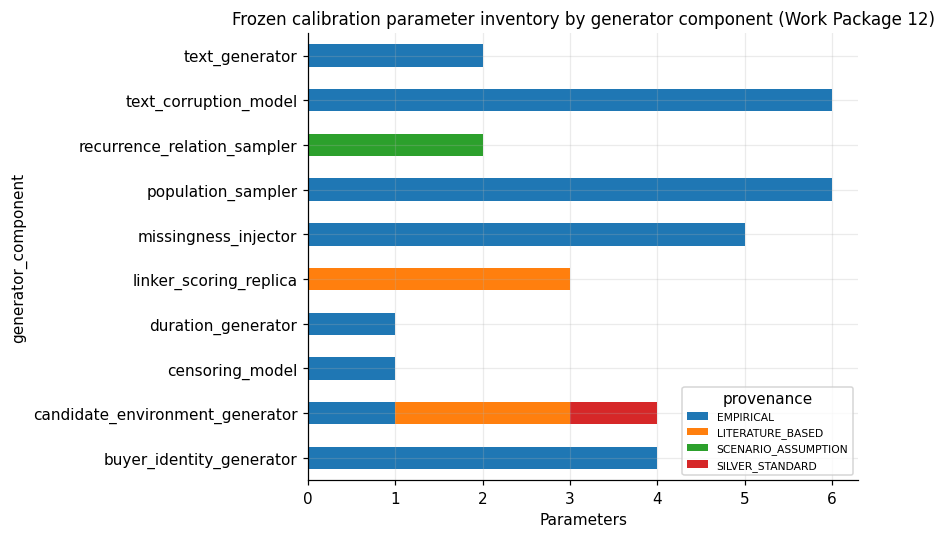

In [24]:
FORBIDDEN_GENERATOR_TARGET_TERMS = [
    "precision", "recall", "event_rate", "event rate",
    "accepted_link", "accepted-link", "accepted link count",
]

# --- a few fresh, cheap, self-contained aggregates not already named upstream ---
notice_type_mix = common["notice_type_normalized"].value_counts(normalize=True)
schema_mix = common["schema_family"].value_counts(normalize=True)
cpv_division_top5 = common["cpv_division"].value_counts(normalize=True).head(5)
dept_top5 = common["dept_primary"].value_counts(normalize=True).head(5)
buyer_activity_mix = common["buyer_activity_tier"].value_counts(normalize=True)
buyer_key_type_mix = common["buyer_key_type"].value_counts(normalize=True)

buyer_name_ambiguity_rate = (
    buyer_name_ambiguity["n_sirens"].gt(1) | buyer_name_ambiguity["n_sirets"].gt(1)
).mean()
buyer_generic_name_share = buyer_name_ambiguity["is_generic_name"].mean()
_siret_name_groups = common.dropna(subset=["buyer_siret_clean"]).groupby(
    "buyer_siret_clean")["buyer_name_normalized"].nunique()
buyer_name_variation_rate_wp12 = (_siret_name_groups > 1).mean()

_rank1 = l1_pairs.loc[l1_pairs["candidate_rank"] == 1]
candidates_per_source_median = _rank1["n_candidates_for_source"].median()
candidates_per_source_p90 = _rank1["n_candidates_for_source"].quantile(0.90)
zero_candidate_rate = 1 - len(set(l1_pairs["source_notice_id"])) / len(boamp_only_sources)

_ec_overall = evaluable_cohorts.loc[evaluable_cohorts["stratum_dim"] == "overall"].set_index("cohort")
_up = unidentified_params.set_index("parameter_name")

_tss = text_similarity_group_summary.set_index("pair_group")["word_tfidf_cosine_median"]
_joint_lift_str = "; ".join(
    f"{r.pattern}: lift={r.lift:.2f}" for r in missingness_joint_patterns.itertuples())
_schema_notice_examples = calib_missingness_by_schema_notice_type
def _cond_rate(flag, schema, notice_type):
    sub = _schema_notice_examples.loc[
        (_schema_notice_examples["flag"] == flag)
        & (_schema_notice_examples["schema_family"] == schema)
        & (_schema_notice_examples["notice_type_normalized"] == notice_type)]
    return float(sub["rate"].iloc[0]) if len(sub) else np.nan

parameter_rows = [
    # --- population_sampler ---
    {"parameter_name": "corpus_size", "definition": "Total notices in the prepared, layer-neutral corpus.",
     "estimate_or_range": f"{n_total:,}", "unit": "count", "conditioning_variables": "n/a",
     "population": "full corpus, all sectors, all notice types", "provenance": "EMPIRICAL", "confidence": "HIGH",
     "generator_component": "population_sampler",
     "limitations": "Extraction-window corpus (2015-2026), not a claim about BOAMP nationally beyond it.",
     "ready_to_freeze": True},
    {"parameter_name": "notice_type_mix",
     "definition": "Share of notices by notice_type_normalized.",
     "estimate_or_range": "; ".join(f"{k}={v:.1%}" for k, v in notice_type_mix.items()),
     "unit": "share", "conditioning_variables": "n/a", "population": "full corpus",
     "provenance": "EMPIRICAL", "confidence": "HIGH", "generator_component": "population_sampler",
     "limitations": "OTHER is a small, heterogeneous residual category (modification/cancellation/etc.).",
     "ready_to_freeze": True},
    {"parameter_name": "schema_family_mix",
     "definition": "Share of notices published under the LEGACY vs eForms XML schema.",
     "estimate_or_range": "; ".join(f"{k}={v:.1%}" for k, v in schema_mix.items()),
     "unit": "share", "conditioning_variables": "n/a", "population": "full corpus",
     "provenance": "EMPIRICAL", "confidence": "HIGH", "generator_component": "population_sampler",
     "limitations": "eForms share will keep rising after this extraction window; not a stationary process.",
     "ready_to_freeze": True},
    {"parameter_name": "cpv_division_distribution_top5",
     "definition": "Share of notices in the 5 most common CPV divisions.",
     "estimate_or_range": "; ".join(f"{k}={v:.1%}" for k, v in cpv_division_top5.items()),
     "unit": "share", "conditioning_variables": "n/a", "population": "full corpus, CPV present",
     "provenance": "EMPIRICAL", "confidence": "HIGH", "generator_component": "population_sampler",
     "limitations": "Full CPV distribution (45 observed divisions) is in calib_cpv_division_coverage.csv (§2); top-5 only, for a compact generator prior.",
     "ready_to_freeze": True},
    {"parameter_name": "department_distribution_top5",
     "definition": "Share of notices by primary department code, top 5.",
     "estimate_or_range": "; ".join(f"{k}={v:.1%}" for k, v in dept_top5.items()),
     "unit": "share", "conditioning_variables": "n/a", "population": "full corpus, department present",
     "provenance": "EMPIRICAL", "confidence": "HIGH", "generator_component": "population_sampler",
     "limitations": "Corpus is Pays-de-Loire-download-scoped but not PDL-filtered here (§12); other departments appear via cross-department notices.",
     "ready_to_freeze": True},
    {"parameter_name": "buyer_activity_tier_mix",
     "definition": "Share of notices by buyer activity tier (count of notices published by the same buyer_key).",
     "estimate_or_range": "; ".join(f"{k}={v:.1%}" for k, v in buyer_activity_mix.items()),
     "unit": "share", "conditioning_variables": "n/a", "population": "full corpus",
     "provenance": "EMPIRICAL", "confidence": "HIGH", "generator_component": "population_sampler",
     "limitations": "Highly right-skewed (Gini reported in §5); tier bins are a modeling convenience, not a natural break.",
     "ready_to_freeze": True},

    # --- missingness_injector ---
    {"parameter_name": "identifier_missing_rate",
     "definition": "Share of notices with neither a valid SIRET nor SIREN (falls back to name-based identity).",
     "estimate_or_range": f"{missingness_marginal_rates.set_index('flag').loc['identifier_missing', 'marginal_rate']:.1%}",
     "unit": "rate", "conditioning_variables": "n/a", "population": "full corpus",
     "provenance": "EMPIRICAL", "confidence": "HIGH", "generator_component": "missingness_injector",
     "limitations": "In this corpus, empirically identical to buyer_key_type == NAME_FALLBACK (§15c).",
     "ready_to_freeze": True},
    {"parameter_name": "duration_missing_rate",
     "definition": "Share of notices with no raw duration field at all.",
     "estimate_or_range": f"{missingness_marginal_rates.set_index('flag').loc['duration_missing', 'marginal_rate']:.1%}",
     "unit": "rate", "conditioning_variables": "n/a", "population": "full corpus",
     "provenance": "EMPIRICAL", "confidence": "HIGH", "generator_component": "missingness_injector",
     "limitations": "Full-corpus rate; the pipeline's own imputation rate over its eligible-source scope is a separate, smaller-population figure (see duration_imputation_rate below).",
     "ready_to_freeze": True},
    {"parameter_name": "cpv_missing_and_generic_rates",
     "definition": "Share of notices with a missing CPV code, and share with a present-but-generic CPV code.",
     "estimate_or_range": (f"missing={missingness_marginal_rates.set_index('flag').loc['cpv_missing', 'marginal_rate']:.1%}; "
                           f"generic={missingness_marginal_rates.set_index('flag').loc['cpv_generic', 'marginal_rate']:.1%}"),
     "unit": "rate", "conditioning_variables": "n/a", "population": "full corpus",
     "provenance": "EMPIRICAL", "confidence": "HIGH", "generator_component": "missingness_injector",
     "limitations": "Mutually exclusive by construction (§15c); their negative correlation is partly mechanical.",
     "ready_to_freeze": True},
    {"parameter_name": "missingness_schema_notice_type_conditioning",
     "definition": "How identifier/duration/CPV-missingness rates shift by schema x notice type - the key schema-artifact check.",
     "estimate_or_range": (
         f"duration_missing LEGACY/APPEL_OFFRE={_cond_rate('duration_missing','LEGACY','APPEL_OFFRE'):.2f}, "
         f"EFORMS/APPEL_OFFRE={_cond_rate('duration_missing','EFORMS','APPEL_OFFRE'):.2f}; "
         f"cpv_missing LEGACY/APPEL_OFFRE={_cond_rate('cpv_missing','LEGACY','APPEL_OFFRE'):.2f}, "
         f"EFORMS/APPEL_OFFRE={_cond_rate('cpv_missing','EFORMS','APPEL_OFFRE'):.2f}"),
     "unit": "rate", "conditioning_variables": "schema_family, notice_type_normalized",
     "population": "full corpus", "provenance": "EMPIRICAL", "confidence": "HIGH",
     "generator_component": "missingness_injector",
     "limitations": "Full breakdown (7 flags x 2 schemas x 3 notice types) in calib_missingness_by_schema_notice_type.csv (§15c); this row is a compact headline pair only.",
     "ready_to_freeze": True},
    {"parameter_name": "missingness_joint_pattern_lifts",
     "definition": "Observed co-occurrence lift (joint rate / expected-if-independent) for 5 named quality-issue bundles.",
     "estimate_or_range": _joint_lift_str,
     "unit": "lift (ratio)", "conditioning_variables": "n/a (one row per named pattern)",
     "population": "varies per pattern - see missingness_joint_patterns.csv", "provenance": "EMPIRICAL",
     "confidence": "MEDIUM", "generator_component": "missingness_injector",
     "limitations": "One pattern (name_fallback_and_large_candidate_pool) is SILVER_STANDARD-sourced (see §15c); the other 4 are EMPIRICAL.",
     "ready_to_freeze": True},

    # --- duration_generator ---
    {"parameter_name": "duration_imputation_rate",
     "definition": "Share of the pipeline's own eligible-source scope with an imputed (not observed) duration.",
     "estimate_or_range": f"{pipeline_scope_flags.get('IMPUTED_MEDIAN_BY_CPV_DIVISION', float('nan')):.1%}",
     "unit": "rate", "conditioning_variables": "n/a",
     "population": "APPEL_OFFRE & is_digital_scope (n=3,380, the eligible source population of docs/methodology.md)",
     "provenance": "EMPIRICAL", "confidence": "MEDIUM", "generator_component": "duration_generator",
     "limitations": "The highest-leverage assumption in the whole pipeline (docs/methodology.md §2); imputation itself uses median-by-CPV-division, not a distribution draw.",
     "ready_to_freeze": True},

    # --- buyer_identity_generator ---
    {"parameter_name": "siret_vs_name_fallback_share",
     "definition": "Share of notices keyed by a validated SIRET vs falling back to a normalized-name key.",
     "estimate_or_range": "; ".join(f"{k}={v:.1%}" for k, v in buyer_key_type_mix.items()),
     "unit": "share", "conditioning_variables": "n/a", "population": "full corpus",
     "provenance": "EMPIRICAL", "confidence": "HIGH", "generator_component": "buyer_identity_generator",
     "limitations": "No RAW_SIREN rows observed in this corpus (§15c); the generator should still expose the RAW_SIREN category since it is a valid code path.",
     "ready_to_freeze": True},
    {"parameter_name": "buyer_name_ambiguity_rate",
     "definition": "Share of normalized buyer names that map to more than one distinct SIRET or SIREN (false-merge risk).",
     "estimate_or_range": f"{buyer_name_ambiguity_rate:.1%}", "unit": "rate", "conditioning_variables": "n/a",
     "population": "full corpus, buyer_name_normalized present", "provenance": "EMPIRICAL", "confidence": "MEDIUM",
     "generator_component": "buyer_identity_generator",
     "limitations": "Detailed examples/classification in calib_buyer_name_ambiguity_examples.csv (§7).",
     "ready_to_freeze": True},
    {"parameter_name": "buyer_name_variation_rate",
     "definition": "Share of validated SIRETs that appear under more than one distinct normalized buyer name (false-split risk).",
     "estimate_or_range": f"{buyer_name_variation_rate_wp12:.1%}", "unit": "rate", "conditioning_variables": "n/a",
     "population": "full corpus, buyer_siret_clean present", "provenance": "EMPIRICAL", "confidence": "MEDIUM",
     "generator_component": "buyer_identity_generator",
     "limitations": "Name-transformation classification (legal-suffix removal, acronym, location-added, etc.) in calib_buyer_name_transformation_counts.csv (§7).",
     "ready_to_freeze": True},
    {"parameter_name": "generic_buyer_name_share",
     "definition": "Share of normalized buyer names matching the generic-institutional stoplist (mairie, commune, etc.).",
     "estimate_or_range": f"{buyer_generic_name_share:.1%}", "unit": "rate", "conditioning_variables": "n/a",
     "population": "full corpus", "provenance": "EMPIRICAL", "confidence": "HIGH",
     "generator_component": "buyer_identity_generator",
     "limitations": "Stoplist itself (config/pipeline.yaml enrichment.alias_bridge.generic_names) is a fixed list, not learned; extending it would change this rate.",
     "ready_to_freeze": True},

    # --- text_generator ---
    {"parameter_name": "exact_duplicate_template_rate",
     "definition": "Share of non-missing cleaned contract-object text that is an exact literal duplicate of another notice's text.",
     "estimate_or_range": f"{exact_dup_rate:.1%}", "unit": "rate", "conditioning_variables": "n/a",
     "population": "full corpus, objet_clean present", "provenance": "EMPIRICAL", "confidence": "HIGH",
     "generator_component": "text_generator",
     "limitations": "A lower bound on template reuse (exact string match only, §10); near-duplicate/fuzzy reuse is necessarily higher.",
     "ready_to_freeze": True},
    {"parameter_name": "key_technical_term_vocabulary_size",
     "definition": "Size of the place-name/administrative-stoplist-filtered technical-term vocabulary used for key-term overlap (§15b).",
     "estimate_or_range": f"{len(KEY_TERM_VOCAB)}", "unit": "count (terms)", "conditioning_variables": "n/a",
     "population": "full corpus", "provenance": "EMPIRICAL", "confidence": "MEDIUM",
     "generator_component": "text_generator",
     "limitations": "An independent CountVectorizer fit (max_features=400, min_df=15) with a fixed stoplist - a heuristic vocabulary, not a validated technical taxonomy.",
     "ready_to_freeze": False},

    # --- text_corruption_model (ties §15b's pair groups to Work Package 10's relation types) ---
    {"parameter_name": "text_similarity_next_cycle_proxy",
     "definition": "Median word-TF-IDF cosine similarity for same-provisional-notice-family pairs (proxy for the NEXT_CYCLE relation's own-episode republication text).",
     "estimate_or_range": f"{_tss.get('same_notice_family', float('nan')):.3f}", "unit": "cosine similarity",
     "conditioning_variables": "n/a", "population": "within-provisional-notice-family pairs (§10b)",
     "provenance": "EMPIRICAL", "confidence": "MEDIUM", "generator_component": "text_corruption_model",
     "limitations": "Same notice family means one lifecycle episode, not necessarily a true NEXT_CYCLE renewal (§10b/§15b caveats apply).",
     "ready_to_freeze": True},
    {"parameter_name": "text_similarity_plausible_recurrence_proxy",
     "definition": "Median word-TF-IDF cosine similarity for same-SIRET-same-detailed-CPV pairs (proxy for a plausible NEXT_CYCLE/PARTIAL_RECURRENCE candidate).",
     "estimate_or_range": f"{_tss.get('same_siret_same_cpv', float('nan')):.3f}", "unit": "cosine similarity",
     "conditioning_variables": "n/a", "population": "same-buyer-establishment, same-detailed-CPV pairs (§15b)",
     "provenance": "EMPIRICAL", "confidence": "MEDIUM", "generator_component": "text_corruption_model",
     "limitations": "A structural comparison group, not a verified recurrence label (§15b).", "ready_to_freeze": True},
    {"parameter_name": "text_similarity_same_buyer_distractor",
     "definition": "Median word-TF-IDF cosine similarity for same-buyer-different-CPV-division pairs (the same-buyer distractor group).",
     "estimate_or_range": f"{_tss.get('same_buyer_different_cpv', float('nan')):.3f}", "unit": "cosine similarity",
     "conditioning_variables": "n/a", "population": "same buyer, different CPV division (§15b)",
     "provenance": "EMPIRICAL", "confidence": "MEDIUM", "generator_component": "text_corruption_model",
     "limitations": "Deliberately not a recurrence; distractor calibration target only.", "ready_to_freeze": True},
    {"parameter_name": "text_similarity_same_theme_distractor",
     "definition": "Median word-TF-IDF cosine similarity for different-buyer-same-CPV pairs (proxy for the SAME_THEME_DIFFERENT_NEED relation).",
     "estimate_or_range": f"{_tss.get('different_buyer_same_cpv', float('nan')):.3f}", "unit": "cosine similarity",
     "conditioning_variables": "n/a", "population": "different buyer, same detailed CPV (§15b)",
     "provenance": "EMPIRICAL", "confidence": "MEDIUM", "generator_component": "text_corruption_model",
     "limitations": "Deliberately not a recurrence; distractor calibration target only.", "ready_to_freeze": True},
    {"parameter_name": "text_similarity_unrelated_baseline",
     "definition": "Median word-TF-IDF cosine similarity for different-buyer-different-CPV-division pairs (the true-negative background, proxy for UNRELATED).",
     "estimate_or_range": f"{_tss.get('different_buyer_different_cpv', float('nan')):.3f}", "unit": "cosine similarity",
     "conditioning_variables": "n/a", "population": "different buyer, different CPV division (§15b)",
     "provenance": "EMPIRICAL", "confidence": "HIGH", "generator_component": "text_corruption_model",
     "limitations": "The random-pair baseline; every other text-similarity parameter here should be read relative to this one.",
     "ready_to_freeze": True},
    {"parameter_name": "hard_negative_similarity_threshold",
     "definition": "The word-TF-IDF cosine similarity threshold (unrelated-baseline p90) used to mine same-buyer/same-division hard negatives.",
     "estimate_or_range": f"{baseline_p90:.3f}", "unit": "cosine similarity", "conditioning_variables": "n/a",
     "population": "different_buyer_different_cpv pairs (§15b)", "provenance": "EMPIRICAL", "confidence": "MEDIUM",
     "generator_component": "text_corruption_model",
     "limitations": "Anchored to this notebook's own baseline distribution, not an externally validated cutoff (§15b).",
     "ready_to_freeze": True},

    # --- candidate_environment_generator ---
    {"parameter_name": "candidates_per_source_distribution",
     "definition": "Median and p90 number of candidates the Layer 1 pipeline generates per eligible source.",
     "estimate_or_range": f"median={candidates_per_source_median:.0f}, p90={candidates_per_source_p90:.0f}",
     "unit": "count", "conditioning_variables": "n/a", "population": "eligible sources with >= 1 candidate",
     "provenance": "EMPIRICAL", "confidence": "MEDIUM", "generator_component": "candidate_environment_generator",
     "limitations": "Conditional on the pipeline's own blocking/window/cap (SILVER_STANDARD-adjacent input, not the candidate scores themselves).",
     "ready_to_freeze": True},
    {"parameter_name": "zero_candidate_source_rate",
     "definition": "Share of eligible sources for which blocking generated zero candidates at all.",
     "estimate_or_range": f"{zero_candidate_rate:.1%}", "unit": "rate", "conditioning_variables": "n/a",
     "population": "boamp_only_sources.csv (n=3,380)", "provenance": "SILVER_STANDARD", "confidence": "MEDIUM",
     "generator_component": "candidate_environment_generator",
     "limitations": "A blocking-stage input characteristic (structural censoring, docs/methodology.md limitation #6), not a claim about linker recall.",
     "ready_to_freeze": False},
    {"parameter_name": "temporal_window_months",
     "definition": "The expected-value temporal window used to generate candidates.",
     "estimate_or_range": f"{cfg.pipeline.temporal_window.expected_value_months}", "unit": "months",
     "conditioning_variables": "n/a", "population": "n/a (a pipeline design constant)",
     "provenance": "LITERATURE_BASED", "confidence": "HIGH", "generator_component": "candidate_environment_generator",
     "limitations": "Derived from a formula that currently collapses to its own floor (config/pipeline.yaml); not an empirical fact about renewal timing.",
     "ready_to_freeze": True},
    {"parameter_name": "max_candidates_per_source_cap",
     "definition": "The maximum number of temporally-nearest candidates kept per source.",
     "estimate_or_range": f"{cfg.pipeline.candidates.max_candidates_per_source}", "unit": "count",
     "conditioning_variables": "n/a", "population": "n/a (a pipeline design constant)",
     "provenance": "LITERATURE_BASED", "confidence": "HIGH", "generator_component": "candidate_environment_generator",
     "limitations": "A computational-cost cap, not evidence about how many plausible candidates truly exist.",
     "ready_to_freeze": True},

    # --- censoring_model ---
    {"parameter_name": "followup_evaluable_share_12m_24m",
     "definition": "Share of APPEL_OFFRE sources with at least 12 / 24 months of administrative follow-up.",
     "estimate_or_range": (f"12m={_ec_overall.loc['12_month_evaluable', 'evaluable_share']:.1%}, "
                          f"24m={_ec_overall.loc['24_month_evaluable', 'evaluable_share']:.1%}"),
     "unit": "share", "conditioning_variables": "n/a", "population": "all APPEL_OFFRE sources (§13b)",
     "provenance": "EMPIRICAL", "confidence": "HIGH", "generator_component": "censoring_model",
     "limitations": "By year/segment/buyer-activity/schema/identifier-source breakdown in evaluable_cohorts.csv (§13b).",
     "ready_to_freeze": True},

    # --- recurrence_relation_sampler (SCENARIO_ASSUMPTION, carried over from §14 and awaiting §15d) ---
    {"parameter_name": "recurrence_relation_type_mix",
     "definition": "The mixture of Work Package 10 relation types (NEXT_CYCLE/PARTIAL_RECURRENCE/SPLIT/MERGE/SAME_THEME_DIFFERENT_NEED/UNRELATED/NO_SUCCESSOR) to sample per source.",
     "estimate_or_range": _up.loc["true_recurrence_prevalence", "proposed_scenario_range"],
     "unit": "n/a (scenario range, not a point rate)", "conditioning_variables": "n/a",
     "population": "n/a (no BOAMP source establishes this)", "provenance": "SCENARIO_ASSUMPTION",
     "confidence": "LOW", "generator_component": "recurrence_relation_sampler",
     "limitations": "No verified legal-renewal field exists anywhere in BOAMP (§14); §15d's human review is intended to narrow this range, not replace it with a point estimate.",
     "ready_to_freeze": False},
    {"parameter_name": "split_merge_occurrence_rate",
     "definition": "How often a true recurrence takes the SPLIT or MERGE form rather than a clean one-to-one NEXT_CYCLE.",
     "estimate_or_range": _up.loc["true_candidate_ambiguity_resolution", "proposed_scenario_range"],
     "unit": "n/a (scenario range)", "conditioning_variables": "n/a",
     "population": "n/a (no BOAMP source establishes this)", "provenance": "SCENARIO_ASSUMPTION",
     "confidence": "LOW", "generator_component": "recurrence_relation_sampler",
     "limitations": "§15d's review strata explicitly include split_or_merge_candidates to inform this range.",
     "ready_to_freeze": False},

    # --- linker_scoring_replica (LITERATURE_BASED: the pipeline's own fixed conventions) ---
    {"parameter_name": "composite_score_weights",
     "definition": "The fixed weights combining s_text/s_cpv/s_time/s_buyer into the pipeline's composite score.",
     "estimate_or_range": "; ".join(f"{k}={v}" for k, v in vars(cfg.pipeline.scoring.weights).items()),
     "unit": "weight (sums to 1.0)", "conditioning_variables": "n/a", "population": "n/a",
     "provenance": "LITERATURE_BASED", "confidence": "HIGH", "generator_component": "linker_scoring_replica",
     "limitations": "Fixed a priori, not fitted (docs/methodology.md §5); only useful to a generator that wants to simulate the linker's own scoring, not as ground truth about recurrence.",
     "ready_to_freeze": True},
    {"parameter_name": "cpv_similarity_ladder",
     "definition": "The fixed CPV-hierarchy similarity score by match level (exact/category/class/group/division/different/missing).",
     "estimate_or_range": "; ".join(f"{k}={v}" for k, v in vars(cfg.pipeline.cpv_score).items()),
     "unit": "score (0-1)", "conditioning_variables": "n/a", "population": "n/a",
     "provenance": "LITERATURE_BASED", "confidence": "HIGH", "generator_component": "linker_scoring_replica",
     "limitations": "Also reused directly as this notebook's cpv_change_allowance vocabulary (config/synthetic/recurrence_ontology.yaml, Work Package 10).",
     "ready_to_freeze": True},
    {"parameter_name": "frozen_link_thresholds",
     "definition": "The broad/balanced/strict composite-score thresholds used for link acceptance.",
     "estimate_or_range": (f"broad={cfg.pipeline.thresholds.broad}, balanced={cfg.pipeline.thresholds.balanced}, "
                          f"strict={cfg.pipeline.thresholds.strict}"),
     "unit": "composite score (0-1)", "conditioning_variables": "n/a", "population": "n/a",
     "provenance": "LITERATURE_BASED", "confidence": "HIGH", "generator_component": "linker_scoring_replica",
     "limitations": "Percentile conventions derived once from Layer 1's own rank-1 score distribution, not independently validated cutoffs (docs/methodology.md §5).",
     "ready_to_freeze": True},
]

parameter_inventory = pd.DataFrame(parameter_rows)
REQUIRED_PARAM_COLS = [
    "parameter_name", "definition", "estimate_or_range", "unit", "conditioning_variables",
    "population", "provenance", "confidence", "generator_component", "limitations", "ready_to_freeze",
]
assert list(parameter_inventory.columns) == REQUIRED_PARAM_COLS
assert set(parameter_inventory["provenance"]) <= {"EMPIRICAL", "SILVER_STANDARD", "LITERATURE_BASED", "SCENARIO_ASSUMPTION"}
assert parameter_inventory["ready_to_freeze"].map(type).eq(bool).all()

# Important rule: precision/recall/current-event-rate/current-accepted-link-count must
# never appear here as generator targets. Checked structurally, not just promised in prose.
_scan_text = (parameter_inventory["parameter_name"] + " " + parameter_inventory["estimate_or_range"].astype(str)
              + " " + parameter_inventory["generator_component"]).str.lower()
_forbidden_hits = {term: int(_scan_text.str.contains(term, regex=False).sum())
                    for term in FORBIDDEN_GENERATOR_TARGET_TERMS}
assert all(v == 0 for v in _forbidden_hits.values()), \
    f"forbidden generator-target terms found in parameter_inventory: {_forbidden_hits}"

parameter_inventory.to_csv(SYN_CALIB_DIR / "parameter_inventory.csv", index=False)

print(f"Frozen {len(parameter_inventory)} calibration parameters across "
      f"{parameter_inventory['generator_component'].nunique()} generator components.")
print(f"Ready to freeze: {int(parameter_inventory['ready_to_freeze'].sum())} / {len(parameter_inventory)}.")
display(parameter_inventory.groupby("provenance")["ready_to_freeze"].agg(["sum", "count"]))
display(parameter_inventory[["parameter_name", "provenance", "generator_component", "ready_to_freeze"]])

PARAMETER_INVENTORY_FIG_DIR = cfg.paths.reports_figures / "synthetic_calibration" / "parameter_inventory"
PARAMETER_INVENTORY_FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
comp_counts = parameter_inventory.groupby(["generator_component", "provenance"]).size().unstack(fill_value=0)
comp_counts.plot(kind="barh", stacked=True, ax=ax)
ax.set_xlabel("Parameters")
ax.set_title("Frozen calibration parameter inventory by generator component (Work Package 12)")
ax.legend(fontsize=7, title="provenance")
plt.tight_layout()
plt.show()
for ext in ("png", "pdf"):
    fig.savefig(PARAMETER_INVENTORY_FIG_DIR / f"parameter_inventory_by_component.{ext}",
                bbox_inches="tight", dpi=200)
plt.close(fig)

add_provenance(
    "parameter_inventory_wp12", "Frozen, curated calibration-parameter inventory for the synthetic generator (Work Package 12)",
    "OBSERVABLE", "see table", "n/a", "by generator_component x provenance",
    "reports/tables/synthetic_calibration/* (every §1-§15d output this notebook produced)",
    "parameter_name,definition,estimate_or_range,unit,conditioning_variables,population,provenance,confidence,"
    "generator_component,limitations,ready_to_freeze",
    "curated distillation of §1-§15d's results and §16's raw provenance log into one generator-facing table, "
    "not a recomputation", len(parameter_inventory), "16c", "parameter_inventory.csv",
    "This row describes the inventory-building process itself; individual parameter rows carry their own "
    "provenance/confidence/limitations, including the 2 SCENARIO_ASSUMPTION rows explicitly not ready to freeze. "
    "Precision, recall, current event rate, and current accepted-link count are deliberately absent (see this "
    "section's Important Rule) and structurally asserted absent above.")


## 16b. Data lineage: field provenance (raw / cleaned / derived / imputed / enriched)

Every field this notebook computes a statistic from falls into exactly one of five
categories, classified below and exported to `calib_data_lineage.csv`:

- **RAW** — taken directly from the BOAMP source feed with no transformation beyond a
  dtype cast (e.g. parsing a date string).
- **CLEANED** — the same semantic field as a RAW column, format-validated and/or
  normalized; invalid values become missing rather than being guessed at.
- **DERIVED** — a new field computed deterministically from one or more other fields
  (parsing, splitting, bucketing); it never fills a gap in an existing field.
- **IMPUTED** — a value substituted for an unobserved true value via an explicit fallback
  rule (e.g. `start_date` falling back to `publication_date` when no attribution link is
  found). Always carries its own `*_source`/`*_flag` column recording that it happened.
- **ENRICHED** — present only in Layer 2 (`data/processed/enriched/*`) outputs, sourced
  from an external join (the SIREN alias bridge). Never used outside §15, which is walled
  off from every OBSERVABLE statistic in this notebook.

This table is metadata about the pipeline's field taxonomy, not a statistic — it has no
tier/generator-use-status of its own, but the RAW/CLEANED/DERIVED distinction is exactly
what lets §1-§13's OBSERVABLE statistics be trusted as "measured from the corpus" rather
than "measured from a value the pipeline invented."

In [25]:
field_lineage = pd.DataFrame([
    # --- RAW: straight from the BOAMP source feed, no value transformation ---
    {"variable": "nature", "source_column": "donnees.NATURE (raw feed)", "transformation": "none",
     "status": "RAW", "validation_rule": "none",
     "limitations": "Free-text/coded notice-nature field; source of notice_type_normalized (CLEANED)."},
    {"variable": "objet", "source_column": "donnees.OBJET (raw feed)", "transformation": "none",
     "status": "RAW", "validation_rule": "none",
     "limitations": "Unnormalized contract-object text; source of objet_clean (CLEANED)."},
    {"variable": "buyer_siret_raw", "source_column": "donnees identifiant field (raw feed)", "transformation": "none",
     "status": "RAW", "validation_rule": "none", "limitations": "May be absent, malformed, or non-numeric."},
    {"variable": "buyer_siren_raw", "source_column": "donnees identifiant field (raw feed)", "transformation": "none",
     "status": "RAW", "validation_rule": "none", "limitations": "May be absent, malformed, or non-numeric."},
    {"variable": "buyer_name_raw", "source_column": "donnees acheteur name field (raw feed)", "transformation": "none",
     "status": "RAW", "validation_rule": "none",
     "limitations": "Free text; a single real buyer can appear under many raw spellings (see §7 name variation)."},
    {"variable": "cpv_main", "source_column": "donnees CPV field or eForms ItemClassificationCode (raw feed)", "transformation": "none",
     "status": "RAW", "validation_rule": "none", "limitations": "May contain malformed or multi-code strings; eForms path recovery is audited in §8."},
    {"variable": "code_departement", "source_column": "donnees departement field (raw feed)", "transformation": "none",
     "status": "RAW", "validation_rule": "none", "limitations": "Multi-valued (';'-joined); not exploded until §2."},
    {"variable": "publication_date / dateparution", "source_column": "donnees date fields (raw feed)",
     "transformation": "pd.to_datetime dtype cast only, no value substitution", "status": "RAW",
     "validation_rule": "parseable as a date", "limitations": "Timezone-naive after cast; source of publication_year."},
    {"variable": "annonce_lie", "source_column": "donnees ATTRIBUTION linked-notice-id field (raw feed)",
     "transformation": "none", "status": "RAW", "validation_rule": "none",
     "limitations": "Only populated on ATTRIBUTION notices; used to build linked_attribution_notice_id (IMPUTED input)."},
    {"variable": "duration_raw", "source_column": "donnees duration field (raw feed)",
     "transformation": "numeric coercion (errors='coerce')", "status": "RAW", "validation_rule": "none",
     "limitations": "Not plausibility-checked here; see §9 out-of-range flag."},

    # --- CLEANED: same semantic field as a RAW column, format-validated / normalized ---
    {"variable": "buyer_siret_clean", "source_column": "buyer_siret_raw", "transformation": "format + Luhn checksum validation",
     "status": "CLEANED", "validation_rule": "14-digit SIRET format and valid Luhn checksum",
     "limitations": "Invalid values become missing, not corrected/guessed."},
    {"variable": "buyer_siren_clean", "source_column": "buyer_siren_raw", "transformation": "format + Luhn checksum validation",
     "status": "CLEANED", "validation_rule": "9-digit SIREN format and valid Luhn checksum",
     "limitations": "Invalid values become missing, not corrected/guessed."},
    {"variable": "cpv_clean", "source_column": "cpv_main", "transformation": "8-digit format validation after eForms ItemClassificationCode recovery",
     "status": "CLEANED", "validation_rule": "exact 8-digit CPV code", "limitations": "Malformed values treated as missing; multi-code candidate strings keep the first valid token in prepared data (see §8)."},
    {"variable": "buyer_name_normalized", "source_column": "buyer_name_raw",
     "transformation": "case/accent/whitespace normalization", "status": "CLEANED", "validation_rule": "non-empty string",
     "limitations": "Normalizes spelling of the same name, but distinct real names can still collide (generic institutional names, §7)."},
    {"variable": "objet_clean", "source_column": "objet", "transformation": "case/accent/whitespace normalization",
     "status": "CLEANED", "validation_rule": "non-empty string", "limitations": "Not deduplicated or template-stripped."},
    {"variable": "notice_type_normalized", "source_column": "nature",
     "transformation": "src/boamp/data/prepare.py::normalize_notice_type (map to APPEL_OFFRE/ATTRIBUTION/OTHER)",
     "status": "CLEANED", "validation_rule": "value in {APPEL_OFFRE, ATTRIBUTION, OTHER}",
     "limitations": "Collapses all other raw nature values into OTHER; drives §11's award-link-population restriction."},

    # --- DERIVED: new field, computed deterministically, never fills a gap ---
    {"variable": "buyer_key / buyer_key_type", "source_column": "buyer_siret_clean, buyer_siren_clean, buyer_name_normalized",
     "transformation": "src/boamp/data/identity_boamp.py::build_boamp_buyer_key (SIRET > SIREN > name-fallback priority ladder)",
     "status": "DERIVED", "validation_rule": "n/a", "limitations": "NAME_FALLBACK buyer_key aggregates distinct real entities under one key (§5, §13)."},
    {"variable": "dept_primary", "source_column": "code_departement", "transformation": "split on ';', take first token",
     "status": "DERIVED", "validation_rule": "n/a", "limitations": "Discards secondary departments on multi-valued notices."},
    {"variable": "cpv_division/group/class/category", "source_column": "cpv_clean", "transformation": "substring parsing of the 8-digit code",
     "status": "DERIVED", "validation_rule": "n/a", "limitations": "Undefined when cpv_clean is missing."},
    {"variable": "text_length / token_count", "source_column": "objet_clean", "transformation": "character count / whitespace tokenization",
     "status": "DERIVED", "validation_rule": "n/a", "limitations": "NaN when objet_clean is missing."},
    {"variable": "is_digital_scope / is_in_pdl", "source_column": "cpv_division, objet_normalized, code_departement",
     "transformation": "config/pipeline.yaml scope rule: CPV-division allowlist + French keyword search / department allowlist",
     "status": "DERIVED", "validation_rule": "n/a", "limitations": "A scope-tagging heuristic, not a validated eligibility label (§12)."},
    {"variable": "schema_family", "source_column": "raw donnees payload shape", "transformation": "src/utils/boamp_schema.py heuristic detection",
     "status": "DERIVED", "validation_rule": "n/a", "limitations": "Heuristically detected, not a declared field (§4)."},
    {"variable": "buyer_activity_tier", "source_column": "buyer_key notice counts (this notebook, §5)",
     "transformation": "pd.cut into {1, 2-5, 6-20, 21+}", "status": "DERIVED", "validation_rule": "n/a",
     "limitations": "Notebook-local bucketing, not part of src/boamp/data/prepare.py."},
    {"variable": "buyer_name_ambiguity / buyer_name_variation / buyer_name_transformations", "source_column": "buyer_name_raw, buyer_name_normalized, buyer_siret_clean, buyer_siren_clean, buyer_key, dept_primary, publication_date",
     "transformation": "Notebook §7 groupby and heuristic pairwise name-transformation classification",
     "status": "DERIVED", "validation_rule": "n/a", "limitations": "Calibrates identity ambiguity/aliasing risk; transformation labels are heuristic, not verified legal-name-change annotations."},
    {"variable": "pub_quarter", "source_column": "publication_date", "transformation": "dt.to_period('Q')",
     "status": "DERIVED", "validation_rule": "n/a", "limitations": "Notebook-local (§4 only)."},
    {"variable": "lifecycle_role / notice_family_id", "source_column": "notice_type_normalized, etat, nature_categorise, annonce_lie, annonces_anterieures, buyer_key, publication_date, objet_normalized, cpv_clean",
     "transformation": "Notebook §10b provisional graph components over explicit links, award links, bounded exact-text edges, and bounded high-similarity edges",
     "status": "DERIVED", "validation_rule": "n/a", "limitations": "Provisional lifecycle grouping for publications belonging to one procurement episode; not a later-cycle link label."},

    {"variable": "candidate_environment_future_only / candidate_environment_quantiles / candidate_filter_decomposition", "source_column": "notice_id, publication_date, notice_type_normalized, is_digital_scope, buyer identifiers, cpv_division, estimated_end_date, candidate_pairs",
     "transformation": "Notebook §13 strict future-search counts, grouped buyer-compatible counts, and stagewise production filter decomposition",
     "status": "DERIVED", "validation_rule": "candidate publication_date must be strictly after source publication_date",
     "limitations": "Ambient/buyer-compatible rows are corpus-density diagnostics; production rows inherit pipeline blocking, expected-end temporal rules, scoring, and candidate caps."},

    # --- IMPUTED: a fallback value substituted for an unobserved true value ---
    {"variable": "start_date / start_date_source", "source_column": "linked_attribution_date, publication_date, annonce_lie",
     "transformation": "src/boamp/data/prepare.py::prepare_common ATTRIBUTION reverse-lookup; falls back to "
                        "publication_date when no attribution link resolves",
     "status": "IMPUTED", "validation_rule": "n/a",
     "limitations": "start_date_source=='PUBLICATION_DATE_FALLBACK' IS the imputation flag; §11's "
                     "award_link_unresolved restricts to the APPEL_OFFRE population this applies to."},
    {"variable": "duration_quality_flag (pipeline eligible-source subset)", "source_column": "duration_raw",
     "transformation": "pipeline's own imputation over APPEL_OFFRE & digital-scope rows only (not run in this notebook; "
                        "referenced for comparison in §9)",
     "status": "IMPUTED", "validation_rule": "n/a",
     "limitations": "The pipeline's 82.7%-imputed figure; distinct from this notebook's own "
                     "duration_present_rate_full_corpus (OBSERVABLE, RAW presence check, full corpus)."},

    # --- ENRICHED: Layer 2 only, from an external-source join; walled off to §15 ---
    {"variable": "alias_bridge.csv rows", "source_column": "external SIREN registry join (Layer 2 enrichment)",
     "transformation": "buyer-identity propagation across native and external SIREN records",
     "status": "ENRICHED", "validation_rule": "n/a",
     "limitations": "Unvalidated heuristic; external join covers 2024-2026 only; only read in §15 (walled off)."},
    {"variable": "enrichment_conflicts.csv rows", "source_column": "external SIREN registry join (Layer 2 enrichment)",
     "transformation": "native-vs-external SIREN conflict flagging", "status": "ENRICHED", "validation_rule": "n/a",
     "limitations": "Flagged, never auto-resolved; only read in §15 (walled off)."},
])
field_lineage.to_csv(SYN_CALIB_DIR / "calib_data_lineage.csv", index=False)

print(f"Field lineage inventory: {len(field_lineage)} rows.")
display(field_lineage["status"].value_counts())
display(field_lineage[["variable", "status", "source_column"]])


Field lineage inventory: 31 rows.


status
DERIVED     11
RAW         10
CLEANED      6
IMPUTED      2
ENRICHED     2
Name: count, dtype: int64

,variable,status,source_column
0,nature,RAW,donnees.NATURE (raw feed)
1,objet,RAW,donnees.OBJET (raw feed)
2,buyer_siret_raw,RAW,donnees identifiant field (raw feed)
3,buyer_siren_raw,RAW,donnees identifiant field (raw feed)
4,buyer_name_raw,RAW,donnees acheteur name field (raw feed)
5,cpv_main,RAW,donnees CPV field or eForms ItemClassification...
6,code_departement,RAW,donnees departement field (raw feed)
7,publication_date / dateparution,RAW,donnees date fields (raw feed)
8,annonce_lie,RAW,donnees ATTRIBUTION linked-notice-id field (ra...
9,duration_raw,RAW,donnees duration field (raw feed)


## 17. Final report generation

Assembles a markdown report summarizing what the synthetic generator should reproduce,
what remains uncertain, and which pipeline outputs must never be used to construct
synthetic ground truth.

In [26]:
report_lines = []
def rline(s=""):
    report_lines.append(s)

rline("# Synthetic linkage benchmark: calibration report")
rline()
rline(f"Generated from `notebooks/04_synthetic_benchmark_calibration.ipynb`, "
      f"corpus: {n_total:,} BOAMP notices, {year_min}-{year_max}, Pays de la Loire "
      f"(departments {', '.join(cfg.pipeline.scope.pdl_departments)}). "
      f"{year_min} and {year_max} are PARTIAL years (see calib_year_completeness_status.csv).")
rline()
rline("## 1. Purpose & scope")
rline("This report summarizes the real-corpus properties a synthetic BOAMP-like linkage "
      "benchmark generator should reproduce, and draws a hard line around what may and "
      "may not be used to construct synthetic ground truth.")
rline()
rline("## 2. Tiering framework")
rline("- **OBSERVABLE** (generator-use status `CALIBRATE`) — measured directly from raw "
      "fields or the shared, layer-neutral preparation logic on the full corpus.")
rline("- **SILVER_STANDARD** (generator-use status `DO_NOT_CALIBRATE`) — visible only "
      "through Layer 1/Layer 2 accepted links (Section 15 of the notebook only); always "
      "conditional on threshold acceptance, never an unconditional error/accuracy rate.")
rline("- **UNIDENTIFIED** (generator-use status `SCENARIO_KNOB`) — cannot be estimated "
      "from any BOAMP output in this repo; must be swept across a range in the generator, "
      "never calibrated to a point.")
rline()
rline("## 3. Population structure")
rline(f"- {n_total:,} notices, years {year_min}-{year_max} ({year_min} and {year_max} are "
      f"PARTIAL years — see `calib_year_completeness_status.csv`).")
rline(f"- Schema transition (LEGACY -> EFORMS) around the ~Oct 2023 eForms mandate; "
      f"see `calib_schema_transition_shift.csv` for field-completeness shifts and "
      f"`eforms_cpv_recovery.csv` for the CPV parser discontinuity/correction.")
rline(f"- {n_buyers:,} distinct buyer_key values; activity Gini={gini:.3f}, "
      f"top-1 buyer share={buyer_counts.iloc[0] / buyer_counts.sum():.1%}.")
rline()
rline("## 4. Observable distributions the synthetic generator should reproduce (generator-use: CALIBRATE)")
obs_rows = provenance_inventory[provenance_inventory["tier"] == "OBSERVABLE"]
for _, r in obs_rows.iterrows():
    rline(f"- **{r['parameter_name']}** ({r['notebook_section']}): `{r['value_or_range']}` "
          f"[{r['stratification']}] -> `{r['figure_or_table_ref']}`. {r['caveat']}")
rline()
rline("## 5. Silver-standard-only observations (Section 15, generator-use: DO_NOT_CALIBRATE)")
rline("These describe accepted-link populations only; they are NOT unconditional error "
      "rates and must not be used to set synthetic ground-truth error/accuracy parameters.")
for _, r in silver_rows.iterrows():
    rline(f"- **{r['parameter_name']}**: `{r['value_or_range']}` -> `{r['figure_or_table_ref']}`. {r['caveat']}")
rline()
rline("## 6. Unidentified parameters / required scenario knobs (generator-use: SCENARIO_KNOB)")
unid_rows = provenance_inventory[provenance_inventory["tier"] == "UNIDENTIFIED"]
for _, r in unid_rows.iterrows():
    rline(f"- **{r['parameter_name']}**: {r['caveat']} Proposed scenario range: `{r['value_or_range']}`.")
rline()
rline("## 7. Do NOT use for synthetic ground truth")
rline("- `data/processed/{boamp_only,enriched}/*_candidate_pairs.csv` composite_score / confidence_tier")
rline("- `data/processed/{boamp_only,enriched}/*_links_{broad,balanced,strict,window_*}.csv`")
rline("- The frozen thresholds 0.278387 / 0.343167 / 0.442070 (`config/pipeline.yaml`, `thresholds:`)")
rline("- The six-month (and 9/12/18-month variant) temporal window (`config/pipeline.yaml`, `temporal_window:`)")
rline("- Event/censoring rates in `*_survival*.csv` (29.7% Layer 1 / 35.1% Layer 2) as true recurrence prevalence")
rline("- The pipeline's own precision/recall (never measured; see §6 `true_linkage_precision_recall` — "
      "SCENARIO_KNOB only, swept for the *injected* synthetic linker, never read off the real pipeline)")
rline()
rline("## 8. Calibration checklist")
rline("| Observable table | Generator knob |")
rline("|---|---|")
rline("| `calib_population_counts_by_year_schema.csv` | year/schema volume mix (exclude PARTIAL years from steady-state fits) |")
rline("| `calib_buyer_activity_distribution.csv` | buyer-activity (Zipf/Gini) distribution |")
rline("| `calib_identifier_quality_summary.csv` | SIRET/SIREN presence & validity rates |")
rline("| `buyer_name_ambiguity.csv` | name -> multiple legal buyers / false buyer-merging calibration |")
rline("| `buyer_name_variation_siret.csv` | names per SIRET / false buyer-splitting calibration at establishment level |")
rline("| `buyer_name_variation_siren.csv` | names per SIREN / false buyer-splitting calibration at legal-unit level |")
rline("| `buyer_name_transformations.csv` | likely name-transformation modes for synthetic alias generation |")
rline("| `eforms_cpv_recovery.csv` | eForms CPV parser recovery stages; use corrected CPV after regeneration |")
rline("| `eforms_cpv_path_audit.csv` | schema-specific CPV paths and excluded non-CPV 8-digit fields |")
rline("| `calib_cpv_quality_summary.csv` | corrected CPV missingness/genericity rates |")
rline("| `calib_duration_quality_summary.csv` | duration missingness/plausibility rates |")
rline("| `calib_text_characteristics_summary.csv` | text length/exact-duplicate rates |")
rline("| `notice_family_size_distribution.csv` | observed publications per provisional procurement episode |")
rline("| `notice_lifecycle_transitions.csv` | call/correction/modification/award/cancellation transition mix |")
rline("| `call_to_award_delays.csv` | delay from first observed call to award notice |")
rline("| `notice_family_text_similarity_comparison.csv` | within-family vs outside-family text similarity plausibility check |")
rline("| `notice_family_cpv_agreement.csv` | CPV agreement within provisional families |")
rline("| `calib_missingness_marginal_rates.csv` | per-flag missingness injection rate |")
rline("| `calib_missingness_phi_matrix.csv` | joint/correlated missingness injection |")
rline("| `candidate_environment_future_only.csv` | source-level future candidate counts, zero-candidate flags, first-candidate timing, family counts, cap/margin diagnostics |")
rline("| `candidate_environment_quantiles.csv` | candidate difficulty by horizon and strata (identity source, activity, schema, year, CPV, duration, digital segment) |")
rline("| `candidate_filter_decomposition.csv` | production filter/cap decomposition from ambient future pool to capped candidates |")
rline("| `calib_data_lineage.csv` | which generator inputs are RAW/CLEANED/DERIVED vs IMPUTED/ENRICHED (do not calibrate to the latter two) |")
rline()
rline("## 9. Known limitations (carried over from docs/methodology.md §9)")
rline("1. No verified renewal/linkage ground truth exists anywhere in this repo.")
rline("2. External SIREN enrichment covers 2024-2026 only; historical coverage rests on alias-bridge assumptions.")
rline("3. Composite weights and thresholds are unfitted/percentile conventions, not validated cutoffs.")
rline("4. SIREN-based buyer merges can conflate independently-tendering establishments.")
rline("5. Zero manual-validation labels exist; all quality diagnostics are model-based, not human-verified.")
rline(f"6. {year_min} and {year_max} are PARTIAL calendar years (extraction-window boundaries); "
      f"any by-year distribution used to calibrate a steady-state generator should exclude them or "
      f"reweight by `n_notices` in `calib_year_completeness_status.csv`.")
rline()
rline("## 10. Appendix: output files")
rline("- Figures: `reports/figures/calib_*.png` / `.pdf` plus `reports/figures/synthetic_calibration/{cpv,notice_families,buyer_identity,candidate_environment}/` figures")
rline("- Tables: `reports/tables/synthetic_calibration/calib_*.csv` plus `eforms_cpv_*.csv`, `notice_family_*.csv`, `buyer_name_*.csv`, and `candidate_environment_*.csv`")
rline(f"- Provenance inventory: `reports/tables/synthetic_calibration/calib_parameter_provenance_inventory.csv`")
rline(f"- Field lineage: `reports/tables/synthetic_calibration/calib_data_lineage.csv`")

report_md = "\n".join(report_lines)
report_path = cfg.paths.reports_generated / "synthetic_benchmark_calibration_report.md"
report_path.write_text(report_md, encoding="utf-8")
print(f"Wrote report: {report_path} ({len(report_md):,} chars)")



Wrote report: /home/senghakrou/survival-analysis/reports/generated/synthetic_benchmark_calibration_report.md (23,794 chars)


In [27]:
n_figs = len(list(cfg.paths.reports_figures.glob("calib_*.png")))
n_cpv_figs = len(list(CPV_FIG_DIR.glob("*.png")))
n_notice_family_figs = len(list(NOTICE_FAMILY_FIG_DIR.glob("*.png")))
n_buyer_identity_figs = len(list(BUYER_ID_FIG_DIR.glob("*.png")))
n_candidate_env_figs = len(list(CANDIDATE_ENV_FIG_DIR.glob("*.png")))
n_tables = len(list(SYN_CALIB_DIR.glob("calib_*.csv")))
n_eforms_tables = len(list(SYN_CALIB_DIR.glob("eforms_cpv_*.csv")))
n_notice_family_tables = len(list(SYN_CALIB_DIR.glob("notice_family_*.csv"))) + len(list(SYN_CALIB_DIR.glob("call_to_award_delays.csv")))
n_buyer_identity_tables = len(list(SYN_CALIB_DIR.glob("buyer_name_*.csv")))
n_candidate_env_tables = len(list(SYN_CALIB_DIR.glob("candidate_environment_*.csv"))) + len(list(SYN_CALIB_DIR.glob("candidate_filter_decomposition.csv")))
n_text_sim_figs = len(list(TEXT_SIM_FIG_DIR.glob("*.png")))
n_text_sim_tables = (
    len(list(SYN_CALIB_DIR.glob("text_*.csv")))
    + len(list(SYN_CALIB_DIR.glob("calib_text_similarity_group_summary.csv")))
    + len(list(SYN_CALIB_DIR.glob("calib_text_repeated_template_by_buyer.csv")))
    + len(list(SYN_CALIB_DIR.glob("calib_text_length_by_notice_type_schema.csv")))
)
n_missingness_wp8_figs = len(list(MISSINGNESS_WP8_FIG_DIR.glob("*.png")))
n_missingness_wp8_tables = len(list(SYN_CALIB_DIR.glob("missingness_*.csv")))
n_followup_figs = len(list(FOLLOWUP_FIG_DIR.glob("*.png")))
n_followup_tables = (len(list(SYN_CALIB_DIR.glob("followup_availability.csv")))
                     + len(list(SYN_CALIB_DIR.glob("evaluable_cohorts.csv"))))
n_human_review_figs = len(list(HUMAN_REVIEW_FIG_DIR.glob("*.png")))
n_human_review_tables = len(list(SYN_CALIB_DIR.glob("human_review_queue_*.csv")))
n_parameter_inventory_tables = len(list(SYN_CALIB_DIR.glob("parameter_inventory.csv")))
n_parameter_inventory_figs = len(list(PARAMETER_INVENTORY_FIG_DIR.glob("*.png")))
print(f"Calibration notebook complete. {n_figs} calibration figures + {n_cpv_figs} eForms CPV figures "
      f"+ {n_notice_family_figs} notice-family figures + {n_buyer_identity_figs} buyer-identity figures + {n_candidate_env_figs} candidate-environment figures + {n_text_sim_figs} text-similarity figures + {n_missingness_wp8_figs} missingness-modeling figures + {n_followup_figs} follow-up/censoring figures + {n_human_review_figs} human-review figures + {n_parameter_inventory_figs} parameter-inventory figures, "
      f"{n_tables} calibration tables + {n_eforms_tables} eForms CPV tables + "
      f"{n_notice_family_tables} notice-family tables + {n_buyer_identity_tables} buyer-identity tables + {n_candidate_env_tables} candidate-environment tables + {n_text_sim_tables} text-similarity tables + {n_missingness_wp8_tables} missingness-modeling tables + {n_followup_tables} follow-up/censoring tables + {n_human_review_tables} human-review tables + {n_parameter_inventory_tables} frozen-parameter-inventory table in {SYN_CALIB_DIR}, "
      f"{len(provenance_inventory)} provenance rows, report at {report_path}.")


Calibration notebook complete. 18 calibration figures + 4 eForms CPV figures + 5 notice-family figures + 2 buyer-identity figures + 3 candidate-environment figures + 6 text-similarity figures + 6 missingness-modeling figures + 4 follow-up/censoring figures + 1 human-review figures + 1 parameter-inventory figures, 48 calibration tables + 3 eForms CPV tables + 9 notice-family tables + 6 buyer-identity tables + 3 candidate-environment tables + 6 text-similarity tables + 4 missingness-modeling tables + 2 follow-up/censoring tables + 2 human-review tables + 1 frozen-parameter-inventory table in /home/senghakrou/survival-analysis/reports/tables/synthetic_calibration, 47 provenance rows, report at /home/senghakrou/survival-analysis/reports/generated/synthetic_benchmark_calibration_report.md.
